In [1]:
# Import libraries and define configs
import json
import random
import warnings
from pathlib import Path
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.utils import resample
from joblib import Parallel, delayed
from threadpoolctl import threadpool_limits
from joblib import parallel_backend
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "figure.dpi": 120,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
    }
)

RANDOM_STATE = 121
N_JOBS = -1
CV_FOLDS = 5
OPERATING_THRESHOLD = 0.065424
OUTREACH_CAPACITIES = (0.01, 0.05, 0.10, 0.20)
PERMUTATION_IMPORTANCE_REPEATS = 30
PERMUTATION_IMPORTANCE_N_JOBS = -1
SHAP_FEATURE_PERTURBATION = "tree_path_dependent"
SHAP_MODEL_OUTPUT = "raw"
SHAP_ADDITIVITY_TOLERANCE = 1e-8
DIRECTION_MINIMUM_CORRELATION = 0.05
DIRECTION_NEUTRAL_SHAP_TOLERANCE = 0.0001
SHAP_DEPENDENCE_BIN_COUNT = 20
IMPORTANT_RANGE_COUNT = 3
SHAP_EFFECT_TOLERANCE = 1e-6
ALE_EFFECT_TOLERANCE = 1e-4
SHAP_INTERACTION_SAMPLE_SIZE = 2_000
SHAP_INTERACTION_BOOTSTRAPS = 500
SHAP_INTERACTION_CANDIDATE_COUNT = 5
SHAP_INTERACTION_HEATMAP_COUNT = 4
SHAP_INTERACTION_MINIMUM_CELL_RECORDS = 20
SHAP_INTERACTION_DIRECTION_TOLERANCE = 1e-6
SHAP_INTERACTION_WORKERS = 2
SHAP_INTERACTION_CHUNK_COUNT = 4
CORRELATION_STRONG_THRESHOLD = 0.70
CORRELATION_MODERATE_THRESHOLD = 0.50
GROUPED_PERMUTATION_REPEATS = 30
GROUPED_PERMUTATION_WORKERS = 2
STABILITY_SHAP_RECORDS_PER_FOLD = 2_000
STABILITY_TOP_FEATURE_COUNT = 4
STABILITY_WORKERS = 2
SCORE_RANK_CAPACITIES = (0.01, 0.05, 0.10, 0.20)
SCORE_DISTRIBUTION_BINS = 40

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

current_directory = Path.cwd().resolve()
project_root_candidates = [current_directory, *current_directory.parents]

PROJECT_ROOT = next(
    (
        candidate_directory
        for candidate_directory in project_root_candidates
        if (candidate_directory / "data" / "processed").exists()
        and (candidate_directory / "notebooks").exists()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the project root containing data/processed and notebooks."
    )

PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
MODELING_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
PRIVATE_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "private"
INTERPRETABILITY_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "interpretability"

INTERPRETABILITY_TABLES_DIR = INTERPRETABILITY_OUTPUT_DIR / "tables"
INTERPRETABILITY_FIGURES_DIR = INTERPRETABILITY_OUTPUT_DIR / "figures"

INTERPRETABILITY_TABLES_DIR.mkdir(parents=True, exist_ok=True)
INTERPRETABILITY_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DONOR_FEATURES_PARQUET_PATH = PROCESSED_DATA_DIR / "donor_features.parquet"
DONOR_FEATURES_CSV_PATH = PROCESSED_DATA_DIR / "donor_features.csv"
FEATURE_DICTIONARY_PATH = REPORTS_DIR / "feature_dictionary.csv"

PRIMARY_PIPELINE_PATH = MODELS_DIR / "final_primary_pipeline.joblib"
BENCHMARK_PIPELINE_PATH = (
    MODELS_DIR / "historical_donor_status_benchmark_pipeline.joblib"
)

FINAL_MODEL_CONFIGURATION_PATH = (
    MODELING_OUTPUT_DIR / "final_model_configuration.json"
)
FINAL_FEATURE_LISTS_PATH = MODELING_OUTPUT_DIR / "final_feature_lists.json"
FINAL_TEST_PREDICTIONS_PATH = (
    PRIVATE_OUTPUT_DIR / "primary_donor_predictions_final_test.csv"
)
PRIMARY_TEST_METRICS_PATH = (
    MODELING_OUTPUT_DIR / "primary_final_test_metrics.csv"
)
PRIMARY_OUTREACH_RESULTS_PATH = (
    MODELING_OUTPUT_DIR / "primary_final_test_outreach_results.csv"
)
BENCHMARK_TEST_METRICS_PATH = (
    MODELING_OUTPUT_DIR / "benchmark_test_metrics.csv"
)
MODELING_ARTIFACT_MANIFEST_PATH = (
    MODELING_OUTPUT_DIR / "modeling_artifact_manifest.csv"
)
PRIMARY_SCORE_DISTRIBUTION_SUMMARY_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "interpretability"
    / "tables"
    / "primary_score_distribution_summary.csv"
)

PRIMARY_SCORE_RANK_BANDS_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "interpretability"
    / "tables"
    / "primary_score_rank_bands.csv"
)

PRIMARY_SCORE_OUTREACH_SUMMARY_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "interpretability"
    / "tables"
    / "primary_score_outreach_summary.csv"
)

PRIMARY_SCORE_INTERPRETATION_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "interpretability"
    / "tables"
    / "primary_score_interpretation_guardrails.csv"
)

PRIMARY_SCORE_RANK_FIGURE_PATH = (
    PROJECT_ROOT
    / "outputs"
    / "interpretability"
    / "figures"
    / "primary_score_rank_distribution.png"
)

In [2]:
print(f"Project root: {PROJECT_ROOT.name}")
print(f"Random state: {RANDOM_STATE}")
print(f"Operating threshold: {OPERATING_THRESHOLD:.6f}")
print("Phase 6 interpretability setup complete.")

Project root: red-cross-donor-prediction
Random state: 121
Operating threshold: 0.065424
Phase 6 interpretability setup complete.


In [3]:
# Load models, metadata, predicts, and eval artifacts
BENCHMARK_MODEL_COMPARISON_PATH = (
    MODELING_OUTPUT_DIR / "benchmark_model_comparison.csv"
)

required_phase5_artifact_paths = {
    "Primary model pipeline": PRIMARY_PIPELINE_PATH,
    "Benchmark model pipeline": BENCHMARK_PIPELINE_PATH,
    "Final model configuration": FINAL_MODEL_CONFIGURATION_PATH,
    "Final feature lists": FINAL_FEATURE_LISTS_PATH,
    "Feature dictionary": FEATURE_DICTIONARY_PATH,
    "Primary test predictions": FINAL_TEST_PREDICTIONS_PATH,
    "Primary test metrics": PRIMARY_TEST_METRICS_PATH,
    "Primary outreach results": PRIMARY_OUTREACH_RESULTS_PATH,
    "Benchmark model comparison": BENCHMARK_MODEL_COMPARISON_PATH,
    "Benchmark test metrics": BENCHMARK_TEST_METRICS_PATH,
    "Modeling artifact manifest": MODELING_ARTIFACT_MANIFEST_PATH,
}

missing_phase5_artifacts = {
    artifact_name: artifact_path
    for artifact_name, artifact_path in required_phase5_artifact_paths.items()
    if not artifact_path.exists()
}

if missing_phase5_artifacts:
    missing_artifact_list = "\n".join(
        f"- {artifact_name}: {artifact_path.relative_to(PROJECT_ROOT)}"
        for artifact_name, artifact_path in missing_phase5_artifacts.items()
    )
    raise FileNotFoundError(
        f"Required Phase 5 artifacts were not found:\n{missing_artifact_list}"
    )

model_primary_pipeline_final = joblib.load(PRIMARY_PIPELINE_PATH)
model_benchmark_pipeline_final = joblib.load(BENCHMARK_PIPELINE_PATH)

with FINAL_MODEL_CONFIGURATION_PATH.open("r", encoding="utf-8") as file:
    configuration_final_model = json.load(file)

with FINAL_FEATURE_LISTS_PATH.open("r", encoding="utf-8") as file:
    feature_sets_final = json.load(file)

metadata_feature_dictionary = pd.read_csv(FEATURE_DICTIONARY_PATH)
predictions_primary_final_test = pd.read_csv(FINAL_TEST_PREDICTIONS_PATH)

tracking_primary_final_test_donor_ids = (
    predictions_primary_final_test.loc[:, ["donor_unique_id"]].copy()
)

metrics_primary_final_test = pd.read_csv(PRIMARY_TEST_METRICS_PATH)
metrics_primary_outreach = pd.read_csv(PRIMARY_OUTREACH_RESULTS_PATH)
comparison_benchmark_models = pd.read_csv(BENCHMARK_MODEL_COMPARISON_PATH)
metrics_benchmark_final_test = pd.read_csv(BENCHMARK_TEST_METRICS_PATH)
manifest_modeling_artifacts = pd.read_csv(MODELING_ARTIFACT_MANIFEST_PATH)

primary_pipeline_steps = getattr(
    model_primary_pipeline_final,
    "named_steps",
    {},
)
benchmark_pipeline_steps = getattr(
    model_benchmark_pipeline_final,
    "named_steps",
    {},
)

preprocessor_primary_model_final = primary_pipeline_steps.get("preprocessor")
preprocessor_benchmark_model_final = benchmark_pipeline_steps.get("preprocessor")

if preprocessor_primary_model_final is None:
    primary_preprocessor_candidates = [
        pipeline_step
        for pipeline_step in primary_pipeline_steps.values()
        if hasattr(pipeline_step, "transformers_")
    ]

    if len(primary_preprocessor_candidates) == 1:
        preprocessor_primary_model_final = primary_preprocessor_candidates[0]
    else:
        raise KeyError(
            "The fitted primary preprocessing step could not be identified."
        )

if preprocessor_benchmark_model_final is None:
    benchmark_preprocessor_candidates = [
        pipeline_step
        for pipeline_step in benchmark_pipeline_steps.values()
        if hasattr(pipeline_step, "transformers_")
    ]

    if len(benchmark_preprocessor_candidates) == 1:
        preprocessor_benchmark_model_final = benchmark_preprocessor_candidates[0]
    else:
        raise KeyError(
            "The fitted benchmark preprocessing step could not be identified."
        )

loaded_artifact_summary = pd.DataFrame(
    [
        {
            "Artifact": "Primary model pipeline",
            "Object Type": type(model_primary_pipeline_final).__name__,
            "Rows": pd.NA,
            "Columns": pd.NA,
            "Source": PRIMARY_PIPELINE_PATH.relative_to(PROJECT_ROOT).as_posix(),
        },
        {
            "Artifact": "Benchmark model pipeline",
            "Object Type": type(model_benchmark_pipeline_final).__name__,
            "Rows": pd.NA,
            "Columns": pd.NA,
            "Source": BENCHMARK_PIPELINE_PATH.relative_to(PROJECT_ROOT).as_posix(),
        },
        {
            "Artifact": "Feature dictionary",
            "Object Type": type(metadata_feature_dictionary).__name__,
            "Rows": metadata_feature_dictionary.shape[0],
            "Columns": metadata_feature_dictionary.shape[1],
            "Source": FEATURE_DICTIONARY_PATH.relative_to(PROJECT_ROOT).as_posix(),
        },
        {
            "Artifact": "Primary final-test predictions",
            "Object Type": type(predictions_primary_final_test).__name__,
            "Rows": predictions_primary_final_test.shape[0],
            "Columns": predictions_primary_final_test.shape[1],
            "Source": FINAL_TEST_PREDICTIONS_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Primary final-test metrics",
            "Object Type": type(metrics_primary_final_test).__name__,
            "Rows": metrics_primary_final_test.shape[0],
            "Columns": metrics_primary_final_test.shape[1],
            "Source": PRIMARY_TEST_METRICS_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Primary outreach results",
            "Object Type": type(metrics_primary_outreach).__name__,
            "Rows": metrics_primary_outreach.shape[0],
            "Columns": metrics_primary_outreach.shape[1],
            "Source": PRIMARY_OUTREACH_RESULTS_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Benchmark model comparison",
            "Object Type": type(comparison_benchmark_models).__name__,
            "Rows": comparison_benchmark_models.shape[0],
            "Columns": comparison_benchmark_models.shape[1],
            "Source": BENCHMARK_MODEL_COMPARISON_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Benchmark final-test metrics",
            "Object Type": type(metrics_benchmark_final_test).__name__,
            "Rows": metrics_benchmark_final_test.shape[0],
            "Columns": metrics_benchmark_final_test.shape[1],
            "Source": BENCHMARK_TEST_METRICS_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
        {
            "Artifact": "Modeling artifact manifest",
            "Object Type": type(manifest_modeling_artifacts).__name__,
            "Rows": manifest_modeling_artifacts.shape[0],
            "Columns": manifest_modeling_artifacts.shape[1],
            "Source": MODELING_ARTIFACT_MANIFEST_PATH.relative_to(
                PROJECT_ROOT
            ).as_posix(),
        },
    ]
)

display(
    loaded_artifact_summary.style
    .hide(axis="index")
    .set_properties(**{"text-align": "center", "padding": "8px"})
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Rows": "{:,.0f}",
            "Columns": "{:,.0f}",
        },
        na_rep="—",
    )
)

print(f"Primary pipeline steps: {list(primary_pipeline_steps)}")
print(f"Benchmark pipeline steps: {list(benchmark_pipeline_steps)}")
print(
    "Final-test donor IDs loaded: "
    f"{tracking_primary_final_test_donor_ids.shape[0]:,}"
)
print("Phase 5 artifacts loaded successfully.")

Artifact,Object Type,Rows,Columns,Source
Primary model pipeline,Pipeline,—,—,models/final_primary_pipeline.joblib
Benchmark model pipeline,Pipeline,—,—,models/historical_donor_status_benchmark_pipeline.joblib
Feature dictionary,DataFrame,77,7,reports/feature_dictionary.csv
Primary final-test predictions,DataFrame,"6,881",7,outputs/private/primary_donor_predictions_final_test.csv
Primary final-test metrics,DataFrame,10,2,outputs/modeling/primary_final_test_metrics.csv
Primary outreach results,DataFrame,4,8,outputs/modeling/primary_final_test_outreach_results.csv
Benchmark model comparison,DataFrame,5,20,outputs/modeling/benchmark_model_comparison.csv
Benchmark final-test metrics,DataFrame,10,2,outputs/modeling/benchmark_test_metrics.csv
Modeling artifact manifest,DataFrame,12,5,outputs/modeling/modeling_artifact_manifest.csv


Primary pipeline steps: ['preprocessor', 'classifier']
Benchmark pipeline steps: ['preprocessor', 'classifier']
Final-test donor IDs loaded: 6,881
Phase 5 artifacts loaded successfully.


In [4]:
# Inspect artifact structures before validation
print("FINAL MODEL CONFIGURATION")
print(json.dumps(configuration_final_model, indent=2))

print("\nFINAL FEATURE LISTS")
print(json.dumps(feature_sets_final, indent=2))

print("\nPRIMARY PIPELINE INPUT FEATURES")
print(list(model_primary_pipeline_final.feature_names_in_))

print("\nPRIMARY CLASSIFIER PARAMETERS")
primary_classifier_parameters = primary_pipeline_steps[
    "classifier"
].get_params()

print(
    {
        parameter_name: primary_classifier_parameters.get(parameter_name)
        for parameter_name in [
            "n_estimators",
            "max_depth",
            "min_samples_split",
            "min_samples_leaf",
            "max_features",
            "class_weight",
            "random_state",
        ]
    }
)

print("\nFINAL-TEST PREDICTION COLUMNS")
print(predictions_primary_final_test.columns.tolist())

print("\nPRIMARY TEST METRIC COLUMNS")
print(metrics_primary_final_test.columns.tolist())

print("\nPRIMARY OUTREACH RESULT COLUMNS")
print(metrics_primary_outreach.columns.tolist())

display(metrics_primary_final_test)
display(metrics_primary_outreach)

FINAL MODEL CONFIGURATION
{
  "primary": {
    "target": "target_current_fiscal_year_donor_flag",
    "model": "RF Moderate",
    "configuration_id": "rf_depth_14",
    "probability_version": "Uncalibrated",
    "feature_set": "Aggregate RFM",
    "source_feature_count": 8,
    "operating_threshold": 0.06542368672155528,
    "random_state": 121,
    "test_size": 0.2,
    "cv_folds": 5,
    "primary_metric": "average_precision",
    "outreach_capacities": [
      0.01,
      0.05,
      0.1,
      0.2
    ]
  },
  "benchmark": {
    "target": "donor_indicator_flag",
    "purpose": "Historical donor status cohort comparison only",
    "model": "Decision Tree",
    "predictor_count": 16,
    "classification_threshold": 0.5,
    "random_state": 122,
    "test_size": 0.2,
    "cv_folds": 5,
    "primary_metric": "roc_auc"
  }
}

FINAL FEATURE LISTS
{
  "primary_final_features": [
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_donation_f

,metric,value
0,pr_auc_average_precision,0.07
1,roc_auc,0.52
2,recall,0.10
3,precision,0.07
4,f1_score,0.08
5,specificity,0.92
6,balanced_accuracy,0.51
7,predicted_positive_rate,0.08
8,brier_score,0.05
9,probability_threshold,0.07


,campaign_capacity,individuals_contacted,actual_donors_captured,recall_among_all_donors,precision_selected_group,lift_over_random,expected_random_donors,additional_donors_vs_random
0,0.01,69,13,0.03,0.19,3.40,3.82,9.18
1,0.05,345,23,0.06,0.07,1.20,19.10,3.90
2,0.10,689,46,0.12,0.07,1.21,38.15,7.85
3,0.20,1377,84,0.22,0.06,1.10,76.24,7.76


In [5]:
# Validate Phase 5 decisions
expected_primary_decisions = {
    "target": "target_current_fiscal_year_donor_flag",
    "model": "RF Moderate",
    "configuration_id": "rf_depth_14",
    "probability_version": "Uncalibrated",
    "feature_set": "Aggregate RFM",
    "source_feature_count": 8,
    "transformed_feature_count": 14,
    "operating_threshold": 0.06542368672155528,
    "random_state": 121,
    "test_size": 0.20,
    "cv_folds": 5,
    "primary_metric": "average_precision",
    "outreach_capacities": (0.01, 0.05, 0.10, 0.20),
    "total_records": 34_403,
    "development_records": 27_522,
    "final_test_records": 6_881,
    "total_positives": 1_904,
    "development_positives": 1_523,
    "final_test_positives": 381,
}

expected_primary_features = [
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_donation_frequency_rate",
    "feature_years_since_last_donation_past_5yr",
    "feature_past_5yr_max_donation",
    "donor_age",
    "feature_gender_identity",
    "feature_preferred_address_type",
]

expected_classifier_parameters = {
    "n_estimators": 400,
    "max_depth": 14,
    "min_samples_split": 20,
    "min_samples_leaf": 10,
    "max_features": "sqrt",
    "class_weight": None,
    "random_state": 121,
}

if DONOR_FEATURES_PARQUET_PATH.exists():
    data_modeling_full = pd.read_parquet(DONOR_FEATURES_PARQUET_PATH)
    modeling_data_source_path = DONOR_FEATURES_PARQUET_PATH
elif DONOR_FEATURES_CSV_PATH.exists():
    data_modeling_full = pd.read_csv(DONOR_FEATURES_CSV_PATH)
    modeling_data_source_path = DONOR_FEATURES_CSV_PATH
else:
    raise FileNotFoundError(
        "Neither donor_features.parquet nor donor_features.csv was found."
    )

required_modeling_columns = {
    "donor_unique_id",
    expected_primary_decisions["target"],
}

missing_modeling_columns = required_modeling_columns.difference(
    data_modeling_full.columns
)

if missing_modeling_columns:
    raise KeyError(
        "Required modeling columns are missing: "
        + ", ".join(sorted(missing_modeling_columns))
    )

configuration_primary_saved = configuration_final_model["primary"]
configuration_benchmark_saved = configuration_final_model["benchmark"]

features_primary_saved = feature_sets_final["primary_final_features"]
features_aggregate_rfm_saved = feature_sets_final[
    "primary_feature_set_variants"
]["Safe Aggregate RFM Set"]

features_primary_pipeline = list(
    model_primary_pipeline_final.feature_names_in_
)

features_primary_transformed = list(
    preprocessor_primary_model_final.get_feature_names_out()
)

classifier_primary_saved = primary_pipeline_steps["classifier"]
classifier_parameters_observed = {
    parameter_name: classifier_primary_saved.get_params()[parameter_name]
    for parameter_name in expected_classifier_parameters
}

metadata_feature_name_column = next(
    (
        column_name
        for column_name in metadata_feature_dictionary.columns
        if set(expected_primary_features).issubset(
            set(metadata_feature_dictionary[column_name].astype(str))
        )
    ),
    None,
)

test_donor_ids_observed = set(
    predictions_primary_final_test["donor_unique_id"]
)

test_ids_unique_nonmissing = (
    predictions_primary_final_test["donor_unique_id"].notna().all()
    and predictions_primary_final_test["donor_unique_id"].is_unique
)

modeling_ids_unique_nonmissing = (
    data_modeling_full["donor_unique_id"].notna().all()
    and data_modeling_full["donor_unique_id"].is_unique
)

test_ids_exist_in_modeling_data = test_donor_ids_observed.issubset(
    set(data_modeling_full["donor_unique_id"])
)

data_development_reconstructed = data_modeling_full.loc[
    ~data_modeling_full["donor_unique_id"].isin(test_donor_ids_observed)
].copy()

test_target_comparison = predictions_primary_final_test[
    ["donor_unique_id", "target_actual_primary_donor_flag"]
].merge(
    data_modeling_full[
        [
            "donor_unique_id",
            expected_primary_decisions["target"],
        ]
    ],
    on="donor_unique_id",
    how="left",
    validate="one_to_one",
)

test_targets_match_source = (
    test_target_comparison[
        expected_primary_decisions["target"]
    ].notna().all()
    and np.array_equal(
        test_target_comparison[
            "target_actual_primary_donor_flag"
        ].astype(int),
        test_target_comparison[
            expected_primary_decisions["target"]
        ].astype(int),
    )
)

total_record_count_observed = data_modeling_full.shape[0]
development_record_count_observed = data_development_reconstructed.shape[0]
test_record_count_observed = predictions_primary_final_test.shape[0]

total_positive_count_observed = int(
    data_modeling_full[expected_primary_decisions["target"]].sum()
)
development_positive_count_observed = int(
    data_development_reconstructed[
        expected_primary_decisions["target"]
    ].sum()
)
test_positive_count_observed = int(
    predictions_primary_final_test[
        "target_actual_primary_donor_flag"
    ].sum()
)

operating_threshold_saved = float(
    configuration_primary_saved["operating_threshold"]
)
outreach_capacities_saved = tuple(
    float(capacity)
    for capacity in configuration_primary_saved["outreach_capacities"]
)

probabilities_primary_test = predictions_primary_final_test[
    "prob_primary_donor"
].astype(float)

target_primary_test = predictions_primary_final_test[
    "target_actual_primary_donor_flag"
].astype(int)

predictions_primary_test_saved = predictions_primary_final_test[
    "pred_primary_donor_flag"
].astype(int)

predictions_primary_test_recalculated = (
    probabilities_primary_test >= operating_threshold_saved
).astype(int)

threshold_predictions_match = np.array_equal(
    predictions_primary_test_saved,
    predictions_primary_test_recalculated,
)

true_negative, false_positive, false_negative, true_positive = (
    confusion_matrix(
        target_primary_test,
        predictions_primary_test_recalculated,
        labels=[0, 1],
    ).ravel()
)

specificity_primary_test = (
    true_negative / (true_negative + false_positive)
)

recall_primary_test = recall_score(
    target_primary_test,
    predictions_primary_test_recalculated,
    zero_division=0,
)

calculated_primary_test_metrics = {
    "pr_auc_average_precision": average_precision_score(
        target_primary_test,
        probabilities_primary_test,
    ),
    "roc_auc": roc_auc_score(
        target_primary_test,
        probabilities_primary_test,
    ),
    "recall": recall_primary_test,
    "precision": precision_score(
        target_primary_test,
        predictions_primary_test_recalculated,
        zero_division=0,
    ),
    "f1_score": f1_score(
        target_primary_test,
        predictions_primary_test_recalculated,
        zero_division=0,
    ),
    "specificity": specificity_primary_test,
    "balanced_accuracy": (
        recall_primary_test + specificity_primary_test
    )
    / 2,
    "predicted_positive_rate": float(
        predictions_primary_test_recalculated.mean()
    ),
    "brier_score": float(
        np.mean(
            (
                probabilities_primary_test
                - target_primary_test
            )
            ** 2
        )
    ),
    "probability_threshold": operating_threshold_saved,
}

saved_primary_test_metrics = (
    metrics_primary_final_test
    .set_index("metric")["value"]
    .astype(float)
    .to_dict()
)

required_metric_names = set(calculated_primary_test_metrics)
saved_metrics_complete = required_metric_names.issubset(
    saved_primary_test_metrics
)

test_metrics_reproduce = (
    saved_metrics_complete
    and all(
        np.isclose(
            calculated_primary_test_metrics[metric_name],
            saved_primary_test_metrics[metric_name],
            rtol=1e-7,
            atol=1e-10,
        )
        for metric_name in required_metric_names
    )
)

test_positive_rate_observed = float(target_primary_test.mean())

recalculated_outreach_records = []

for campaign_capacity in outreach_capacities_saved:
    individuals_contacted = int(
        np.ceil(test_record_count_observed * campaign_capacity)
    )

    selected_outreach_records = (
        predictions_primary_final_test
        .nsmallest(individuals_contacted, "donor_rank")
    )

    actual_donors_captured = int(
        selected_outreach_records[
            "target_actual_primary_donor_flag"
        ].sum()
    )

    precision_selected_group = (
        actual_donors_captured / individuals_contacted
    )
    recall_among_all_donors = (
        actual_donors_captured / test_positive_count_observed
    )
    expected_random_donors = (
        individuals_contacted * test_positive_rate_observed
    )

    recalculated_outreach_records.append(
        {
            "campaign_capacity": campaign_capacity,
            "individuals_contacted": individuals_contacted,
            "actual_donors_captured": actual_donors_captured,
            "recall_among_all_donors": recall_among_all_donors,
            "precision_selected_group": precision_selected_group,
            "lift_over_random": (
                precision_selected_group
                / test_positive_rate_observed
            ),
            "expected_random_donors": expected_random_donors,
            "additional_donors_vs_random": (
                actual_donors_captured
                - expected_random_donors
            ),
        }
    )

metrics_primary_outreach_recalculated = pd.DataFrame(
    recalculated_outreach_records
)

outreach_comparison = metrics_primary_outreach.merge(
    metrics_primary_outreach_recalculated,
    on="campaign_capacity",
    how="outer",
    suffixes=("_saved", "_recalculated"),
    validate="one_to_one",
)

outreach_metric_names = [
    "individuals_contacted",
    "actual_donors_captured",
    "recall_among_all_donors",
    "precision_selected_group",
    "lift_over_random",
    "expected_random_donors",
    "additional_donors_vs_random",
]

outreach_metrics_reproduce = (
    outreach_comparison.shape[0]
    == len(outreach_capacities_saved)
    and all(
        np.allclose(
            outreach_comparison[
                f"{metric_name}_saved"
            ].astype(float),
            outreach_comparison[
                f"{metric_name}_recalculated"
            ].astype(float),
            rtol=1e-7,
            atol=1e-10,
        )
        for metric_name in outreach_metric_names
    )
)

selected_outreach_flag_recalculated = (
    predictions_primary_test_recalculated.copy()
)

selected_outreach_flags_match = np.array_equal(
    selected_outreach_flag_recalculated.to_numpy(),
    predictions_primary_final_test[
        "selected_outreach_flag"
    ].astype(int).to_numpy(),
)

validation_records = []


def add_validation(
    decision,
    expected,
    observed,
    passed,
):
    validation_records.append(
        {
            "Decision": decision,
            "Expected": str(expected),
            "Observed": str(observed),
            "Passed": bool(passed),
        }
    )


add_validation(
    "Primary target",
    expected_primary_decisions["target"],
    configuration_primary_saved["target"],
    configuration_primary_saved["target"]
    == expected_primary_decisions["target"],
)

add_validation(
    "Selected model label",
    expected_primary_decisions["model"],
    configuration_primary_saved["model"],
    configuration_primary_saved["model"]
    == expected_primary_decisions["model"],
)

add_validation(
    "Selected model class",
    "RandomForestClassifier",
    type(classifier_primary_saved).__name__,
    type(classifier_primary_saved).__name__
    == "RandomForestClassifier",
)

add_validation(
    "Configuration ID",
    expected_primary_decisions["configuration_id"],
    configuration_primary_saved["configuration_id"],
    configuration_primary_saved["configuration_id"]
    == expected_primary_decisions["configuration_id"],
)

add_validation(
    "Probability version",
    expected_primary_decisions["probability_version"],
    configuration_primary_saved["probability_version"],
    configuration_primary_saved["probability_version"]
    == expected_primary_decisions["probability_version"],
)

add_validation(
    "Selected feature set",
    expected_primary_decisions["feature_set"],
    configuration_primary_saved["feature_set"],
    configuration_primary_saved["feature_set"]
    == expected_primary_decisions["feature_set"],
)

add_validation(
    "Source feature count",
    expected_primary_decisions["source_feature_count"],
    len(features_primary_pipeline),
    (
        configuration_primary_saved["source_feature_count"]
        == expected_primary_decisions["source_feature_count"]
        == len(features_primary_saved)
        == len(features_aggregate_rfm_saved)
        == len(features_primary_pipeline)
    ),
)

add_validation(
    "Source feature identities and order",
    "Exact eight-feature match",
    (
        "Exact match"
        if features_primary_pipeline
        == expected_primary_features
        else "Mismatch"
    ),
    (
        features_primary_saved
        == expected_primary_features
        and features_aggregate_rfm_saved
        == expected_primary_features
        and features_primary_pipeline
        == expected_primary_features
    ),
)

add_validation(
    "Transformed feature count",
    expected_primary_decisions[
        "transformed_feature_count"
    ],
    len(features_primary_transformed),
    len(features_primary_transformed)
    == expected_primary_decisions[
        "transformed_feature_count"
    ],
)

add_validation(
    "Feature dictionary coverage",
    "All eight source features",
    (
        f"All found in {metadata_feature_name_column}"
        if metadata_feature_name_column is not None
        else "Incomplete"
    ),
    metadata_feature_name_column is not None,
)

add_validation(
    "Classifier parameters",
    expected_classifier_parameters,
    classifier_parameters_observed,
    classifier_parameters_observed
    == expected_classifier_parameters,
)

add_validation(
    "Random state",
    expected_primary_decisions["random_state"],
    configuration_primary_saved["random_state"],
    (
        configuration_primary_saved["random_state"]
        == expected_primary_decisions["random_state"]
        == classifier_primary_saved.random_state
    ),
)

add_validation(
    "Test-size setting",
    f"{expected_primary_decisions['test_size']:.0%}",
    f"{configuration_primary_saved['test_size']:.0%}",
    np.isclose(
        configuration_primary_saved["test_size"],
        expected_primary_decisions["test_size"],
    ),
)

add_validation(
    "Cross-validation folds",
    expected_primary_decisions["cv_folds"],
    configuration_primary_saved["cv_folds"],
    configuration_primary_saved["cv_folds"]
    == expected_primary_decisions["cv_folds"],
)

add_validation(
    "Primary selection metric",
    expected_primary_decisions["primary_metric"],
    configuration_primary_saved["primary_metric"],
    configuration_primary_saved["primary_metric"]
    == expected_primary_decisions["primary_metric"],
)

add_validation(
    "Modeling donor IDs",
    "Unique and nonmissing",
    (
        "Unique and nonmissing"
        if modeling_ids_unique_nonmissing
        else "Invalid"
    ),
    modeling_ids_unique_nonmissing,
)

add_validation(
    "Final-test donor IDs",
    "Unique, nonmissing, and present in source data",
    (
        "Validated"
        if (
            test_ids_unique_nonmissing
            and test_ids_exist_in_modeling_data
        )
        else "Invalid"
    ),
    (
        test_ids_unique_nonmissing
        and test_ids_exist_in_modeling_data
    ),
)

add_validation(
    "Final-test target alignment",
    "Exact match with modeling dataset",
    (
        "Exact match"
        if test_targets_match_source
        else "Mismatch"
    ),
    test_targets_match_source,
)

add_validation(
    "Total records",
    f"{expected_primary_decisions['total_records']:,}",
    f"{total_record_count_observed:,}",
    total_record_count_observed
    == expected_primary_decisions["total_records"],
)

add_validation(
    "Development records",
    f"{expected_primary_decisions['development_records']:,}",
    f"{development_record_count_observed:,}",
    development_record_count_observed
    == expected_primary_decisions["development_records"],
)

add_validation(
    "Final-test records",
    f"{expected_primary_decisions['final_test_records']:,}",
    f"{test_record_count_observed:,}",
    test_record_count_observed
    == expected_primary_decisions["final_test_records"],
)

add_validation(
    "Total positive targets",
    f"{expected_primary_decisions['total_positives']:,}",
    f"{total_positive_count_observed:,}",
    total_positive_count_observed
    == expected_primary_decisions["total_positives"],
)

add_validation(
    "Development positive targets",
    f"{expected_primary_decisions['development_positives']:,}",
    f"{development_positive_count_observed:,}",
    development_positive_count_observed
    == expected_primary_decisions["development_positives"],
)

add_validation(
    "Final-test positive targets",
    f"{expected_primary_decisions['final_test_positives']:,}",
    f"{test_positive_count_observed:,}",
    test_positive_count_observed
    == expected_primary_decisions["final_test_positives"],
)

add_validation(
    "Operating threshold",
    f"{expected_primary_decisions['operating_threshold']:.15f}",
    f"{operating_threshold_saved:.15f}",
    np.isclose(
        operating_threshold_saved,
        expected_primary_decisions["operating_threshold"],
        rtol=0,
        atol=1e-15,
    ),
)

add_validation(
    "Threshold predictions",
    "Exact reproduction",
    (
        "Exact reproduction"
        if threshold_predictions_match
        else "Mismatch"
    ),
    threshold_predictions_match,
)

add_validation(
    "Outreach capacities",
    ", ".join(
        f"{capacity:.0%}"
        for capacity in expected_primary_decisions[
            "outreach_capacities"
        ]
    ),
    ", ".join(
        f"{capacity:.0%}"
        for capacity in outreach_capacities_saved
    ),
    (
        outreach_capacities_saved
        == expected_primary_decisions[
            "outreach_capacities"
        ]
        and tuple(
            metrics_primary_outreach[
                "campaign_capacity"
            ].astype(float)
        )
        == expected_primary_decisions[
            "outreach_capacities"
        ]
    ),
)

add_validation(
    "Primary test metrics",
    "Reproduced from saved predictions",
    (
        "All metrics reproduced"
        if test_metrics_reproduce
        else "Mismatch"
    ),
    test_metrics_reproduce,
)

add_validation(
    "Outreach results",
    "Reproduced at all four capacities",
    (
        "All results reproduced"
        if outreach_metrics_reproduce
        else "Mismatch"
    ),
    outreach_metrics_reproduce,
)

add_validation(
    "Threshold-based outreach flags",
    "Match operating-threshold classifications",
    (
        "Exact reproduction"
        if selected_outreach_flags_match
        else "Mismatch"
    ),
    selected_outreach_flags_match,
)

add_validation(
    "Separate benchmark target",
    "donor_indicator_flag",
    configuration_benchmark_saved["target"],
    (
        configuration_benchmark_saved["target"]
        == "donor_indicator_flag"
        and configuration_benchmark_saved["target"]
        != configuration_primary_saved["target"]
    ),
)

validation_phase5_frozen_decisions = pd.DataFrame(
    validation_records
)

validation_phase5_frozen_decisions["Status"] = np.where(
    validation_phase5_frozen_decisions["Passed"],
    "PASS",
    "FAIL",
)

display(
    validation_phase5_frozen_decisions[
        ["Decision", "Expected", "Observed", "Status"]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Decision": "{}",
            "Expected": "{}",
            "Observed": "{}",
            "Status": "{}",
        }
    )
)

passed_validation_count = int(
    validation_phase5_frozen_decisions["Passed"].sum()
)
total_validation_count = validation_phase5_frozen_decisions.shape[0]

if passed_validation_count != total_validation_count:
    failed_validation_names = validation_phase5_frozen_decisions.loc[
        ~validation_phase5_frozen_decisions["Passed"],
        "Decision",
    ].tolist()

    raise AssertionError(
        "Frozen Phase 5 validation failed for: "
        + ", ".join(failed_validation_names)
    )

OPERATING_THRESHOLD = operating_threshold_saved
OUTREACH_CAPACITIES = outreach_capacities_saved

print(
    "Frozen Phase 5 decisions independently validated: "
    f"{passed_validation_count}/{total_validation_count} checks passed."
)
print(
    "Modeling data source: "
    f"{modeling_data_source_path.relative_to(PROJECT_ROOT)}"
)
print(
    "Exact operating threshold retained for Phase 6: "
    f"{OPERATING_THRESHOLD:.15f}"
)

Decision,Expected,Observed,Status
Primary target,target_current_fiscal_year_donor_flag,target_current_fiscal_year_donor_flag,PASS
Selected model label,RF Moderate,RF Moderate,PASS
Selected model class,RandomForestClassifier,RandomForestClassifier,PASS
Configuration ID,rf_depth_14,rf_depth_14,PASS
Probability version,Uncalibrated,Uncalibrated,PASS
Selected feature set,Aggregate RFM,Aggregate RFM,PASS
Source feature count,8,8,PASS
Source feature identities and order,Exact eight-feature match,Exact match,PASS
Transformed feature count,14,14,PASS
Feature dictionary coverage,All eight source features,All found in feature_name,PASS


Frozen Phase 5 decisions independently validated: 31/31 checks passed.
Modeling data source: data/processed/donor_features.parquet
Exact operating threshold retained for Phase 6: 0.065423686721555


## Interpretability Setup and Phase 5 Validation

The interpretability environment was configured with consistent plotting, display, and reproducibility settings. The finalized primary and historical benchmark pipelines, feature metadata, test predictions, and evaluation artifacts were loaded directly from Phase 5 without retraining or modifying either model.

The primary model remains the `RF Moderate` Random Forest configuration using the eight feature Aggregate RFM set. Its scores remain uncalibrated and should be interpreted as relative donor ranking scores rather than literal donation probabilities. The exact operating threshold is `0.06542368672155528`, and campaign performance will continue to be examined at the 1%, 5%, 10%, and 20% outreach capacities.

All 31 validation checks passed. The saved model configuration, classifier parameters, source and transformed features, donor identifiers, target values, and development/test partitions were independently confirmed. The final test predictions, evaluation metrics, outreach results, and threshold based outreach flags were also reproduced from the saved artifacts. The historical `donor_indicator_flag` benchmark remains separate from the primary future donor target and will only be used for cohort comparison.

In [6]:
# Reconstruct aligned development and test interpretation datasets
interpretation_source_columns = [
    "donor_unique_id",
    expected_primary_decisions["target"],
    *features_primary_saved,
]

missing_interpretation_columns = set(
    interpretation_source_columns
).difference(data_modeling_full.columns)

if missing_interpretation_columns:
    raise KeyError(
        "Required interpretation columns are missing: "
        + ", ".join(sorted(missing_interpretation_columns))
    )

data_primary_interpretation_source = (
    data_modeling_full.loc[:, interpretation_source_columns]
    .copy()
)

predictions_primary_test_ordered = (
    predictions_primary_final_test.copy()
    .reset_index(drop=True)
)

predictions_primary_test_ordered[
    "_prediction_row_order"
] = np.arange(predictions_primary_test_ordered.shape[0])

data_primary_test_interpretation_merged = (
    predictions_primary_test_ordered.merge(
        data_primary_interpretation_source,
        on="donor_unique_id",
        how="left",
        validate="one_to_one",
        sort=False,
    )
    .sort_values("_prediction_row_order")
    .reset_index(drop=True)
)

test_target_artifact_matches_source = np.array_equal(
    data_primary_test_interpretation_merged[
        "target_actual_primary_donor_flag"
    ].astype(int),
    data_primary_test_interpretation_merged[
        expected_primary_decisions["target"]
    ].astype(int),
)

test_donor_id_set = set(
    data_primary_test_interpretation_merged["donor_unique_id"]
)

data_primary_development_interpretation = (
    data_primary_interpretation_source.loc[
        ~data_primary_interpretation_source[
            "donor_unique_id"
        ].isin(test_donor_id_set)
    ]
    .reset_index(drop=True)
    .copy()
)

test_prediction_columns = [
    "prob_primary_donor",
    "pred_primary_donor_flag",
    "donor_rank",
    "selected_outreach_flag",
    "dataset_partition",
]

data_primary_test_interpretation = (
    data_primary_test_interpretation_merged.loc[
        :,
        [
            "donor_unique_id",
            expected_primary_decisions["target"],
            *features_primary_saved,
            *test_prediction_columns,
        ],
    ]
    .reset_index(drop=True)
    .copy()
)

tracking_primary_development_donor_ids = (
    data_primary_development_interpretation[
        ["donor_unique_id"]
    ].copy()
)

tracking_primary_test_donor_ids = (
    data_primary_test_interpretation[
        ["donor_unique_id"]
    ].copy()
)

features_primary_development_interpretation = (
    data_primary_development_interpretation[
        features_primary_saved
    ].copy()
)

features_primary_test_interpretation = (
    data_primary_test_interpretation[
        features_primary_saved
    ].copy()
)

target_primary_development_interpretation = (
    data_primary_development_interpretation[
        expected_primary_decisions["target"]
    ].astype(int).copy()
)

target_primary_test_interpretation = (
    data_primary_test_interpretation[
        expected_primary_decisions["target"]
    ].astype(int).copy()
)

features_primary_development_transformed = (
    preprocessor_primary_model_final.transform(
        features_primary_development_interpretation
    )
)

features_primary_test_transformed = (
    preprocessor_primary_model_final.transform(
        features_primary_test_interpretation
    )
)

positive_class_index = int(
    np.flatnonzero(
        model_primary_pipeline_final.classes_ == 1
    )[0]
)

probabilities_primary_test_recalculated = (
    model_primary_pipeline_final.predict_proba(
        features_primary_test_interpretation
    )[:, positive_class_index]
)

predictions_primary_test_recalculated = (
    probabilities_primary_test_recalculated
    >= OPERATING_THRESHOLD
).astype(int)

development_donor_id_set = set(
    tracking_primary_development_donor_ids[
        "donor_unique_id"
    ]
)

test_donor_id_order_matches = np.array_equal(
    tracking_primary_test_donor_ids[
        "donor_unique_id"
    ].to_numpy(),
    predictions_primary_final_test[
        "donor_unique_id"
    ].to_numpy(),
)

partition_union_matches_source = (
    development_donor_id_set.union(test_donor_id_set)
    == set(data_modeling_full["donor_unique_id"])
)

transformed_shapes_valid = (
    features_primary_development_transformed.shape
    == (
        expected_primary_decisions["development_records"],
        expected_primary_decisions["transformed_feature_count"],
    )
    and features_primary_test_transformed.shape
    == (
        expected_primary_decisions["final_test_records"],
        expected_primary_decisions["transformed_feature_count"],
    )
)

test_ranks_valid = np.array_equal(
    np.sort(
        data_primary_test_interpretation[
            "donor_rank"
        ].astype(int).to_numpy()
    ),
    np.arange(
        1,
        data_primary_test_interpretation.shape[0] + 1,
    ),
)

interpretation_alignment_checks = {
    "Development IDs are unique and nonmissing": (
        tracking_primary_development_donor_ids[
            "donor_unique_id"
        ].notna().all()
        and tracking_primary_development_donor_ids[
            "donor_unique_id"
        ].is_unique
    ),
    "Test IDs are unique and nonmissing": (
        tracking_primary_test_donor_ids[
            "donor_unique_id"
        ].notna().all()
        and tracking_primary_test_donor_ids[
            "donor_unique_id"
        ].is_unique
    ),
    "Development and test IDs do not overlap": (
        development_donor_id_set.isdisjoint(test_donor_id_set)
    ),
    "Partitions cover the complete modeling dataset": (
        partition_union_matches_source
    ),
    "Development record count is preserved": (
        data_primary_development_interpretation.shape[0]
        == expected_primary_decisions["development_records"]
    ),
    "Test record count is preserved": (
        data_primary_test_interpretation.shape[0]
        == expected_primary_decisions["final_test_records"]
    ),
    "Test donor order matches the prediction artifact": (
        test_donor_id_order_matches
    ),
    "Test targets match the modeling dataset": (
        test_target_artifact_matches_source
    ),
    "Source feature order matches the fitted pipeline": (
        list(features_primary_development_interpretation.columns)
        == features_primary_pipeline
        and list(features_primary_test_interpretation.columns)
        == features_primary_pipeline
    ),
    "Transformed dataset shapes are correct": (
        transformed_shapes_valid
    ),
    "Saved test probabilities match the fitted pipeline": (
        np.allclose(
            probabilities_primary_test_recalculated,
            data_primary_test_interpretation[
                "prob_primary_donor"
            ].astype(float),
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "Saved test classes match the operating threshold": (
        np.array_equal(
            predictions_primary_test_recalculated,
            data_primary_test_interpretation[
                "pred_primary_donor_flag"
            ].astype(int),
        )
    ),
    "Threshold-based outreach flags remain aligned": (
        np.array_equal(
            predictions_primary_test_recalculated,
            data_primary_test_interpretation[
                "selected_outreach_flag"
            ].astype(int),
        )
    ),
    "Test donor ranks are complete and unique": (
        test_ranks_valid
    ),
}

failed_alignment_checks = [
    check_name
    for check_name, check_passed
    in interpretation_alignment_checks.items()
    if not check_passed
]

if failed_alignment_checks:
    raise AssertionError(
        "Interpretation dataset reconstruction failed for: "
        + ", ".join(failed_alignment_checks)
    )

interpretation_partition_summary = pd.DataFrame(
    [
        {
            "Partition": "Development",
            "Records": (
                data_primary_development_interpretation.shape[0]
            ),
            "Positive Targets": int(
                target_primary_development_interpretation.sum()
            ),
            "Positive Rate": (
                target_primary_development_interpretation.mean()
                * 100
            ),
            "Source Features": (
                features_primary_development_interpretation.shape[1]
            ),
            "Transformed Features": (
                features_primary_development_transformed.shape[1]
            ),
            "Saved Predictions": "Not applicable",
        },
        {
            "Partition": "Final Test",
            "Records": data_primary_test_interpretation.shape[0],
            "Positive Targets": int(
                target_primary_test_interpretation.sum()
            ),
            "Positive Rate": (
                target_primary_test_interpretation.mean()
                * 100
            ),
            "Source Features": (
                features_primary_test_interpretation.shape[1]
            ),
            "Transformed Features": (
                features_primary_test_transformed.shape[1]
            ),
            "Saved Predictions": "Aligned",
        },
    ]
)

display(
    interpretation_partition_summary.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Records": "{:,.0f}",
            "Positive Targets": "{:,.0f}",
            "Positive Rate": "{:,.2f}%",
            "Source Features": "{:,.0f}",
            "Transformed Features": "{:,.0f}",
        }
    )
)

print(
    "Interpretation datasets reconstructed successfully: "
    f"{sum(interpretation_alignment_checks.values())}/"
    f"{len(interpretation_alignment_checks)} checks passed."
)

Partition,Records,Positive Targets,Positive Rate,Source Features,Transformed Features,Saved Predictions
Development,"27,522","1,523",5.53%,8,14,Not applicable
Final Test,"6,881",381,5.54%,8,14,Aligned


Interpretation datasets reconstructed successfully: 14/14 checks passed.


In [7]:
# Recover and label transformed primary model features
business_labels_primary_sources = {
    "feature_past_5yr_total_donation": (
        "Total Donation Amount (Past 5 Years)"
    ),
    "feature_past_5yr_average_donation": (
        "Average Donation Amount (Past 5 Years)"
    ),
    "feature_past_5yr_donation_frequency_rate": (
        "Donation Frequency Rate (Past 5 Years)"
    ),
    "feature_years_since_last_donation_past_5yr": (
        "Years Since Most Recent Donation"
    ),
    "feature_past_5yr_max_donation": (
        "Maximum Annual Donation Amount (Past 5 Years)"
    ),
    "donor_age": "Donor Age",
    "feature_gender_identity": "Gender Identity",
    "feature_preferred_address_type": "Preferred Address Type",
}

category_label_overrides = {
    "f": "Female",
    "female": "Female",
    "m": "Male",
    "male": "Male",
    "u": "Unknown",
    "unknown": "Unknown",
    "missing": "Missing",
    "nan": "Missing",
    "none": "Missing",
    "home": "Home Address",
    "business": "Business Address",
    "campus": "Campus Address",
    "other": "Other Address Type",
}


def format_category_label(category_value):
    category_text = (
        str(category_value)
        .replace("_", " ")
        .strip()
    )
    normalized_category = category_text.lower()

    return category_label_overrides.get(
        normalized_category,
        category_text.title(),
    )


def recover_source_feature(transformed_feature_name):
    transformed_name_without_prefix = (
        transformed_feature_name.split("__", 1)[-1]
    )

    ordered_source_features = sorted(
        features_primary_saved,
        key=len,
        reverse=True,
    )

    for source_feature_name in ordered_source_features:
        if transformed_name_without_prefix == source_feature_name:
            return {
                "Source Feature": source_feature_name,
                "Raw Category": None,
                "Representation": "Numeric",
            }

        categorical_prefix = f"{source_feature_name}_"

        if transformed_name_without_prefix.startswith(
            categorical_prefix
        ):
            raw_category = transformed_name_without_prefix[
                len(categorical_prefix):
            ]

            return {
                "Source Feature": source_feature_name,
                "Raw Category": raw_category,
                "Representation": "One-Hot Encoded",
            }

    return {
        "Source Feature": None,
        "Raw Category": None,
        "Representation": "Unmapped",
    }


transformed_feature_mapping_records = []

for transformed_position, transformed_feature_name in enumerate(
    features_primary_transformed,
    start=1,
):
    recovered_feature_information = recover_source_feature(
        transformed_feature_name
    )

    source_feature_name = recovered_feature_information[
        "Source Feature"
    ]
    raw_category = recovered_feature_information["Raw Category"]
    representation_type = recovered_feature_information[
        "Representation"
    ]

    source_business_label = (
        business_labels_primary_sources.get(
            source_feature_name,
            "Unmapped Feature",
        )
    )

    if raw_category is None:
        category_business_label = "Not applicable"
        transformed_business_label = source_business_label
    else:
        category_business_label = format_category_label(
            raw_category
        )
        transformed_business_label = (
            f"{source_business_label}: "
            f"{category_business_label}"
        )

    transformed_feature_mapping_records.append(
        {
            "Transformed Position": transformed_position,
            "Transformed Feature": transformed_feature_name,
            "Source Feature": source_feature_name,
            "Representation": representation_type,
            "Category Level": category_business_label,
            "Business-Friendly Label": transformed_business_label,
        }
    )

mapping_primary_transformed_features = pd.DataFrame(
    transformed_feature_mapping_records
)

source_feature_mapping_records = []

for source_feature_name in features_primary_saved:
    source_mapping_rows = (
        mapping_primary_transformed_features.loc[
            mapping_primary_transformed_features[
                "Source Feature"
            ]
            == source_feature_name
        ]
    )

    source_category_levels = source_mapping_rows.loc[
        source_mapping_rows["Representation"]
        == "One-Hot Encoded",
        "Category Level",
    ].tolist()

    source_feature_mapping_records.append(
        {
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                business_labels_primary_sources[
                    source_feature_name
                ]
            ),
            "Representation": (
                "One-Hot Encoded"
                if source_category_levels
                else "Numeric"
            ),
            "Transformed Columns": source_mapping_rows.shape[0],
            "Category Levels": (
                ", ".join(source_category_levels)
                if source_category_levels
                else "Not applicable"
            ),
        }
    )

mapping_primary_source_features = pd.DataFrame(
    source_feature_mapping_records
)

metadata_features_available = set(
    metadata_feature_dictionary[
        metadata_feature_name_column
    ].astype(str)
)

feature_mapping_checks = {
    "All transformed features are represented": (
        mapping_primary_transformed_features.shape[0]
        == len(features_primary_transformed)
    ),
    "Transformed feature names are unique": (
        mapping_primary_transformed_features[
            "Transformed Feature"
        ].is_unique
    ),
    "Every transformed feature maps to a source feature": (
        mapping_primary_transformed_features[
            "Source Feature"
        ].notna().all()
        and (
            mapping_primary_transformed_features[
                "Representation"
            ]
            != "Unmapped"
        ).all()
    ),
    "All eight source features are represented": (
        set(
            mapping_primary_transformed_features[
                "Source Feature"
            ]
        )
        == set(features_primary_saved)
    ),
    "Source feature order is preserved": (
        mapping_primary_source_features[
            "Source Feature"
        ].tolist()
        == features_primary_saved
    ),
    "All source features have business labels": (
        set(features_primary_saved)
        == set(business_labels_primary_sources)
    ),
    "All source features exist in the feature dictionary": (
        set(features_primary_saved).issubset(
            metadata_features_available
        )
    ),
    "Development transformed width matches mapping": (
        features_primary_development_transformed.shape[1]
        == mapping_primary_transformed_features.shape[0]
    ),
    "Test transformed width matches mapping": (
        features_primary_test_transformed.shape[1]
        == mapping_primary_transformed_features.shape[0]
    ),
    "Business-friendly transformed labels are unique": (
        mapping_primary_transformed_features[
            "Business-Friendly Label"
        ].is_unique
    ),
}

failed_feature_mapping_checks = [
    check_name
    for check_name, check_passed
    in feature_mapping_checks.items()
    if not check_passed
]

if failed_feature_mapping_checks:
    raise AssertionError(
        "Transformed feature mapping failed for: "
        + ", ".join(failed_feature_mapping_checks)
    )

PRIMARY_TRANSFORMED_FEATURE_MAPPING_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_transformed_feature_mapping.csv"
)

PRIMARY_SOURCE_FEATURE_MAPPING_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_source_feature_mapping.csv"
)

mapping_primary_transformed_features.to_csv(
    PRIMARY_TRANSFORMED_FEATURE_MAPPING_PATH,
    index=False,
)

mapping_primary_source_features.to_csv(
    PRIMARY_SOURCE_FEATURE_MAPPING_PATH,
    index=False,
)

display(
    mapping_primary_transformed_features.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Transformed Position": "{:,.0f}",
            "Transformed Feature": "{}",
            "Source Feature": "{}",
            "Representation": "{}",
            "Category Level": "{}",
            "Business-Friendly Label": "{}",
        }
    )
)

print("\n")

display(
    mapping_primary_source_features.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Representation": "{}",
            "Transformed Columns": "{:,.0f}",
            "Category Levels": "{}",
        }
    )
)

print(
    "Transformed feature mapping completed successfully: "
    f"{sum(feature_mapping_checks.values())}/"
    f"{len(feature_mapping_checks)} checks passed."
)
print(
    "Transformed mapping saved to: "
    f"{PRIMARY_TRANSFORMED_FEATURE_MAPPING_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Source mapping saved to: "
    f"{PRIMARY_SOURCE_FEATURE_MAPPING_PATH.relative_to(PROJECT_ROOT)}"
)

Transformed Position,Transformed Feature,Source Feature,Representation,Category Level,Business-Friendly Label
1,donor_age,donor_age,Numeric,Not applicable,Donor Age
2,feature_past_5yr_total_donation,feature_past_5yr_total_donation,Numeric,Not applicable,Total Donation Amount (Past 5 Years)
3,feature_past_5yr_average_donation,feature_past_5yr_average_donation,Numeric,Not applicable,Average Donation Amount (Past 5 Years)
4,feature_past_5yr_max_donation,feature_past_5yr_max_donation,Numeric,Not applicable,Maximum Annual Donation Amount (Past 5 Years)
5,feature_past_5yr_donation_frequency_rate,feature_past_5yr_donation_frequency_rate,Numeric,Not applicable,Donation Frequency Rate (Past 5 Years)
6,feature_years_since_last_donation_past_5yr,feature_years_since_last_donation_past_5yr,Numeric,Not applicable,Years Since Most Recent Donation
7,feature_gender_identity_Female,feature_gender_identity,One-Hot Encoded,Female,Gender Identity: Female
8,feature_gender_identity_Male,feature_gender_identity,One-Hot Encoded,Male,Gender Identity: Male
9,feature_gender_identity_Unknown,feature_gender_identity,One-Hot Encoded,Unknown,Gender Identity: Unknown
10,feature_preferred_address_type_Business,feature_preferred_address_type,One-Hot Encoded,Business Address,Preferred Address Type: Business Address


Source Feature,Business-Friendly Label,Representation,Transformed Columns,Category Levels
feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),Numeric,1,Not applicable
feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),Numeric,1,Not applicable
feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),Numeric,1,Not applicable
feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,Numeric,1,Not applicable
feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),Numeric,1,Not applicable
donor_age,Donor Age,Numeric,1,Not applicable
feature_gender_identity,Gender Identity,One-Hot Encoded,3,"Female, Male, Unknown"
feature_preferred_address_type,Preferred Address Type,One-Hot Encoded,5,"Business Address, Campus Address, Home Address, Missing, Other Address Type"


Transformed feature mapping completed successfully: 10/10 checks passed.
Transformed mapping saved to: outputs/interpretability/tables/primary_transformed_feature_mapping.csv
Source mapping saved to: outputs/interpretability/tables/primary_source_feature_mapping.csv


## Interpretation Dataset Construction and Feature Mapping

The development and final test interpretation datasets were reconstructed using the saved final test donor identifiers from Phase 5. All remaining donor records were assigned to the development partition, preserving the original split of 27,522 development records and 6,881 final test records. Donor identifiers, target values, prediction probabilities, threshold classifications, outreach selection flags, and donor ranks were all verified for correct alignment.

The development partition contains 1,523 positive targets, representing 5.53% of its records. The final test partition contains 381 positive targets, representing 5.54% of its records. All 14 reconstruction and alignment checks passed. The saved final test probabilities were also independently reproduced using the finalized pipeline.

The model uses eight source predictors that are transformed into 14 model input columns. The six numeric predictors remain as individual columns, while gender identity is expanded into three one hot encoded columns and preferred address type is expanded into five. Each transformed feature was successfully mapped back to its original source variable and assigned a clear business friendly label. The source level and transformed feature mappings were saved as reusable artifacts for the feature importance, permutation importance, and SHAP analyses.


In [8]:
# Define primary model interpretation framework
INTERPRETATION_PRIMARY_METRIC = (
    expected_primary_decisions["primary_metric"]
)

STABILITY_BOOTSTRAP_ITERATIONS = 500
FAIRNESS_MINIMUM_CLASS_COUNT = 20

FAIRNESS_DEMOGRAPHIC_FEATURES = (
    "donor_age",
    "feature_gender_identity",
)

FAIRNESS_OPERATIONAL_FEATURES = (
    "feature_preferred_address_type",
)

expected_interpretation_areas = [
    "Global Explanations",
    "Local Explanations",
    "Outreach Cohort Analysis",
    "Error Analysis",
    "Stability Testing",
    "Fairness Review",
]

interpretation_framework_records = [
    {
        "Interpretation Area": "Global Explanations",
        "Primary Question": (
            "Which features most strongly influence the model overall?"
        ),
        "Evaluation Data": (
            "Frozen model with aligned development and final test data"
        ),
        "Planned Methods": (
            "Impurity importance, permutation importance, "
            "and SHAP summary analysis"
        ),
        "Reporting Level": (
            "Transformed feature and source feature"
        ),
        "Required Safeguard": (
            "Compare multiple methods and do not interpret "
            "importance as causation"
        ),
    },
    {
        "Interpretation Area": "Local Explanations",
        "Primary Question": (
            "Why did the model assign a specific donor score?"
        ),
        "Evaluation Data": (
            "Representative donors from the aligned final test set"
        ),
        "Planned Methods": (
            "SHAP donor explanations across prediction "
            "and error groups"
        ),
        "Reporting Level": "Individual donor case",
        "Required Safeguard": (
            "Use donor identifiers only for alignment and "
            "avoid exposing identifying values"
        ),
    },
    {
        "Interpretation Area": "Outreach Cohort Analysis",
        "Primary Question": (
            "What characterizes donors selected for outreach?"
        ),
        "Evaluation Data": (
            "Ranked final test donors at the operating threshold "
            "and outreach capacities"
        ),
        "Planned Methods": (
            "Cohort profiles, lift, precision, recall, target rate, "
            "and feature comparisons"
        ),
        "Reporting Level": "Selected outreach cohort",
        "Required Safeguard": (
            "Keep threshold selection and fixed capacity "
            "selection separate"
        ),
    },
    {
        "Interpretation Area": "Error Analysis",
        "Primary Question": (
            "Where and how does the model make incorrect decisions?"
        ),
        "Evaluation Data": (
            "Final test predictions at the frozen operating threshold"
        ),
        "Planned Methods": (
            "True positive, false positive, false negative, "
            "and true negative comparisons"
        ),
        "Reporting Level": "Prediction outcome group",
        "Required Safeguard": (
            "Preserve the frozen threshold and clearly define "
            "each outcome group"
        ),
    },
    {
        "Interpretation Area": "Stability Testing",
        "Primary Question": (
            "How consistent are the model explanations and rankings?"
        ),
        "Evaluation Data": (
            "Development folds and final test bootstrap samples"
        ),
        "Planned Methods": (
            "Fold comparisons, bootstrap intervals, "
            "and feature rank agreement"
        ),
        "Reporting Level": "Repeated sample or fold",
        "Required Safeguard": (
            "Use the fixed random state and report variability "
            "alongside average results"
        ),
    },
    {
        "Interpretation Area": "Fairness Review",
        "Primary Question": (
            "Does model performance vary across relevant donor groups?"
        ),
        "Evaluation Data": (
            "Final test demographic and operational subgroups"
        ),
        "Planned Methods": (
            "Group counts, target rates, selection rates, precision, "
            "recall, and false positive rates"
        ),
        "Reporting Level": (
            "Age, gender identity, and preferred address groups"
        ),
        "Required Safeguard": (
            "Require sufficient class support and treat results "
            "as descriptive rather than causal"
        ),
    },
]

interpretation_framework_primary = pd.DataFrame(
    interpretation_framework_records
)

interpretation_framework_settings = pd.DataFrame(
    [
        {
            "Setting": "Primary Target",
            "Value": expected_primary_decisions["target"],
        },
        {
            "Setting": "Model Status",
            "Value": "Frozen Phase 5 pipeline",
        },
        {
            "Setting": "Primary Metric",
            "Value": INTERPRETATION_PRIMARY_METRIC,
        },
        {
            "Setting": "Score Interpretation",
            "Value": "Uncalibrated donor ranking score",
        },
        {
            "Setting": "Operating Threshold",
            "Value": f"{OPERATING_THRESHOLD:.15f}",
        },
        {
            "Setting": "Outreach Capacities",
            "Value": ", ".join(
                f"{capacity:.0%}"
                for capacity in OUTREACH_CAPACITIES
            ),
        },
        {
            "Setting": "Stability Bootstrap Iterations",
            "Value": f"{STABILITY_BOOTSTRAP_ITERATIONS:,}",
        },
        {
            "Setting": "Fairness Minimum Class Count",
            "Value": str(FAIRNESS_MINIMUM_CLASS_COUNT),
        },
        {
            "Setting": "Identifier Use",
            "Value": "Alignment only",
        },
        {
            "Setting": "Causal Interpretation",
            "Value": "Not permitted",
        },
        {
            "Setting": "Historical Benchmark Scope",
            "Value": "Separate cohort comparison only",
        },
    ]
)

fairness_review_features = (
    FAIRNESS_DEMOGRAPHIC_FEATURES
    + FAIRNESS_OPERATIONAL_FEATURES
)

framework_required_columns = [
    "Interpretation Area",
    "Primary Question",
    "Evaluation Data",
    "Planned Methods",
    "Reporting Level",
    "Required Safeguard",
]

framework_text_complete = (
    interpretation_framework_primary[
        framework_required_columns
    ]
    .apply(
        lambda column: (
            column.notna()
            & column.astype(str).str.strip().ne("")
        ).all()
    )
    .all()
)

test_alignment_preserved = np.array_equal(
    data_primary_test_interpretation[
        "donor_unique_id"
    ].to_numpy(),
    predictions_primary_final_test[
        "donor_unique_id"
    ].to_numpy(),
)

framework_validation_checks = {
    "All six interpretation areas are defined": (
        interpretation_framework_primary[
            "Interpretation Area"
        ].tolist()
        == expected_interpretation_areas
    ),
    "Interpretation areas are unique": (
        interpretation_framework_primary[
            "Interpretation Area"
        ].is_unique
    ),
    "All framework fields are complete": (
        framework_text_complete
    ),
    "Primary target matches the frozen configuration": (
        expected_primary_decisions["target"]
        == configuration_primary_saved["target"]
    ),
    "Primary metric remains average precision": (
        INTERPRETATION_PRIMARY_METRIC
        == "average_precision"
    ),
    "Operating threshold remains frozen": (
        np.isclose(
            OPERATING_THRESHOLD,
            expected_primary_decisions[
                "operating_threshold"
            ],
            rtol=0,
            atol=1e-15,
        )
    ),
    "Outreach capacities remain frozen": (
        tuple(OUTREACH_CAPACITIES)
        == expected_primary_decisions[
            "outreach_capacities"
        ]
    ),
    "Final test donor alignment is preserved": (
        test_alignment_preserved
    ),
    "Feature mappings cover all source features": (
        set(
            mapping_primary_transformed_features[
                "Source Feature"
            ]
        )
        == set(features_primary_saved)
    ),
    "Fairness review features are model predictors": (
        set(fairness_review_features).issubset(
            set(features_primary_saved)
        )
    ),
    "Stability iteration count is valid": (
        isinstance(STABILITY_BOOTSTRAP_ITERATIONS, int)
        and STABILITY_BOOTSTRAP_ITERATIONS > 0
    ),
    "Fairness class support rule is valid": (
        isinstance(FAIRNESS_MINIMUM_CLASS_COUNT, int)
        and FAIRNESS_MINIMUM_CLASS_COUNT > 0
    ),
    "Benchmark target remains separate": (
        configuration_benchmark_saved["target"]
        != configuration_primary_saved["target"]
    ),
}

failed_framework_checks = [
    check_name
    for check_name, check_passed
    in framework_validation_checks.items()
    if not check_passed
]

if failed_framework_checks:
    raise AssertionError(
        "Interpretation framework validation failed for: "
        + ", ".join(failed_framework_checks)
    )

PRIMARY_INTERPRETATION_FRAMEWORK_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_interpretation_framework.csv"
)

PRIMARY_INTERPRETATION_SETTINGS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_interpretation_settings.csv"
)

interpretation_framework_primary.to_csv(
    PRIMARY_INTERPRETATION_FRAMEWORK_PATH,
    index=False,
)

interpretation_framework_settings.to_csv(
    PRIMARY_INTERPRETATION_SETTINGS_PATH,
    index=False,
)

display(
    interpretation_framework_primary.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Interpretation Area": "{}",
            "Primary Question": "{}",
            "Evaluation Data": "{}",
            "Planned Methods": "{}",
            "Reporting Level": "{}",
            "Required Safeguard": "{}",
        }
    )
)

display(
    interpretation_framework_settings.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Setting": "{}",
            "Value": "{}",
        }
    )
)

print(
    "Interpretation framework defined successfully: "
    f"{sum(framework_validation_checks.values())}/"
    f"{len(framework_validation_checks)} checks passed."
)
print(
    "Framework saved to: "
    f"{PRIMARY_INTERPRETATION_FRAMEWORK_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Settings saved to: "
    f"{PRIMARY_INTERPRETATION_SETTINGS_PATH.relative_to(PROJECT_ROOT)}"
)

Interpretation Area,Primary Question,Evaluation Data,Planned Methods,Reporting Level,Required Safeguard
Global Explanations,Which features most strongly influence the model overall?,Frozen model with aligned development and final test data,"Impurity importance, permutation importance, and SHAP summary analysis",Transformed feature and source feature,Compare multiple methods and do not interpret importance as causation
Local Explanations,Why did the model assign a specific donor score?,Representative donors from the aligned final test set,SHAP donor explanations across prediction and error groups,Individual donor case,Use donor identifiers only for alignment and avoid exposing identifying values
Outreach Cohort Analysis,What characterizes donors selected for outreach?,Ranked final test donors at the operating threshold and outreach capacities,"Cohort profiles, lift, precision, recall, target rate, and feature comparisons",Selected outreach cohort,Keep threshold selection and fixed capacity selection separate
Error Analysis,Where and how does the model make incorrect decisions?,Final test predictions at the frozen operating threshold,"True positive, false positive, false negative, and true negative comparisons",Prediction outcome group,Preserve the frozen threshold and clearly define each outcome group
Stability Testing,How consistent are the model explanations and rankings?,Development folds and final test bootstrap samples,"Fold comparisons, bootstrap intervals, and feature rank agreement",Repeated sample or fold,Use the fixed random state and report variability alongside average results
Fairness Review,Does model performance vary across relevant donor groups?,Final test demographic and operational subgroups,"Group counts, target rates, selection rates, precision, recall, and false positive rates","Age, gender identity, and preferred address groups",Require sufficient class support and treat results as descriptive rather than causal


Setting,Value
Primary Target,target_current_fiscal_year_donor_flag
Model Status,Frozen Phase 5 pipeline
Primary Metric,average_precision
Score Interpretation,Uncalibrated donor ranking score
Operating Threshold,0.065423686721555
Outreach Capacities,"1%, 5%, 10%, 20%"
Stability Bootstrap Iterations,500
Fairness Minimum Class Count,20
Identifier Use,Alignment only
Causal Interpretation,Not permitted


Interpretation framework defined successfully: 13/13 checks passed.
Framework saved to: outputs/interpretability/tables/primary_interpretation_framework.csv
Settings saved to: outputs/interpretability/tables/primary_interpretation_settings.csv


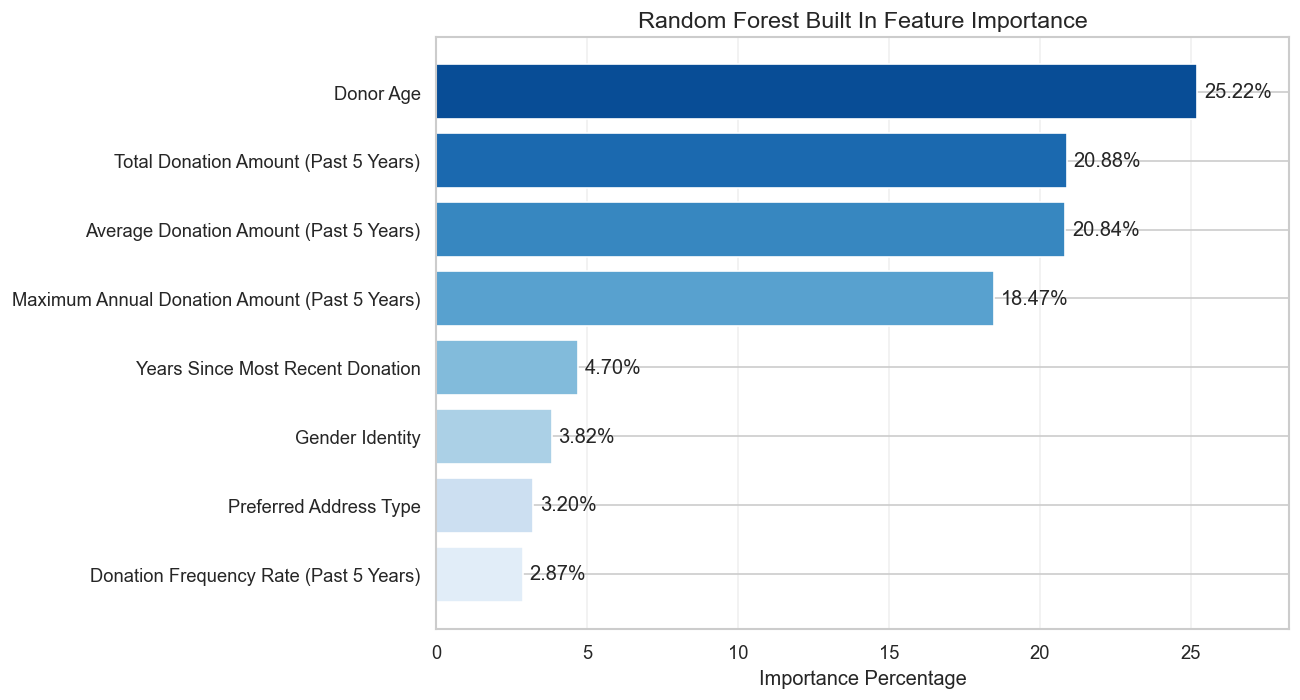

Importance Rank,Transformed Feature,Source Feature,Category Level,Business-Friendly Label,Built In Importance,Importance Percentage,Cumulative Importance Percentage
1,donor_age,donor_age,Not applicable,Donor Age,0.252192,25.22%,25.22%
2,feature_past_5yr_total_donation,feature_past_5yr_total_donation,Not applicable,Total Donation Amount (Past 5 Years),0.208825,20.88%,46.10%
3,feature_past_5yr_average_donation,feature_past_5yr_average_donation,Not applicable,Average Donation Amount (Past 5 Years),0.208400,20.84%,66.94%
4,feature_past_5yr_max_donation,feature_past_5yr_max_donation,Not applicable,Maximum Annual Donation Amount (Past 5 Years),0.184701,18.47%,85.41%
5,feature_years_since_last_donation_past_5yr,feature_years_since_last_donation_past_5yr,Not applicable,Years Since Most Recent Donation,0.046970,4.70%,90.11%
6,feature_past_5yr_donation_frequency_rate,feature_past_5yr_donation_frequency_rate,Not applicable,Donation Frequency Rate (Past 5 Years),0.028688,2.87%,92.98%
7,feature_gender_identity_Male,feature_gender_identity,Male,Gender Identity: Male,0.015680,1.57%,94.55%
8,feature_gender_identity_Female,feature_gender_identity,Female,Gender Identity: Female,0.014571,1.46%,96.00%
9,feature_preferred_address_type_Home,feature_preferred_address_type,Home Address,Preferred Address Type: Home Address,0.011995,1.20%,97.20%
10,feature_preferred_address_type_Missing,feature_preferred_address_type,Missing,Preferred Address Type: Missing,0.008809,0.88%,98.08%


Importance Rank,Source Feature,Business-Friendly Label,Representation,Transformed Columns,Built In Importance,Importance Percentage,Cumulative Importance Percentage
1,donor_age,Donor Age,Numeric,1,0.252192,25.22%,25.22%
2,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),Numeric,1,0.208825,20.88%,46.10%
3,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),Numeric,1,0.208400,20.84%,66.94%
4,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),Numeric,1,0.184701,18.47%,85.41%
5,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,Numeric,1,0.046970,4.70%,90.11%
6,feature_gender_identity,Gender Identity,One-Hot Encoded,3,0.038187,3.82%,93.93%
7,feature_preferred_address_type,Preferred Address Type,One-Hot Encoded,5,0.032039,3.20%,97.13%
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),Numeric,1,0.028688,2.87%,100.00%


Random Forest importance ranking completed successfully: 13/13 checks passed.
Transformed importance saved to: outputs/interpretability/tables/primary_builtin_importance_transformed.csv
Source importance saved to: outputs/interpretability/tables/primary_builtin_importance_source.csv
Importance figure saved to: outputs/interpretability/figures/primary_builtin_importance_source.png


In [9]:
# Calculate random forest feature importance ranking
importance_values_primary_transformed = np.asarray(
    classifier_primary_saved.feature_importances_,
    dtype=float,
)

importance_primary_transformed = (
    mapping_primary_transformed_features.copy()
)

importance_primary_transformed[
    "Built In Importance"
] = importance_values_primary_transformed

importance_primary_transformed[
    "Importance Percentage"
] = (
    importance_primary_transformed[
        "Built In Importance"
    ]
    * 100
)

importance_primary_transformed = (
    importance_primary_transformed
    .sort_values(
        "Built In Importance",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_transformed.insert(
    0,
    "Importance Rank",
    np.arange(
        1,
        importance_primary_transformed.shape[0] + 1,
    ),
)

importance_primary_transformed[
    "Cumulative Importance Percentage"
] = (
    importance_primary_transformed[
        "Importance Percentage"
    ].cumsum()
)

importance_primary_source_totals = (
    importance_primary_transformed
    .groupby(
        "Source Feature",
        as_index=False,
        sort=False,
    )
    .agg(
        **{
            "Built In Importance": (
                "Built In Importance",
                "sum",
            ),
            "Mapped Transformed Columns": (
                "Transformed Feature",
                "count",
            ),
        }
    )
)

importance_primary_source = (
    mapping_primary_source_features.merge(
        importance_primary_source_totals,
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
)

importance_primary_source[
    "Importance Percentage"
] = (
    importance_primary_source[
        "Built In Importance"
    ]
    * 100
)

importance_primary_source = (
    importance_primary_source
    .sort_values(
        "Built In Importance",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_source.insert(
    0,
    "Importance Rank",
    np.arange(
        1,
        importance_primary_source.shape[0] + 1,
    ),
)

importance_primary_source[
    "Cumulative Importance Percentage"
] = (
    importance_primary_source[
        "Importance Percentage"
    ].cumsum()
)

PRIMARY_TRANSFORMED_IMPORTANCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_builtin_importance_transformed.csv"
)

PRIMARY_SOURCE_IMPORTANCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_builtin_importance_source.csv"
)

PRIMARY_SOURCE_IMPORTANCE_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_builtin_importance_source.png"
)

importance_primary_transformed.to_csv(
    PRIMARY_TRANSFORMED_IMPORTANCE_PATH,
    index=False,
)

importance_primary_source.to_csv(
    PRIMARY_SOURCE_IMPORTANCE_PATH,
    index=False,
)

importance_primary_source_plot = (
    importance_primary_source
    .sort_values(
        "Built In Importance",
        ascending=True,
    )
)

figure_primary_source_importance, axis_primary_source_importance = (
    plt.subplots(figsize=(11, 6))
)

bars_primary_source_importance = (
    axis_primary_source_importance.barh(
        importance_primary_source_plot[
            "Business-Friendly Label"
        ],
        importance_primary_source_plot[
            "Importance Percentage"
        ],
        color=sns.color_palette(
            "Blues",
            n_colors=importance_primary_source_plot.shape[0],
        ),
    )
)

axis_primary_source_importance.bar_label(
    bars_primary_source_importance,
    labels=[
        f"{importance_percentage:.2f}%"
        for importance_percentage
        in importance_primary_source_plot[
            "Importance Percentage"
        ]
    ],
    padding=4,
)

axis_primary_source_importance.set_title(
    "Random Forest Built In Feature Importance"
)
axis_primary_source_importance.set_xlabel(
    "Importance Percentage"
)
axis_primary_source_importance.set_ylabel("")
axis_primary_source_importance.grid(
    axis="x",
    alpha=0.30,
)
axis_primary_source_importance.margins(x=0.12)

plt.tight_layout()

figure_primary_source_importance.savefig(
    PRIMARY_SOURCE_IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

grouped_importance_validation = (
    importance_primary_transformed
    .groupby("Source Feature")[
        "Built In Importance"
    ]
    .sum()
    .sort_index()
)

saved_source_importance_validation = (
    importance_primary_source
    .set_index("Source Feature")[
        "Built In Importance"
    ]
    .sort_index()
)

importance_ranking_checks = {
    "Classifier is a fitted Random Forest": (
        type(classifier_primary_saved).__name__
        == "RandomForestClassifier"
        and hasattr(
            classifier_primary_saved,
            "feature_importances_",
        )
    ),
    "Importance count matches transformed features": (
        importance_values_primary_transformed.shape[0]
        == len(features_primary_transformed)
        == mapping_primary_transformed_features.shape[0]
    ),
    "Transformed feature order matches the classifier input": (
        mapping_primary_transformed_features[
            "Transformed Feature"
        ].tolist()
        == list(features_primary_transformed)
    ),
    "Transformed importance values are finite": (
        np.isfinite(
            importance_values_primary_transformed
        ).all()
    ),
    "Transformed importance values are nonnegative": (
        (
            importance_values_primary_transformed
            >= 0
        ).all()
    ),
    "Transformed importance values sum to one": (
        np.isclose(
            importance_values_primary_transformed.sum(),
            1.0,
            rtol=0,
            atol=1e-12,
        )
    ),
    "All eight source features are ranked": (
        importance_primary_source.shape[0]
        == len(features_primary_saved)
        == 8
    ),
    "Source importance reproduces transformed aggregation": (
        np.allclose(
            grouped_importance_validation.to_numpy(),
            saved_source_importance_validation.to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "Source importance values sum to one": (
        np.isclose(
            importance_primary_source[
                "Built In Importance"
            ].sum(),
            1.0,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Transformed column counts remain consistent": (
        np.array_equal(
            importance_primary_source[
                "Transformed Columns"
            ].astype(int).to_numpy(),
            importance_primary_source[
                "Mapped Transformed Columns"
            ].astype(int).to_numpy(),
        )
    ),
    "Transformed importance ranks are complete": (
        np.array_equal(
            importance_primary_transformed[
                "Importance Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_transformed.shape[0] + 1,
            ),
        )
    ),
    "Source importance ranks are complete": (
        np.array_equal(
            importance_primary_source[
                "Importance Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_source.shape[0] + 1,
            ),
        )
    ),
    "Importance artifacts were saved": (
        PRIMARY_TRANSFORMED_IMPORTANCE_PATH.exists()
        and PRIMARY_SOURCE_IMPORTANCE_PATH.exists()
        and PRIMARY_SOURCE_IMPORTANCE_FIGURE_PATH.exists()
    ),
}

failed_importance_ranking_checks = [
    check_name
    for check_name, check_passed
    in importance_ranking_checks.items()
    if not check_passed
]

if failed_importance_ranking_checks:
    raise AssertionError(
        "Built in importance validation failed for: "
        + ", ".join(failed_importance_ranking_checks)
    )

display(
    importance_primary_transformed[
        [
            "Importance Rank",
            "Transformed Feature",
            "Source Feature",
            "Category Level",
            "Business-Friendly Label",
            "Built In Importance",
            "Importance Percentage",
            "Cumulative Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Importance Rank": "{:,.0f}",
            "Transformed Feature": "{}",
            "Source Feature": "{}",
            "Category Level": "{}",
            "Business-Friendly Label": "{}",
            "Built In Importance": "{:,.6f}",
            "Importance Percentage": "{:,.2f}%",
            "Cumulative Importance Percentage": "{:,.2f}%",
        }
    )
)

display(
    importance_primary_source[
        [
            "Importance Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Representation",
            "Transformed Columns",
            "Built In Importance",
            "Importance Percentage",
            "Cumulative Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Importance Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Representation": "{}",
            "Transformed Columns": "{:,.0f}",
            "Built In Importance": "{:,.6f}",
            "Importance Percentage": "{:,.2f}%",
            "Cumulative Importance Percentage": "{:,.2f}%",
        }
    )
)

print(
    "Random Forest importance ranking completed successfully: "
    f"{sum(importance_ranking_checks.values())}/"
    f"{len(importance_ranking_checks)} checks passed."
)
print(
    "Transformed importance saved to: "
    f"{PRIMARY_TRANSFORMED_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Source importance saved to: "
    f"{PRIMARY_SOURCE_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Importance figure saved to: "
    f"{PRIMARY_SOURCE_IMPORTANCE_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

## Interpretation Framework and Initial Feature Importance

The interpretation framework was defined to organize the analysis into six areas: global explanations, local explanations, outreach cohort analysis, error analysis, stability testing, and fairness review. Each area was assigned a clear purpose, evaluation dataset, planned method, reporting level, and safeguard. The finalized Phase 5 model, primary target, operating threshold, selection metric, and outreach capacities remain unchanged. Model scores will be treated as donor ranking scores rather than literal donation probabilities, and interpretation results will not be treated as causal relationships.

The Random Forest importance calculation was completed for all 14 transformed features and summarized across the eight original source features. Importance from the encoded gender identity and preferred address type columns was combined to provide one source level value for each predictor. All 13 importance validation checks passed, and the transformed ranking, source ranking, and source importance figure were saved as interpretation artifacts.

### Initial Importance Ranking

- Donor age ranked first with 25.22% of total importance.
- Total donation amount, average donation amount, and maximum annual donation amount followed with 20.88%, 20.84%, and 18.47%, respectively.
- Donor age and the three donation amount features account for 85.41% of total importance.
- The five historical donation features account for 67.76% of total importance when donation amount, recency, and frequency measures are combined.
- Gender identity contributes 3.82%, preferred address type contributes 3.20%, and donation frequency rate contributes 2.87%.

These results provide an initial view of how the Random Forest used its predictors when creating decision splits. They do not show whether a feature increases or decreases a donor score. Donor age may receive additional importance because it provides many possible split values, while related donation amount features may divide importance among themselves. Permutation importance and SHAP analysis will be used to determine whether these patterns remain consistent across other interpretation methods.


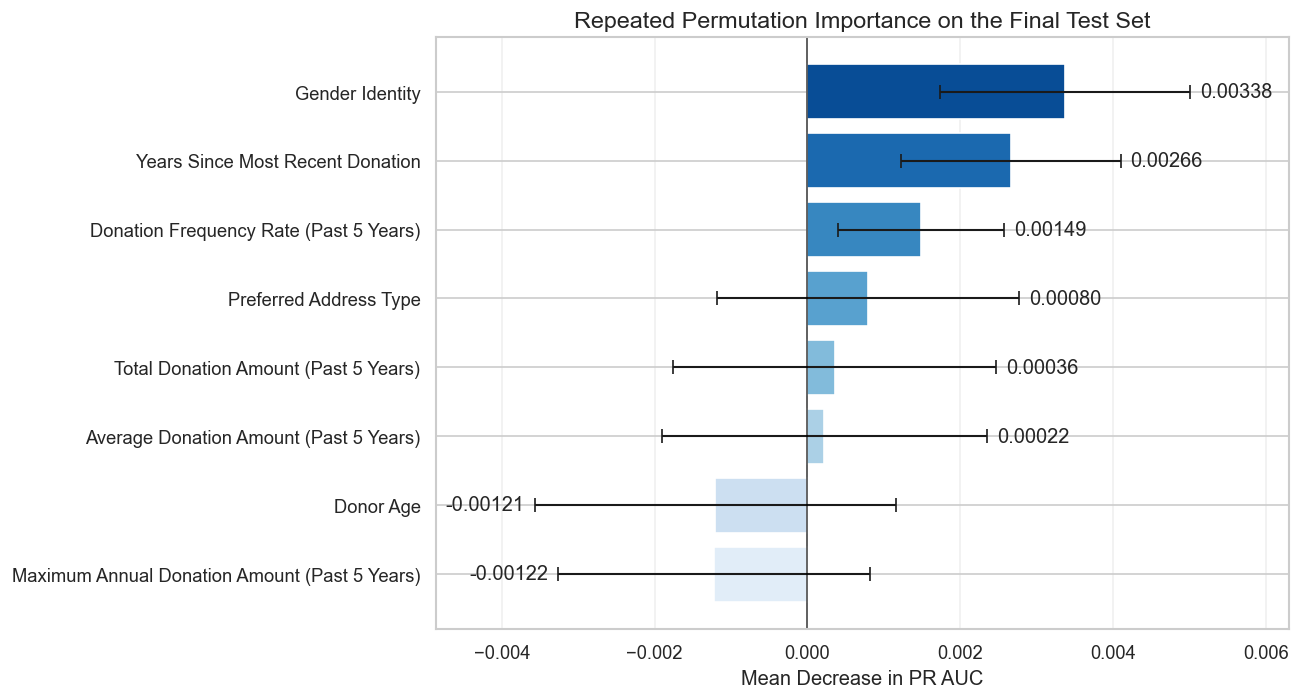

Permutation Rank,Source Feature,Business-Friendly Label,Mean PR AUC Decrease,Standard Deviation,Median PR AUC Decrease,Lower Percentile (2.5%),Upper Percentile (97.5%),Positive Repeat Percentage,Mean Permuted PR AUC
1,feature_gender_identity,Gender Identity,0.003378,0.001636,0.003321,0.000637,0.006649,96.67%,0.067013
2,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,0.002660,0.001440,0.002659,0.000205,0.005305,100.00%,0.067732
3,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),0.001486,0.001087,0.001544,-0.000603,0.003370,90.00%,0.068905
4,feature_preferred_address_type,Preferred Address Type,0.000797,0.001975,0.000477,-0.003205,0.004398,70.00%,0.069595
5,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),0.000356,0.002113,0.000585,-0.003550,0.003964,60.00%,0.070035
6,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),0.000221,0.002129,0.000804,-0.003613,0.003719,56.67%,0.070171
7,donor_age,Donor Age,-0.001206,0.002365,-0.001107,-0.005955,0.002475,33.33%,0.071598
8,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),-0.001223,0.002041,-0.001283,-0.005063,0.002596,30.00%,0.071615


Baseline final test PR AUC: 0.070392
Repeated permutation importance completed successfully: 17/17 checks passed.
Permutation repeats saved to: outputs/interpretability/tables/primary_permutation_importance_repeats.csv
Permutation summary saved to: outputs/interpretability/tables/primary_permutation_importance_summary.csv
Permutation figure saved to: outputs/interpretability/figures/primary_permutation_importance_pr_auc.png


In [10]:
# Calculate repeated permutation importance on final test set
baseline_pr_auc_primary_saved = average_precision_score(
    target_primary_test_interpretation,
    data_primary_test_interpretation[
        "prob_primary_donor"
    ].astype(float),
)

baseline_pr_auc_primary_pipeline = average_precision_score(
    target_primary_test_interpretation,
    probabilities_primary_test_recalculated,
)

permutation_result_primary = permutation_importance(
    estimator=model_primary_pipeline_final,
    X=features_primary_test_interpretation,
    y=target_primary_test_interpretation,
    scoring=INTERPRETATION_PRIMARY_METRIC,
    n_repeats=PERMUTATION_IMPORTANCE_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=PERMUTATION_IMPORTANCE_N_JOBS,
)

source_business_label_lookup = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Business-Friendly Label"
    ]
    .to_dict()
)

permutation_repeat_records = []

for source_position, source_feature_name in enumerate(
    features_primary_saved,
    start=1,
):
    feature_repeat_decreases = (
        permutation_result_primary.importances[
            source_position - 1
        ]
    )

    for repeat_number, pr_auc_decrease in enumerate(
        feature_repeat_decreases,
        start=1,
    ):
        permutation_repeat_records.append(
            {
                "Source Position": source_position,
                "Source Feature": source_feature_name,
                "Business-Friendly Label": (
                    source_business_label_lookup[
                        source_feature_name
                    ]
                ),
                "Repeat Number": repeat_number,
                "Baseline PR AUC": (
                    baseline_pr_auc_primary_pipeline
                ),
                "Permuted PR AUC": (
                    baseline_pr_auc_primary_pipeline
                    - pr_auc_decrease
                ),
                "PR AUC Decrease": pr_auc_decrease,
            }
        )

importance_primary_permutation_repeats = pd.DataFrame(
    permutation_repeat_records
)

permutation_summary_records = []

for source_position, source_feature_name in enumerate(
    features_primary_saved,
    start=1,
):
    feature_repeat_decreases = (
        permutation_result_primary.importances[
            source_position - 1
        ]
    )

    permutation_summary_records.append(
        {
            "Source Position": source_position,
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                source_business_label_lookup[
                    source_feature_name
                ]
            ),
            "Baseline PR AUC": (
                baseline_pr_auc_primary_pipeline
            ),
            "Mean PR AUC Decrease": float(
                feature_repeat_decreases.mean()
            ),
            "Standard Deviation": float(
                feature_repeat_decreases.std(ddof=0)
            ),
            "Median PR AUC Decrease": float(
                np.median(feature_repeat_decreases)
            ),
            "Lower Percentile (2.5%)": float(
                np.quantile(
                    feature_repeat_decreases,
                    0.025,
                )
            ),
            "Upper Percentile (97.5%)": float(
                np.quantile(
                    feature_repeat_decreases,
                    0.975,
                )
            ),
            "Minimum PR AUC Decrease": float(
                feature_repeat_decreases.min()
            ),
            "Maximum PR AUC Decrease": float(
                feature_repeat_decreases.max()
            ),
            "Positive Repeat Percentage": float(
                (
                    feature_repeat_decreases > 0
                ).mean()
                * 100
            ),
            "Mean Permuted PR AUC": float(
                baseline_pr_auc_primary_pipeline
                - feature_repeat_decreases.mean()
            ),
        }
    )

importance_primary_permutation = pd.DataFrame(
    permutation_summary_records
)

importance_primary_permutation = (
    importance_primary_permutation
    .sort_values(
        "Mean PR AUC Decrease",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_permutation.insert(
    0,
    "Permutation Rank",
    np.arange(
        1,
        importance_primary_permutation.shape[0] + 1,
    ),
)

PRIMARY_PERMUTATION_REPEATS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_permutation_importance_repeats.csv"
)

PRIMARY_PERMUTATION_SUMMARY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_permutation_importance_summary.csv"
)

PRIMARY_PERMUTATION_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_permutation_importance_pr_auc.png"
)

importance_primary_permutation_repeats.to_csv(
    PRIMARY_PERMUTATION_REPEATS_PATH,
    index=False,
)

importance_primary_permutation.to_csv(
    PRIMARY_PERMUTATION_SUMMARY_PATH,
    index=False,
)

importance_primary_permutation_plot = (
    importance_primary_permutation
    .sort_values(
        "Mean PR AUC Decrease",
        ascending=True,
    )
)

figure_primary_permutation, axis_primary_permutation = (
    plt.subplots(figsize=(11, 6))
)

bars_primary_permutation = axis_primary_permutation.barh(
    importance_primary_permutation_plot[
        "Business-Friendly Label"
    ],
    importance_primary_permutation_plot[
        "Mean PR AUC Decrease"
    ],
    xerr=importance_primary_permutation_plot[
        "Standard Deviation"
    ],
    color=sns.color_palette(
        "Blues",
        n_colors=importance_primary_permutation_plot.shape[0],
    ),
    error_kw={
        "elinewidth": 1.25,
        "capsize": 4,
    },
)

axis_primary_permutation.bar_label(
    bars_primary_permutation,
    labels=[
        f"{mean_decrease:.5f}"
        for mean_decrease
        in importance_primary_permutation_plot[
            "Mean PR AUC Decrease"
        ]
    ],
    padding=6,
)

axis_primary_permutation.axvline(
    0,
    color="black",
    linewidth=1,
    alpha=0.70,
)

axis_primary_permutation.set_title(
    "Repeated Permutation Importance on the Final Test Set"
)
axis_primary_permutation.set_xlabel(
    "Mean Decrease in PR AUC"
)
axis_primary_permutation.set_ylabel("")
axis_primary_permutation.grid(
    axis="x",
    alpha=0.30,
)
axis_primary_permutation.margins(x=0.15)

plt.tight_layout()

figure_primary_permutation.savefig(
    PRIMARY_PERMUTATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

permutation_summary_source_order = (
    importance_primary_permutation
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

repeat_counts_by_feature = (
    importance_primary_permutation_repeats
    .groupby("Source Feature")
    .size()
)

probabilities_primary_after_permutation = (
    model_primary_pipeline_final.predict_proba(
        features_primary_test_interpretation
    )[:, positive_class_index]
)

permutation_importance_checks = {
    "Permutation metric is average precision": (
        INTERPRETATION_PRIMARY_METRIC
        == "average_precision"
    ),
    "Final test source feature order is preserved": (
        list(
            features_primary_test_interpretation.columns
        )
        == list(features_primary_saved)
    ),
    "Saved and pipeline baseline PR AUC values match": (
        np.isclose(
            baseline_pr_auc_primary_saved,
            baseline_pr_auc_primary_pipeline,
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "Baseline PR AUC uses aligned final test records": (
        target_primary_test_interpretation.shape[0]
        == expected_primary_decisions[
            "final_test_records"
        ]
        == features_primary_test_interpretation.shape[0]
    ),
    "Permutation repeat count is valid": (
        isinstance(
            PERMUTATION_IMPORTANCE_REPEATS,
            int,
        )
        and PERMUTATION_IMPORTANCE_REPEATS > 1
    ),
    "Permutation result shape is correct": (
        permutation_result_primary.importances.shape
        == (
            len(features_primary_saved),
            PERMUTATION_IMPORTANCE_REPEATS,
        )
    ),
    "Permutation values are finite": (
        np.isfinite(
            permutation_result_primary.importances
        ).all()
    ),
    "Repeat table has the expected record count": (
        importance_primary_permutation_repeats.shape[0]
        == (
            len(features_primary_saved)
            * PERMUTATION_IMPORTANCE_REPEATS
        )
    ),
    "Every source feature has all repetitions": (
        repeat_counts_by_feature.eq(
            PERMUTATION_IMPORTANCE_REPEATS
        ).all()
        and repeat_counts_by_feature.shape[0]
        == len(features_primary_saved)
    ),
    "All eight source features are summarized": (
        importance_primary_permutation.shape[0]
        == len(features_primary_saved)
        == 8
    ),
    "Summary means reproduce the permutation result": (
        np.allclose(
            permutation_summary_source_order[
                "Mean PR AUC Decrease"
            ].to_numpy(),
            permutation_result_primary.importances_mean,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Summary deviations reproduce the permutation result": (
        np.allclose(
            permutation_summary_source_order[
                "Standard Deviation"
            ].to_numpy(),
            permutation_result_primary.importances_std,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Percentile ranges are ordered correctly": (
        (
            importance_primary_permutation[
                "Lower Percentile (2.5%)"
            ]
            <= importance_primary_permutation[
                "Median PR AUC Decrease"
            ]
        ).all()
        and (
            importance_primary_permutation[
                "Median PR AUC Decrease"
            ]
            <= importance_primary_permutation[
                "Upper Percentile (97.5%)"
            ]
        ).all()
    ),
    "All source features have business labels": (
        importance_primary_permutation[
            "Business-Friendly Label"
        ].notna().all()
        and importance_primary_permutation[
            "Business-Friendly Label"
        ].is_unique
    ),
    "Permutation ranking is descending": (
        importance_primary_permutation[
            "Mean PR AUC Decrease"
        ].is_monotonic_decreasing
        and np.array_equal(
            importance_primary_permutation[
                "Permutation Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_permutation.shape[0] + 1,
            ),
        )
    ),
    "Permutation did not modify model predictions": (
        np.allclose(
            probabilities_primary_after_permutation,
            probabilities_primary_test_recalculated,
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "Permutation artifacts were saved": (
        PRIMARY_PERMUTATION_REPEATS_PATH.exists()
        and PRIMARY_PERMUTATION_SUMMARY_PATH.exists()
        and PRIMARY_PERMUTATION_FIGURE_PATH.exists()
    ),
}

failed_permutation_importance_checks = [
    check_name
    for check_name, check_passed
    in permutation_importance_checks.items()
    if not check_passed
]

if failed_permutation_importance_checks:
    raise AssertionError(
        "Permutation importance validation failed for: "
        + ", ".join(
            failed_permutation_importance_checks
        )
    )

display(
    importance_primary_permutation[
        [
            "Permutation Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Mean PR AUC Decrease",
            "Standard Deviation",
            "Median PR AUC Decrease",
            "Lower Percentile (2.5%)",
            "Upper Percentile (97.5%)",
            "Positive Repeat Percentage",
            "Mean Permuted PR AUC",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Permutation Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Mean PR AUC Decrease": "{:,.6f}",
            "Standard Deviation": "{:,.6f}",
            "Median PR AUC Decrease": "{:,.6f}",
            "Lower Percentile (2.5%)": "{:,.6f}",
            "Upper Percentile (97.5%)": "{:,.6f}",
            "Positive Repeat Percentage": "{:,.2f}%",
            "Mean Permuted PR AUC": "{:,.6f}",
        }
    )
)

print(
    "Baseline final test PR AUC: "
    f"{baseline_pr_auc_primary_pipeline:.6f}"
)
print(
    "Repeated permutation importance completed successfully: "
    f"{sum(permutation_importance_checks.values())}/"
    f"{len(permutation_importance_checks)} checks passed."
)
print(
    "Permutation repeats saved to: "
    f"{PRIMARY_PERMUTATION_REPEATS_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Permutation summary saved to: "
    f"{PRIMARY_PERMUTATION_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Permutation figure saved to: "
    f"{PRIMARY_PERMUTATION_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

In [11]:
# Configure SHAP and validate model output reconstruction
SHAP_FEATURE_PERTURBATION = "tree_path_dependent"
SHAP_MODEL_OUTPUT = "raw"
SHAP_ADDITIVITY_TOLERANCE = 1e-8

if hasattr(
    features_primary_test_transformed,
    "toarray",
):
    features_primary_test_shap_array = (
        features_primary_test_transformed.toarray()
    )
else:
    features_primary_test_shap_array = np.asarray(
        features_primary_test_transformed
    )

features_primary_test_shap_array = np.asarray(
    features_primary_test_shap_array,
    dtype=float,
)

shap_test_record_count = (
    features_primary_test_shap_array.shape[0]
)
shap_transformed_feature_count = (
    features_primary_test_shap_array.shape[1]
)

classes_primary_shap = np.asarray(
    classifier_primary_saved.classes_
)

positive_class_index_shap = int(
    np.flatnonzero(
        classes_primary_shap == 1
    )[0]
)

explainer_primary_shap = shap.TreeExplainer(
    classifier_primary_saved,
    feature_perturbation=SHAP_FEATURE_PERTURBATION,
    model_output=SHAP_MODEL_OUTPUT,
)

explanation_primary_shap_raw = (
    explainer_primary_shap(
        features_primary_test_shap_array,
        check_additivity=False,
    )
)

shap_values_primary_raw = np.asarray(
    explanation_primary_shap_raw.values
)

shap_base_values_primary_raw = np.asarray(
    explanation_primary_shap_raw.base_values
)

if (
    shap_values_primary_raw.ndim == 3
    and shap_values_primary_raw.shape
    == (
        shap_test_record_count,
        shap_transformed_feature_count,
        classes_primary_shap.size,
    )
):
    shap_values_primary_positive = (
        shap_values_primary_raw[
            :,
            :,
            positive_class_index_shap,
        ]
    )
    shap_value_layout_primary = (
        "Records by features by classes"
    )

elif (
    shap_values_primary_raw.ndim == 3
    and shap_values_primary_raw.shape
    == (
        classes_primary_shap.size,
        shap_test_record_count,
        shap_transformed_feature_count,
    )
):
    shap_values_primary_positive = (
        shap_values_primary_raw[
            positive_class_index_shap,
            :,
            :,
        ]
    )
    shap_value_layout_primary = (
        "Classes by records by features"
    )

elif (
    shap_values_primary_raw.ndim == 2
    and shap_values_primary_raw.shape
    == (
        shap_test_record_count,
        shap_transformed_feature_count,
    )
):
    shap_values_primary_positive = (
        shap_values_primary_raw.copy()
    )
    shap_value_layout_primary = (
        "Records by features"
    )

else:
    raise ValueError(
        "Unsupported SHAP value shape: "
        f"{shap_values_primary_raw.shape}"
    )

if shap_base_values_primary_raw.ndim == 0:
    shap_base_values_primary_positive = np.full(
        shap_test_record_count,
        float(shap_base_values_primary_raw),
    )

elif (
    shap_base_values_primary_raw.ndim == 1
    and shap_base_values_primary_raw.size
    == classes_primary_shap.size
):
    shap_base_values_primary_positive = np.full(
        shap_test_record_count,
        float(
            shap_base_values_primary_raw[
                positive_class_index_shap
            ]
        ),
    )

elif (
    shap_base_values_primary_raw.ndim == 1
    and shap_base_values_primary_raw.size
    == shap_test_record_count
):
    shap_base_values_primary_positive = (
        shap_base_values_primary_raw.astype(float)
    )

elif (
    shap_base_values_primary_raw.ndim == 2
    and shap_base_values_primary_raw.shape
    == (
        shap_test_record_count,
        classes_primary_shap.size,
    )
):
    shap_base_values_primary_positive = (
        shap_base_values_primary_raw[
            :,
            positive_class_index_shap,
        ].astype(float)
    )

elif (
    shap_base_values_primary_raw.ndim == 2
    and shap_base_values_primary_raw.shape
    == (
        classes_primary_shap.size,
        shap_test_record_count,
    )
):
    shap_base_values_primary_positive = (
        shap_base_values_primary_raw[
            positive_class_index_shap,
            :,
        ].astype(float)
    )

elif (
    shap_base_values_primary_raw.ndim == 2
    and shap_base_values_primary_raw.shape
    == (
        shap_test_record_count,
        1,
    )
):
    shap_base_values_primary_positive = (
        shap_base_values_primary_raw[
            :,
            0,
        ].astype(float)
    )

else:
    raise ValueError(
        "Unsupported SHAP base value shape: "
        f"{shap_base_values_primary_raw.shape}"
    )

probabilities_primary_classifier_shap = (
    classifier_primary_saved.predict_proba(
        features_primary_test_shap_array
    )[:, positive_class_index_shap]
)

probabilities_primary_pipeline_shap = (
    model_primary_pipeline_final.predict_proba(
        features_primary_test_interpretation
    )[:, positive_class_index_shap]
)

probabilities_primary_reconstructed_shap = (
    shap_base_values_primary_positive
    + shap_values_primary_positive.sum(axis=1)
)

errors_primary_shap_additivity = (
    probabilities_primary_reconstructed_shap
    - probabilities_primary_classifier_shap
)

absolute_errors_primary_shap_additivity = np.abs(
    errors_primary_shap_additivity
)

mean_absolute_error_primary_shap = float(
    absolute_errors_primary_shap_additivity.mean()
)

maximum_absolute_error_primary_shap = float(
    absolute_errors_primary_shap_additivity.max()
)

shap_additivity_passed = np.allclose(
    probabilities_primary_reconstructed_shap,
    probabilities_primary_classifier_shap,
    rtol=SHAP_ADDITIVITY_TOLERANCE,
    atol=SHAP_ADDITIVITY_TOLERANCE,
)

explanation_primary_shap = shap.Explanation(
    values=shap_values_primary_positive,
    base_values=shap_base_values_primary_positive,
    data=features_primary_test_shap_array,
    feature_names=list(
        features_primary_transformed
    ),
)

shap_value_column_names = [
    f"shap_value__{transformed_feature_name}"
    for transformed_feature_name
    in features_primary_transformed
]

values_primary_shap_final_test = pd.DataFrame(
    shap_values_primary_positive,
    columns=shap_value_column_names,
)

values_primary_shap_final_test.insert(
    0,
    "test_record_position",
    np.arange(
        1,
        shap_test_record_count + 1,
    ),
)

values_primary_shap_final_test.insert(
    1,
    "target_actual_primary_donor_flag",
    target_primary_test_interpretation
    .astype(int)
    .to_numpy(),
)

values_primary_shap_final_test.insert(
    2,
    "prob_primary_donor",
    probabilities_primary_classifier_shap,
)

values_primary_shap_final_test.insert(
    3,
    "shap_base_value_primary_donor",
    shap_base_values_primary_positive,
)

values_primary_shap_final_test.insert(
    4,
    "shap_reconstructed_prob_primary_donor",
    probabilities_primary_reconstructed_shap,
)

values_primary_shap_final_test.insert(
    5,
    "shap_additivity_absolute_error",
    absolute_errors_primary_shap_additivity,
)

configuration_primary_shap = pd.DataFrame(
    [
        {
            "Explainer": "TreeExplainer",
            "Feature Perturbation": (
                SHAP_FEATURE_PERTURBATION
            ),
            "Explained Output": (
                "Positive class probability"
            ),
            "Records": shap_test_record_count,
            "Transformed Features": (
                shap_transformed_feature_count
            ),
            "Positive Class": int(
                classes_primary_shap[
                    positive_class_index_shap
                ]
            ),
            "Raw SHAP Shape": str(
                shap_values_primary_raw.shape
            ),
            "Raw SHAP Layout": (
                shap_value_layout_primary
            ),
            "Mean Base Value": float(
                shap_base_values_primary_positive.mean()
            ),
            "Mean Model Output": float(
                probabilities_primary_classifier_shap.mean()
            ),
            "Mean Reconstructed Output": float(
                probabilities_primary_reconstructed_shap.mean()
            ),
            "Mean Absolute Error": (
                mean_absolute_error_primary_shap
            ),
            "Maximum Absolute Error": (
                maximum_absolute_error_primary_shap
            ),
            "Additivity Tolerance": (
                SHAP_ADDITIVITY_TOLERANCE
            ),
            "Status": (
                "PASS"
                if shap_additivity_passed
                else "FAIL"
            ),
        }
    ]
)

PRIMARY_SHAP_CONFIGURATION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_configuration.csv"
)

PRIMARY_SHAP_VALUES_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_values_final_test.csv"
)

configuration_primary_shap.to_csv(
    PRIMARY_SHAP_CONFIGURATION_PATH,
    index=False,
)

values_primary_shap_final_test.to_csv(
    PRIMARY_SHAP_VALUES_PATH,
    index=False,
)

shap_configuration_checks = {
    "Explainer uses the finalized Random Forest": (
        type(classifier_primary_saved).__name__
        == "RandomForestClassifier"
        and explainer_primary_shap.model is not None
    ),
    "SHAP input contains all final test records": (
        shap_test_record_count
        == expected_primary_decisions[
            "final_test_records"
        ]
        == features_primary_test_interpretation.shape[0]
    ),
    "SHAP input contains all transformed features": (
        shap_transformed_feature_count
        == expected_primary_decisions[
            "transformed_feature_count"
        ]
        == len(features_primary_transformed)
    ),
    "Transformed feature order is preserved": (
        mapping_primary_transformed_features[
            "Transformed Feature"
        ].tolist()
        == list(features_primary_transformed)
    ),
    "Positive class index is correct": (
        classes_primary_shap[
            positive_class_index_shap
        ]
        == 1
        and positive_class_index_shap
        == positive_class_index
    ),
    "Positive class SHAP matrix shape is correct": (
        shap_values_primary_positive.shape
        == (
            shap_test_record_count,
            shap_transformed_feature_count,
        )
    ),
    "Positive class base value shape is correct": (
        shap_base_values_primary_positive.shape
        == (shap_test_record_count,)
    ),
    "SHAP values and base values are finite": (
        np.isfinite(
            shap_values_primary_positive
        ).all()
        and np.isfinite(
            shap_base_values_primary_positive
        ).all()
    ),
    "Classifier and pipeline outputs match": (
        np.allclose(
            probabilities_primary_classifier_shap,
            probabilities_primary_pipeline_shap,
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "SHAP model outputs match saved probabilities": (
        np.allclose(
            probabilities_primary_classifier_shap,
            data_primary_test_interpretation[
                "prob_primary_donor"
            ].astype(float),
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "SHAP reconstruction matches model outputs": (
        shap_additivity_passed
    ),
    "Maximum additivity error is within tolerance": (
        maximum_absolute_error_primary_shap
        <= SHAP_ADDITIVITY_TOLERANCE
    ),
    "Reconstructed outputs remain valid probabilities": (
        (
            probabilities_primary_reconstructed_shap
            >= -SHAP_ADDITIVITY_TOLERANCE
        ).all()
        and (
            probabilities_primary_reconstructed_shap
            <= 1 + SHAP_ADDITIVITY_TOLERANCE
        ).all()
    ),
    "SHAP Explanation object is aligned": (
        explanation_primary_shap.values.shape
        == (
            shap_test_record_count,
            shap_transformed_feature_count,
        )
        and list(
            explanation_primary_shap.feature_names
        )
        == list(features_primary_transformed)
    ),
    "Saved SHAP table preserves test row order": (
        np.array_equal(
            values_primary_shap_final_test[
                "test_record_position"
            ].to_numpy(),
            np.arange(
                1,
                shap_test_record_count + 1,
            ),
        )
        and np.array_equal(
            values_primary_shap_final_test[
                "target_actual_primary_donor_flag"
            ].to_numpy(),
            target_primary_test_interpretation
            .astype(int)
            .to_numpy(),
        )
    ),
    "Saved SHAP table excludes donor identifiers": (
        "donor_unique_id"
        not in values_primary_shap_final_test.columns
    ),
    "SHAP configuration reports PASS": (
        configuration_primary_shap.loc[
            0,
            "Status",
        ]
        == "PASS"
    ),
    "SHAP artifacts were saved": (
        PRIMARY_SHAP_CONFIGURATION_PATH.exists()
        and PRIMARY_SHAP_VALUES_PATH.exists()
    ),
}

failed_shap_configuration_checks = [
    check_name
    for check_name, check_passed
    in shap_configuration_checks.items()
    if not check_passed
]

if failed_shap_configuration_checks:
    raise AssertionError(
        "SHAP configuration validation failed for: "
        + ", ".join(
            failed_shap_configuration_checks
        )
    )

display(
    configuration_primary_shap.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Explainer": "{}",
            "Feature Perturbation": "{}",
            "Explained Output": "{}",
            "Records": "{:,.0f}",
            "Transformed Features": "{:,.0f}",
            "Positive Class": "{:,.0f}",
            "Raw SHAP Shape": "{}",
            "Raw SHAP Layout": "{}",
            "Mean Base Value": "{:,.8f}",
            "Mean Model Output": "{:,.8f}",
            "Mean Reconstructed Output": "{:,.8f}",
            "Mean Absolute Error": "{:,.2e}",
            "Maximum Absolute Error": "{:,.2e}",
            "Additivity Tolerance": "{:,.2e}",
            "Status": "{}",
        }
    )
)

print(
    "SHAP configuration and additivity validation completed: "
    f"{sum(shap_configuration_checks.values())}/"
    f"{len(shap_configuration_checks)} checks passed."
)
print(
    "SHAP configuration saved to: "
    f"{PRIMARY_SHAP_CONFIGURATION_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Final test SHAP values saved to: "
    f"{PRIMARY_SHAP_VALUES_PATH.relative_to(PROJECT_ROOT)}"
)

Explainer,Feature Perturbation,Explained Output,Records,Transformed Features,Positive Class,Raw SHAP Shape,Raw SHAP Layout,Mean Base Value,Mean Model Output,Mean Reconstructed Output,Mean Absolute Error,Maximum Absolute Error,Additivity Tolerance,Status
TreeExplainer,tree_path_dependent,Positive class probability,"6,881",14,1,"(6881, 14, 2)",Records by features by classes,0.05528196,0.05514503,0.05514503,1.14e-16,3.89e-15,1.00e-08,PASS


SHAP configuration and additivity validation completed: 18/18 checks passed.
SHAP configuration saved to: outputs/interpretability/tables/primary_shap_configuration.csv
Final test SHAP values saved to: outputs/interpretability/tables/primary_shap_values_final_test.csv


## Permutation Importance and SHAP Validation
Repeated permutation importance was calculated on the final test set using average precision. Each source feature was shuffled 30 times while the remaining features were unchanged. The baseline PR AUC was 0.0704, and a larger positive decrease indicates a greater effect on predictive performance.

### Permutation Importance Findings
- Gender identity ranked first with a mean PR AUC decrease of 0.0034 and was positive in 96.67% of repetitions.
- Years since the most recent donation ranked second with a mean decrease of 0.0027 and was positive in all repetitions.
- Donation frequency rate ranked third with a mean decrease of 0.0015 and was positive in 90.00% of repetitions.
- Preferred address type and the donation amount features produced small or inconsistent effects.
- Donor age and maximum annual donation amount produced slightly negative average decreases.

Only gender identity and years since the most recent donation had percentile ranges entirely above zero. The remaining effects are less certain because their ranges crossed zero. Related donation amount features may also compensate for one another when an individual feature is shuffled, explaining their lower permutation importance compared with the Random Forest ranking.

### SHAP Configuration and Validation

TreeSHAP was configured for the finalized Random Forest using all 6,881 final test records and 14 transformed features. The base value and SHAP feature contributions were validated against the model output for every donor.
- The mean model output and reconstructed output both equal 0.0551.
- The mean absolute reconstruction error was $1.14 \times 10^{-16}$.
- The maximum reconstruction error was $3.89 \times 10^{-15}$, below the $1.00 \times 10^{-8}$ tolerance.

All 18 SHAP checks passed, confirming that the SHAP values accurately reproduce the Random Forest outputs. The configuration and final test SHAP values were saved for the global and local explanation analyses without exposing donor identifiers.


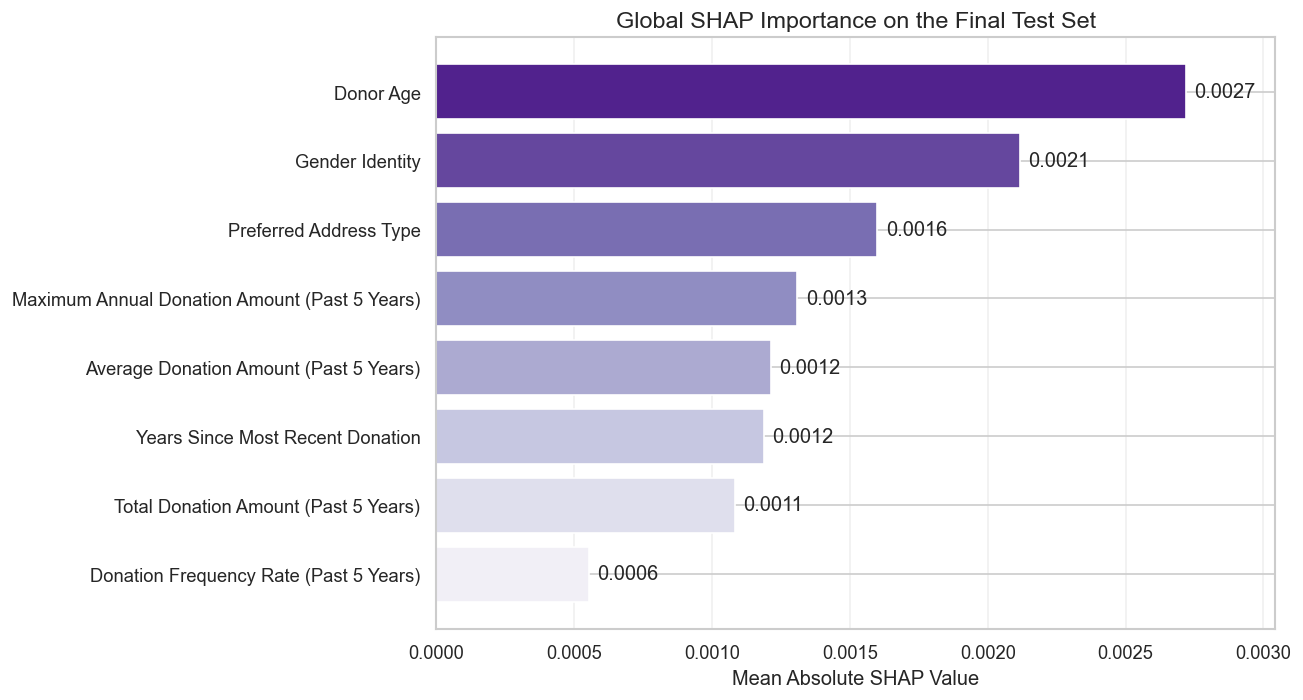

SHAP Rank,Source Feature,Business-Friendly Label,Transformed Columns,Mean Absolute SHAP,Importance Percentage,Cumulative Importance Percentage
1,donor_age,Donor Age,1,0.0027,23.07%,23.07%
2,feature_gender_identity,Gender Identity,3,0.0021,17.97%,41.04%
3,feature_preferred_address_type,Preferred Address Type,5,0.0016,13.58%,54.61%
4,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),1,0.0013,11.12%,65.73%
5,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),1,0.0012,10.29%,76.03%
6,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,1,0.0012,10.09%,86.12%
7,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),1,0.0011,9.20%,95.31%
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),1,0.0006,4.69%,100.00%


SHAP Rank,Transformed Feature,Source Feature,Category Level,Business-Friendly Label,Mean Absolute SHAP,Importance Percentage,Cumulative Importance Percentage
1,donor_age,donor_age,Not applicable,Donor Age,0.002717,21.88%,21.88%
2,feature_past_5yr_max_donation,feature_past_5yr_max_donation,Not applicable,Maximum Annual Donation Amount (Past 5 Years),0.001310,10.55%,32.43%
3,feature_past_5yr_average_donation,feature_past_5yr_average_donation,Not applicable,Average Donation Amount (Past 5 Years),0.001213,9.77%,42.19%
4,feature_years_since_last_donation_past_5yr,feature_years_since_last_donation_past_5yr,Not applicable,Years Since Most Recent Donation,0.001189,9.57%,51.76%
5,feature_gender_identity_Male,feature_gender_identity,Male,Gender Identity: Male,0.001169,9.41%,61.18%
6,feature_past_5yr_total_donation,feature_past_5yr_total_donation,Not applicable,Total Donation Amount (Past 5 Years),0.001083,8.72%,69.90%
7,feature_gender_identity_Female,feature_gender_identity,Female,Gender Identity: Female,0.000804,6.47%,76.37%
8,feature_preferred_address_type_Missing,feature_preferred_address_type,Missing,Preferred Address Type: Missing,0.000789,6.36%,82.73%
9,feature_preferred_address_type_Home,feature_preferred_address_type,Home Address,Preferred Address Type: Home Address,0.000729,5.87%,88.60%
10,feature_past_5yr_donation_frequency_rate,feature_past_5yr_donation_frequency_rate,Not applicable,Donation Frequency Rate (Past 5 Years),0.000552,4.45%,93.05%


Global SHAP importance ranking completed successfully: 19/19 checks passed.
Source SHAP importance saved to: outputs/interpretability/tables/primary_shap_importance_source.csv
Transformed SHAP importance saved to: outputs/interpretability/tables/primary_shap_importance_transformed.csv
Source SHAP values saved to: outputs/interpretability/tables/primary_shap_values_source_final_test.csv
SHAP importance figure saved to: outputs/interpretability/figures/primary_shap_importance_source.png


In [12]:
# Calculate global SHAP importance rankings
mean_absolute_shap_primary_transformed = np.mean(
    np.abs(shap_values_primary_positive),
    axis=0,
)

importance_primary_shap_transformed = (
    mapping_primary_transformed_features.copy()
)

importance_primary_shap_transformed[
    "Mean Absolute SHAP"
] = mean_absolute_shap_primary_transformed

total_shap_importance_primary_transformed = float(
    importance_primary_shap_transformed[
        "Mean Absolute SHAP"
    ].sum()
)

importance_primary_shap_transformed[
    "Importance Percentage"
] = (
    importance_primary_shap_transformed[
        "Mean Absolute SHAP"
    ]
    / total_shap_importance_primary_transformed
    * 100
)

importance_primary_shap_transformed = (
    importance_primary_shap_transformed
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_shap_transformed.insert(
    0,
    "SHAP Rank",
    np.arange(
        1,
        importance_primary_shap_transformed.shape[0] + 1,
    ),
)

importance_primary_shap_transformed[
    "Cumulative Importance Percentage"
] = (
    importance_primary_shap_transformed[
        "Importance Percentage"
    ].cumsum()
)

business_label_lookup_primary_shap_source = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Business-Friendly Label"
    ]
    .to_dict()
)

transformed_count_lookup_primary_shap_source = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Transformed Columns"
    ]
    .astype(int)
    .to_dict()
)

source_names_primary_shap_mapping = (
    mapping_primary_transformed_features[
        "Source Feature"
    ].to_numpy()
)

shap_values_primary_source_columns = []

for source_feature_name in features_primary_saved:
    transformed_positions_for_source = np.flatnonzero(
        source_names_primary_shap_mapping
        == source_feature_name
    )

    source_contributions_primary_shap = (
        shap_values_primary_positive[
            :,
            transformed_positions_for_source,
        ].sum(axis=1)
    )

    shap_values_primary_source_columns.append(
        source_contributions_primary_shap
    )

shap_values_primary_source_array = np.column_stack(
    shap_values_primary_source_columns
)

source_shap_value_column_names = [
    f"shap_value_source__{source_feature_name}"
    for source_feature_name
    in features_primary_saved
]

values_primary_shap_source_final_test = pd.DataFrame(
    shap_values_primary_source_array,
    columns=source_shap_value_column_names,
)

values_primary_shap_source_final_test.insert(
    0,
    "test_record_position",
    np.arange(
        1,
        shap_test_record_count + 1,
    ),
)

values_primary_shap_source_final_test.insert(
    1,
    "target_actual_primary_donor_flag",
    target_primary_test_interpretation
    .astype(int)
    .to_numpy(),
)

values_primary_shap_source_final_test.insert(
    2,
    "prob_primary_donor",
    probabilities_primary_classifier_shap,
)

source_shap_importance_records = []

for source_position, source_feature_name in enumerate(
    features_primary_saved,
    start=1,
):
    source_contributions_primary_shap = (
        shap_values_primary_source_array[
            :,
            source_position - 1,
        ]
    )

    source_shap_importance_records.append(
        {
            "Source Position": source_position,
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                business_label_lookup_primary_shap_source[
                    source_feature_name
                ]
            ),
            "Transformed Columns": (
                transformed_count_lookup_primary_shap_source[
                    source_feature_name
                ]
            ),
            "Mean Absolute SHAP": float(
                np.mean(
                    np.abs(
                        source_contributions_primary_shap
                    )
                )
            ),
        }
    )

importance_primary_shap_source = pd.DataFrame(
    source_shap_importance_records
)

total_shap_importance_primary_source = float(
    importance_primary_shap_source[
        "Mean Absolute SHAP"
    ].sum()
)

importance_primary_shap_source[
    "Importance Percentage"
] = (
    importance_primary_shap_source[
        "Mean Absolute SHAP"
    ]
    / total_shap_importance_primary_source
    * 100
)

importance_primary_shap_source = (
    importance_primary_shap_source
    .sort_values(
        "Mean Absolute SHAP",
        ascending=False,
        kind="stable",
    )
    .reset_index(drop=True)
)

importance_primary_shap_source.insert(
    0,
    "SHAP Rank",
    np.arange(
        1,
        importance_primary_shap_source.shape[0] + 1,
    ),
)

importance_primary_shap_source[
    "Cumulative Importance Percentage"
] = (
    importance_primary_shap_source[
        "Importance Percentage"
    ].cumsum()
)

PRIMARY_SHAP_TRANSFORMED_IMPORTANCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_importance_transformed.csv"
)

PRIMARY_SHAP_SOURCE_IMPORTANCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_importance_source.csv"
)

PRIMARY_SHAP_SOURCE_VALUES_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_values_source_final_test.csv"
)

PRIMARY_SHAP_SOURCE_IMPORTANCE_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_shap_importance_source.png"
)

importance_primary_shap_transformed.to_csv(
    PRIMARY_SHAP_TRANSFORMED_IMPORTANCE_PATH,
    index=False,
)

importance_primary_shap_source.to_csv(
    PRIMARY_SHAP_SOURCE_IMPORTANCE_PATH,
    index=False,
)

values_primary_shap_source_final_test.to_csv(
    PRIMARY_SHAP_SOURCE_VALUES_PATH,
    index=False,
)

importance_primary_shap_source_plot = (
    importance_primary_shap_source
    .sort_values(
        "Mean Absolute SHAP",
        ascending=True,
    )
)

figure_primary_shap_importance, axis_primary_shap_importance = (
    plt.subplots(figsize=(11, 6))
)

bars_primary_shap_importance = (
    axis_primary_shap_importance.barh(
        importance_primary_shap_source_plot[
            "Business-Friendly Label"
        ],
        importance_primary_shap_source_plot[
            "Mean Absolute SHAP"
        ],
        color=sns.color_palette(
            "Purples",
            n_colors=importance_primary_shap_source_plot.shape[0],
        ),
    )
)

axis_primary_shap_importance.bar_label(
    bars_primary_shap_importance,
    labels=[
        f"{mean_absolute_shap:.4f}"
        for mean_absolute_shap
        in importance_primary_shap_source_plot[
            "Mean Absolute SHAP"
        ]
    ],
    padding=5,
)

axis_primary_shap_importance.set_title(
    "Global SHAP Importance on the Final Test Set"
)
axis_primary_shap_importance.set_xlabel(
    "Mean Absolute SHAP Value"
)
axis_primary_shap_importance.set_ylabel("")
axis_primary_shap_importance.grid(
    axis="x",
    alpha=0.30,
)
axis_primary_shap_importance.margins(x=0.12)

plt.tight_layout()

figure_primary_shap_importance.savefig(
    PRIMARY_SHAP_SOURCE_IMPORTANCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

source_shap_reconstructed_outputs = (
    shap_base_values_primary_positive
    + shap_values_primary_source_array.sum(axis=1)
)

source_importance_validation_order = (
    importance_primary_shap_source
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

expected_source_mean_absolute_shap = np.mean(
    np.abs(shap_values_primary_source_array),
    axis=0,
)

global_shap_importance_checks = {
    "SHAP values contain all final test records": (
        shap_values_primary_positive.shape[0]
        == expected_primary_decisions[
            "final_test_records"
        ]
    ),
    "SHAP values contain all transformed features": (
        shap_values_primary_positive.shape[1]
        == expected_primary_decisions[
            "transformed_feature_count"
        ]
        == len(features_primary_transformed)
    ),
    "Transformed feature order is preserved": (
        mapping_primary_transformed_features[
            "Transformed Feature"
        ].tolist()
        == list(features_primary_transformed)
    ),
    "Transformed SHAP values are finite": (
        np.isfinite(
            shap_values_primary_positive
        ).all()
    ),
    "Transformed SHAP importance values are nonnegative": (
        (
            importance_primary_shap_transformed[
                "Mean Absolute SHAP"
            ]
            >= 0
        ).all()
    ),
    "All transformed features are ranked": (
        importance_primary_shap_transformed.shape[0]
        == len(features_primary_transformed)
        == 14
    ),
    "Transformed importance percentages sum to 100": (
        np.isclose(
            importance_primary_shap_transformed[
                "Importance Percentage"
            ].sum(),
            100.0,
            rtol=0,
            atol=1e-10,
        )
    ),
    "Source SHAP matrix has the correct shape": (
        shap_values_primary_source_array.shape
        == (
            expected_primary_decisions[
                "final_test_records"
            ],
            len(features_primary_saved),
        )
    ),
    "Source contributions reproduce transformed contributions": (
        np.allclose(
            shap_values_primary_source_array.sum(axis=1),
            shap_values_primary_positive.sum(axis=1),
            rtol=0,
            atol=1e-12,
        )
    ),
    "Source SHAP values reproduce model outputs": (
        np.allclose(
            source_shap_reconstructed_outputs,
            probabilities_primary_classifier_shap,
            rtol=SHAP_ADDITIVITY_TOLERANCE,
            atol=SHAP_ADDITIVITY_TOLERANCE,
        )
    ),
    "Source SHAP importance values are nonnegative": (
        (
            importance_primary_shap_source[
                "Mean Absolute SHAP"
            ]
            >= 0
        ).all()
    ),
    "All source features are ranked": (
        importance_primary_shap_source.shape[0]
        == len(features_primary_saved)
        == 8
    ),
    "Source importance values reproduce direct calculation": (
        np.allclose(
            source_importance_validation_order[
                "Mean Absolute SHAP"
            ].to_numpy(),
            expected_source_mean_absolute_shap,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Source importance percentages sum to 100": (
        np.isclose(
            importance_primary_shap_source[
                "Importance Percentage"
            ].sum(),
            100.0,
            rtol=0,
            atol=1e-10,
        )
    ),
    "Transformed SHAP ranking is descending": (
        importance_primary_shap_transformed[
            "Mean Absolute SHAP"
        ].is_monotonic_decreasing
        and np.array_equal(
            importance_primary_shap_transformed[
                "SHAP Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_shap_transformed.shape[0] + 1,
            ),
        )
    ),
    "Source SHAP ranking is descending": (
        importance_primary_shap_source[
            "Mean Absolute SHAP"
        ].is_monotonic_decreasing
        and np.array_equal(
            importance_primary_shap_source[
                "SHAP Rank"
            ].to_numpy(),
            np.arange(
                1,
                importance_primary_shap_source.shape[0] + 1,
            ),
        )
    ),
    "All SHAP features have business labels": (
        importance_primary_shap_transformed[
            "Business-Friendly Label"
        ].notna().all()
        and importance_primary_shap_source[
            "Business-Friendly Label"
        ].notna().all()
    ),
    "Saved source SHAP values preserve privacy and row order": (
        "donor_unique_id"
        not in values_primary_shap_source_final_test.columns
        and np.array_equal(
            values_primary_shap_source_final_test[
                "test_record_position"
            ].to_numpy(),
            np.arange(
                1,
                shap_test_record_count + 1,
            ),
        )
    ),
    "Global SHAP artifacts were saved": (
        PRIMARY_SHAP_TRANSFORMED_IMPORTANCE_PATH.exists()
        and PRIMARY_SHAP_SOURCE_IMPORTANCE_PATH.exists()
        and PRIMARY_SHAP_SOURCE_VALUES_PATH.exists()
        and PRIMARY_SHAP_SOURCE_IMPORTANCE_FIGURE_PATH.exists()
    ),
}

failed_global_shap_importance_checks = [
    check_name
    for check_name, check_passed
    in global_shap_importance_checks.items()
    if not check_passed
]

if failed_global_shap_importance_checks:
    raise AssertionError(
        "Global SHAP importance validation failed for: "
        + ", ".join(
            failed_global_shap_importance_checks
        )
    )

display(
    importance_primary_shap_source[
        [
            "SHAP Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Transformed Columns",
            "Mean Absolute SHAP",
            "Importance Percentage",
            "Cumulative Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Transformed Columns": "{:,.0f}",
            "Mean Absolute SHAP": "{:,.4f}",
            "Importance Percentage": "{:,.2f}%",
            "Cumulative Importance Percentage": "{:,.2f}%",
        }
    )
)

display(
    importance_primary_shap_transformed[
        [
            "SHAP Rank",
            "Transformed Feature",
            "Source Feature",
            "Category Level",
            "Business-Friendly Label",
            "Mean Absolute SHAP",
            "Importance Percentage",
            "Cumulative Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Transformed Feature": "{}",
            "Source Feature": "{}",
            "Category Level": "{}",
            "Business-Friendly Label": "{}",
            "Mean Absolute SHAP": "{:,.6f}",
            "Importance Percentage": "{:,.2f}%",
            "Cumulative Importance Percentage": "{:,.2f}%",
        }
    )
)

print(
    "Global SHAP importance ranking completed successfully: "
    f"{sum(global_shap_importance_checks.values())}/"
    f"{len(global_shap_importance_checks)} checks passed."
)
print(
    "Source SHAP importance saved to: "
    f"{PRIMARY_SHAP_SOURCE_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Transformed SHAP importance saved to: "
    f"{PRIMARY_SHAP_TRANSFORMED_IMPORTANCE_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Source SHAP values saved to: "
    f"{PRIMARY_SHAP_SOURCE_VALUES_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "SHAP importance figure saved to: "
    f"{PRIMARY_SHAP_SOURCE_IMPORTANCE_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

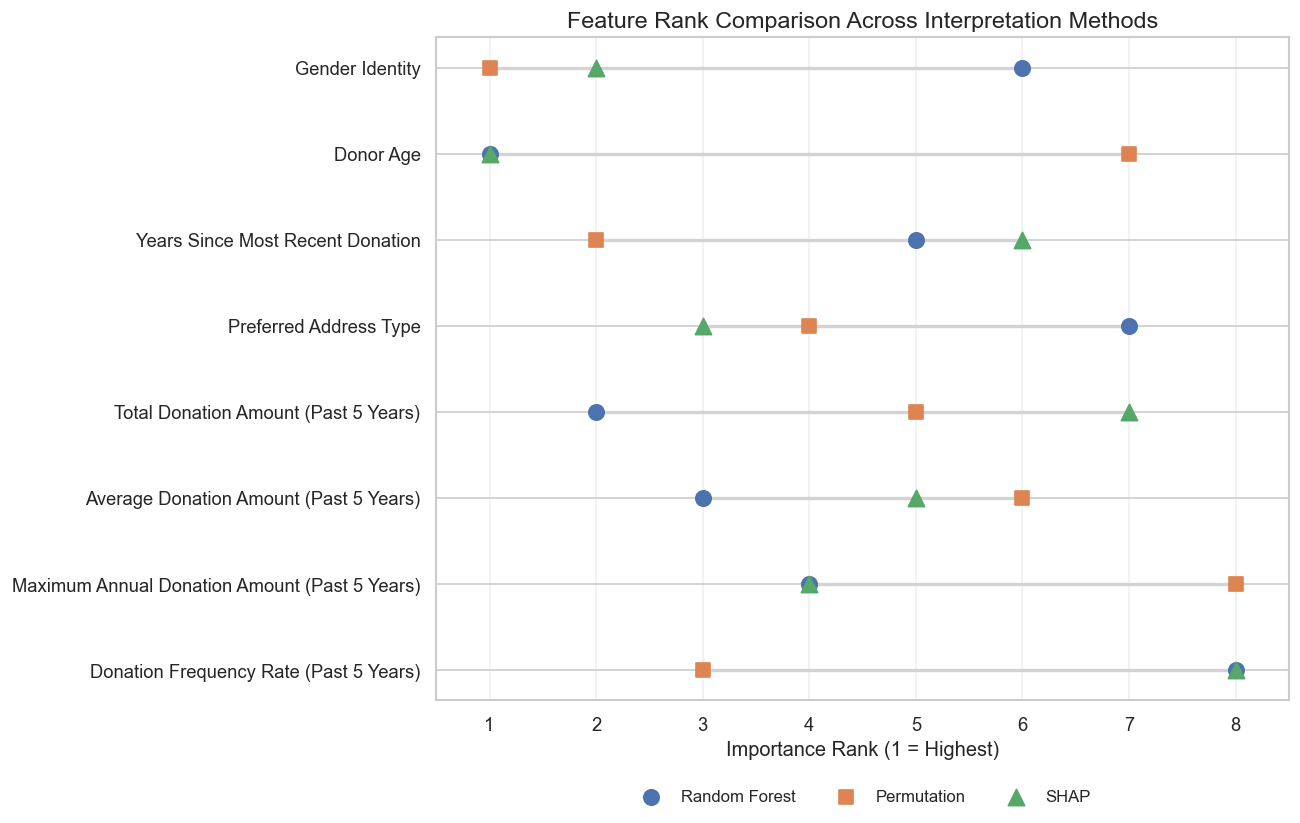

Consensus Rank,Source Feature,Business-Friendly Label,Random Forest Rank,Permutation Rank,SHAP Rank,Mean Rank,Rank Range,Top Four Method Count,Stable Positive Permutation,Support Classification
1,feature_gender_identity,Gender Identity,6,1,2,3.00,5,2,Yes,Consistent Held Out Support
2,donor_age,Donor Age,1,7,1,3.00,6,2,No,Model Structure Support Only
3,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,5,2,6,4.33,4,1,Yes,Stable Held Out Support
4,feature_preferred_address_type,Preferred Address Type,7,4,3,4.67,4,2,No,Moderate Cross Method Support
5,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),2,5,7,4.67,5,1,No,Mixed Support
6,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),3,6,5,4.67,3,1,No,Mixed Support
7,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),4,8,4,5.33,4,2,No,Model Structure Support Only
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),8,3,8,6.33,5,1,No,Mixed Support


Business-Friendly Label,Random Forest Importance Percentage,Mean PR AUC Decrease,Positive Repeat Percentage,Lower Percentile (2.5%),Upper Percentile (97.5%),Mean Absolute SHAP,SHAP Importance Percentage
Gender Identity,3.82%,0.0034,96.67%,0.0006,0.0066,0.0021,17.97%
Donor Age,25.22%,-0.0012,33.33%,-0.0060,0.0025,0.0027,23.07%
Years Since Most Recent Donation,4.70%,0.0027,100.00%,0.0002,0.0053,0.0012,10.09%
Preferred Address Type,3.20%,0.0008,70.00%,-0.0032,0.0044,0.0016,13.58%
Total Donation Amount (Past 5 Years),20.88%,0.0004,60.00%,-0.0035,0.0040,0.0011,9.20%
Average Donation Amount (Past 5 Years),20.84%,0.0002,56.67%,-0.0036,0.0037,0.0012,10.29%
Maximum Annual Donation Amount (Past 5 Years),18.47%,-0.0012,30.00%,-0.0051,0.0026,0.0013,11.12%
Donation Frequency Rate (Past 5 Years),2.87%,0.0015,90.00%,-0.0006,0.0034,0.0006,4.69%


,Random Forest Rank,Permutation Rank,SHAP Rank
Random Forest Rank,1.00,-0.64,0.26
Permutation Rank,-0.64,1.00,-0.19
SHAP Rank,0.26,-0.19,1.00


Importance method comparison completed successfully: 18/18 checks passed.
Importance comparison saved to: outputs/interpretability/tables/primary_importance_method_comparison.csv
Rank correlations saved to: outputs/interpretability/tables/primary_importance_rank_correlations.csv
Rank comparison figure saved to: outputs/interpretability/figures/primary_importance_rank_comparison.png


In [13]:
# Compare feature importance across three methods
IMPORTANCE_TOP_RANK_THRESHOLD = int(
    np.ceil(
        len(features_primary_saved) / 2
    )
)

comparison_primary_random_forest = (
    importance_primary_source[
        [
            "Source Feature",
            "Business-Friendly Label",
            "Importance Rank",
            "Importance Percentage",
        ]
    ]
    .rename(
        columns={
            "Importance Rank": "Random Forest Rank",
            "Importance Percentage": (
                "Random Forest Importance Percentage"
            ),
        }
    )
)

comparison_primary_permutation = (
    importance_primary_permutation[
        [
            "Source Feature",
            "Permutation Rank",
            "Mean PR AUC Decrease",
            "Lower Percentile (2.5%)",
            "Upper Percentile (97.5%)",
            "Positive Repeat Percentage",
        ]
    ].copy()
)

comparison_primary_shap = (
    importance_primary_shap_source[
        [
            "Source Feature",
            "SHAP Rank",
            "Mean Absolute SHAP",
            "Importance Percentage",
        ]
    ]
    .rename(
        columns={
            "Importance Percentage": (
                "SHAP Importance Percentage"
            ),
        }
    )
)

comparison_primary_importance_methods = (
    comparison_primary_random_forest
    .merge(
        comparison_primary_permutation,
        on="Source Feature",
        how="inner",
        validate="one_to_one",
    )
    .merge(
        comparison_primary_shap,
        on="Source Feature",
        how="inner",
        validate="one_to_one",
    )
)

rank_columns_primary_importance = [
    "Random Forest Rank",
    "Permutation Rank",
    "SHAP Rank",
]

comparison_primary_importance_methods[
    "Mean Rank"
] = (
    comparison_primary_importance_methods[
        rank_columns_primary_importance
    ].mean(axis=1)
)

comparison_primary_importance_methods[
    "Rank Range"
] = (
    comparison_primary_importance_methods[
        rank_columns_primary_importance
    ].max(axis=1)
    - comparison_primary_importance_methods[
        rank_columns_primary_importance
    ].min(axis=1)
)

comparison_primary_importance_methods[
    "Random Forest Top Four"
] = (
    comparison_primary_importance_methods[
        "Random Forest Rank"
    ]
    <= IMPORTANCE_TOP_RANK_THRESHOLD
)

comparison_primary_importance_methods[
    "Permutation Top Four"
] = (
    (
        comparison_primary_importance_methods[
            "Permutation Rank"
        ]
        <= IMPORTANCE_TOP_RANK_THRESHOLD
    )
    & (
        comparison_primary_importance_methods[
            "Mean PR AUC Decrease"
        ]
        > 0
    )
)

comparison_primary_importance_methods[
    "SHAP Top Four"
] = (
    comparison_primary_importance_methods[
        "SHAP Rank"
    ]
    <= IMPORTANCE_TOP_RANK_THRESHOLD
)

comparison_primary_importance_methods[
    "Top Four Method Count"
] = (
    comparison_primary_importance_methods[
        [
            "Random Forest Top Four",
            "Permutation Top Four",
            "SHAP Top Four",
        ]
    ]
    .sum(axis=1)
    .astype(int)
)

comparison_primary_importance_methods[
    "Stable Positive Permutation"
] = (
    comparison_primary_importance_methods[
        "Lower Percentile (2.5%)"
    ]
    > 0
)


def classify_importance_support(
    comparison_row,
):
    random_forest_top = comparison_row[
        "Random Forest Top Four"
    ]
    permutation_top = comparison_row[
        "Permutation Top Four"
    ]
    shap_top = comparison_row[
        "SHAP Top Four"
    ]
    stable_permutation = comparison_row[
        "Stable Positive Permutation"
    ]
    positive_permutation = (
        comparison_row[
            "Mean PR AUC Decrease"
        ]
        > 0
    )
    top_method_count = comparison_row[
        "Top Four Method Count"
    ]

    if (
        random_forest_top
        and permutation_top
        and shap_top
        and stable_permutation
    ):
        return "Strong Support Across All Methods"

    if (
        stable_permutation
        and top_method_count >= 2
    ):
        return "Consistent Held Out Support"

    if stable_permutation:
        return "Stable Held Out Support"

    if (
        positive_permutation
        and top_method_count >= 2
    ):
        return "Moderate Cross Method Support"

    if (
        random_forest_top
        and shap_top
        and not positive_permutation
    ):
        return "Model Structure Support Only"

    if top_method_count >= 1:
        return "Mixed Support"

    return "Limited Support"


comparison_primary_importance_methods[
    "Support Classification"
] = (
    comparison_primary_importance_methods.apply(
        classify_importance_support,
        axis=1,
    )
)

comparison_primary_importance_methods = (
    comparison_primary_importance_methods
    .sort_values(
        [
            "Mean Rank",
            "Top Four Method Count",
            "Positive Repeat Percentage",
        ],
        ascending=[
            True,
            False,
            False,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

comparison_primary_importance_methods.insert(
    0,
    "Consensus Rank",
    np.arange(
        1,
        comparison_primary_importance_methods.shape[0] + 1,
    ),
)

correlation_primary_importance_ranks = (
    comparison_primary_importance_methods[
        rank_columns_primary_importance
    ]
    .corr(method="spearman")
)

comparison_primary_importance_display = (
    comparison_primary_importance_methods.copy()
)

comparison_primary_importance_display[
    "Stable Positive Permutation"
] = np.where(
    comparison_primary_importance_display[
        "Stable Positive Permutation"
    ],
    "Yes",
    "No",
)

PRIMARY_IMPORTANCE_METHOD_COMPARISON_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_importance_method_comparison.csv"
)

PRIMARY_IMPORTANCE_RANK_CORRELATION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_importance_rank_correlations.csv"
)

PRIMARY_IMPORTANCE_RANK_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_importance_rank_comparison.png"
)

comparison_primary_importance_methods.to_csv(
    PRIMARY_IMPORTANCE_METHOD_COMPARISON_PATH,
    index=False,
)

correlation_primary_importance_ranks.to_csv(
    PRIMARY_IMPORTANCE_RANK_CORRELATION_PATH,
)

comparison_primary_importance_plot = (
    comparison_primary_importance_methods
    .sort_values(
        "Consensus Rank",
        ascending=True,
    )
)

plot_positions_primary_importance = np.arange(
    comparison_primary_importance_plot.shape[0]
)

figure_primary_importance_comparison, axis_primary_importance_comparison = (
    plt.subplots(figsize=(11, 7))
)

for plot_position, comparison_row in (
    comparison_primary_importance_plot.iterrows()
):
    row_ranks = comparison_row[
        rank_columns_primary_importance
    ].astype(float)

    axis_primary_importance_comparison.hlines(
        y=plot_position,
        xmin=row_ranks.min(),
        xmax=row_ranks.max(),
        color="lightgray",
        linewidth=2,
        zorder=1,
    )

axis_primary_importance_comparison.scatter(
    comparison_primary_importance_plot[
        "Random Forest Rank"
    ],
    plot_positions_primary_importance,
    label="Random Forest",
    marker="o",
    s=85,
    zorder=3,
)

axis_primary_importance_comparison.scatter(
    comparison_primary_importance_plot[
        "Permutation Rank"
    ],
    plot_positions_primary_importance,
    label="Permutation",
    marker="s",
    s=80,
    zorder=3,
)

axis_primary_importance_comparison.scatter(
    comparison_primary_importance_plot[
        "SHAP Rank"
    ],
    plot_positions_primary_importance,
    label="SHAP",
    marker="^",
    s=95,
    zorder=3,
)

axis_primary_importance_comparison.set_yticks(
    plot_positions_primary_importance
)

axis_primary_importance_comparison.set_yticklabels(
    comparison_primary_importance_plot[
        "Business-Friendly Label"
    ]
)

axis_primary_importance_comparison.invert_yaxis()

axis_primary_importance_comparison.set_xticks(
    np.arange(
        1,
        len(features_primary_saved) + 1,
    )
)

axis_primary_importance_comparison.set_xlim(
    0.5,
    len(features_primary_saved) + 0.5,
)

axis_primary_importance_comparison.set_title(
    "Feature Rank Comparison Across Interpretation Methods"
)

axis_primary_importance_comparison.set_xlabel(
    "Importance Rank (1 = Highest)"
)

axis_primary_importance_comparison.set_ylabel("")

axis_primary_importance_comparison.grid(
    axis="x",
    alpha=0.30,
)

axis_primary_importance_comparison.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
)

plt.tight_layout()

figure_primary_importance_comparison.savefig(
    PRIMARY_IMPORTANCE_RANK_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

comparison_primary_source_order = (
    comparison_primary_importance_methods
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

random_forest_primary_source_order = (
    importance_primary_source
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

permutation_primary_source_order = (
    importance_primary_permutation
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

shap_primary_source_order = (
    importance_primary_shap_source
    .set_index("Source Feature")
    .loc[features_primary_saved]
)

comparison_rank_values = (
    comparison_primary_importance_methods[
        rank_columns_primary_importance
    ].to_numpy()
)

expected_mean_ranks = comparison_rank_values.mean(
    axis=1
)

expected_rank_ranges = (
    comparison_rank_values.max(axis=1)
    - comparison_rank_values.min(axis=1)
)

expected_top_four_counts = (
    comparison_primary_importance_methods[
        [
            "Random Forest Top Four",
            "Permutation Top Four",
            "SHAP Top Four",
        ]
    ]
    .sum(axis=1)
    .astype(int)
    .to_numpy()
)

importance_method_comparison_checks = {
    "All eight source features are compared": (
        comparison_primary_importance_methods.shape[0]
        == len(features_primary_saved)
        == 8
    ),
    "Source feature identities are complete": (
        set(
            comparison_primary_importance_methods[
                "Source Feature"
            ]
        )
        == set(features_primary_saved)
    ),
    "Source features are unique": (
        comparison_primary_importance_methods[
            "Source Feature"
        ].is_unique
    ),
    "Comparison table contains no missing values": (
        comparison_primary_importance_methods
        .notna()
        .all()
        .all()
    ),
    "Random Forest ranks are complete": (
        set(
            comparison_primary_importance_methods[
                "Random Forest Rank"
            ].astype(int)
        )
        == set(
            range(
                1,
                len(features_primary_saved) + 1,
            )
        )
    ),
    "Permutation ranks are complete": (
        set(
            comparison_primary_importance_methods[
                "Permutation Rank"
            ].astype(int)
        )
        == set(
            range(
                1,
                len(features_primary_saved) + 1,
            )
        )
    ),
    "SHAP ranks are complete": (
        set(
            comparison_primary_importance_methods[
                "SHAP Rank"
            ].astype(int)
        )
        == set(
            range(
                1,
                len(features_primary_saved) + 1,
            )
        )
    ),
    "Random Forest metrics match the source ranking": (
        np.allclose(
            comparison_primary_source_order[
                "Random Forest Importance Percentage"
            ].to_numpy(),
            random_forest_primary_source_order[
                "Importance Percentage"
            ].to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "Permutation metrics match the source ranking": (
        np.allclose(
            comparison_primary_source_order[
                "Mean PR AUC Decrease"
            ].to_numpy(),
            permutation_primary_source_order[
                "Mean PR AUC Decrease"
            ].to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "SHAP metrics match the source ranking": (
        np.allclose(
            comparison_primary_source_order[
                "Mean Absolute SHAP"
            ].to_numpy(),
            shap_primary_source_order[
                "Mean Absolute SHAP"
            ].to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "Mean ranks are calculated correctly": (
        np.allclose(
            comparison_primary_importance_methods[
                "Mean Rank"
            ].to_numpy(),
            expected_mean_ranks,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Rank ranges are calculated correctly": (
        np.array_equal(
            comparison_primary_importance_methods[
                "Rank Range"
            ].to_numpy(),
            expected_rank_ranges,
        )
    ),
    "Top four method counts are correct": (
        np.array_equal(
            comparison_primary_importance_methods[
                "Top Four Method Count"
            ].to_numpy(),
            expected_top_four_counts,
        )
    ),
    "Stable permutation flags match the percentile rule": (
        np.array_equal(
            comparison_primary_importance_methods[
                "Stable Positive Permutation"
            ].to_numpy(),
            (
                comparison_primary_importance_methods[
                    "Lower Percentile (2.5%)"
                ]
                > 0
            ).to_numpy(),
        )
    ),
    "Consensus ranks are complete": (
        np.array_equal(
            comparison_primary_importance_methods[
                "Consensus Rank"
            ].to_numpy(),
            np.arange(
                1,
                comparison_primary_importance_methods.shape[0] + 1,
            ),
        )
        and comparison_primary_importance_methods[
            "Mean Rank"
        ].is_monotonic_increasing
    ),
    "Rank correlation matrix is valid": (
        correlation_primary_importance_ranks.shape
        == (3, 3)
        and np.allclose(
            correlation_primary_importance_ranks,
            correlation_primary_importance_ranks.T,
            rtol=0,
            atol=1e-12,
        )
        and np.allclose(
            np.diag(
                correlation_primary_importance_ranks
            ),
            1.0,
            rtol=0,
            atol=1e-12,
        )
    ),
    "All features have business labels and support classes": (
        comparison_primary_importance_methods[
            "Business-Friendly Label"
        ].notna().all()
        and comparison_primary_importance_methods[
            "Support Classification"
        ].notna().all()
    ),
    "Comparison artifacts were saved": (
        PRIMARY_IMPORTANCE_METHOD_COMPARISON_PATH.exists()
        and PRIMARY_IMPORTANCE_RANK_CORRELATION_PATH.exists()
        and PRIMARY_IMPORTANCE_RANK_FIGURE_PATH.exists()
    ),
}

failed_importance_method_comparison_checks = [
    check_name
    for check_name, check_passed
    in importance_method_comparison_checks.items()
    if not check_passed
]

if failed_importance_method_comparison_checks:
    raise AssertionError(
        "Importance method comparison failed for: "
        + ", ".join(
            failed_importance_method_comparison_checks
        )
    )

display(
    comparison_primary_importance_display[
        [
            "Consensus Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Random Forest Rank",
            "Permutation Rank",
            "SHAP Rank",
            "Mean Rank",
            "Rank Range",
            "Top Four Method Count",
            "Stable Positive Permutation",
            "Support Classification",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Consensus Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Random Forest Rank": "{:,.0f}",
            "Permutation Rank": "{:,.0f}",
            "SHAP Rank": "{:,.0f}",
            "Mean Rank": "{:,.2f}",
            "Rank Range": "{:,.0f}",
            "Top Four Method Count": "{:,.0f}",
            "Stable Positive Permutation": "{}",
            "Support Classification": "{}",
        }
    )
)

display(
    comparison_primary_importance_display[
        [
            "Business-Friendly Label",
            "Random Forest Importance Percentage",
            "Mean PR AUC Decrease",
            "Positive Repeat Percentage",
            "Lower Percentile (2.5%)",
            "Upper Percentile (97.5%)",
            "Mean Absolute SHAP",
            "SHAP Importance Percentage",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Business-Friendly Label": "{}",
            "Random Forest Importance Percentage": "{:,.2f}%",
            "Mean PR AUC Decrease": "{:,.4f}",
            "Positive Repeat Percentage": "{:,.2f}%",
            "Lower Percentile (2.5%)": "{:,.4f}",
            "Upper Percentile (97.5%)": "{:,.4f}",
            "Mean Absolute SHAP": "{:,.4f}",
            "SHAP Importance Percentage": "{:,.2f}%",
        }
    )
)

display(
    correlation_primary_importance_ranks.style
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Random Forest Rank": "{:,.2f}",
            "Permutation Rank": "{:,.2f}",
            "SHAP Rank": "{:,.2f}",
        }
    )
)

print(
    "Importance method comparison completed successfully: "
    f"{sum(importance_method_comparison_checks.values())}/"
    f"{len(importance_method_comparison_checks)} checks passed."
)
print(
    "Importance comparison saved to: "
    f"{PRIMARY_IMPORTANCE_METHOD_COMPARISON_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Rank correlations saved to: "
    f"{PRIMARY_IMPORTANCE_RANK_CORRELATION_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Rank comparison figure saved to: "
    f"{PRIMARY_IMPORTANCE_RANK_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

## Global SHAP Importance and Method Comparison

Global SHAP importance was calculated using the mean absolute SHAP value for every feature across the final test set. The 14 transformed features were also combined into the eight original source features. For categorical predictors, the encoded SHAP contributions were added for each donor before calculating the source level importance.

### Global SHAP Findings
- Donor age ranked first with 23.07% of total SHAP importance.
- Gender identity ranked second with 17.97%.
- Preferred address type ranked third with 13.58%.
- The top three features account for 54.61% of total SHAP importance.
- The five historical donation features collectively account for 45.39%.
- Donation frequency rate ranked last with 4.69%.

Mean absolute SHAP measures the average size of each feature’s contribution but does not show whether the contribution raises or lowers the donor score. All 19 global SHAP validation checks passed, and the source and transformed rankings were saved with the source SHAP values and importance figure.

### Importance Method Comparison

The Random Forest, permutation, and SHAP rankings were compared using their rank positions and original importance metrics. The comparison also evaluated whether each feature had a stable positive permutation effect on final test PR AUC.

- Gender identity received the strongest combined support. It ranked first for permutation importance, second for SHAP, and sixth for Random Forest importance.
- Donor age ranked second by consensus but received model structure support only. It ranked first for Random Forest and SHAP but seventh for permutation importance with a negative average effect.
- Years since the most recent donation ranked third by consensus and showed stable held out support. Its permutation effect remained positive across all repetitions.
- Preferred address type received moderate support from permutation and SHAP, although its permutation range crossed zero.
- Maximum annual donation amount ranked fourth for Random Forest and SHAP but last for permutation importance.
- No feature received strong support across all three methods.

The rank correlations were -0.64 between Random Forest and permutation importance, 0.26 between Random Forest and SHAP, and -0.19 between permutation importance and SHAP. These results show that the methods measure different parts of model behavior. Random Forest importance measures split usage, permutation importance measures the effect on final test performance, and SHAP measures average contribution size. Related donation variables may also compensate for one another when one feature is shuffled.

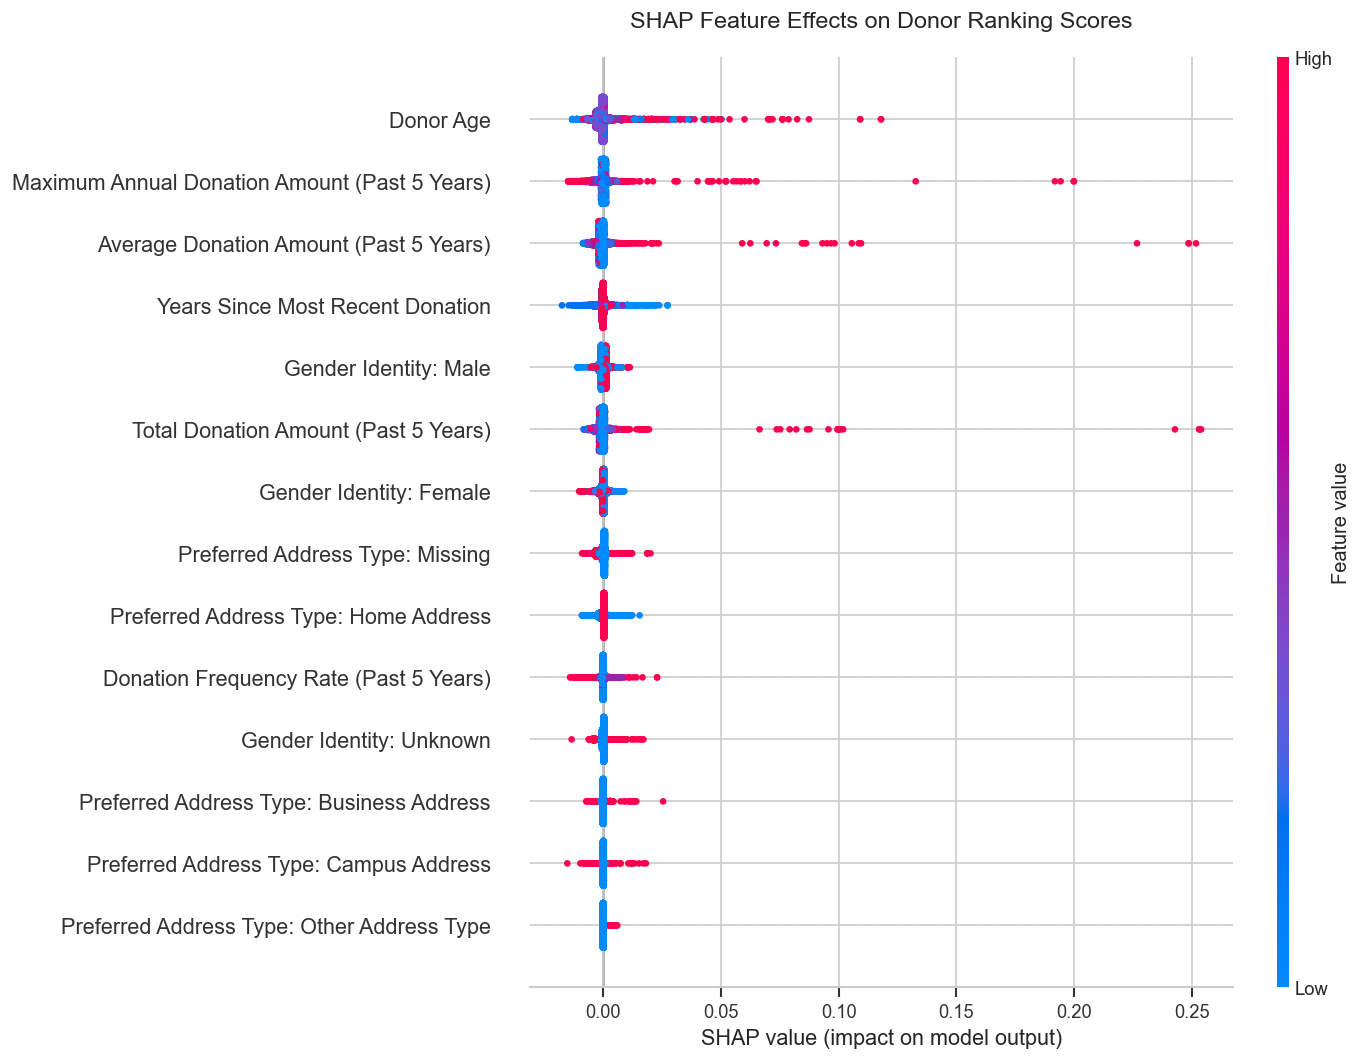

SHAP Rank,Source Feature,Business-Friendly Label,Records Used,Missing Records,Spearman Correlation,Direction Strength,Lower Value Threshold,Higher Value Threshold,Lower Group Mean SHAP,Higher Group Mean SHAP,Higher Minus Lower Mean SHAP,General Direction
1,donor_age,Donor Age,"6,881",0,0.1594,Weak,41.0000,43.0000,0.000327,0.004036,0.003709,Higher Values Generally Increase Score
4,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),"6,881",0,-0.2233,Weak,0.0000,1.0000,0.000219,-0.000179,-0.000398,Lower Values Generally Increase Score
5,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),"6,881",0,-0.2490,Weak,0.0000,0.2000,-0.000054,-0.000003,0.000052,Weak or Near Neutral Pattern
6,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,"6,881",0,0.0963,Minimal,4.0000,6.0000,-0.000035,-0.000077,-0.000043,Weak or Near Neutral Pattern
7,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),"6,881",0,-0.1447,Weak,0.0000,1.0000,-0.000132,0.000610,0.000742,Mixed or Nonlinear Pattern
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),"6,881",0,-0.0818,Minimal,0.0000,0.2000,-0.000084,-0.000257,-0.000173,Lower Values Generally Increase Score


SHAP Rank,Source Feature,Business-Friendly Label,Category Level,Records,Record Percentage,Mean SHAP,Median SHAP,Positive Contribution Percentage,Mean Model Score,General Direction
2,feature_gender_identity,Gender Identity,Male,"3,248",47.20%,0.000706,0.001691,66.90%,0.0564,Generally Increases Score
2,feature_gender_identity,Gender Identity,Female,"3,345",48.61%,-0.001049,-0.000744,16.83%,0.0541,Generally Decreases Score
2,feature_gender_identity,Gender Identity,Unknown,288,4.19%,-0.002541,-0.006404,24.65%,0.0529,Generally Decreases Score
3,feature_preferred_address_type,Preferred Address Type,Other Address Type,19,0.28%,0.004231,0.003660,100.00%,0.0578,Generally Increases Score
3,feature_preferred_address_type,Preferred Address Type,Business Address,180,2.62%,0.001360,0.001187,73.33%,0.0541,Generally Increases Score
3,feature_preferred_address_type,Preferred Address Type,Home Address,"5,769",83.84%,0.000146,0.000482,69.60%,0.0555,Generally Increases Score
3,feature_preferred_address_type,Preferred Address Type,Missing,777,11.29%,-0.002491,-0.002729,18.79%,0.0526,Generally Decreases Score
3,feature_preferred_address_type,Preferred Address Type,Campus Address,136,1.98%,-0.002647,-0.004029,29.41%,0.0539,Generally Decreases Score


SHAP feature direction analysis completed successfully: 19/19 checks passed.
Numeric direction summary saved to: outputs/interpretability/tables/primary_shap_numeric_direction.csv
Categorical direction summary saved to: outputs/interpretability/tables/primary_shap_categorical_direction.csv
SHAP direction figure saved to: outputs/interpretability/figures/primary_shap_direction_beeswarm.png


In [14]:
# Analyze SHAP contribution direction for each source feature
numeric_features_primary_direction = (
    mapping_primary_source_features.loc[
        mapping_primary_source_features[
            "Representation"
        ]
        == "Numeric",
        "Source Feature",
    ].tolist()
)

categorical_features_primary_direction = (
    mapping_primary_source_features.loc[
        mapping_primary_source_features[
            "Representation"
        ]
        == "One-Hot Encoded",
        "Source Feature",
    ].tolist()
)

source_position_lookup_primary_direction = {
    source_feature_name: source_position
    for source_position, source_feature_name
    in enumerate(features_primary_saved)
}

source_shap_rank_lookup_primary_direction = (
    importance_primary_shap_source
    .set_index("Source Feature")[
        "SHAP Rank"
    ]
    .astype(int)
    .to_dict()
)

source_business_label_lookup_primary_direction = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Business-Friendly Label"
    ]
    .to_dict()
)


def determine_direction_strength(
    correlation_value,
):
    absolute_correlation = abs(correlation_value)

    if absolute_correlation >= 0.50:
        return "Strong"

    if absolute_correlation >= 0.30:
        return "Moderate"

    if absolute_correlation >= 0.10:
        return "Weak"

    return "Minimal"


def determine_numeric_direction(
    correlation_value,
    high_minus_low_shap,
):
    if (
        abs(correlation_value)
        < DIRECTION_MINIMUM_CORRELATION
        or abs(high_minus_low_shap)
        < DIRECTION_NEUTRAL_SHAP_TOLERANCE
    ):
        return "Weak or Near Neutral Pattern"

    if (
        correlation_value > 0
        and high_minus_low_shap > 0
    ):
        return "Higher Values Generally Increase Score"

    if (
        correlation_value < 0
        and high_minus_low_shap < 0
    ):
        return "Lower Values Generally Increase Score"

    return "Mixed or Nonlinear Pattern"


def determine_category_direction(
    mean_shap_value,
):
    if (
        mean_shap_value
        > DIRECTION_NEUTRAL_SHAP_TOLERANCE
    ):
        return "Generally Increases Score"

    if (
        mean_shap_value
        < -DIRECTION_NEUTRAL_SHAP_TOLERANCE
    ):
        return "Generally Decreases Score"

    return "Near Neutral"


def determine_disjoint_value_thresholds(
    numeric_values,
):
    unique_numeric_values = np.sort(
        numeric_values.unique()
    )

    if unique_numeric_values.size < 2:
        return (
            float(unique_numeric_values[0]),
            float(unique_numeric_values[0]),
        )

    lower_threshold = float(
        numeric_values.quantile(0.25)
    )

    upper_threshold = float(
        numeric_values.quantile(0.75)
    )

    if lower_threshold < upper_threshold:
        return (
            lower_threshold,
            upper_threshold,
        )

    repeated_threshold = lower_threshold

    values_below_threshold = (
        unique_numeric_values[
            unique_numeric_values
            < repeated_threshold
        ]
    )

    values_above_threshold = (
        unique_numeric_values[
            unique_numeric_values
            > repeated_threshold
        ]
    )

    if (
        values_below_threshold.size > 0
        and values_above_threshold.size > 0
    ):
        return (
            float(values_below_threshold[-1]),
            float(values_above_threshold[0]),
        )

    if values_above_threshold.size > 0:
        return (
            repeated_threshold,
            float(values_above_threshold[0]),
        )

    return (
        float(values_below_threshold[-1]),
        repeated_threshold,
    )


numeric_direction_records_primary = []

for source_feature_name in (
    numeric_features_primary_direction
):
    source_position = (
        source_position_lookup_primary_direction[
            source_feature_name
        ]
    )

    source_feature_values = pd.to_numeric(
        features_primary_test_interpretation[
            source_feature_name
        ],
        errors="coerce",
    )

    source_feature_shap_values = pd.Series(
        shap_values_primary_source_array[
            :,
            source_position,
        ],
        index=source_feature_values.index,
        dtype=float,
    )

    valid_direction_mask = (
        source_feature_values.notna()
        & source_feature_shap_values.notna()
    )

    valid_feature_values = (
        source_feature_values.loc[
            valid_direction_mask
        ]
    )

    valid_feature_shap_values = (
        source_feature_shap_values.loc[
            valid_direction_mask
        ]
    )

    spearman_correlation = float(
        valid_feature_values.corr(
            valid_feature_shap_values,
            method="spearman",
        )
    )

    (
        lower_value_threshold,
        higher_value_threshold,
    ) = determine_disjoint_value_thresholds(
        valid_feature_values
    )

    lower_value_group_mask = (
        valid_feature_values
        <= lower_value_threshold
    )

    higher_value_group_mask = (
        valid_feature_values
        >= higher_value_threshold
    )

    lower_group_mean_shap = float(
        valid_feature_shap_values.loc[
            lower_value_group_mask
        ].mean()
    )

    higher_group_mean_shap = float(
        valid_feature_shap_values.loc[
            higher_value_group_mask
        ].mean()
    )

    high_minus_low_mean_shap = (
        higher_group_mean_shap
        - lower_group_mean_shap
    )

    numeric_direction_records_primary.append(
        {
            "SHAP Rank": (
                source_shap_rank_lookup_primary_direction[
                    source_feature_name
                ]
            ),
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                source_business_label_lookup_primary_direction[
                    source_feature_name
                ]
            ),
            "Records Used": int(
                valid_direction_mask.sum()
            ),
            "Missing Records": int(
                (~valid_direction_mask).sum()
            ),
            "Unique Values": int(
                valid_feature_values.nunique()
            ),
            "Spearman Correlation": (
                spearman_correlation
            ),
            "Direction Strength": (
                determine_direction_strength(
                    spearman_correlation
                )
            ),
            "Lower Value Threshold": (
                lower_value_threshold
            ),
            "Higher Value Threshold": (
                higher_value_threshold
            ),
            "Lower Group Records": int(
                lower_value_group_mask.sum()
            ),
            "Higher Group Records": int(
                higher_value_group_mask.sum()
            ),
            "Lower Group Mean SHAP": (
                lower_group_mean_shap
            ),
            "Higher Group Mean SHAP": (
                higher_group_mean_shap
            ),
            "Higher Minus Lower Mean SHAP": (
                high_minus_low_mean_shap
            ),
            "General Direction": (
                determine_numeric_direction(
                    spearman_correlation,
                    high_minus_low_mean_shap,
                )
            ),
        }
    )

direction_primary_shap_numeric = (
    pd.DataFrame(
        numeric_direction_records_primary
    )
    .sort_values(
        "SHAP Rank",
        ascending=True,
    )
    .reset_index(drop=True)
)

categorical_direction_records_primary = []

for source_feature_name in (
    categorical_features_primary_direction
):
    source_position = (
        source_position_lookup_primary_direction[
            source_feature_name
        ]
    )

    source_category_values = (
        features_primary_test_interpretation[
            source_feature_name
        ]
        .astype("string")
        .fillna("Missing")
        .astype(str)
    )

    source_feature_shap_values = (
        shap_values_primary_source_array[
            :,
            source_position,
        ]
    )

    categorical_direction_data = pd.DataFrame(
        {
            "Raw Category": (
                source_category_values.to_numpy()
            ),
            "Source SHAP Value": (
                source_feature_shap_values
            ),
            "Model Score": (
                probabilities_primary_classifier_shap
            ),
        }
    )

    for (
        raw_category,
        category_group,
    ) in categorical_direction_data.groupby(
        "Raw Category",
        sort=False,
    ):
        category_mean_shap = float(
            category_group[
                "Source SHAP Value"
            ].mean()
        )

        categorical_direction_records_primary.append(
            {
                "SHAP Rank": (
                    source_shap_rank_lookup_primary_direction[
                        source_feature_name
                    ]
                ),
                "Source Feature": (
                    source_feature_name
                ),
                "Business-Friendly Label": (
                    source_business_label_lookup_primary_direction[
                        source_feature_name
                    ]
                ),
                "Category Level": (
                    format_category_label(
                        raw_category
                    )
                ),
                "Records": (
                    category_group.shape[0]
                ),
                "Record Percentage": (
                    category_group.shape[0]
                    / shap_test_record_count
                    * 100
                ),
                "Mean SHAP": (
                    category_mean_shap
                ),
                "Median SHAP": float(
                    category_group[
                        "Source SHAP Value"
                    ].median()
                ),
                "Positive Contribution Percentage": (
                    (
                        category_group[
                            "Source SHAP Value"
                        ]
                        > 0
                    ).mean()
                    * 100
                ),
                "Mean Model Score": float(
                    category_group[
                        "Model Score"
                    ].mean()
                ),
                "General Direction": (
                    determine_category_direction(
                        category_mean_shap
                    )
                ),
            }
        )

direction_primary_shap_categorical = (
    pd.DataFrame(
        categorical_direction_records_primary
    )
    .sort_values(
        [
            "SHAP Rank",
            "Mean SHAP",
        ],
        ascending=[
            True,
            False,
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

PRIMARY_SHAP_NUMERIC_DIRECTION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_numeric_direction.csv"
)

PRIMARY_SHAP_CATEGORICAL_DIRECTION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_categorical_direction.csv"
)

PRIMARY_SHAP_DIRECTION_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_shap_direction_beeswarm.png"
)

direction_primary_shap_numeric.to_csv(
    PRIMARY_SHAP_NUMERIC_DIRECTION_PATH,
    index=False,
)

direction_primary_shap_categorical.to_csv(
    PRIMARY_SHAP_CATEGORICAL_DIRECTION_PATH,
    index=False,
)

business_labels_primary_shap_transformed = (
    mapping_primary_transformed_features[
        "Business-Friendly Label"
    ].tolist()
)

shap.summary_plot(
    shap_values_primary_positive,
    features_primary_test_shap_array,
    feature_names=(
        business_labels_primary_shap_transformed
    ),
    plot_type="dot",
    max_display=len(
        features_primary_transformed
    ),
    show=False,
    plot_size=(12, 9),
)

figure_primary_shap_direction = plt.gcf()
axis_primary_shap_direction = plt.gca()

axis_primary_shap_direction.set_title(
    "SHAP Feature Effects on Donor Ranking Scores",
    pad=18,
)

plt.tight_layout()

figure_primary_shap_direction.savefig(
    PRIMARY_SHAP_DIRECTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

valid_numeric_direction_labels = {
    "Higher Values Generally Increase Score",
    "Lower Values Generally Increase Score",
    "Weak or Near Neutral Pattern",
    "Mixed or Nonlinear Pattern",
}

valid_category_direction_labels = {
    "Generally Increases Score",
    "Generally Decreases Score",
    "Near Neutral",
}

categorical_record_totals = (
    direction_primary_shap_categorical
    .groupby("Source Feature")[
        "Records"
    ]
    .sum()
)

categorical_percentage_totals = (
    direction_primary_shap_categorical
    .groupby("Source Feature")[
        "Record Percentage"
    ]
    .sum()
)

categorical_weighted_shap_means = (
    direction_primary_shap_categorical
    .assign(
        weighted_shap=lambda data: (
            data["Mean SHAP"]
            * data["Records"]
        )
    )
    .groupby("Source Feature")
    .apply(
        lambda group: (
            group["weighted_shap"].sum()
            / group["Records"].sum()
        ),
        include_groups=False,
    )
)

expected_categorical_shap_means = pd.Series(
    {
        source_feature_name: (
            shap_values_primary_source_array[
                :,
                source_position_lookup_primary_direction[
                    source_feature_name
                ],
            ].mean()
        )
        for source_feature_name
        in categorical_features_primary_direction
    }
)

source_reconstructed_probabilities_direction = (
    shap_base_values_primary_positive
    + shap_values_primary_source_array.sum(
        axis=1
    )
)

shap_direction_checks = {
    "Numeric and categorical features partition all source features": (
        set(
            numeric_features_primary_direction
        ).union(
            categorical_features_primary_direction
        )
        == set(features_primary_saved)
        and set(
            numeric_features_primary_direction
        ).isdisjoint(
            categorical_features_primary_direction
        )
    ),
    "Six numeric source features are summarized": (
        direction_primary_shap_numeric.shape[0]
        == len(
            numeric_features_primary_direction
        )
        == 6
    ),
    "Two categorical source features are summarized": (
        direction_primary_shap_categorical[
            "Source Feature"
        ].nunique()
        == len(
            categorical_features_primary_direction
        )
        == 2
    ),
    "Source SHAP values remain aligned with final test records": (
        shap_values_primary_source_array.shape[0]
        == shap_test_record_count
        == expected_primary_decisions[
            "final_test_records"
        ]
    ),
    "Numeric direction correlations are finite": (
        np.isfinite(
            direction_primary_shap_numeric[
                "Spearman Correlation"
            ]
        ).all()
    ),
    "Numeric direction thresholds are ordered": (
        (
            direction_primary_shap_numeric[
                "Lower Value Threshold"
            ]
            <
            direction_primary_shap_numeric[
                "Higher Value Threshold"
            ]
        ).all()
    ),
    "Numeric comparison groups contain records": (
        (
            direction_primary_shap_numeric[
                "Lower Group Records"
            ]
            > 0
        ).all()
        and (
            direction_primary_shap_numeric[
                "Higher Group Records"
            ]
            > 0
        ).all()
    ),
    "Numeric SHAP summaries are finite": (
        np.isfinite(
            direction_primary_shap_numeric[
                [
                    "Lower Group Mean SHAP",
                    "Higher Group Mean SHAP",
                    "Higher Minus Lower Mean SHAP",
                ]
            ].to_numpy(dtype=float)
        ).all()
    ),
    "Numeric direction labels are valid": (
        set(
            direction_primary_shap_numeric[
                "General Direction"
            ]
        ).issubset(
            valid_numeric_direction_labels
        )
    ),
    "Categorical summaries cover every final test record per feature": (
        categorical_record_totals.eq(
            shap_test_record_count
        ).all()
        and categorical_record_totals.shape[0]
        == len(
            categorical_features_primary_direction
        )
    ),
    "Categorical feature and category rows are unique": (
        ~direction_primary_shap_categorical
        .duplicated(
            subset=[
                "Source Feature",
                "Category Level",
            ]
        )
        .any()
    ),
    "Categorical SHAP summaries are finite": (
        np.isfinite(
            direction_primary_shap_categorical[
                [
                    "Mean SHAP",
                    "Median SHAP",
                    "Mean Model Score",
                ]
            ].to_numpy(dtype=float)
        ).all()
    ),
    "Categorical percentages sum to 100 per feature": (
        np.allclose(
            categorical_percentage_totals.to_numpy(),
            100.0,
            rtol=0,
            atol=1e-10,
        )
    ),
    "Categorical weighted means reproduce source SHAP means": (
        np.allclose(
            categorical_weighted_shap_means
            .sort_index()
            .to_numpy(),
            expected_categorical_shap_means
            .sort_index()
            .to_numpy(),
            rtol=0,
            atol=1e-12,
        )
    ),
    "All direction summaries have business labels": (
        direction_primary_shap_numeric[
            "Business-Friendly Label"
        ].notna().all()
        and direction_primary_shap_categorical[
            "Business-Friendly Label"
        ].notna().all()
    ),
    "Source contributions remain in probability units": (
        np.allclose(
            source_reconstructed_probabilities_direction,
            probabilities_primary_classifier_shap,
            rtol=SHAP_ADDITIVITY_TOLERANCE,
            atol=SHAP_ADDITIVITY_TOLERANCE,
        )
    ),
    "Beeswarm feature names align with transformed features": (
        len(
            business_labels_primary_shap_transformed
        )
        == len(features_primary_transformed)
        == 14
        and mapping_primary_transformed_features[
            "Transformed Feature"
        ].tolist()
        == list(features_primary_transformed)
    ),
    "Saved direction tables exclude donor identifiers": (
        "donor_unique_id"
        not in direction_primary_shap_numeric.columns
        and "donor_unique_id"
        not in direction_primary_shap_categorical.columns
    ),
    "SHAP direction artifacts were saved": (
        PRIMARY_SHAP_NUMERIC_DIRECTION_PATH.exists()
        and PRIMARY_SHAP_CATEGORICAL_DIRECTION_PATH.exists()
        and PRIMARY_SHAP_DIRECTION_FIGURE_PATH.exists()
    ),
}

failed_shap_direction_checks = [
    check_name
    for check_name, check_passed
    in shap_direction_checks.items()
    if not check_passed
]

if failed_shap_direction_checks:
    raise AssertionError(
        "SHAP direction validation failed for: "
        + ", ".join(
            failed_shap_direction_checks
        )
    )

display(
    direction_primary_shap_numeric[
        [
            "SHAP Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Records Used",
            "Missing Records",
            "Spearman Correlation",
            "Direction Strength",
            "Lower Value Threshold",
            "Higher Value Threshold",
            "Lower Group Mean SHAP",
            "Higher Group Mean SHAP",
            "Higher Minus Lower Mean SHAP",
            "General Direction",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Records Used": "{:,.0f}",
            "Missing Records": "{:,.0f}",
            "Spearman Correlation": "{:,.4f}",
            "Direction Strength": "{}",
            "Lower Value Threshold": "{:,.4f}",
            "Higher Value Threshold": "{:,.4f}",
            "Lower Group Mean SHAP": "{:,.6f}",
            "Higher Group Mean SHAP": "{:,.6f}",
            "Higher Minus Lower Mean SHAP": "{:,.6f}",
            "General Direction": "{}",
        }
    )
)

display(
    direction_primary_shap_categorical.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "Category Level": "{}",
            "Records": "{:,.0f}",
            "Record Percentage": "{:,.2f}%",
            "Mean SHAP": "{:,.6f}",
            "Median SHAP": "{:,.6f}",
            "Positive Contribution Percentage": "{:,.2f}%",
            "Mean Model Score": "{:,.4f}",
            "General Direction": "{}",
        }
    )
)

print(
    "SHAP feature direction analysis completed successfully: "
    f"{sum(shap_direction_checks.values())}/"
    f"{len(shap_direction_checks)} checks passed."
)
print(
    "Numeric direction summary saved to: "
    f"{PRIMARY_SHAP_NUMERIC_DIRECTION_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "Categorical direction summary saved to: "
    f"{PRIMARY_SHAP_CATEGORICAL_DIRECTION_PATH.relative_to(PROJECT_ROOT)}"
)
print(
    "SHAP direction figure saved to: "
    f"{PRIMARY_SHAP_DIRECTION_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

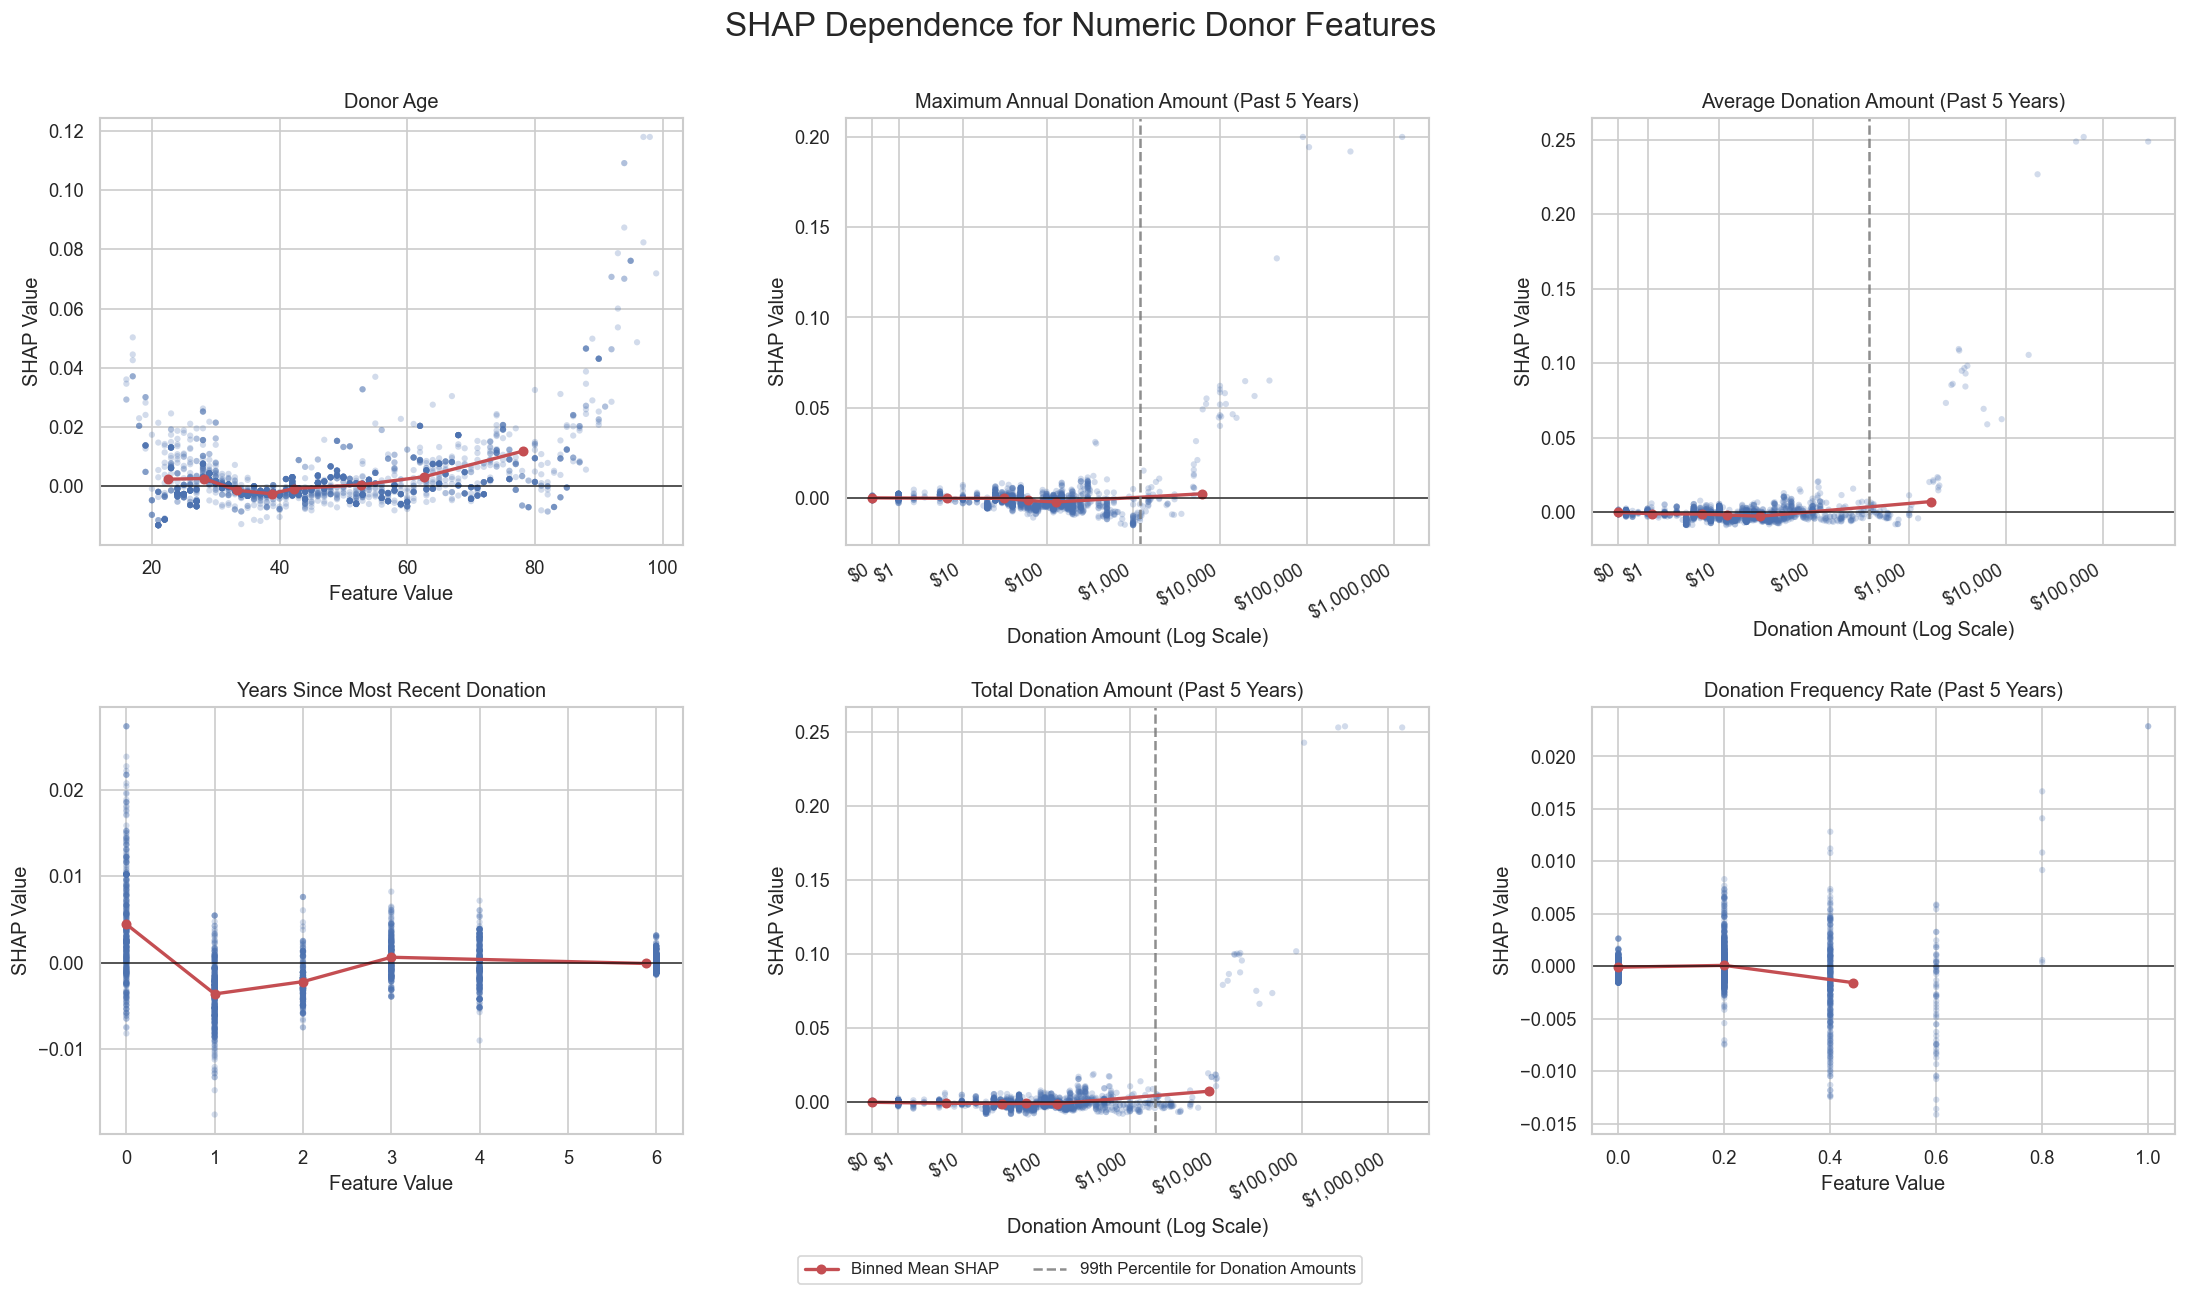

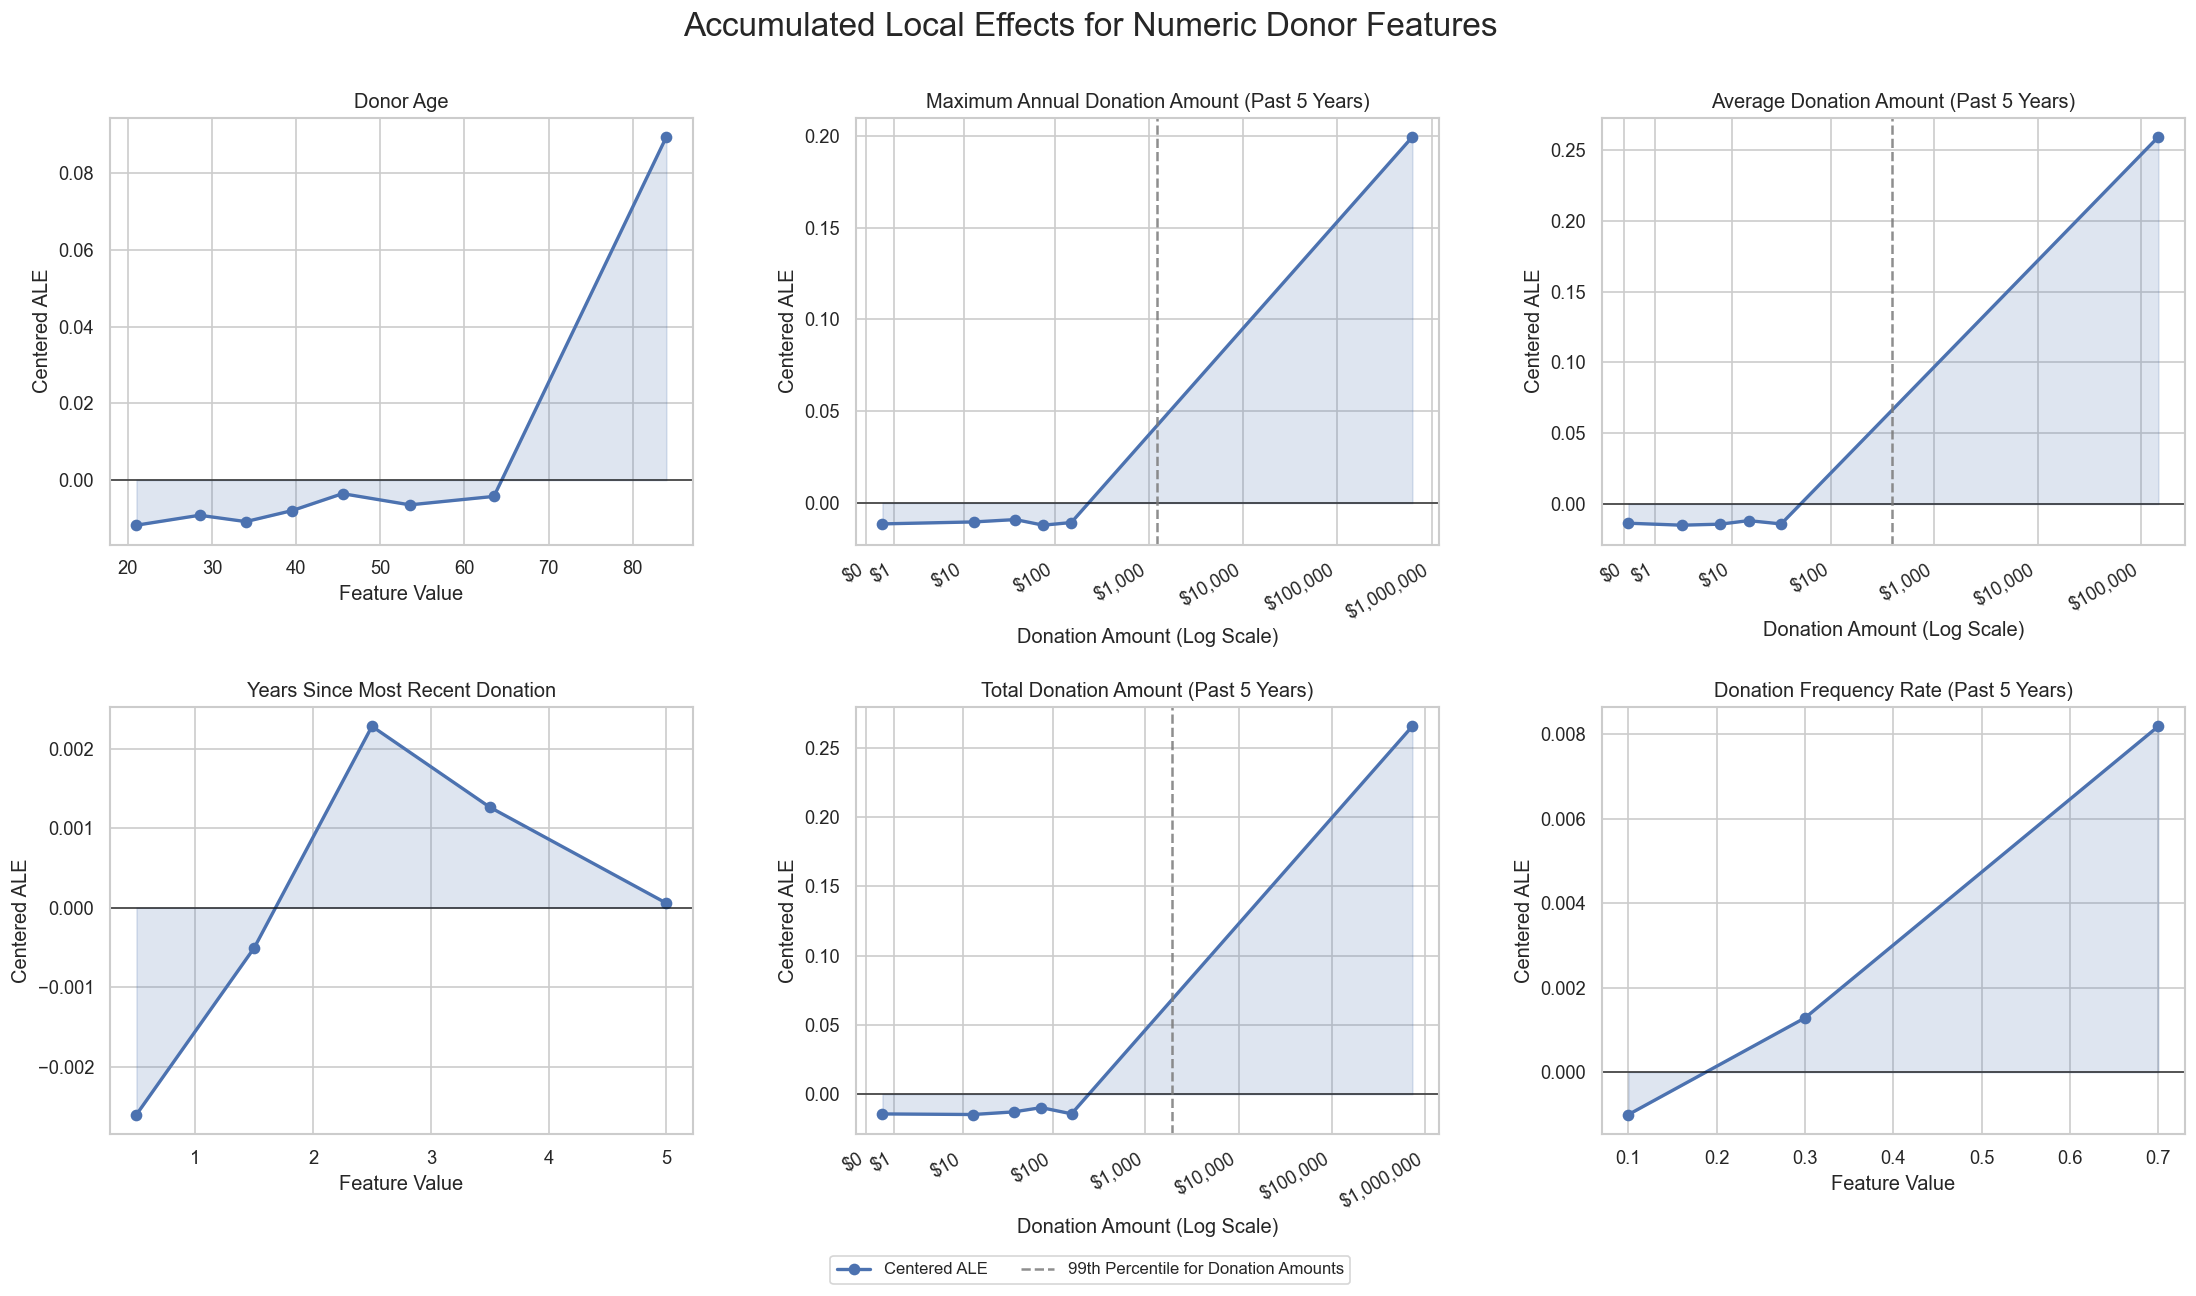

SHAP Rank,Business-Friendly Label,Range Importance Rank,Observed Minimum,Observed Maximum,Records,Record Percentage,Mean SHAP,Mean Absolute SHAP,Mean Model Score,Range Direction
1,Donor Age,1,69.0000,99.0000,364,5.29%,0.011860,0.013549,0.0658,Generally Increases Score
1,Donor Age,2,16.0000,25.0000,301,4.37%,0.002389,0.008444,0.0530,Generally Increases Score
1,Donor Age,3,58.0000,68.0000,343,4.98%,0.003213,0.005624,0.0597,Generally Increases Score
4,Maximum Annual Donation Amount (Past 5 Years),1,200.0000,"1,250,000.0000",366,5.32%,0.002493,0.010822,0.0704,Generally Increases Score
4,Maximum Annual Donation Amount (Past 5 Years),2,50.0000,98.0000,310,4.51%,-0.001239,0.003347,0.0506,Generally Decreases Score
4,Maximum Annual Donation Amount (Past 5 Years),3,100.0000,198.0000,407,5.91%,-0.002050,0.002792,0.0494,Generally Decreases Score
5,Average Donation Amount (Past 5 Years),1,44.0000,"293,832.0000",345,5.01%,0.007203,0.010410,0.0724,Generally Increases Score
5,Average Donation Amount (Past 5 Years),2,20.0000,43.2000,445,6.47%,-0.002622,0.003272,0.0489,Generally Decreases Score
5,Average Donation Amount (Past 5 Years),3,10.0000,19.6000,303,4.40%,-0.001796,0.003129,0.0505,Generally Decreases Score
6,Years Since Most Recent Donation,1,0.0000,0.0000,463,6.73%,0.004455,0.005708,0.0648,Generally Increases Score


SHAP Rank,Source Feature,Business-Friendly Label,ALE Bins,ALE Spearman Correlation,ALE Minimum,ALE Maximum,ALE Range,Lowest Effect Value,Highest Effect Value,Net ALE Change,General ALE Pattern
1,donor_age,Donor Age,8,0.9048,-0.011756,0.089447,0.101202,21.0000,84.0000,0.101202,Generally Increasing
4,feature_past_5yr_max_donation,Maximum Annual Donation Amount (Past 5 Years),6,0.3714,-0.012106,0.199366,0.211471,75.0000,"625,100.0000",0.210766,Nonlinear or Mixed
5,feature_past_5yr_average_donation,Average Donation Amount (Past 5 Years),6,0.5429,-0.014996,0.259243,0.274239,2.6000,"146,938.0000",0.272852,Nonlinear or Mixed
6,feature_years_since_last_donation_past_5yr,Years Since Most Recent Donation,5,0.6000,-0.002602,0.002280,0.004882,0.5000,2.5000,0.002658,Generally Increasing
7,feature_past_5yr_total_donation,Total Donation Amount (Past 5 Years),6,0.7714,-0.014713,0.265638,0.280350,13.0000,"734,690.0000",0.279915,Generally Increasing
8,feature_past_5yr_donation_frequency_rate,Donation Frequency Rate (Past 5 Years),3,1.0000,-0.001004,0.008184,0.009188,0.1000,0.7000,0.009188,Generally Increasing


Nonlinear relationship analysis completed successfully: 20/20 checks passed.
SHAP dependence bins saved to: outputs/interpretability/tables/primary_shap_dependence_bins.csv
Important SHAP ranges saved to: outputs/interpretability/tables/primary_shap_important_ranges.csv
ALE results saved to: outputs/interpretability/tables/primary_ale_numeric.csv
ALE feature summary saved to: outputs/interpretability/tables/primary_ale_feature_summary.csv
SHAP dependence figure saved to: outputs/interpretability/figures/primary_shap_dependence_numeric.png
ALE figure saved to: outputs/interpretability/figures/primary_ale_numeric.png


In [15]:
# Examine nonlinear SHAP relationships and important numeric value ranges
source_feature_order_primary_shap = (
    mapping_primary_source_features[
        "Source Feature"
    ].tolist()
)

source_feature_position_lookup = {
    source_feature_name: source_feature_position
    for source_feature_position, source_feature_name
    in enumerate(source_feature_order_primary_shap)
}

source_business_label_lookup = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Business-Friendly Label"
    ]
    .to_dict()
)

source_representation_lookup = (
    mapping_primary_source_features
    .set_index("Source Feature")[
        "Representation"
    ]
    .to_dict()
)

numeric_source_features_dependence = [
    source_feature_name
    for source_feature_name
    in (
        importance_primary_shap_source
        .sort_values("SHAP Rank")[
            "Source Feature"
        ]
        .tolist()
    )
    if (
        source_representation_lookup[
            source_feature_name
        ]
        == "Numeric"
    )
]

source_shap_rank_lookup = (
    importance_primary_shap_source
    .set_index("Source Feature")[
        "SHAP Rank"
    ]
    .astype(int)
    .to_dict()
)

probabilities_primary_dependence = np.asarray(
    probabilities_primary_classifier_shap,
    dtype=float,
)

positive_class_index_ale = int(
    np.flatnonzero(
        model_primary_pipeline_final.classes_ == 1
    )[0]
)


def create_quantile_edges(
    feature_values,
    requested_bin_count,
):
    finite_values = np.asarray(
        feature_values,
        dtype=float,
    )

    finite_values = finite_values[
        np.isfinite(finite_values)
    ]

    quantile_edges = np.quantile(
        finite_values,
        np.linspace(
            0,
            1,
            requested_bin_count + 1,
        ),
    )

    unique_edges = np.unique(quantile_edges)

    if unique_edges.shape[0] < 2:
        raise ValueError(
            "At least two unique values are required "
            "for dependence analysis."
        )

    return unique_edges


def assign_quantile_bins(
    feature_values,
    quantile_edges,
):
    return np.searchsorted(
        quantile_edges[1:-1],
        feature_values,
        side="right",
    )


dependence_bin_records = []

for source_feature_name in numeric_source_features_dependence:
    feature_values = pd.to_numeric(
        features_primary_test_interpretation[
            source_feature_name
        ],
        errors="coerce",
    ).to_numpy(dtype=float)

    source_shap_position = (
        source_feature_position_lookup[
            source_feature_name
        ]
    )

    source_shap_values = np.asarray(
        shap_values_primary_source_array[
            :,
            source_shap_position,
        ],
        dtype=float,
    )

    valid_record_mask = (
        np.isfinite(feature_values)
        & np.isfinite(source_shap_values)
        & np.isfinite(
            probabilities_primary_dependence
        )
    )

    valid_record_positions = np.flatnonzero(
        valid_record_mask
    )

    valid_feature_values = feature_values[
        valid_record_mask
    ]

    quantile_edges = create_quantile_edges(
        valid_feature_values,
        SHAP_DEPENDENCE_BIN_COUNT,
    )

    valid_bin_codes = assign_quantile_bins(
        valid_feature_values,
        quantile_edges,
    )

    for bin_code in np.unique(valid_bin_codes):
        bin_record_positions = valid_record_positions[
            valid_bin_codes == bin_code
        ]

        bin_feature_values = feature_values[
            bin_record_positions
        ]

        bin_shap_values = source_shap_values[
            bin_record_positions
        ]

        bin_model_scores = (
            probabilities_primary_dependence[
                bin_record_positions
            ]
        )

        mean_bin_shap = float(
            np.mean(bin_shap_values)
        )

        if mean_bin_shap > SHAP_EFFECT_TOLERANCE:
            range_direction = (
                "Generally Increases Score"
            )
        elif mean_bin_shap < -SHAP_EFFECT_TOLERANCE:
            range_direction = (
                "Generally Decreases Score"
            )
        else:
            range_direction = "Near Neutral"

        dependence_bin_records.append(
            {
                "SHAP Rank": (
                    source_shap_rank_lookup[
                        source_feature_name
                    ]
                ),
                "Source Feature": source_feature_name,
                "Business-Friendly Label": (
                    source_business_label_lookup[
                        source_feature_name
                    ]
                ),
                "Bin": int(bin_code) + 1,
                "Bin Lower Bound": float(
                    quantile_edges[bin_code]
                ),
                "Bin Upper Bound": float(
                    quantile_edges[bin_code + 1]
                ),
                "Observed Minimum": float(
                    np.min(bin_feature_values)
                ),
                "Observed Maximum": float(
                    np.max(bin_feature_values)
                ),
                "Mean Feature Value": float(
                    np.mean(bin_feature_values)
                ),
                "Records": int(
                    bin_record_positions.shape[0]
                ),
                "Record Percentage": float(
                    (
                        bin_record_positions.shape[0]
                        / valid_record_positions.shape[0]
                    )
                    * 100
                ),
                "Mean SHAP": mean_bin_shap,
                "Median SHAP": float(
                    np.median(bin_shap_values)
                ),
                "Mean Absolute SHAP": float(
                    np.mean(
                        np.abs(bin_shap_values)
                    )
                ),
                "Mean Model Score": float(
                    np.mean(bin_model_scores)
                ),
                "Range Direction": range_direction,
            }
        )

summary_primary_shap_dependence_bins = pd.DataFrame(
    dependence_bin_records
)

summary_primary_shap_dependence_bins[
    "Range Importance Rank"
] = (
    summary_primary_shap_dependence_bins
    .groupby("Source Feature")[
        "Mean Absolute SHAP"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)

summary_primary_shap_dependence_bins = (
    summary_primary_shap_dependence_bins
    .sort_values(
        [
            "SHAP Rank",
            "Bin Lower Bound",
        ]
    )
    .reset_index(drop=True)
)

important_ranges_primary_shap = (
    summary_primary_shap_dependence_bins.loc[
        summary_primary_shap_dependence_bins[
            "Range Importance Rank"
        ]
        <= IMPORTANT_RANGE_COUNT
    ]
    .sort_values(
        [
            "SHAP Rank",
            "Range Importance Rank",
        ]
    )
    .reset_index(drop=True)
)

ale_numeric_records = []

for source_feature_name in numeric_source_features_dependence:
    feature_values = pd.to_numeric(
        features_primary_test_interpretation[
            source_feature_name
        ],
        errors="coerce",
    ).to_numpy(dtype=float)

    valid_record_mask = np.isfinite(feature_values)

    valid_record_positions = np.flatnonzero(
        valid_record_mask
    )

    valid_feature_values = feature_values[
        valid_record_mask
    ]

    ale_quantile_edges = create_quantile_edges(
        valid_feature_values,
        SHAP_DEPENDENCE_BIN_COUNT,
    )

    valid_ale_bin_codes = assign_quantile_bins(
        valid_feature_values,
        ale_quantile_edges,
    )

    feature_ale_records = []

    for bin_code in np.unique(valid_ale_bin_codes):
        bin_record_positions = valid_record_positions[
            valid_ale_bin_codes == bin_code
        ]

        lower_bin_value = float(
            ale_quantile_edges[bin_code]
        )

        upper_bin_value = float(
            ale_quantile_edges[bin_code + 1]
        )

        features_primary_ale_lower = (
            features_primary_test_interpretation[
                features_primary_saved
            ]
            .iloc[bin_record_positions]
            .copy()
        )

        features_primary_ale_upper = (
            features_primary_ale_lower.copy()
        )

        features_primary_ale_lower[
            source_feature_name
        ] = lower_bin_value

        features_primary_ale_upper[
            source_feature_name
        ] = upper_bin_value

        lower_ale_scores = (
            model_primary_pipeline_final.predict_proba(
                features_primary_ale_lower
            )[:, positive_class_index_ale]
        )

        upper_ale_scores = (
            model_primary_pipeline_final.predict_proba(
                features_primary_ale_upper
            )[:, positive_class_index_ale]
        )

        mean_local_effect = float(
            np.mean(
                upper_ale_scores
                - lower_ale_scores
            )
        )

        feature_ale_records.append(
            {
                "SHAP Rank": (
                    source_shap_rank_lookup[
                        source_feature_name
                    ]
                ),
                "Source Feature": source_feature_name,
                "Business-Friendly Label": (
                    source_business_label_lookup[
                        source_feature_name
                    ]
                ),
                "Bin": int(bin_code) + 1,
                "Bin Lower Bound": lower_bin_value,
                "Bin Upper Bound": upper_bin_value,
                "Feature Midpoint": (
                    lower_bin_value
                    + upper_bin_value
                )
                / 2,
                "Records": int(
                    bin_record_positions.shape[0]
                ),
                "Mean Local Effect": mean_local_effect,
            }
        )

    feature_ale_frame = pd.DataFrame(
        feature_ale_records
    ).sort_values("Bin")

    feature_ale_frame[
        "Accumulated ALE Before Centering"
    ] = feature_ale_frame[
        "Mean Local Effect"
    ].cumsum()

    ale_center = float(
        np.average(
            feature_ale_frame[
                "Accumulated ALE Before Centering"
            ],
            weights=feature_ale_frame["Records"],
        )
    )

    feature_ale_frame["Centered ALE"] = (
        feature_ale_frame[
            "Accumulated ALE Before Centering"
        ]
        - ale_center
    )

    ale_numeric_records.extend(
        feature_ale_frame.to_dict(
            orient="records"
        )
    )

summary_primary_ale_numeric = pd.DataFrame(
    ale_numeric_records
).sort_values(
    [
        "SHAP Rank",
        "Bin",
    ]
).reset_index(drop=True)

ale_feature_summary_records = []

for source_feature_name in numeric_source_features_dependence:
    feature_ale_summary = (
        summary_primary_ale_numeric.loc[
            summary_primary_ale_numeric[
                "Source Feature"
            ]
            == source_feature_name
        ]
        .sort_values("Bin")
        .reset_index(drop=True)
    )

    ale_minimum_position = int(
        feature_ale_summary[
            "Centered ALE"
        ].idxmin()
    )

    ale_maximum_position = int(
        feature_ale_summary[
            "Centered ALE"
        ].idxmax()
    )

    ale_minimum = float(
        feature_ale_summary[
            "Centered ALE"
        ].min()
    )

    ale_maximum = float(
        feature_ale_summary[
            "Centered ALE"
        ].max()
    )

    ale_range = ale_maximum - ale_minimum

    ale_net_change = float(
        feature_ale_summary[
            "Centered ALE"
        ].iloc[-1]
        - feature_ale_summary[
            "Centered ALE"
        ].iloc[0]
    )

    ale_spearman_correlation = (
        feature_ale_summary[
            "Feature Midpoint"
        ].corr(
            feature_ale_summary[
                "Centered ALE"
            ],
            method="spearman",
        )
    )

    if pd.isna(ale_spearman_correlation):
        ale_spearman_correlation = 0.0

    if ale_range <= ALE_EFFECT_TOLERANCE:
        general_ale_pattern = "Limited Variation"
    elif (
        ale_spearman_correlation >= 0.60
        and ale_net_change > 0
    ):
        general_ale_pattern = "Generally Increasing"
    elif (
        ale_spearman_correlation <= -0.60
        and ale_net_change < 0
    ):
        general_ale_pattern = "Generally Decreasing"
    else:
        general_ale_pattern = "Nonlinear or Mixed"

    ale_feature_summary_records.append(
        {
            "SHAP Rank": (
                source_shap_rank_lookup[
                    source_feature_name
                ]
            ),
            "Source Feature": source_feature_name,
            "Business-Friendly Label": (
                source_business_label_lookup[
                    source_feature_name
                ]
            ),
            "ALE Bins": (
                feature_ale_summary.shape[0]
            ),
            "ALE Spearman Correlation": float(
                ale_spearman_correlation
            ),
            "ALE Minimum": ale_minimum,
            "ALE Maximum": ale_maximum,
            "ALE Range": ale_range,
            "Lowest Effect Value": float(
                feature_ale_summary.loc[
                    ale_minimum_position,
                    "Feature Midpoint",
                ]
            ),
            "Highest Effect Value": float(
                feature_ale_summary.loc[
                    ale_maximum_position,
                    "Feature Midpoint",
                ]
            ),
            "Net ALE Change": ale_net_change,
            "General ALE Pattern": general_ale_pattern,
        }
    )

summary_primary_ale_features = pd.DataFrame(
    ale_feature_summary_records
).sort_values(
    "SHAP Rank"
).reset_index(drop=True)

PRIMARY_SHAP_DEPENDENCE_BINS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_dependence_bins.csv"
)

PRIMARY_SHAP_IMPORTANT_RANGES_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_important_ranges.csv"
)

PRIMARY_ALE_NUMERIC_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_ale_numeric.csv"
)

PRIMARY_ALE_FEATURE_SUMMARY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_ale_feature_summary.csv"
)

PRIMARY_SHAP_DEPENDENCE_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_shap_dependence_numeric.png"
)

PRIMARY_ALE_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_ale_numeric.png"
)

summary_primary_shap_dependence_bins.to_csv(
    PRIMARY_SHAP_DEPENDENCE_BINS_PATH,
    index=False,
)

important_ranges_primary_shap.to_csv(
    PRIMARY_SHAP_IMPORTANT_RANGES_PATH,
    index=False,
)

summary_primary_ale_numeric.to_csv(
    PRIMARY_ALE_NUMERIC_PATH,
    index=False,
)

summary_primary_ale_features.to_csv(
    PRIMARY_ALE_FEATURE_SUMMARY_PATH,
    index=False,
)

amount_features_for_log_scale = {
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_max_donation",
}

amount_plot_tick_values = np.array(
    [
        0,
        1,
        10,
        100,
        1_000,
        10_000,
        100_000,
        1_000_000,
    ],
    dtype=float,
)


def transform_feature_values_for_plot(
    source_feature_name,
    feature_values,
):
    feature_values_array = np.asarray(
        feature_values,
        dtype=float,
    )

    if (
        source_feature_name
        in amount_features_for_log_scale
    ):
        return np.log1p(
            np.clip(
                feature_values_array,
                0,
                None,
            )
        )

    return feature_values_array


def format_numeric_feature_axis(
    plot_axis,
    source_feature_name,
    maximum_raw_value,
):
    if (
        source_feature_name
        in amount_features_for_log_scale
    ):
        valid_tick_values = amount_plot_tick_values[
            amount_plot_tick_values
            <= maximum_raw_value
        ]

        plot_axis.set_xticks(
            np.log1p(valid_tick_values)
        )

        plot_axis.set_xticklabels(
            [
                f"${tick_value:,.0f}"
                for tick_value
                in valid_tick_values
            ],
            rotation=30,
            ha="right",
        )

        plot_axis.set_xlabel(
            "Donation Amount (Log Scale)"
        )
    else:
        plot_axis.set_xlabel("Feature Value")


dependence_figure, dependence_axes = plt.subplots(
    2,
    3,
    figsize=(19, 11),
)

dependence_axes = dependence_axes.flatten()

dependence_mean_handle = None
dependence_tail_handle = None

for dependence_axis, source_feature_name in zip(
    dependence_axes,
    numeric_source_features_dependence,
):
    raw_feature_values = pd.to_numeric(
        features_primary_test_interpretation[
            source_feature_name
        ],
        errors="coerce",
    ).to_numpy(dtype=float)

    source_shap_position = (
        source_feature_position_lookup[
            source_feature_name
        ]
    )

    source_shap_values = np.asarray(
        shap_values_primary_source_array[
            :,
            source_shap_position,
        ],
        dtype=float,
    )

    valid_record_mask = (
        np.isfinite(raw_feature_values)
        & np.isfinite(source_shap_values)
    )

    plot_feature_values = (
        transform_feature_values_for_plot(
            source_feature_name,
            raw_feature_values[
                valid_record_mask
            ],
        )
    )

    dependence_axis.scatter(
        plot_feature_values,
        source_shap_values[
            valid_record_mask
        ],
        color="#4C72B0",
        s=14,
        alpha=0.25,
        edgecolors="none",
        rasterized=True,
    )

    feature_bin_summary = (
        summary_primary_shap_dependence_bins.loc[
            summary_primary_shap_dependence_bins[
                "Source Feature"
            ]
            == source_feature_name
        ]
        .sort_values("Mean Feature Value")
    )

    plot_bin_values = (
        transform_feature_values_for_plot(
            source_feature_name,
            feature_bin_summary[
                "Mean Feature Value"
            ].to_numpy(dtype=float),
        )
    )

    dependence_mean_line = dependence_axis.plot(
        plot_bin_values,
        feature_bin_summary["Mean SHAP"],
        color="#C44E52",
        marker="o",
        linewidth=2,
        markersize=5,
        label="Binned Mean SHAP",
    )[0]

    if dependence_mean_handle is None:
        dependence_mean_handle = (
            dependence_mean_line
        )

    dependence_axis.axhline(
        0,
        color="black",
        linewidth=1,
        alpha=0.70,
    )

    if (
        source_feature_name
        in amount_features_for_log_scale
    ):
        feature_percentile_99 = float(
            np.quantile(
                raw_feature_values[
                    valid_record_mask
                ],
                0.99,
            )
        )

        dependence_tail_line = (
            dependence_axis.axvline(
                np.log1p(
                    feature_percentile_99
                ),
                color="#7A7A7A",
                linestyle="--",
                linewidth=1.5,
                alpha=0.85,
                label="99th Percentile",
            )
        )

        if dependence_tail_handle is None:
            dependence_tail_handle = (
                dependence_tail_line
            )

    dependence_axis.set_title(
        source_business_label_lookup[
            source_feature_name
        ],
        fontsize=12,
        wrap=True,
    )

    dependence_axis.set_ylabel("SHAP Value")

    format_numeric_feature_axis(
        dependence_axis,
        source_feature_name,
        float(
            np.nanmax(raw_feature_values)
        ),
    )

dependence_figure.suptitle(
    "SHAP Dependence for Numeric Donor Features",
    fontsize=20,
    y=0.98,
)

dependence_figure.legend(
    handles=[
        dependence_mean_handle,
        dependence_tail_handle,
    ],
    labels=[
        "Binned Mean SHAP",
        "99th Percentile for Donation Amounts",
    ],
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01),
)

dependence_figure.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.90,
    bottom=0.13,
    hspace=0.38,
    wspace=0.28,
)

dependence_figure.savefig(
    PRIMARY_SHAP_DEPENDENCE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

ale_figure, ale_axes = plt.subplots(
    2,
    3,
    figsize=(19, 11),
)

ale_axes = ale_axes.flatten()

ale_profile_handle = None
ale_tail_handle = None

for ale_axis, source_feature_name in zip(
    ale_axes,
    numeric_source_features_dependence,
):
    feature_ale_plot = (
        summary_primary_ale_numeric.loc[
            summary_primary_ale_numeric[
                "Source Feature"
            ]
            == source_feature_name
        ]
        .sort_values("Feature Midpoint")
    )

    raw_feature_midpoints = (
        feature_ale_plot[
            "Feature Midpoint"
        ].to_numpy(dtype=float)
    )

    plot_feature_midpoints = (
        transform_feature_values_for_plot(
            source_feature_name,
            raw_feature_midpoints,
        )
    )

    ale_profile_line = ale_axis.plot(
        plot_feature_midpoints,
        feature_ale_plot["Centered ALE"],
        color="#4C72B0",
        marker="o",
        linewidth=2,
        markersize=6,
        label="Centered ALE",
    )[0]

    if ale_profile_handle is None:
        ale_profile_handle = ale_profile_line

    ale_axis.fill_between(
        plot_feature_midpoints,
        0,
        feature_ale_plot["Centered ALE"],
        color="#4C72B0",
        alpha=0.18,
    )

    ale_axis.axhline(
        0,
        color="black",
        linewidth=1,
        alpha=0.70,
    )

    raw_feature_values = pd.to_numeric(
        features_primary_test_interpretation[
            source_feature_name
        ],
        errors="coerce",
    ).to_numpy(dtype=float)

    if (
        source_feature_name
        in amount_features_for_log_scale
    ):
        feature_percentile_99 = float(
            np.nanquantile(
                raw_feature_values,
                0.99,
            )
        )

        ale_tail_line = ale_axis.axvline(
            np.log1p(feature_percentile_99),
            color="#7A7A7A",
            linestyle="--",
            linewidth=1.5,
            alpha=0.85,
            label="99th Percentile",
        )

        if ale_tail_handle is None:
            ale_tail_handle = ale_tail_line

    ale_axis.set_title(
        source_business_label_lookup[
            source_feature_name
        ],
        fontsize=12,
        wrap=True,
    )

    ale_axis.set_ylabel("Centered ALE")

    format_numeric_feature_axis(
        ale_axis,
        source_feature_name,
        float(
            np.nanmax(raw_feature_values)
        ),
    )

ale_figure.suptitle(
    "Accumulated Local Effects for Numeric Donor Features",
    fontsize=20,
    y=0.98,
)

ale_figure.legend(
    handles=[
        ale_profile_handle,
        ale_tail_handle,
    ],
    labels=[
        "Centered ALE",
        "99th Percentile for Donation Amounts",
    ],
    loc="lower center",
    ncol=2,
    frameon=True,
    bbox_to_anchor=(0.5, 0.01),
)

ale_figure.subplots_adjust(
    left=0.07,
    right=0.98,
    top=0.90,
    bottom=0.13,
    hspace=0.38,
    wspace=0.28,
)

ale_figure.savefig(
    PRIMARY_ALE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

dependence_group_record_counts = (
    summary_primary_shap_dependence_bins
    .groupby("Source Feature")["Records"]
    .sum()
)

ale_group_record_counts = (
    summary_primary_ale_numeric
    .groupby("Source Feature")["Records"]
    .sum()
)

weighted_shap_means_match = all(
    np.isclose(
        np.average(
            summary_primary_shap_dependence_bins.loc[
                summary_primary_shap_dependence_bins[
                    "Source Feature"
                ]
                == source_feature_name,
                "Mean SHAP",
            ],
            weights=(
                summary_primary_shap_dependence_bins.loc[
                    summary_primary_shap_dependence_bins[
                        "Source Feature"
                    ]
                    == source_feature_name,
                    "Records",
                ]
            ),
        ),
        np.mean(
            shap_values_primary_source_array[
                :,
                source_feature_position_lookup[
                    source_feature_name
                ],
            ]
        ),
        rtol=0,
        atol=1e-12,
    )
    for source_feature_name
    in numeric_source_features_dependence
)

centered_ale_means_are_zero = all(
    np.isclose(
        np.average(
            summary_primary_ale_numeric.loc[
                summary_primary_ale_numeric[
                    "Source Feature"
                ]
                == source_feature_name,
                "Centered ALE",
            ],
            weights=(
                summary_primary_ale_numeric.loc[
                    summary_primary_ale_numeric[
                        "Source Feature"
                    ]
                    == source_feature_name,
                    "Records",
                ]
            ),
        ),
        0,
        rtol=0,
        atol=1e-12,
    )
    for source_feature_name
    in numeric_source_features_dependence
)

expected_important_range_counts = (
    summary_primary_shap_dependence_bins
    .groupby("Source Feature")
    .size()
    .clip(upper=IMPORTANT_RANGE_COUNT)
    .sort_index()
)

observed_important_range_counts = (
    important_ranges_primary_shap
    .groupby("Source Feature")
    .size()
    .sort_index()
)

nonlinear_analysis_checks = {
    "Exactly six numeric source features are analyzed": (
        len(numeric_source_features_dependence) == 6
    ),
    "All numeric features exist in the final test data": (
        set(numeric_source_features_dependence)
        .issubset(
            features_primary_test_interpretation.columns
        )
    ),
    "Numeric feature values are complete": (
        features_primary_test_interpretation[
            numeric_source_features_dependence
        ].notna().all().all()
    ),
    "Source SHAP width matches the source mapping": (
        shap_values_primary_source_array.shape[1]
        == len(source_feature_order_primary_shap)
    ),
    "Source SHAP record count matches the final test set": (
        shap_values_primary_source_array.shape[0]
        == data_primary_test_interpretation.shape[0]
    ),
    "Model score count matches the final test set": (
        probabilities_primary_dependence.shape[0]
        == data_primary_test_interpretation.shape[0]
    ),
    "Dependence summaries include every numeric feature": (
        set(
            summary_primary_shap_dependence_bins[
                "Source Feature"
            ]
        )
        == set(numeric_source_features_dependence)
    ),
    "Dependence bins are unique within each feature": (
        not summary_primary_shap_dependence_bins[
            [
                "Source Feature",
                "Bin",
            ]
        ].duplicated().any()
    ),
    "Each numeric feature has at least two dependence bins": (
        (
            summary_primary_shap_dependence_bins
            .groupby("Source Feature")
            .size()
            >= 2
        ).all()
    ),
    "Dependence bins use every final test record": (
        (
            dependence_group_record_counts
            == data_primary_test_interpretation.shape[0]
        ).all()
    ),
    "Dependence statistics are finite": (
        np.isfinite(
            summary_primary_shap_dependence_bins[
                [
                    "Mean Feature Value",
                    "Mean SHAP",
                    "Median SHAP",
                    "Mean Absolute SHAP",
                    "Mean Model Score",
                ]
            ].to_numpy(dtype=float)
        ).all()
    ),
    "Dependence bin bounds are ordered": (
        (
            summary_primary_shap_dependence_bins[
                "Bin Upper Bound"
            ]
            >
            summary_primary_shap_dependence_bins[
                "Bin Lower Bound"
            ]
        ).all()
    ),
    "Binned SHAP means reproduce full feature means": (
        weighted_shap_means_match
    ),
    "Important range counts are correct": (
        expected_important_range_counts.equals(
            observed_important_range_counts
        )
    ),
    "ALE summaries include every numeric feature": (
        set(
            summary_primary_ale_numeric[
                "Source Feature"
            ]
        )
        == set(numeric_source_features_dependence)
    ),
    "ALE bins are unique within each feature": (
        not summary_primary_ale_numeric[
            [
                "Source Feature",
                "Bin",
            ]
        ].duplicated().any()
    ),
    "ALE bins use every final test record": (
        (
            ale_group_record_counts
            == data_primary_test_interpretation.shape[0]
        ).all()
    ),
    "ALE statistics are finite": (
        np.isfinite(
            summary_primary_ale_numeric[
                [
                    "Mean Local Effect",
                    "Accumulated ALE Before Centering",
                    "Centered ALE",
                ]
            ].to_numpy(dtype=float)
        ).all()
    ),
    "Centered ALE means equal zero": (
        centered_ale_means_are_zero
    ),
    "All nonlinear analysis artifacts were saved": (
        PRIMARY_SHAP_DEPENDENCE_BINS_PATH.exists()
        and PRIMARY_SHAP_IMPORTANT_RANGES_PATH.exists()
        and PRIMARY_ALE_NUMERIC_PATH.exists()
        and PRIMARY_ALE_FEATURE_SUMMARY_PATH.exists()
        and PRIMARY_SHAP_DEPENDENCE_FIGURE_PATH.exists()
        and PRIMARY_ALE_FIGURE_PATH.exists()
    ),
}

failed_nonlinear_analysis_checks = [
    check_name
    for check_name, check_passed
    in nonlinear_analysis_checks.items()
    if not bool(check_passed)
]

if failed_nonlinear_analysis_checks:
    raise AssertionError(
        "Nonlinear relationship analysis failed for: "
        + ", ".join(
            failed_nonlinear_analysis_checks
        )
    )

display(
    important_ranges_primary_shap[
        [
            "SHAP Rank",
            "Business-Friendly Label",
            "Range Importance Rank",
            "Observed Minimum",
            "Observed Maximum",
            "Records",
            "Record Percentage",
            "Mean SHAP",
            "Mean Absolute SHAP",
            "Mean Model Score",
            "Range Direction",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Business-Friendly Label": "{}",
            "Range Importance Rank": "{:,.0f}",
            "Observed Minimum": "{:,.4f}",
            "Observed Maximum": "{:,.4f}",
            "Records": "{:,.0f}",
            "Record Percentage": "{:,.2f}%",
            "Mean SHAP": "{:,.6f}",
            "Mean Absolute SHAP": "{:,.6f}",
            "Mean Model Score": "{:,.4f}",
            "Range Direction": "{}",
        }
    )
)

display(
    summary_primary_ale_features.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "SHAP Rank": "{:,.0f}",
            "Source Feature": "{}",
            "Business-Friendly Label": "{}",
            "ALE Bins": "{:,.0f}",
            "ALE Spearman Correlation": "{:,.4f}",
            "ALE Minimum": "{:,.6f}",
            "ALE Maximum": "{:,.6f}",
            "ALE Range": "{:,.6f}",
            "Lowest Effect Value": "{:,.4f}",
            "Highest Effect Value": "{:,.4f}",
            "Net ALE Change": "{:,.6f}",
            "General ALE Pattern": "{}",
        }
    )
)

print(
    "Nonlinear relationship analysis completed successfully: "
    f"{sum(nonlinear_analysis_checks.values())}/"
    f"{len(nonlinear_analysis_checks)} checks passed."
)

print(
    "SHAP dependence bins saved to: "
    f"{PRIMARY_SHAP_DEPENDENCE_BINS_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Important SHAP ranges saved to: "
    f"{PRIMARY_SHAP_IMPORTANT_RANGES_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "ALE results saved to: "
    f"{PRIMARY_ALE_NUMERIC_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "ALE feature summary saved to: "
    f"{PRIMARY_ALE_FEATURE_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "SHAP dependence figure saved to: "
    f"{PRIMARY_SHAP_DEPENDENCE_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "ALE figure saved to: "
    f"{PRIMARY_ALE_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

## SHAP Feature Direction and Nonlinear Relationships

SHAP feature direction was analyzed using all 6,881 final test records. Positive SHAP values increase the donor ranking score, while negative values decrease it. All 19 direction checks and all 20 nonlinear relationship checks passed.

### General Direction Findings

- Donor age showed the clearest positive numeric pattern. Scores remained close to the baseline across much of the age range but generally increased after age 60. Donors between ages 69 and 99 had the strongest average positive effect.
- Donation amount features showed nonlinear patterns. Common positive donation amounts generally had small negative or neutral effects, while unusually large amounts produced stronger positive effects.
- Donating during the most recent year generally increased the score. Values of one or two years since the most recent donation generally decreased it, while later values were closer to neutral.
- Donation frequency showed a mixed pattern. Values from 0.0 to 0.2 had limited average effects, a value of 0.4 generally decreased the score, and higher values contained fewer records.
- Male identity generally increased the score, while female and unknown identity generally decreased it.
- Home and business address types generally increased the score, while missing and campus address types generally decreased it. Other address type had the largest positive average effect but contained only 19 donors, so this result is not reliable enough for a general conclusion.

### Nonlinear Relationships and Important Ranges

The SHAP dependence plots show that most numeric feature effects remain close to zero across the ranges containing most donors. Larger positive effects are concentrated among older donors and donors with unusually high historical donation amounts. The donation amount plots use a logarithmic scale because these variables contain a small number of extreme values.

The accumulated local effect results support the presence of nonlinear relationships. Donor age generally increases the model score at older values, while donation recency rises and then returns toward neutral. The donation amount curves increase sharply beyond the 99th percentile, but these extreme ranges contain limited support and should not be treated as representative of typical donors. The dashed lines identify the 99th percentile so the common donor ranges can be separated from the sparse upper tail.

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   2 out of   4 | elapsed:  1.2min remaining:  1.2min
[Parallel(n_jobs=2)]: Done   4 out of   4 | elapsed:  2.3min finished


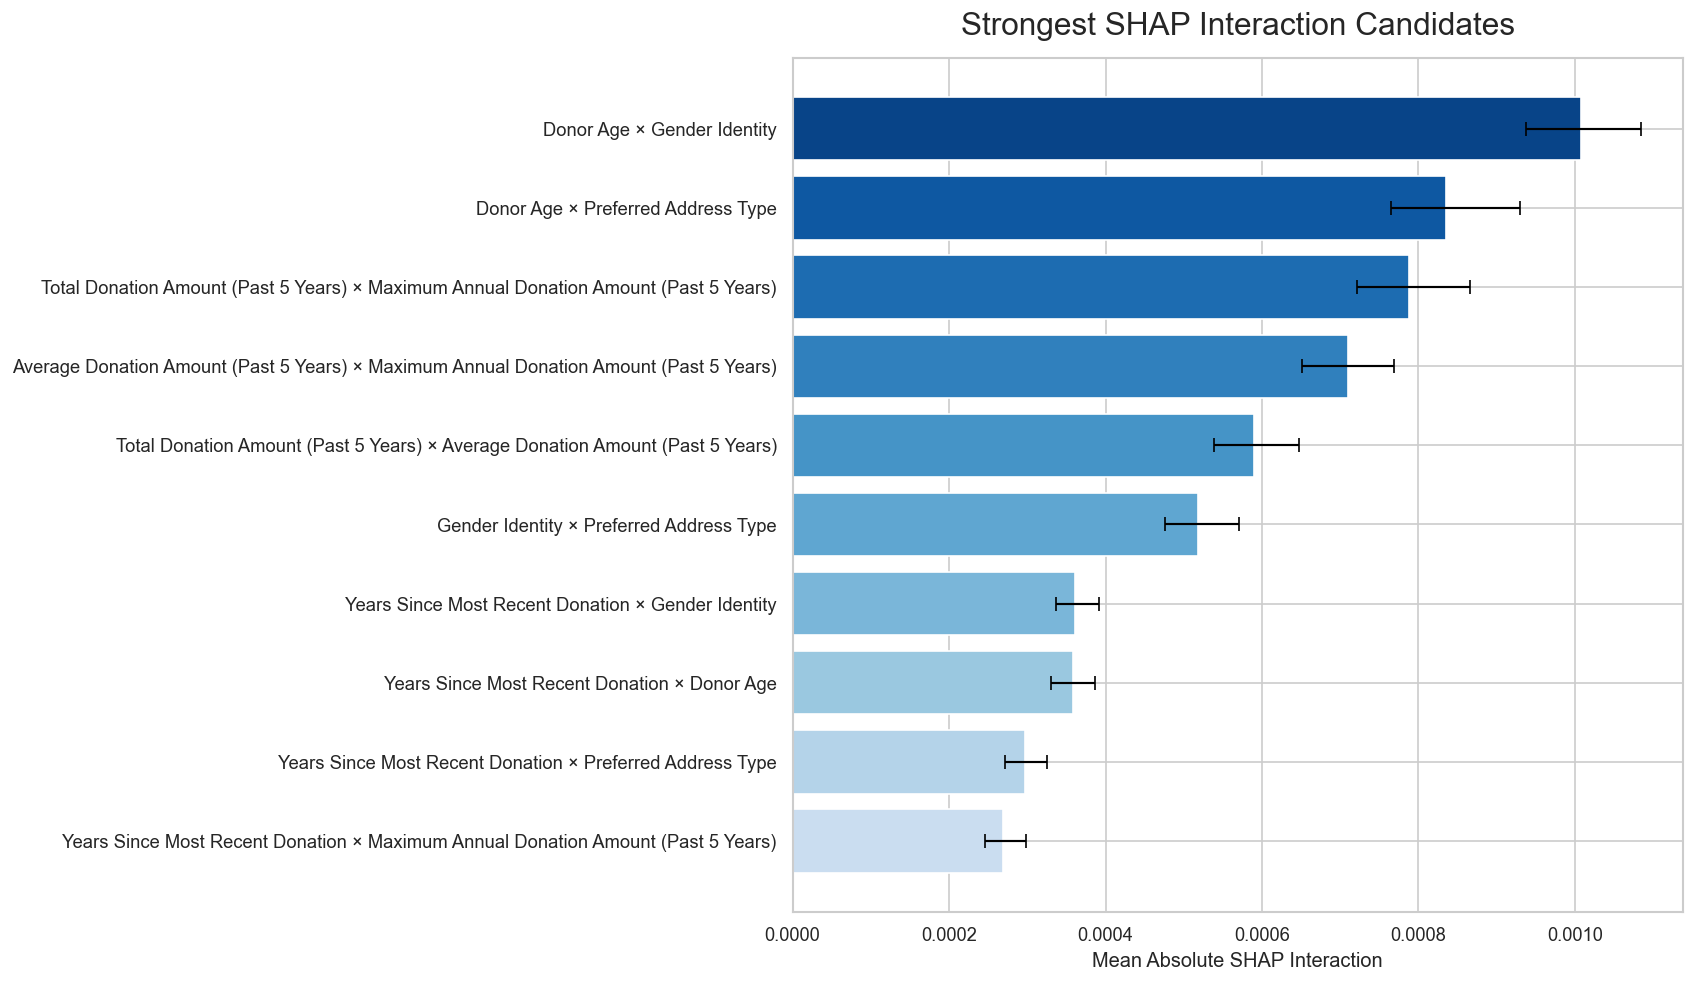

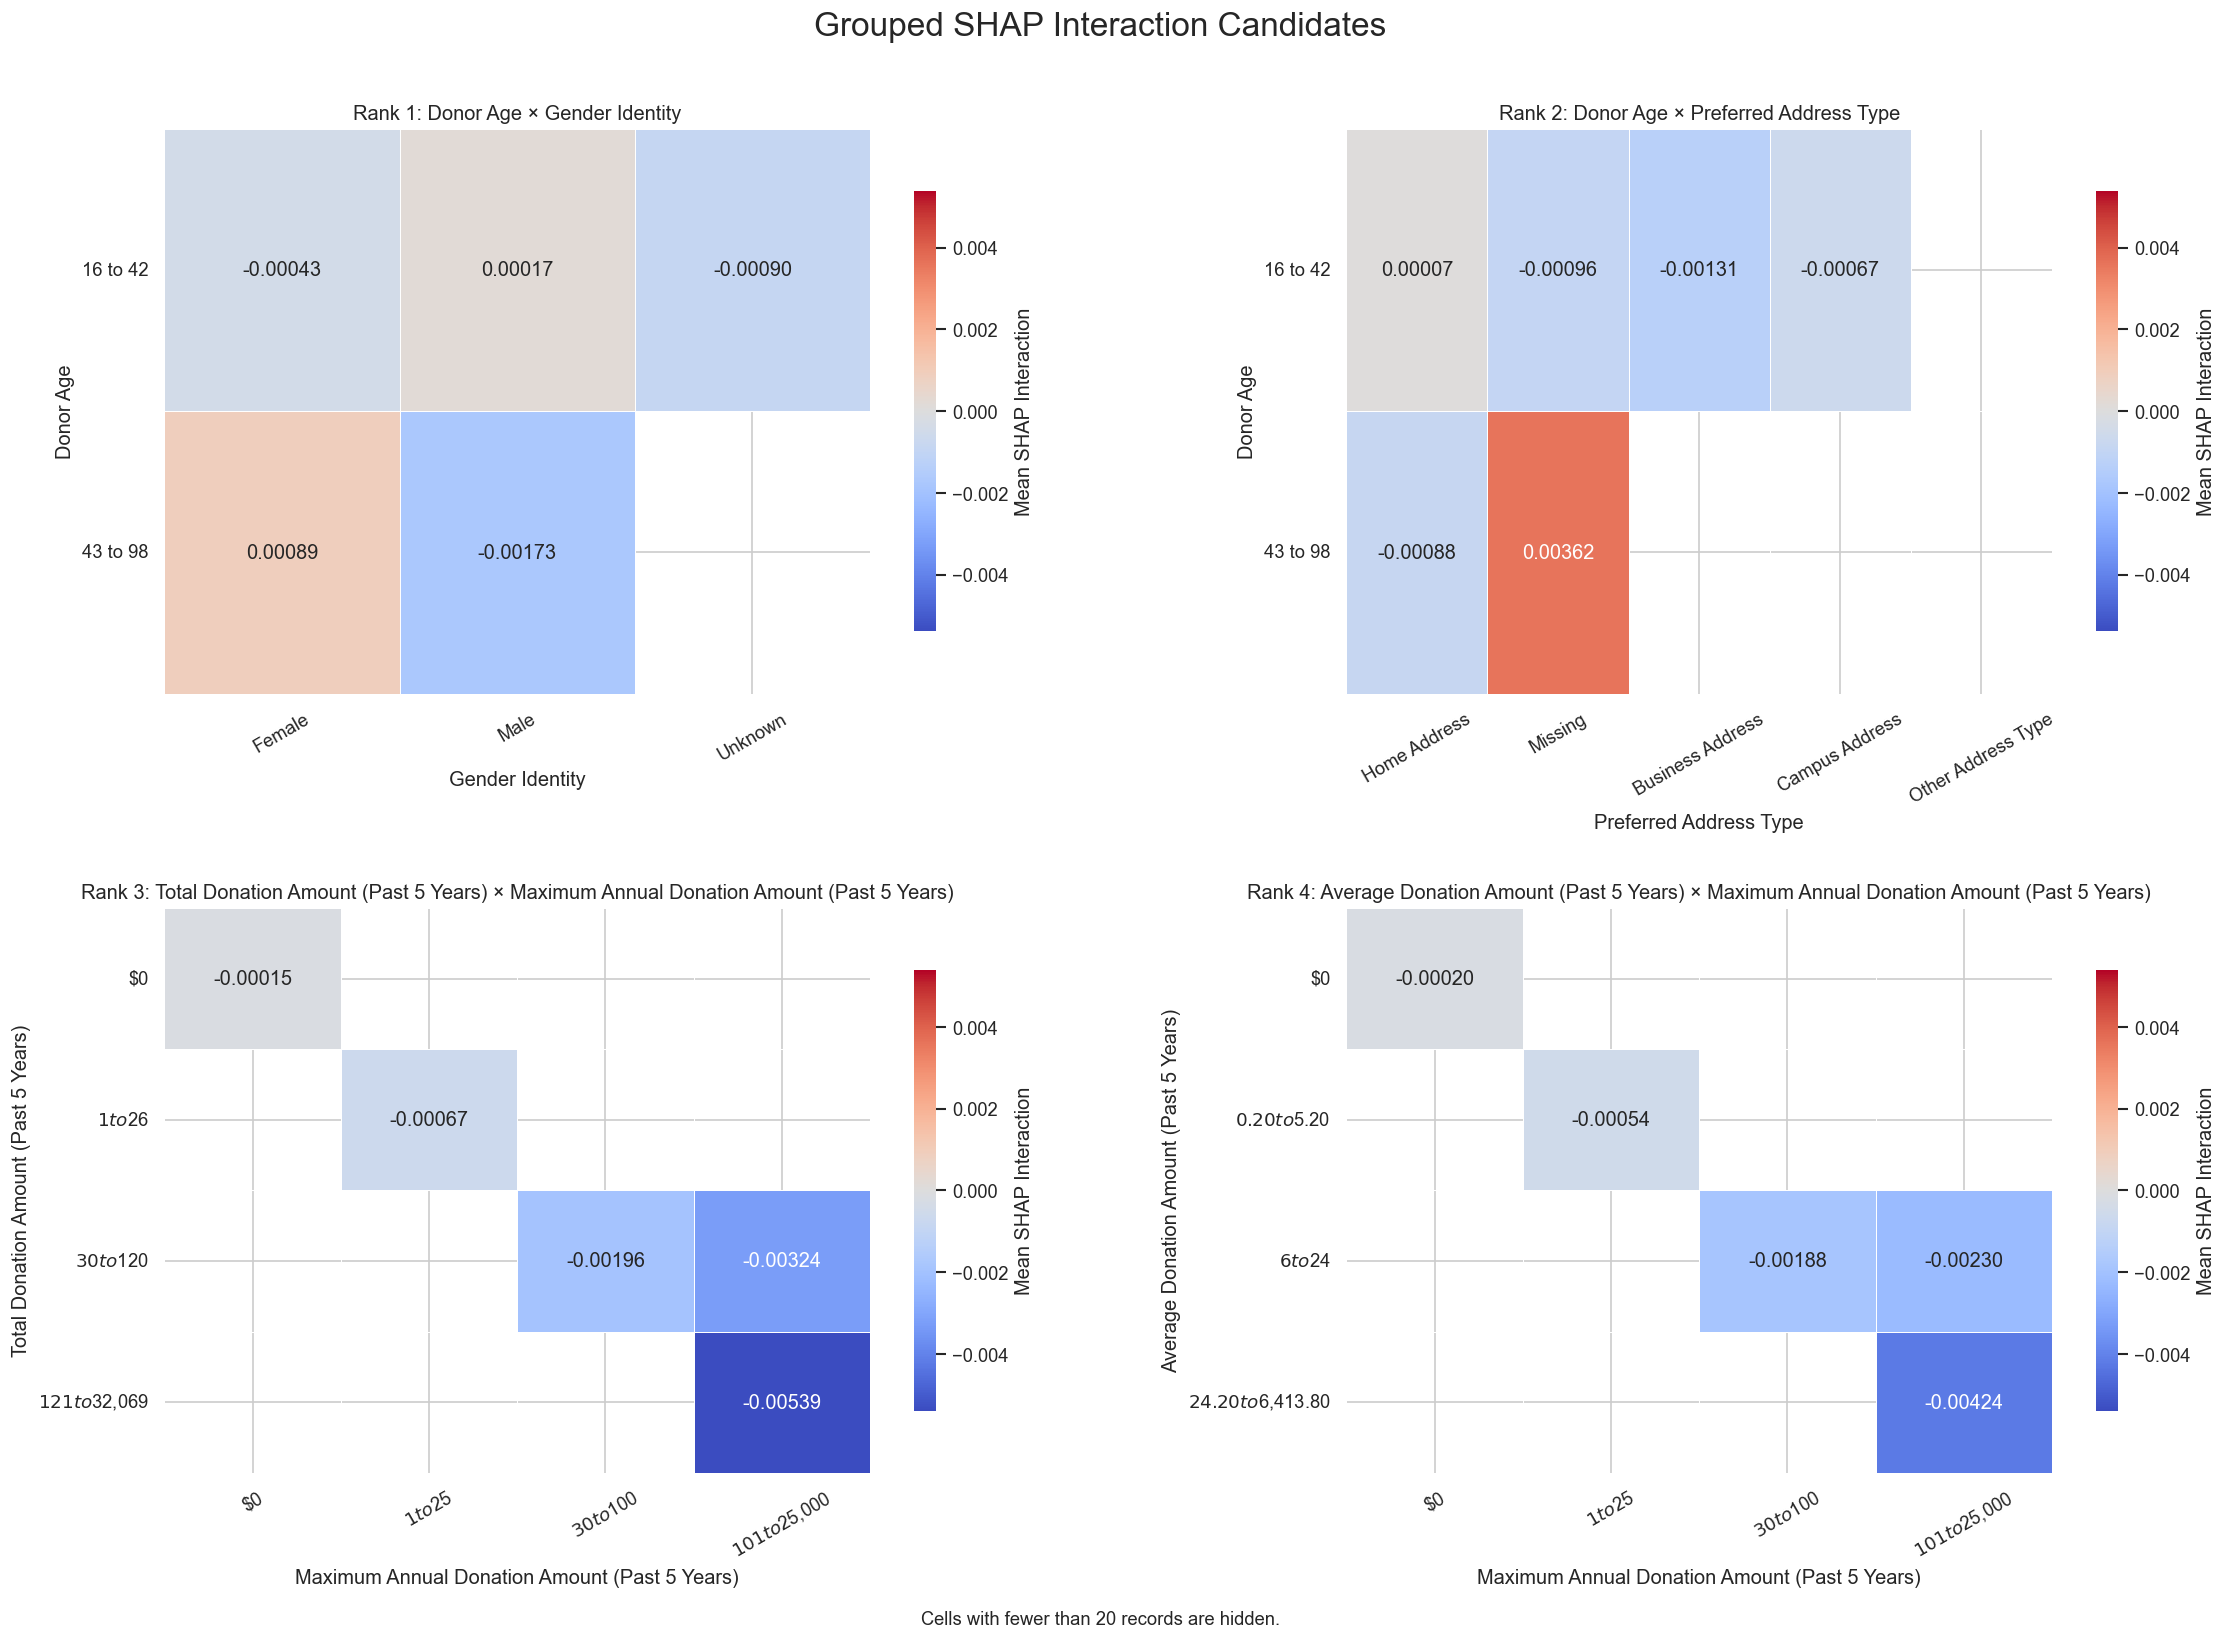

Explainer,Records Used,Positive Targets,Transformed Features,Source Features,Interaction Pairs,Bootstrap Iterations,Worker Processes,Interaction Chunks,Minimum Heatmap Cell Records,Maximum Additivity Error,Maximum Symmetry Error,Interpretation Status
TreeExplainer,"2,000",111,14,8,28,500,2,4,20,2.72e-15,1.39e-17,Candidate Analysis Only


Interaction Rank,Interaction Pair,Mean Absolute SHAP Interaction,Interaction Importance Percentage,Interaction to Main Effect Percentage,Bootstrap Lower Percentile (2.5%),Bootstrap Upper Percentile (97.5%),Mean Bootstrap Rank,Top Five Bootstrap Percentage,Dominant Direction,Evidence Classification,Interpretation Status
1,Donor Age × Gender Identity,0.001008,10.62%,29.74%,0.000937,0.001084,1.00,100.00%,Negative on Average,Strongest Supported Candidate,Candidate Only
2,Donor Age × Preferred Address Type,0.000835,8.80%,27.91%,0.000765,0.000930,2.20,100.00%,Negative on Average,Strongest Supported Candidate,Candidate Only
3,Total Donation Amount (Past 5 Years) × Maximum Annual Donation Amount (Past 5 Years),0.000788,8.31%,24.13%,0.000722,0.000866,2.81,100.00%,Negative on Average,Strongest Supported Candidate,Candidate Only
4,Average Donation Amount (Past 5 Years) × Maximum Annual Donation Amount (Past 5 Years),0.000710,7.48%,23.03%,0.000651,0.000769,3.99,100.00%,Negative on Average,Moderate Candidate,Candidate Only
5,Total Donation Amount (Past 5 Years) × Average Donation Amount (Past 5 Years),0.000589,6.21%,20.93%,0.000539,0.000648,5.02,97.60%,Negative on Average,Moderate Candidate,Candidate Only


SHAP interaction analysis completed successfully: 24/24 checks passed.
Interaction summary saved to: outputs/interpretability/tables/primary_shap_interaction_summary.csv
Interaction candidates saved to: outputs/interpretability/tables/primary_shap_interaction_candidates.csv
Interaction sample values saved to: outputs/interpretability/tables/primary_shap_interaction_values_sample.csv
Interaction heatmap cells saved to: outputs/interpretability/tables/primary_shap_interaction_heatmap_cells.csv
Interaction ranking figure saved to: outputs/interpretability/figures/primary_shap_interaction_ranking.png
Interaction heatmap figure saved to: outputs/interpretability/figures/primary_shap_interaction_heatmaps.png


In [16]:
# Identify and validate strongest SHAP interaction candidates
if not 1 <= SHAP_INTERACTION_WORKERS <= 4:
    raise ValueError(
        "SHAP interaction workers must be between 1 and 4."
    )

interaction_target_values = (
    target_primary_test_interpretation
    .to_numpy(dtype=int)
)

interaction_total_record_count = (
    interaction_target_values.shape[0]
)

interaction_sample_size = min(
    SHAP_INTERACTION_SAMPLE_SIZE,
    interaction_total_record_count,
)

interaction_sample_rng = np.random.default_rng(
    RANDOM_STATE
)

if interaction_sample_size == interaction_total_record_count:
    interaction_sample_positions = np.arange(
        interaction_total_record_count
    )
else:
    interaction_positive_positions = np.flatnonzero(
        interaction_target_values == 1
    )

    interaction_negative_positions = np.flatnonzero(
        interaction_target_values == 0
    )

    interaction_positive_sample_count = int(
        round(
            interaction_sample_size
            * interaction_positive_positions.shape[0]
            / interaction_total_record_count
        )
    )

    interaction_positive_sample_count = max(
        1,
        min(
            interaction_positive_sample_count,
            interaction_positive_positions.shape[0],
        ),
    )

    interaction_negative_sample_count = (
        interaction_sample_size
        - interaction_positive_sample_count
    )

    sampled_positive_positions = (
        interaction_sample_rng.choice(
            interaction_positive_positions,
            size=interaction_positive_sample_count,
            replace=False,
        )
    )

    sampled_negative_positions = (
        interaction_sample_rng.choice(
            interaction_negative_positions,
            size=interaction_negative_sample_count,
            replace=False,
        )
    )

    interaction_sample_positions = np.sort(
        np.concatenate(
            [
                sampled_positive_positions,
                sampled_negative_positions,
            ]
        )
    )

interaction_sample_targets = (
    interaction_target_values[
        interaction_sample_positions
    ]
)

if hasattr(
    features_primary_test_transformed,
    "toarray",
):
    features_primary_test_transformed_array = (
        features_primary_test_transformed.toarray()
    )
else:
    features_primary_test_transformed_array = (
        np.asarray(
            features_primary_test_transformed
        )
    )

features_primary_interaction_sample = np.asarray(
    features_primary_test_transformed_array[
        interaction_sample_positions
    ],
    dtype=float,
)

positive_class_index_interaction = int(
    np.flatnonzero(
        classifier_primary_saved.classes_ == 1
    )[0]
)


def extract_positive_class_interactions(
    raw_interaction_values,
    record_count,
    feature_count,
    class_index,
    class_count,
):
    if isinstance(
        raw_interaction_values,
        list,
    ):
        extracted_values = np.asarray(
            raw_interaction_values[class_index],
            dtype=float,
        )

        raw_layout = (
            "List of record by feature by feature arrays"
        )
    else:
        interaction_array = np.asarray(
            raw_interaction_values,
            dtype=float,
        )

        if (
            interaction_array.ndim == 4
            and interaction_array.shape
            == (
                record_count,
                feature_count,
                feature_count,
                class_count,
            )
        ):
            extracted_values = interaction_array[
                :,
                :,
                :,
                class_index,
            ]

            raw_layout = (
                "Records by features by features by classes"
            )
        elif (
            interaction_array.ndim == 4
            and interaction_array.shape
            == (
                class_count,
                record_count,
                feature_count,
                feature_count,
            )
        ):
            extracted_values = interaction_array[
                class_index
            ]

            raw_layout = (
                "Classes by records by features by features"
            )
        elif (
            interaction_array.ndim == 4
            and interaction_array.shape
            == (
                record_count,
                class_count,
                feature_count,
                feature_count,
            )
        ):
            extracted_values = interaction_array[
                :,
                class_index,
                :,
                :,
            ]

            raw_layout = (
                "Records by classes by features by features"
            )
        elif (
            interaction_array.ndim == 3
            and interaction_array.shape
            == (
                record_count,
                feature_count,
                feature_count,
            )
        ):
            extracted_values = interaction_array

            raw_layout = (
                "Records by features by features"
            )
        else:
            raise ValueError(
                "Unsupported SHAP interaction shape: "
                f"{interaction_array.shape}"
            )

    return extracted_values, raw_layout


interaction_sample_chunks = [
    interaction_chunk
    for interaction_chunk
    in np.array_split(
        features_primary_interaction_sample,
        SHAP_INTERACTION_CHUNK_COUNT,
    )
    if interaction_chunk.shape[0] > 0
]


def calculate_primary_interaction_chunk(
    transformed_feature_chunk,
):
    with threadpool_limits(limits=1):
        chunk_explainer = shap.TreeExplainer(
            classifier_primary_saved,
            feature_perturbation=(
                "tree_path_dependent"
            ),
            model_output="raw",
        )

        raw_chunk_interactions = (
            chunk_explainer
            .shap_interaction_values(
                transformed_feature_chunk
            )
        )

    normalized_chunk_interactions, _ = (
        extract_positive_class_interactions(
            raw_chunk_interactions,
            transformed_feature_chunk.shape[0],
            transformed_feature_chunk.shape[1],
            positive_class_index_interaction,
            classifier_primary_saved.classes_.shape[0],
        )
    )

    return normalized_chunk_interactions


interaction_chunk_results = Parallel(
    n_jobs=SHAP_INTERACTION_WORKERS,
    backend="loky",
    verbose=5,
)(
    delayed(
        calculate_primary_interaction_chunk
    )(
        interaction_chunk
    )
    for interaction_chunk
    in interaction_sample_chunks
)

shap_interactions_primary_positive = (
    np.concatenate(
        interaction_chunk_results,
        axis=0,
    )
)

shap_interaction_raw_layout = (
    "Parallel normalized interaction chunks"
)

explainer_primary_interaction = shap.TreeExplainer(
    classifier_primary_saved,
    feature_perturbation="tree_path_dependent",
    model_output="raw",
)

interaction_expected_values = np.asarray(
    explainer_primary_interaction.expected_value,
    dtype=float,
).reshape(-1)

if interaction_expected_values.shape[0] == 1:
    interaction_base_value = float(
        interaction_expected_values[0]
    )
else:
    interaction_base_value = float(
        interaction_expected_values[
            positive_class_index_interaction
        ]
    )

with threadpool_limits(limits=1):
    interaction_model_outputs = (
        classifier_primary_saved.predict_proba(
            features_primary_interaction_sample
        )[:, positive_class_index_interaction]
    )

interaction_reconstructed_outputs = (
    interaction_base_value
    + shap_interactions_primary_positive.sum(
        axis=(1, 2)
    )
)

interaction_additivity_errors = np.abs(
    interaction_model_outputs
    - interaction_reconstructed_outputs
)

interaction_mapping_ordered = (
    mapping_primary_transformed_features
    .sort_values("Transformed Position")
    .reset_index(drop=True)
)

source_transformed_position_lookup = {}

for source_feature_name in features_primary_saved:
    source_transformed_position_lookup[
        source_feature_name
    ] = (
        interaction_mapping_ordered.index[
            interaction_mapping_ordered[
                "Source Feature"
            ]
            == source_feature_name
        ]
        .to_numpy(dtype=int)
    )

source_internal_effect_values = {}

for source_feature_name in features_primary_saved:
    source_feature_positions = (
        source_transformed_position_lookup[
            source_feature_name
        ]
    )

    source_internal_effect_values[
        source_feature_name
    ] = (
        shap_interactions_primary_positive[
            :,
            source_feature_positions,
            :,
        ][
            :,
            :,
            source_feature_positions,
        ]
        .sum(axis=(1, 2))
    )

source_internal_mean_absolute_lookup = {
    source_feature_name: float(
        np.mean(
            np.abs(
                source_internal_effect_values[
                    source_feature_name
                ]
            )
        )
    )
    for source_feature_name
    in features_primary_saved
}

interaction_pair_keys = []
interaction_pair_sources = []
interaction_pair_value_arrays = []

for first_source_position, first_source_feature in enumerate(
    features_primary_saved
):
    first_transformed_positions = (
        source_transformed_position_lookup[
            first_source_feature
        ]
    )

    for second_source_feature in features_primary_saved[
        first_source_position + 1:
    ]:
        second_transformed_positions = (
            source_transformed_position_lookup[
                second_source_feature
            ]
        )

        pair_interaction_values = (
            shap_interactions_primary_positive[
                :,
                first_transformed_positions,
                :,
            ][
                :,
                :,
                second_transformed_positions,
            ]
            .sum(axis=(1, 2))
        )

        interaction_pair_key = (
            f"{first_source_feature}"
            f"__x__"
            f"{second_source_feature}"
        )

        interaction_pair_keys.append(
            interaction_pair_key
        )

        interaction_pair_sources.append(
            (
                first_source_feature,
                second_source_feature,
            )
        )

        interaction_pair_value_arrays.append(
            pair_interaction_values
        )

interaction_pair_value_matrix = np.column_stack(
    interaction_pair_value_arrays
)

interaction_pair_absolute_matrix = np.abs(
    interaction_pair_value_matrix
)

interaction_observed_mean_absolute = (
    interaction_pair_absolute_matrix.mean(axis=0)
)

interaction_observed_order = np.argsort(
    -interaction_observed_mean_absolute,
    kind="stable",
)

interaction_observed_ranks = np.empty(
    len(interaction_pair_keys),
    dtype=int,
)

interaction_observed_ranks[
    interaction_observed_order
] = np.arange(
    1,
    len(interaction_pair_keys) + 1,
)

interaction_bootstrap_rng = np.random.default_rng(
    RANDOM_STATE + 13
)

interaction_bootstrap_mean_absolute = np.empty(
    (
        SHAP_INTERACTION_BOOTSTRAPS,
        len(interaction_pair_keys),
    ),
    dtype=float,
)

interaction_bootstrap_ranks = np.empty(
    (
        SHAP_INTERACTION_BOOTSTRAPS,
        len(interaction_pair_keys),
    ),
    dtype=int,
)

for bootstrap_iteration in range(
    SHAP_INTERACTION_BOOTSTRAPS
):
    bootstrap_positions = (
        interaction_bootstrap_rng.integers(
            0,
            interaction_sample_size,
            size=interaction_sample_size,
        )
    )

    bootstrap_mean_absolute = (
        interaction_pair_absolute_matrix[
            bootstrap_positions
        ]
        .mean(axis=0)
    )

    interaction_bootstrap_mean_absolute[
        bootstrap_iteration
    ] = bootstrap_mean_absolute

    bootstrap_order = np.argsort(
        -bootstrap_mean_absolute,
        kind="stable",
    )

    bootstrap_ranks = np.empty(
        len(interaction_pair_keys),
        dtype=int,
    )

    bootstrap_ranks[
        bootstrap_order
    ] = np.arange(
        1,
        len(interaction_pair_keys) + 1,
    )

    interaction_bootstrap_ranks[
        bootstrap_iteration
    ] = bootstrap_ranks

interaction_total_mean_absolute = float(
    interaction_observed_mean_absolute.sum()
)

interaction_median_pair_strength = float(
    np.median(
        interaction_observed_mean_absolute
    )
)

interaction_summary_records = []

for pair_position, (
    first_source_feature,
    second_source_feature,
) in enumerate(interaction_pair_sources):
    pair_values = interaction_pair_value_matrix[
        :,
        pair_position,
    ]

    pair_absolute_values = (
        interaction_pair_absolute_matrix[
            :,
            pair_position,
        ]
    )

    pair_bootstrap_means = (
        interaction_bootstrap_mean_absolute[
            :,
            pair_position,
        ]
    )

    pair_bootstrap_ranks = (
        interaction_bootstrap_ranks[
            :,
            pair_position,
        ]
    )

    mean_absolute_interaction = float(
        interaction_observed_mean_absolute[
            pair_position
        ]
    )

    interaction_to_main_denominator = (
        source_internal_mean_absolute_lookup[
            first_source_feature
        ]
        + source_internal_mean_absolute_lookup[
            second_source_feature
        ]
    )

    if interaction_to_main_denominator > 0:
        interaction_to_main_percentage = float(
            (
                mean_absolute_interaction
                / interaction_to_main_denominator
            )
            * 100
        )
    else:
        interaction_to_main_percentage = np.nan

    mean_signed_interaction = float(
        np.mean(pair_values)
    )

    positive_interaction_percentage = float(
        np.mean(pair_values > 0) * 100
    )

    if (
        mean_signed_interaction
        > SHAP_INTERACTION_DIRECTION_TOLERANCE
    ):
        dominant_direction = "Positive on Average"
    elif (
        mean_signed_interaction
        < -SHAP_INTERACTION_DIRECTION_TOLERANCE
    ):
        dominant_direction = "Negative on Average"
    else:
        dominant_direction = "Mixed or Near Zero"

    top_five_bootstrap_percentage = float(
        np.mean(
            pair_bootstrap_ranks
            <= SHAP_INTERACTION_CANDIDATE_COUNT
        )
        * 100
    )

    observed_rank = int(
        interaction_observed_ranks[
            pair_position
        ]
    )

    if (
        observed_rank <= 3
        and top_five_bootstrap_percentage >= 80
        and mean_absolute_interaction
        >= interaction_median_pair_strength * 1.5
    ):
        evidence_classification = (
            "Strongest Supported Candidate"
        )
    elif (
        observed_rank
        <= SHAP_INTERACTION_CANDIDATE_COUNT
        and top_five_bootstrap_percentage >= 50
        and mean_absolute_interaction
        >= interaction_median_pair_strength
    ):
        evidence_classification = (
            "Moderate Candidate"
        )
    else:
        evidence_classification = (
            "Weak Exploratory Pattern"
        )

    interaction_summary_records.append(
        {
            "Interaction Rank": observed_rank,
            "Interaction Key": (
                interaction_pair_keys[
                    pair_position
                ]
            ),
            "First Source Feature": (
                first_source_feature
            ),
            "Second Source Feature": (
                second_source_feature
            ),
            "Interaction Pair": (
                source_business_label_lookup[
                    first_source_feature
                ]
                + " × "
                + source_business_label_lookup[
                    second_source_feature
                ]
            ),
            "Mean Absolute SHAP Interaction": (
                mean_absolute_interaction
            ),
            "Median Absolute SHAP Interaction": float(
                np.median(
                    pair_absolute_values
                )
            ),
            "95th Percentile Absolute Interaction": float(
                np.quantile(
                    pair_absolute_values,
                    0.95,
                )
            ),
            "Mean Signed SHAP Interaction": (
                mean_signed_interaction
            ),
            "Positive Interaction Percentage": (
                positive_interaction_percentage
            ),
            "Interaction Importance Percentage": float(
                (
                    mean_absolute_interaction
                    / interaction_total_mean_absolute
                )
                * 100
            ),
            "Interaction to Main Effect Percentage": (
                interaction_to_main_percentage
            ),
            "Bootstrap Lower Percentile (2.5%)": float(
                np.quantile(
                    pair_bootstrap_means,
                    0.025,
                )
            ),
            "Bootstrap Upper Percentile (97.5%)": float(
                np.quantile(
                    pair_bootstrap_means,
                    0.975,
                )
            ),
            "Mean Bootstrap Rank": float(
                np.mean(
                    pair_bootstrap_ranks
                )
            ),
            "Top Five Bootstrap Percentage": (
                top_five_bootstrap_percentage
            ),
            "Dominant Direction": (
                dominant_direction
            ),
            "Evidence Classification": (
                evidence_classification
            ),
            "Interpretation Status": (
                "Candidate Only"
            ),
        }
    )

summary_primary_shap_interactions = (
    pd.DataFrame(
        interaction_summary_records
    )
    .sort_values("Interaction Rank")
    .reset_index(drop=True)
)

candidates_primary_shap_interactions = (
    summary_primary_shap_interactions.head(
        SHAP_INTERACTION_CANDIDATE_COUNT
    )
    .copy()
)

values_primary_shap_interaction_sample = (
    pd.DataFrame(
        interaction_pair_value_matrix,
        columns=interaction_pair_keys,
    )
)

values_primary_shap_interaction_sample.insert(
    0,
    "Final Test Row Position",
    interaction_sample_positions,
)

values_primary_shap_interaction_sample.insert(
    1,
    "Target Actual",
    interaction_sample_targets,
)


def format_interaction_group_value(
    numeric_value,
    source_feature_name,
):
    if np.isclose(
        numeric_value,
        round(numeric_value),
    ):
        formatted_value = (
            f"{numeric_value:,.0f}"
        )
    else:
        formatted_value = (
            f"{numeric_value:,.2f}"
        )

    if (
        source_feature_name
        in amount_features_for_log_scale
    ):
        return f"${formatted_value}"

    return formatted_value


def create_interaction_groups(
    source_feature_name,
    source_values,
):
    source_representation = (
        source_representation_lookup[
            source_feature_name
        ]
    )

    source_series = pd.Series(
        source_values
    ).reset_index(drop=True)

    if source_representation != "Numeric":
        grouped_values = (
            source_series
            .fillna("Missing")
            .map(format_category_label)
        )

        group_order = (
            grouped_values
            .value_counts()
            .index
            .tolist()
        )

        return grouped_values, group_order

    numeric_values = pd.to_numeric(
        source_series,
        errors="coerce",
    )

    unique_numeric_values = np.sort(
        numeric_values.dropna().unique()
    )

    if unique_numeric_values.shape[0] <= 8:
        value_label_lookup = {
            numeric_value: (
                format_interaction_group_value(
                    numeric_value,
                    source_feature_name,
                )
            )
            for numeric_value
            in unique_numeric_values
        }

        grouped_values = numeric_values.map(
            value_label_lookup
        )

        group_order = [
            value_label_lookup[
                numeric_value
            ]
            for numeric_value
            in unique_numeric_values
        ]

        return grouped_values, group_order

    zero_record_mask = numeric_values == 0

    grouped_values = pd.Series(
        index=numeric_values.index,
        dtype="object",
    )

    group_order = []

    if zero_record_mask.mean() >= 0.20:
        grouped_values.loc[
            zero_record_mask
        ] = format_interaction_group_value(
            0,
            source_feature_name,
        )

        group_order.append(
            format_interaction_group_value(
                0,
                source_feature_name,
            )
        )

        values_for_quantiles = numeric_values.loc[
            ~zero_record_mask
        ]

        requested_quantiles = 3
    else:
        values_for_quantiles = numeric_values
        requested_quantiles = 4

    quantile_codes = pd.qcut(
        values_for_quantiles,
        q=requested_quantiles,
        labels=False,
        duplicates="drop",
    )

    available_quantile_codes = sorted(
        quantile_codes.dropna().unique()
    )

    for quantile_code in available_quantile_codes:
        quantile_record_mask = (
            quantile_codes == quantile_code
        )

        quantile_values = (
            values_for_quantiles.loc[
                quantile_record_mask
            ]
        )

        quantile_minimum = float(
            quantile_values.min()
        )

        quantile_maximum = float(
            quantile_values.max()
        )

        if np.isclose(
            quantile_minimum,
            quantile_maximum,
        ):
            quantile_label = (
                format_interaction_group_value(
                    quantile_minimum,
                    source_feature_name,
                )
            )
        else:
            quantile_label = (
                format_interaction_group_value(
                    quantile_minimum,
                    source_feature_name,
                )
                + " to "
                + format_interaction_group_value(
                    quantile_maximum,
                    source_feature_name,
                )
            )

        grouped_values.loc[
            quantile_values.index
        ] = quantile_label

        group_order.append(
            quantile_label
        )

    grouped_values = grouped_values.fillna(
        "Missing"
    )

    if (
        "Missing"
        in grouped_values.values
        and "Missing" not in group_order
    ):
        group_order.append("Missing")

    return grouped_values, group_order


interaction_heatmap_cell_records = []
interaction_heatmap_group_orders = {}

features_primary_interaction_source_sample = (
    features_primary_test_interpretation[
        features_primary_saved
    ]
    .iloc[
        interaction_sample_positions
    ]
    .reset_index(drop=True)
)

heatmap_candidate_pairs = (
    summary_primary_shap_interactions.head(
        SHAP_INTERACTION_HEATMAP_COUNT
    )
)

for _, interaction_pair_row in (
    heatmap_candidate_pairs.iterrows()
):
    interaction_key = (
        interaction_pair_row[
            "Interaction Key"
        ]
    )

    first_source_feature = (
        interaction_pair_row[
            "First Source Feature"
        ]
    )

    second_source_feature = (
        interaction_pair_row[
            "Second Source Feature"
        ]
    )

    interaction_pair_position = (
        interaction_pair_keys.index(
            interaction_key
        )
    )

    first_group_values, first_group_order = (
        create_interaction_groups(
            first_source_feature,
            features_primary_interaction_source_sample[
                first_source_feature
            ],
        )
    )

    second_group_values, second_group_order = (
        create_interaction_groups(
            second_source_feature,
            features_primary_interaction_source_sample[
                second_source_feature
            ],
        )
    )

    interaction_heatmap_group_orders[
        interaction_key
    ] = {
        "First": first_group_order,
        "Second": second_group_order,
    }

    interaction_heatmap_source = pd.DataFrame(
        {
            "First Feature Group": (
                first_group_values
            ),
            "Second Feature Group": (
                second_group_values
            ),
            "SHAP Interaction": (
                interaction_pair_value_matrix[
                    :,
                    interaction_pair_position,
                ]
            ),
        }
    )

    interaction_heatmap_summary = (
        interaction_heatmap_source
        .groupby(
            [
                "First Feature Group",
                "Second Feature Group",
            ],
            observed=True,
            dropna=False,
        )
        .agg(
            Records=(
                "SHAP Interaction",
                "size",
            ),
            Mean_SHAP_Interaction=(
                "SHAP Interaction",
                "mean",
            ),
            Mean_Absolute_SHAP_Interaction=(
                "SHAP Interaction",
                lambda values: np.mean(
                    np.abs(values)
                ),
            ),
        )
        .reset_index()
        .rename(
            columns={
                "Mean_SHAP_Interaction": (
                    "Mean SHAP Interaction"
                ),
                "Mean_Absolute_SHAP_Interaction": (
                    "Mean Absolute SHAP Interaction"
                ),
            }
        )
    )

    interaction_heatmap_summary.insert(
        0,
        "Interaction Rank",
        int(
            interaction_pair_row[
                "Interaction Rank"
            ]
        ),
    )

    interaction_heatmap_summary.insert(
        1,
        "Interaction Key",
        interaction_key,
    )

    interaction_heatmap_summary.insert(
        2,
        "Interaction Pair",
        interaction_pair_row[
            "Interaction Pair"
        ],
    )

    interaction_heatmap_summary.insert(
        3,
        "First Source Feature",
        first_source_feature,
    )

    interaction_heatmap_summary.insert(
        4,
        "Second Source Feature",
        second_source_feature,
    )

    interaction_heatmap_summary[
        "Sufficient Cell Support"
    ] = (
        interaction_heatmap_summary[
            "Records"
        ]
        >= SHAP_INTERACTION_MINIMUM_CELL_RECORDS
    )

    interaction_heatmap_cell_records.extend(
        interaction_heatmap_summary.to_dict(
            orient="records"
        )
    )

summary_primary_shap_interaction_heatmaps = (
    pd.DataFrame(
        interaction_heatmap_cell_records
    )
)

PRIMARY_SHAP_INTERACTION_SUMMARY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_interaction_summary.csv"
)

PRIMARY_SHAP_INTERACTION_CANDIDATES_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_interaction_candidates.csv"
)

PRIMARY_SHAP_INTERACTION_VALUES_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_interaction_values_sample.csv"
)

PRIMARY_SHAP_INTERACTION_HEATMAP_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_interaction_heatmap_cells.csv"
)

PRIMARY_SHAP_INTERACTION_RANKING_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_shap_interaction_ranking.png"
)

PRIMARY_SHAP_INTERACTION_HEATMAP_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_shap_interaction_heatmaps.png"
)

summary_primary_shap_interactions.to_csv(
    PRIMARY_SHAP_INTERACTION_SUMMARY_PATH,
    index=False,
)

candidates_primary_shap_interactions.to_csv(
    PRIMARY_SHAP_INTERACTION_CANDIDATES_PATH,
    index=False,
)

values_primary_shap_interaction_sample.to_csv(
    PRIMARY_SHAP_INTERACTION_VALUES_PATH,
    index=False,
)

summary_primary_shap_interaction_heatmaps.to_csv(
    PRIMARY_SHAP_INTERACTION_HEATMAP_PATH,
    index=False,
)

interaction_ranking_plot = (
    summary_primary_shap_interactions
    .head(10)
    .sort_values(
        "Mean Absolute SHAP Interaction"
    )
)

interaction_ranking_lower_errors = (
    interaction_ranking_plot[
        "Mean Absolute SHAP Interaction"
    ]
    - interaction_ranking_plot[
        "Bootstrap Lower Percentile (2.5%)"
    ]
)

interaction_ranking_upper_errors = (
    interaction_ranking_plot[
        "Bootstrap Upper Percentile (97.5%)"
    ]
    - interaction_ranking_plot[
        "Mean Absolute SHAP Interaction"
    ]
)

interaction_ranking_figure, (
    interaction_ranking_axis
) = plt.subplots(
    figsize=(14, 9)
)

interaction_ranking_axis.barh(
    interaction_ranking_plot[
        "Interaction Pair"
    ],
    interaction_ranking_plot[
        "Mean Absolute SHAP Interaction"
    ],
    color=sns.color_palette(
        "Blues",
        interaction_ranking_plot.shape[0] + 2,
    )[2:],
)

interaction_ranking_axis.errorbar(
    interaction_ranking_plot[
        "Mean Absolute SHAP Interaction"
    ],
    np.arange(
        interaction_ranking_plot.shape[0]
    ),
    xerr=np.vstack(
        [
            interaction_ranking_lower_errors,
            interaction_ranking_upper_errors,
        ]
    ),
    fmt="none",
    ecolor="black",
    capsize=4,
    linewidth=1.3,
)

interaction_ranking_axis.set_title(
    "Strongest SHAP Interaction Candidates",
    fontsize=19,
    pad=14,
)

interaction_ranking_axis.set_xlabel(
    "Mean Absolute SHAP Interaction"
)

interaction_ranking_axis.set_ylabel("")

interaction_ranking_figure.subplots_adjust(
    left=0.44,
    right=0.97,
    top=0.90,
    bottom=0.11,
)

interaction_ranking_figure.savefig(
    PRIMARY_SHAP_INTERACTION_RANKING_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

supported_heatmap_values = (
    summary_primary_shap_interaction_heatmaps.loc[
        summary_primary_shap_interaction_heatmaps[
            "Sufficient Cell Support"
        ],
        "Mean SHAP Interaction",
    ]
    .abs()
)

interaction_heatmap_limit = float(
    supported_heatmap_values.max()
)

if interaction_heatmap_limit == 0:
    interaction_heatmap_limit = 1e-6

interaction_heatmap_figure, (
    interaction_heatmap_axes
) = plt.subplots(
    2,
    2,
    figsize=(20, 14),
)

interaction_heatmap_axes = (
    interaction_heatmap_axes.flatten()
)

for interaction_heatmap_axis, (
    _,
    interaction_pair_row,
) in zip(
    interaction_heatmap_axes,
    heatmap_candidate_pairs.iterrows(),
):
    interaction_key = (
        interaction_pair_row[
            "Interaction Key"
        ]
    )

    interaction_cells = (
        summary_primary_shap_interaction_heatmaps.loc[
            summary_primary_shap_interaction_heatmaps[
                "Interaction Key"
            ]
            == interaction_key
        ]
    )

    interaction_mean_pivot = (
        interaction_cells.pivot(
            index="First Feature Group",
            columns="Second Feature Group",
            values="Mean SHAP Interaction",
        )
        .reindex(
            index=(
                interaction_heatmap_group_orders[
                    interaction_key
                ]["First"]
            ),
            columns=(
                interaction_heatmap_group_orders[
                    interaction_key
                ]["Second"]
            ),
        )
    )

    interaction_count_pivot = (
        interaction_cells.pivot(
            index="First Feature Group",
            columns="Second Feature Group",
            values="Records",
        )
        .reindex(
            index=(
                interaction_heatmap_group_orders[
                    interaction_key
                ]["First"]
            ),
            columns=(
                interaction_heatmap_group_orders[
                    interaction_key
                ]["Second"]
            ),
        )
    )

    interaction_supported_pivot = (
        interaction_mean_pivot.where(
            interaction_count_pivot
            >= SHAP_INTERACTION_MINIMUM_CELL_RECORDS
        )
    )

    sns.heatmap(
        interaction_supported_pivot,
        ax=interaction_heatmap_axis,
        cmap="coolwarm",
        center=0,
        vmin=-interaction_heatmap_limit,
        vmax=interaction_heatmap_limit,
        annot=True,
        fmt=".5f",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={
            "label": "Mean SHAP Interaction",
            "shrink": 0.78,
        },
    )

    interaction_heatmap_axis.set_title(
        "Rank "
        f"{int(interaction_pair_row['Interaction Rank'])}: "
        f"{interaction_pair_row['Interaction Pair']}",
        fontsize=12,
        wrap=True,
    )

    interaction_heatmap_axis.set_xlabel(
        source_business_label_lookup[
            interaction_pair_row[
                "Second Source Feature"
            ]
        ]
    )

    interaction_heatmap_axis.set_ylabel(
        source_business_label_lookup[
            interaction_pair_row[
                "First Source Feature"
            ]
        ]
    )

    interaction_heatmap_axis.tick_params(
        axis="x",
        rotation=30,
    )

    interaction_heatmap_axis.tick_params(
        axis="y",
        rotation=0,
    )

interaction_heatmap_figure.suptitle(
    "Grouped SHAP Interaction Candidates",
    fontsize=20,
    y=0.98,
)

interaction_heatmap_figure.text(
    0.5,
    0.02,
    (
        "Cells with fewer than "
        f"{SHAP_INTERACTION_MINIMUM_CELL_RECORDS} "
        "records are hidden."
    ),
    ha="center",
    fontsize=11,
)

interaction_heatmap_figure.subplots_adjust(
    left=0.11,
    right=0.97,
    top=0.91,
    bottom=0.11,
    hspace=0.38,
    wspace=0.34,
)

interaction_heatmap_figure.savefig(
    PRIMARY_SHAP_INTERACTION_HEATMAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

interaction_symmetry_error = float(
    np.max(
        np.abs(
            shap_interactions_primary_positive
            - np.swapaxes(
                shap_interactions_primary_positive,
                1,
                2,
            )
        )
    )
)

interaction_row_sum_error = float(
    np.max(
        np.abs(
            shap_interactions_primary_positive.sum(
                axis=2
            )
            - shap_values_primary_positive[
                interaction_sample_positions
            ]
        )
    )
)

source_interaction_reconstruction_errors = []

for source_feature_name in features_primary_saved:
    source_feature_positions = (
        source_transformed_position_lookup[
            source_feature_name
        ]
    )

    source_reconstructed_shap = (
        shap_interactions_primary_positive[
            :,
            source_feature_positions,
            :,
        ]
        .sum(axis=(1, 2))
    )

    source_expected_shap = (
        shap_values_primary_source_array[
            interaction_sample_positions,
            source_feature_position_lookup[
                source_feature_name
            ],
        ]
    )

    source_interaction_reconstruction_errors.append(
        float(
            np.max(
                np.abs(
                    source_reconstructed_shap
                    - source_expected_shap
                )
            )
        )
    )

interaction_heatmap_record_totals = (
    summary_primary_shap_interaction_heatmaps
    .groupby("Interaction Key")["Records"]
    .sum()
)

interaction_configuration_summary = pd.DataFrame(
    [
        {
            "Explainer": "TreeExplainer",
            "Records Used": interaction_sample_size,
            "Positive Targets": int(
                interaction_sample_targets.sum()
            ),
            "Transformed Features": (
                len(features_primary_transformed)
            ),
            "Source Features": (
                len(features_primary_saved)
            ),
            "Interaction Pairs": (
                len(interaction_pair_keys)
            ),
            "Bootstrap Iterations": (
                SHAP_INTERACTION_BOOTSTRAPS
            ),
            "Worker Processes": (
                SHAP_INTERACTION_WORKERS
            ),
            "Interaction Chunks": len(
                interaction_sample_chunks
            ),
            "Minimum Heatmap Cell Records": (
                SHAP_INTERACTION_MINIMUM_CELL_RECORDS
            ),
            "Maximum Additivity Error": float(
                interaction_additivity_errors.max()
            ),
            "Maximum Symmetry Error": (
                interaction_symmetry_error
            ),
            "Interpretation Status": (
                "Candidate Analysis Only"
            ),
        }
    ]
)

interaction_analysis_checks = {
    "Worker count is within the approved limit": (
        1 <= SHAP_INTERACTION_WORKERS <= 4
    ),
    "Interaction chunks cover the complete sample": (
        sum(
            interaction_chunk.shape[0]
            for interaction_chunk
            in interaction_sample_chunks
        )
        == interaction_sample_size
    ),
    "Interaction sample size is correct": (
        interaction_sample_positions.shape[0]
        == interaction_sample_size
    ),
    "Interaction sample positions are unique": (
        np.unique(
            interaction_sample_positions
        ).shape[0]
        == interaction_sample_size
    ),
    "Both target classes are represented": (
        set(
            np.unique(
                interaction_sample_targets
            )
        )
        == {0, 1}
    ),
    "Transformed sample width is correct": (
        features_primary_interaction_sample.shape[1]
        == len(features_primary_transformed)
    ),
    "Interaction array shape is correct": (
        shap_interactions_primary_positive.shape
        == (
            interaction_sample_size,
            len(features_primary_transformed),
            len(features_primary_transformed),
        )
    ),
    "Interaction matrices are symmetric": (
        interaction_symmetry_error
        <= SHAP_ADDITIVITY_TOLERANCE
    ),
    "Interaction values reproduce model outputs": (
        interaction_additivity_errors.max()
        <= SHAP_ADDITIVITY_TOLERANCE
    ),
    "Interaction rows reproduce transformed SHAP values": (
        interaction_row_sum_error
        <= SHAP_ADDITIVITY_TOLERANCE
    ),
    "Interaction values reproduce source SHAP values": (
        max(
            source_interaction_reconstruction_errors
        )
        <= SHAP_ADDITIVITY_TOLERANCE
    ),
    "All eight source features are represented": (
        set(
            source_transformed_position_lookup
        )
        == set(features_primary_saved)
    ),
    "All 28 source interaction pairs were calculated": (
        len(interaction_pair_keys) == 28
    ),
    "Interaction pair keys are unique": (
        len(set(interaction_pair_keys))
        == len(interaction_pair_keys)
    ),
    "Interaction statistics are finite": (
        np.isfinite(
            summary_primary_shap_interactions[
                [
                    "Mean Absolute SHAP Interaction",
                    "Median Absolute SHAP Interaction",
                    "95th Percentile Absolute Interaction",
                    "Mean Signed SHAP Interaction",
                    "Bootstrap Lower Percentile (2.5%)",
                    "Bootstrap Upper Percentile (97.5%)",
                    "Mean Bootstrap Rank",
                ]
            ].to_numpy(dtype=float)
        ).all()
    ),
    "Interaction ranks are complete": (
        np.array_equal(
            np.sort(
                summary_primary_shap_interactions[
                    "Interaction Rank"
                ].to_numpy(dtype=int)
            ),
            np.arange(
                1,
                len(interaction_pair_keys) + 1,
            ),
        )
    ),
    "Interaction percentages sum to 100": (
        np.isclose(
            summary_primary_shap_interactions[
                "Interaction Importance Percentage"
            ].sum(),
            100,
            rtol=0,
            atol=1e-10,
        )
    ),
    "Bootstrap results are finite": (
        np.isfinite(
            interaction_bootstrap_mean_absolute
        ).all()
    ),
    "Bootstrap ranks are valid": (
        (
            interaction_bootstrap_ranks >= 1
        ).all()
        and (
            interaction_bootstrap_ranks
            <= len(interaction_pair_keys)
        ).all()
    ),
    "Five interaction candidates were retained": (
        candidates_primary_shap_interactions.shape[0]
        == SHAP_INTERACTION_CANDIDATE_COUNT
    ),
    "Four interaction heatmaps were prepared": (
        summary_primary_shap_interaction_heatmaps[
            "Interaction Key"
        ].nunique()
        == SHAP_INTERACTION_HEATMAP_COUNT
    ),
    "Every heatmap uses the complete interaction sample": (
        (
            interaction_heatmap_record_totals
            == interaction_sample_size
        ).all()
    ),
    "Heatmap support rules are correct": (
        np.array_equal(
            summary_primary_shap_interaction_heatmaps[
                "Sufficient Cell Support"
            ].to_numpy(dtype=bool),
            (
                summary_primary_shap_interaction_heatmaps[
                    "Records"
                ]
                >= SHAP_INTERACTION_MINIMUM_CELL_RECORDS
            ).to_numpy(dtype=bool),
        )
    ),
    "All interaction artifacts were saved": (
        PRIMARY_SHAP_INTERACTION_SUMMARY_PATH.exists()
        and PRIMARY_SHAP_INTERACTION_CANDIDATES_PATH.exists()
        and PRIMARY_SHAP_INTERACTION_VALUES_PATH.exists()
        and PRIMARY_SHAP_INTERACTION_HEATMAP_PATH.exists()
        and PRIMARY_SHAP_INTERACTION_RANKING_FIGURE_PATH.exists()
        and PRIMARY_SHAP_INTERACTION_HEATMAP_FIGURE_PATH.exists()
    ),
}

failed_interaction_analysis_checks = [
    check_name
    for check_name, check_passed
    in interaction_analysis_checks.items()
    if not bool(check_passed)
]

if failed_interaction_analysis_checks:
    raise AssertionError(
        "SHAP interaction analysis failed for: "
        + ", ".join(
            failed_interaction_analysis_checks
        )
    )

display(
    interaction_configuration_summary.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Explainer": "{}",
            "Records Used": "{:,.0f}",
            "Positive Targets": "{:,.0f}",
            "Transformed Features": "{:,.0f}",
            "Source Features": "{:,.0f}",
            "Interaction Pairs": "{:,.0f}",
            "Bootstrap Iterations": "{:,.0f}",
            "Worker Processes": "{:,.0f}",
            "Interaction Chunks": "{:,.0f}",
            "Minimum Heatmap Cell Records": "{:,.0f}",
            "Maximum Additivity Error": "{:.2e}",
            "Maximum Symmetry Error": "{:.2e}",
            "Interpretation Status": "{}",
        }
    )
)

display(
    candidates_primary_shap_interactions[
        [
            "Interaction Rank",
            "Interaction Pair",
            "Mean Absolute SHAP Interaction",
            "Interaction Importance Percentage",
            "Interaction to Main Effect Percentage",
            "Bootstrap Lower Percentile (2.5%)",
            "Bootstrap Upper Percentile (97.5%)",
            "Mean Bootstrap Rank",
            "Top Five Bootstrap Percentage",
            "Dominant Direction",
            "Evidence Classification",
            "Interpretation Status",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Interaction Rank": "{:,.0f}",
            "Interaction Pair": "{}",
            "Mean Absolute SHAP Interaction": "{:.6f}",
            "Interaction Importance Percentage": "{:.2f}%",
            "Interaction to Main Effect Percentage": "{:.2f}%",
            "Bootstrap Lower Percentile (2.5%)": "{:.6f}",
            "Bootstrap Upper Percentile (97.5%)": "{:.6f}",
            "Mean Bootstrap Rank": "{:.2f}",
            "Top Five Bootstrap Percentage": "{:.2f}%",
            "Dominant Direction": "{}",
            "Evidence Classification": "{}",
            "Interpretation Status": "{}",
        }
    )
)

print(
    "SHAP interaction analysis completed successfully: "
    f"{sum(interaction_analysis_checks.values())}/"
    f"{len(interaction_analysis_checks)} checks passed."
)

print(
    "Interaction summary saved to: "
    f"{PRIMARY_SHAP_INTERACTION_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Interaction candidates saved to: "
    f"{PRIMARY_SHAP_INTERACTION_CANDIDATES_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Interaction sample values saved to: "
    f"{PRIMARY_SHAP_INTERACTION_VALUES_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Interaction heatmap cells saved to: "
    f"{PRIMARY_SHAP_INTERACTION_HEATMAP_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Interaction ranking figure saved to: "
    f"{PRIMARY_SHAP_INTERACTION_RANKING_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Interaction heatmap figure saved to: "
    f"{PRIMARY_SHAP_INTERACTION_HEATMAP_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   3 out of   3 | elapsed:    5.3s finished


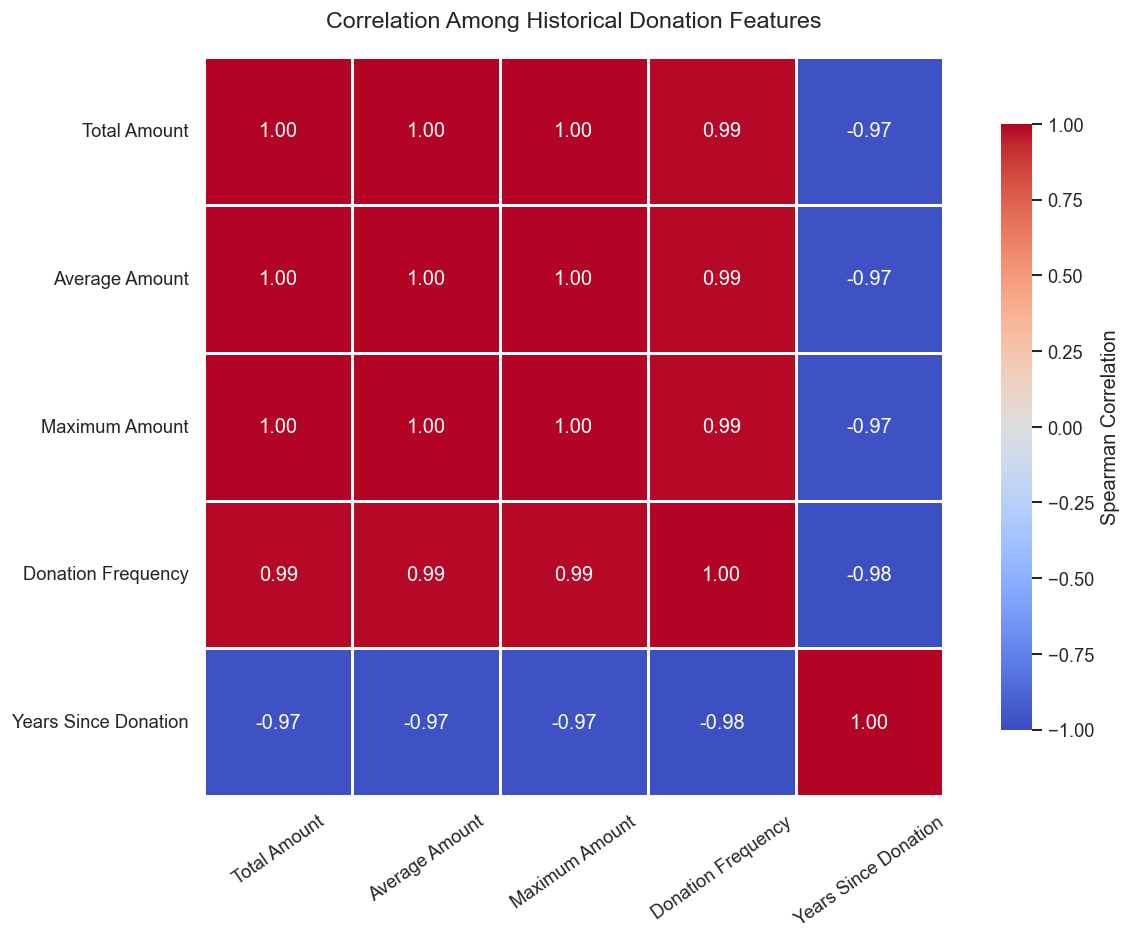

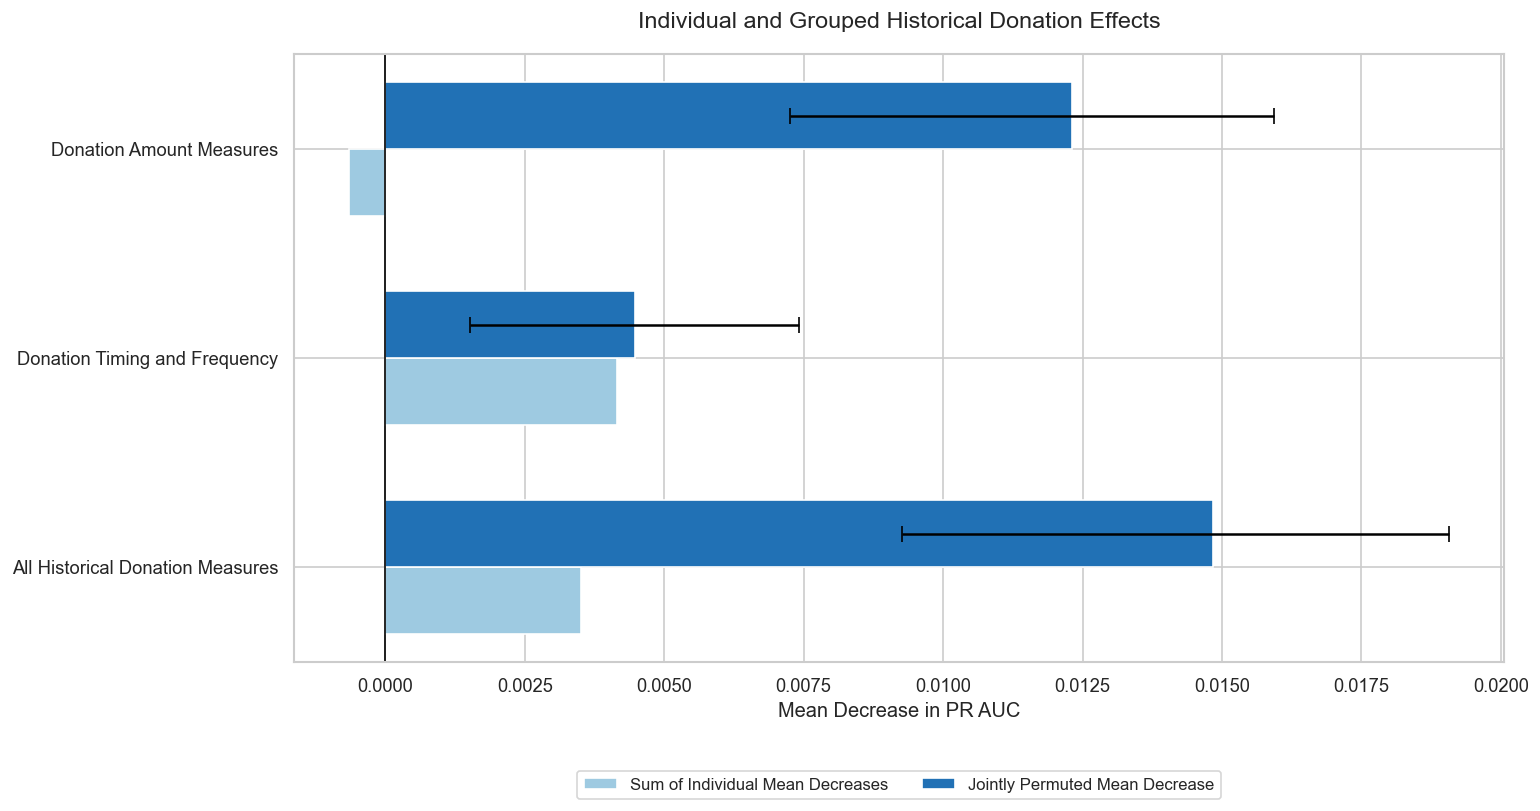

Correlation Rank,Feature Pair,Spearman Correlation,Absolute Correlation,Correlation Strength
1,Total Donation Amount (Past 5 Years) × Average Donation Amount (Past 5 Years),1.0000,1.0000,Strong
2,Average Donation Amount (Past 5 Years) × Maximum Annual Donation Amount (Past 5 Years),0.9998,0.9998,Strong
3,Total Donation Amount (Past 5 Years) × Maximum Annual Donation Amount (Past 5 Years),0.9998,0.9998,Strong
4,Average Donation Amount (Past 5 Years) × Donation Frequency Rate (Past 5 Years),0.9873,0.9873,Strong
5,Total Donation Amount (Past 5 Years) × Donation Frequency Rate (Past 5 Years),0.9873,0.9873,Strong
6,Maximum Annual Donation Amount (Past 5 Years) × Donation Frequency Rate (Past 5 Years),0.9857,0.9857,Strong
7,Donation Frequency Rate (Past 5 Years) × Years Since Most Recent Donation,-0.9834,0.9834,Strong
8,Average Donation Amount (Past 5 Years) × Years Since Most Recent Donation,-0.9716,0.9716,Strong
9,Total Donation Amount (Past 5 Years) × Years Since Most Recent Donation,-0.9716,0.9716,Strong
10,Maximum Annual Donation Amount (Past 5 Years) × Years Since Most Recent Donation,-0.9710,0.9710,Strong


Business-Friendly Label,Most Correlated Business Label,Maximum Absolute Correlation,Random Forest Rank,Random Forest Importance Percentage,Permutation Rank,Mean PR AUC Decrease,SHAP Rank,Mean Absolute SHAP,SHAP Importance Percentage,Importance Interpretation
Total Donation Amount (Past 5 Years),Average Donation Amount (Past 5 Years),1.0000,2,20.88%,5,0.000356,7,0.0011,9.20%,Importance May Be Shared Across Related Features
Average Donation Amount (Past 5 Years),Total Donation Amount (Past 5 Years),1.0000,3,20.84%,6,0.000221,5,0.0012,10.29%,Importance May Be Shared Across Related Features
Maximum Annual Donation Amount (Past 5 Years),Total Donation Amount (Past 5 Years),0.9998,4,18.47%,8,-0.001223,4,0.0013,11.12%,Importance May Be Shared Across Related Features
Donation Frequency Rate (Past 5 Years),Total Donation Amount (Past 5 Years),0.9873,8,2.87%,3,0.001486,8,0.0006,4.69%,Importance May Be Shared Across Related Features
Years Since Most Recent Donation,Donation Frequency Rate (Past 5 Years),0.9834,5,4.70%,2,0.002660,6,0.0012,10.09%,Correlated with Independent Held Out Support


Group,Feature Count,Grouped Mean PR AUC Decrease,Grouped Standard Deviation,Grouped Lower Percentile (2.5%),Grouped Upper Percentile (97.5%),Positive Repeat Percentage,Sum Individual Mean Decreases,Redistribution Gap,Grouped to Positive Sum Ratio,Evidence Classification,Interpretation Status
Donation Amount Measures,3,0.012314,0.002545,0.007251,0.015937,100.00%,-0.000646,0.012960,21.34,Possible Shared Information Across Features,Descriptive Only
Donation Timing and Frequency,2,0.004473,0.001737,0.001524,0.007414,96.67%,0.004146,0.000327,1.08,Possible Shared Information Across Features,Descriptive Only
All Historical Donation Measures,5,0.014837,0.002611,0.009267,0.019070,100.00%,0.003499,0.011338,3.14,Possible Shared Information Across Features,Descriptive Only


Baseline final test PR AUC: 0.070392
Historical donation correlation analysis completed successfully: 30/30 checks passed.
Correlation pairs saved to: outputs/interpretability/tables/primary_historical_donation_correlation_pairs.csv
Importance context saved to: outputs/interpretability/tables/primary_historical_donation_importance_context.csv
Grouped permutation repeats saved to: outputs/interpretability/tables/primary_grouped_permutation_repeats.csv
Grouped permutation summary saved to: outputs/interpretability/tables/primary_grouped_permutation_summary.csv
Correlation figure saved to: outputs/interpretability/figures/primary_historical_donation_correlation.png
Grouped permutation figure saved to: outputs/interpretability/figures/primary_grouped_permutation_comparison.png


In [17]:
# Evaluate correlated historical donation features and importance redistribution
historical_donation_features_task14 = [
    "feature_past_5yr_total_donation",
    "feature_past_5yr_average_donation",
    "feature_past_5yr_max_donation",
    "feature_past_5yr_donation_frequency_rate",
    "feature_years_since_last_donation_past_5yr",
]

missing_historical_features_task14 = set(
    historical_donation_features_task14
).difference(
    features_primary_test_interpretation.columns
)

if missing_historical_features_task14:
    raise KeyError(
        "Required historical donation features are missing: "
        + ", ".join(
            sorted(missing_historical_features_task14)
        )
    )

historical_business_labels_task14 = {
    feature_name: business_labels_primary_sources[feature_name]
    for feature_name in historical_donation_features_task14
}

historical_short_labels_task14 = {
    "feature_past_5yr_total_donation": "Total Amount",
    "feature_past_5yr_average_donation": "Average Amount",
    "feature_past_5yr_max_donation": "Maximum Amount",
    "feature_past_5yr_donation_frequency_rate": (
        "Donation Frequency"
    ),
    "feature_years_since_last_donation_past_5yr": (
        "Years Since Donation"
    ),
}

historical_data_task14 = (
    features_primary_test_interpretation.loc[
        :,
        historical_donation_features_task14,
    ]
    .apply(pd.to_numeric, errors="coerce")
    .copy()
)

historical_spearman_correlation_task14 = (
    historical_data_task14.corr(method="spearman")
)

historical_correlation_pair_records_task14 = []

for first_position, first_feature in enumerate(
    historical_donation_features_task14
):
    for second_feature in historical_donation_features_task14[
        first_position + 1:
    ]:
        spearman_correlation = float(
            historical_spearman_correlation_task14.loc[
                first_feature,
                second_feature,
            ]
        )
        absolute_correlation = abs(spearman_correlation)

        if (
            absolute_correlation
            >= CORRELATION_STRONG_THRESHOLD
        ):
            correlation_strength = "Strong"
        elif (
            absolute_correlation
            >= CORRELATION_MODERATE_THRESHOLD
        ):
            correlation_strength = "Moderate"
        else:
            correlation_strength = "Weak"

        historical_correlation_pair_records_task14.append(
            {
                "Feature Pair": (
                    f"{historical_business_labels_task14[first_feature]}"
                    " × "
                    f"{historical_business_labels_task14[second_feature]}"
                ),
                "First Feature": first_feature,
                "Second Feature": second_feature,
                "Spearman Correlation": spearman_correlation,
                "Absolute Correlation": absolute_correlation,
                "Correlation Strength": correlation_strength,
            }
        )

historical_correlation_pairs_task14 = (
    pd.DataFrame(
        historical_correlation_pair_records_task14
    )
    .sort_values(
        [
            "Absolute Correlation",
            "Feature Pair",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

historical_correlation_pairs_task14.insert(
    0,
    "Correlation Rank",
    np.arange(
        1,
        historical_correlation_pairs_task14.shape[0] + 1,
    ),
)

PRIMARY_BUILTIN_IMPORTANCE_SOURCE_PATH_TASK14 = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_builtin_importance_source.csv"
)

PRIMARY_PERMUTATION_IMPORTANCE_SUMMARY_PATH_TASK14 = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_permutation_importance_summary.csv"
)

PRIMARY_SHAP_IMPORTANCE_SOURCE_PATH_TASK14 = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_importance_source.csv"
)

builtin_importance_source_task14 = pd.read_csv(
    PRIMARY_BUILTIN_IMPORTANCE_SOURCE_PATH_TASK14
)

permutation_importance_source_task14 = pd.read_csv(
    PRIMARY_PERMUTATION_IMPORTANCE_SUMMARY_PATH_TASK14
)

shap_importance_source_task14 = pd.read_csv(
    PRIMARY_SHAP_IMPORTANCE_SOURCE_PATH_TASK14
)

historical_importance_context_task14 = (
    mapping_primary_source_features.loc[
        mapping_primary_source_features[
            "Source Feature"
        ].isin(historical_donation_features_task14),
        [
            "Source Feature",
            "Business-Friendly Label",
        ],
    ]
    .merge(
        builtin_importance_source_task14[
            [
                "Source Feature",
                "Importance Rank",
                "Built In Importance",
                "Importance Percentage",
            ]
        ].rename(
            columns={
                "Importance Rank": "Random Forest Rank",
                "Importance Percentage": (
                    "Random Forest Importance Percentage"
                ),
            }
        ),
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
    .merge(
        permutation_importance_source_task14[
            [
                "Source Feature",
                "Permutation Rank",
                "Mean PR AUC Decrease",
                "Lower Percentile (2.5%)",
                "Upper Percentile (97.5%)",
                "Positive Repeat Percentage",
            ]
        ],
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
    .merge(
        shap_importance_source_task14[
            [
                "Source Feature",
                "SHAP Rank",
                "Mean Absolute SHAP",
                "Importance Percentage",
            ]
        ].rename(
            columns={
                "Importance Percentage": (
                    "SHAP Importance Percentage"
                ),
            }
        ),
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
)

maximum_absolute_correlations_task14 = []
most_correlated_features_task14 = []
most_correlated_business_labels_task14 = []

for feature_name in historical_importance_context_task14[
    "Source Feature"
]:
    feature_correlations = (
        historical_spearman_correlation_task14.loc[
            feature_name
        ]
        .drop(feature_name)
        .abs()
    )

    most_correlated_feature = (
        feature_correlations.idxmax()
    )

    maximum_absolute_correlations_task14.append(
        float(feature_correlations.max())
    )
    most_correlated_features_task14.append(
        most_correlated_feature
    )
    most_correlated_business_labels_task14.append(
        historical_business_labels_task14[
            most_correlated_feature
        ]
    )

historical_importance_context_task14[
    "Maximum Absolute Correlation"
] = maximum_absolute_correlations_task14

historical_importance_context_task14[
    "Most Correlated Feature"
] = most_correlated_features_task14

historical_importance_context_task14[
    "Most Correlated Business Label"
] = most_correlated_business_labels_task14


def classify_correlation_importance_context(
    maximum_absolute_correlation,
    permutation_lower_percentile,
):
    if (
        maximum_absolute_correlation
        >= CORRELATION_STRONG_THRESHOLD
        and permutation_lower_percentile > 0
    ):
        return (
            "Correlated with Independent Held Out Support"
        )

    if (
        maximum_absolute_correlation
        >= CORRELATION_STRONG_THRESHOLD
    ):
        return (
            "Importance May Be Shared Across Related Features"
        )

    if permutation_lower_percentile > 0:
        return "Independent Held Out Support"

    return "Limited Independent Held Out Support"


historical_importance_context_task14[
    "Importance Interpretation"
] = historical_importance_context_task14.apply(
    lambda row: classify_correlation_importance_context(
        row["Maximum Absolute Correlation"],
        row["Lower Percentile (2.5%)"],
    ),
    axis=1,
)

historical_importance_context_task14 = (
    historical_importance_context_task14.sort_values(
        [
            "Maximum Absolute Correlation",
            "Random Forest Rank",
        ],
        ascending=[False, True],
    )
    .reset_index(drop=True)
)

grouped_permutation_definitions_task14 = {
    "Donation Amount Measures": [
        "feature_past_5yr_total_donation",
        "feature_past_5yr_average_donation",
        "feature_past_5yr_max_donation",
    ],
    "Donation Timing and Frequency": [
        "feature_past_5yr_donation_frequency_rate",
        "feature_years_since_last_donation_past_5yr",
    ],
    "All Historical Donation Measures": (
        historical_donation_features_task14
    ),
}

positive_class_index_task14 = int(
    np.flatnonzero(
        model_primary_pipeline_final.classes_ == 1
    )[0]
)

with (
    threadpool_limits(limits=1),
    parallel_backend("threading", n_jobs=1),
):
    baseline_probabilities_task14 = (
        model_primary_pipeline_final.predict_proba(
            features_primary_test_interpretation
        )[:, positive_class_index_task14]
    )

baseline_pr_auc_task14 = average_precision_score(
    target_primary_test_interpretation,
    baseline_probabilities_task14,
)


def calculate_grouped_permutation_task14(
    group_position,
    group_name,
    group_features,
):
    group_random_generator = np.random.default_rng(
        RANDOM_STATE + 1_400 + group_position
    )

    group_repeat_records = []

    for repeat_number in range(
        1,
        GROUPED_PERMUTATION_REPEATS + 1,
    ):
        shuffled_positions = (
            group_random_generator.permutation(
                features_primary_test_interpretation.shape[0]
            )
        )

        permuted_features = (
            features_primary_test_interpretation.copy()
        )

        permuted_features.loc[
            :,
            group_features,
        ] = (
            features_primary_test_interpretation.loc[
                :,
                group_features,
            ]
            .iloc[shuffled_positions]
            .to_numpy()
        )

        with (
            threadpool_limits(limits=1),
            parallel_backend("threading", n_jobs=1),
        ):
            permuted_probabilities = (
                model_primary_pipeline_final.predict_proba(
                    permuted_features
                )[:, positive_class_index_task14]
            )

        permuted_pr_auc = average_precision_score(
            target_primary_test_interpretation,
            permuted_probabilities,
        )

        group_repeat_records.append(
            {
                "Group": group_name,
                "Repeat": repeat_number,
                "Feature Count": len(group_features),
                "Source Features": ", ".join(group_features),
                "Permuted PR AUC": permuted_pr_auc,
                "PR AUC Decrease": (
                    baseline_pr_auc_task14
                    - permuted_pr_auc
                ),
            }
        )

    return group_repeat_records


grouped_permutation_results_task14 = Parallel(
    n_jobs=GROUPED_PERMUTATION_WORKERS,
    backend="loky",
    verbose=5,
)(
    delayed(calculate_grouped_permutation_task14)(
        group_position,
        group_name,
        group_features,
    )
    for group_position, (
        group_name,
        group_features,
    ) in enumerate(
        grouped_permutation_definitions_task14.items()
    )
)

grouped_permutation_repeats_task14 = pd.DataFrame(
    [
        repeat_record
        for group_results in grouped_permutation_results_task14
        for repeat_record in group_results
    ]
)

grouped_permutation_summary_records_task14 = []

permutation_importance_indexed_task14 = (
    permutation_importance_source_task14.set_index(
        "Source Feature"
    )
)

for group_name, group_features in (
    grouped_permutation_definitions_task14.items()
):
    group_repeats = (
        grouped_permutation_repeats_task14.loc[
            grouped_permutation_repeats_task14[
                "Group"
            ]
            == group_name,
            "PR AUC Decrease",
        ]
        .astype(float)
        .to_numpy()
    )

    individual_mean_decreases = (
        permutation_importance_indexed_task14.loc[
            group_features,
            "Mean PR AUC Decrease",
        ]
        .astype(float)
    )

    sum_individual_mean_decreases = float(
        individual_mean_decreases.sum()
    )

    sum_positive_individual_mean_decreases = float(
        individual_mean_decreases.clip(lower=0).sum()
    )

    grouped_mean_decrease = float(
        np.mean(group_repeats)
    )

    grouped_lower_percentile = float(
        np.percentile(group_repeats, 2.5)
    )

    grouped_upper_percentile = float(
        np.percentile(group_repeats, 97.5)
    )

    redistribution_gap = (
        grouped_mean_decrease
        - sum_individual_mean_decreases
    )

    if sum_positive_individual_mean_decreases > 0:
        grouped_to_positive_sum_ratio = (
            grouped_mean_decrease
            / sum_positive_individual_mean_decreases
        )
    else:
        grouped_to_positive_sum_ratio = np.nan

    if (
        grouped_lower_percentile > 0
        and redistribution_gap > 0
    ):
        evidence_classification = (
            "Possible Shared Information Across Features"
        )
    elif grouped_lower_percentile > 0:
        evidence_classification = (
            "Stable Collective Held Out Support"
        )
    elif grouped_upper_percentile < 0:
        evidence_classification = (
            "No Collective Held Out Support"
        )
    else:
        evidence_classification = (
            "Uncertain Collective Effect"
        )

    grouped_permutation_summary_records_task14.append(
        {
            "Group": group_name,
            "Feature Count": len(group_features),
            "Source Features": ", ".join(group_features),
            "Baseline PR AUC": baseline_pr_auc_task14,
            "Grouped Mean PR AUC Decrease": (
                grouped_mean_decrease
            ),
            "Grouped Standard Deviation": float(
                np.std(group_repeats, ddof=1)
            ),
            "Grouped Lower Percentile (2.5%)": (
                grouped_lower_percentile
            ),
            "Grouped Upper Percentile (97.5%)": (
                grouped_upper_percentile
            ),
            "Positive Repeat Percentage": float(
                np.mean(group_repeats > 0) * 100
            ),
            "Sum Individual Mean Decreases": (
                sum_individual_mean_decreases
            ),
            "Sum Positive Individual Mean Decreases": (
                sum_positive_individual_mean_decreases
            ),
            "Redistribution Gap": redistribution_gap,
            "Grouped to Positive Sum Ratio": (
                grouped_to_positive_sum_ratio
            ),
            "Evidence Classification": (
                evidence_classification
            ),
            "Interpretation Status": "Descriptive Only",
        }
    )

grouped_permutation_summary_task14 = pd.DataFrame(
    grouped_permutation_summary_records_task14
)

PRIMARY_HISTORICAL_CORRELATION_PAIRS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_historical_donation_correlation_pairs.csv"
)

PRIMARY_HISTORICAL_IMPORTANCE_CONTEXT_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_historical_donation_importance_context.csv"
)

PRIMARY_GROUPED_PERMUTATION_REPEATS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_grouped_permutation_repeats.csv"
)

PRIMARY_GROUPED_PERMUTATION_SUMMARY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_grouped_permutation_summary.csv"
)

PRIMARY_HISTORICAL_CORRELATION_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_historical_donation_correlation.png"
)

PRIMARY_GROUPED_PERMUTATION_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_grouped_permutation_comparison.png"
)

historical_correlation_pairs_task14.to_csv(
    PRIMARY_HISTORICAL_CORRELATION_PAIRS_PATH,
    index=False,
)

historical_importance_context_task14.to_csv(
    PRIMARY_HISTORICAL_IMPORTANCE_CONTEXT_PATH,
    index=False,
)

grouped_permutation_repeats_task14.to_csv(
    PRIMARY_GROUPED_PERMUTATION_REPEATS_PATH,
    index=False,
)

grouped_permutation_summary_task14.to_csv(
    PRIMARY_GROUPED_PERMUTATION_SUMMARY_PATH,
    index=False,
)

historical_correlation_display_task14 = (
    historical_spearman_correlation_task14.rename(
        index=historical_short_labels_task14,
        columns=historical_short_labels_task14,
    )
)

figure_historical_correlation_task14, axis_task14 = (
    plt.subplots(figsize=(11, 8))
)

sns.heatmap(
    historical_correlation_display_task14,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={
        "label": "Spearman Correlation",
        "shrink": 0.82,
    },
    ax=axis_task14,
)

axis_task14.set_title(
    "Correlation Among Historical Donation Features",
    pad=18,
)
axis_task14.set_xlabel("")
axis_task14.set_ylabel("")
axis_task14.tick_params(
    axis="x",
    rotation=35,
)
axis_task14.tick_params(
    axis="y",
    rotation=0,
)

figure_historical_correlation_task14.tight_layout()
figure_historical_correlation_task14.savefig(
    PRIMARY_HISTORICAL_CORRELATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

grouped_plot_data_task14 = (
    grouped_permutation_summary_task14.iloc[::-1]
    .reset_index(drop=True)
)

grouped_plot_positions_task14 = np.arange(
    grouped_plot_data_task14.shape[0]
)

grouped_bar_height_task14 = 0.32

figure_grouped_permutation_task14, axis_task14 = (
    plt.subplots(figsize=(13, 7))
)

axis_task14.barh(
    grouped_plot_positions_task14
    - grouped_bar_height_task14 / 2,
    grouped_plot_data_task14[
        "Sum Individual Mean Decreases"
    ],
    height=grouped_bar_height_task14,
    label="Sum of Individual Mean Decreases",
    color="#9ecae1",
)

axis_task14.barh(
    grouped_plot_positions_task14
    + grouped_bar_height_task14 / 2,
    grouped_plot_data_task14[
        "Grouped Mean PR AUC Decrease"
    ],
    height=grouped_bar_height_task14,
    label="Jointly Permuted Mean Decrease",
    color="#2171b5",
)

grouped_error_lower_task14 = (
    grouped_plot_data_task14[
        "Grouped Mean PR AUC Decrease"
    ]
    - grouped_plot_data_task14[
        "Grouped Lower Percentile (2.5%)"
    ]
)

grouped_error_upper_task14 = (
    grouped_plot_data_task14[
        "Grouped Upper Percentile (97.5%)"
    ]
    - grouped_plot_data_task14[
        "Grouped Mean PR AUC Decrease"
    ]
)

axis_task14.errorbar(
    grouped_plot_data_task14[
        "Grouped Mean PR AUC Decrease"
    ],
    grouped_plot_positions_task14
    + grouped_bar_height_task14 / 2,
    xerr=np.vstack(
        [
            grouped_error_lower_task14,
            grouped_error_upper_task14,
        ]
    ),
    fmt="none",
    ecolor="black",
    capsize=5,
    linewidth=1.5,
)

axis_task14.axvline(
    0,
    color="black",
    linewidth=1,
)

axis_task14.set_yticks(
    grouped_plot_positions_task14
)

axis_task14.set_yticklabels(
    grouped_plot_data_task14["Group"]
)

axis_task14.set_title(
    "Individual and Grouped Historical Donation Effects",
    pad=16,
)

axis_task14.set_xlabel(
    "Mean Decrease in PR AUC"
)

axis_task14.set_ylabel("")
axis_task14.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.24),
    ncol=2,
    frameon=True,
)

figure_grouped_permutation_task14.tight_layout()
figure_grouped_permutation_task14.savefig(
    PRIMARY_GROUPED_PERMUTATION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

expected_correlation_pair_count_task14 = (
    len(historical_donation_features_task14)
    * (len(historical_donation_features_task14) - 1)
    // 2
)

expected_grouped_repeat_count_task14 = (
    len(grouped_permutation_definitions_task14)
    * GROUPED_PERMUTATION_REPEATS
)

group_repeat_counts_valid_task14 = (
    grouped_permutation_repeats_task14.groupby(
        "Group"
    )["Repeat"]
    .nunique()
    .eq(GROUPED_PERMUTATION_REPEATS)
    .all()
)

historical_correlation_checks_task14 = {
    "All historical donation features are available": (
        not missing_historical_features_task14
    ),
    "Historical data preserves the final test rows": (
        historical_data_task14.shape[0]
        == data_primary_test_interpretation.shape[0]
    ),
    "Correlation matrix has the expected shape": (
        historical_spearman_correlation_task14.shape
        == (
            len(historical_donation_features_task14),
            len(historical_donation_features_task14),
        )
    ),
    "Correlation matrix is symmetric": (
        np.allclose(
            historical_spearman_correlation_task14.to_numpy(),
            historical_spearman_correlation_task14.to_numpy().T,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Correlation diagonal equals one": (
        np.allclose(
            np.diag(
                historical_spearman_correlation_task14
            ),
            1,
            rtol=0,
            atol=1e-12,
        )
    ),
    "All correlations are finite": (
        np.isfinite(
            historical_spearman_correlation_task14.to_numpy()
        ).all()
    ),
    "All unique correlation pairs are represented": (
        historical_correlation_pairs_task14.shape[0]
        == expected_correlation_pair_count_task14
    ),
    "Correlation pair labels are unique": (
        historical_correlation_pairs_task14[
            "Feature Pair"
        ].is_unique
    ),
    "Correlation thresholds are valid": (
        0
        <= CORRELATION_MODERATE_THRESHOLD
        < CORRELATION_STRONG_THRESHOLD
        <= 1
    ),
    "Built in importance contains every historical feature": (
        set(historical_donation_features_task14).issubset(
            builtin_importance_source_task14[
                "Source Feature"
            ]
        )
    ),
    "Permutation importance contains every historical feature": (
        set(historical_donation_features_task14).issubset(
            permutation_importance_source_task14[
                "Source Feature"
            ]
        )
    ),
    "SHAP importance contains every historical feature": (
        set(historical_donation_features_task14).issubset(
            shap_importance_source_task14[
                "Source Feature"
            ]
        )
    ),
    "Importance context covers every historical feature": (
        set(
            historical_importance_context_task14[
                "Source Feature"
            ]
        )
        == set(historical_donation_features_task14)
    ),
    "Most correlated features are identified": (
        historical_importance_context_task14[
            "Most Correlated Feature"
        ].notna().all()
    ),
    "Baseline probabilities match the saved artifact": (
        np.allclose(
            baseline_probabilities_task14,
            data_primary_test_interpretation[
                "prob_primary_donor"
            ].astype(float),
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "Baseline PR AUC is finite": (
        np.isfinite(baseline_pr_auc_task14)
    ),
    "Grouped definitions use historical features only": (
        all(
            set(group_features).issubset(
                historical_donation_features_task14
            )
            for group_features
            in grouped_permutation_definitions_task14.values()
        )
    ),
    "Complete historical group contains all five features": (
        set(
            grouped_permutation_definitions_task14[
                "All Historical Donation Measures"
            ]
        )
        == set(historical_donation_features_task14)
    ),
    "No donor identifier is included in a permutation group": (
        all(
            "donor_unique_id" not in group_features
            for group_features
            in grouped_permutation_definitions_task14.values()
        )
    ),
    "Worker count is within the approved limit": (
        1 <= GROUPED_PERMUTATION_WORKERS <= 4
    ),
    "Grouped permutation row count is correct": (
        grouped_permutation_repeats_task14.shape[0]
        == expected_grouped_repeat_count_task14
    ),
    "Every group contains the required repetitions": (
        group_repeat_counts_valid_task14
    ),
    "All permuted PR AUC values are finite": (
        np.isfinite(
            grouped_permutation_repeats_task14[
                "Permuted PR AUC"
            ]
        ).all()
    ),
    "All grouped PR AUC decreases are finite": (
        np.isfinite(
            grouped_permutation_repeats_task14[
                "PR AUC Decrease"
            ]
        ).all()
    ),
    "Grouped summary contains every defined group": (
        set(
            grouped_permutation_summary_task14["Group"]
        )
        == set(grouped_permutation_definitions_task14)
    ),
    "Grouped percentile ranges are ordered": (
        (
            grouped_permutation_summary_task14[
                "Grouped Lower Percentile (2.5%)"
            ]
            <= grouped_permutation_summary_task14[
                "Grouped Upper Percentile (97.5%)"
            ]
        ).all()
    ),
    "Positive repeat percentages are valid": (
        grouped_permutation_summary_task14[
            "Positive Repeat Percentage"
        ].between(0, 100).all()
    ),
    "Importance comparison values are finite": (
        np.isfinite(
            historical_importance_context_task14[
                [
                    "Built In Importance",
                    "Mean PR AUC Decrease",
                    "Mean Absolute SHAP",
                    "Maximum Absolute Correlation",
                ]
            ].to_numpy()
        ).all()
    ),
    "All output tables were saved": (
        PRIMARY_HISTORICAL_CORRELATION_PAIRS_PATH.exists()
        and PRIMARY_HISTORICAL_IMPORTANCE_CONTEXT_PATH.exists()
        and PRIMARY_GROUPED_PERMUTATION_REPEATS_PATH.exists()
        and PRIMARY_GROUPED_PERMUTATION_SUMMARY_PATH.exists()
    ),
    "Both output figures were saved": (
        PRIMARY_HISTORICAL_CORRELATION_FIGURE_PATH.exists()
        and PRIMARY_GROUPED_PERMUTATION_FIGURE_PATH.exists()
    ),
}

failed_historical_correlation_checks_task14 = [
    check_name
    for check_name, check_passed
    in historical_correlation_checks_task14.items()
    if not bool(check_passed)
]

if failed_historical_correlation_checks_task14:
    raise AssertionError(
        "Historical donation correlation analysis failed for: "
        + ", ".join(
            failed_historical_correlation_checks_task14
        )
    )

display(
    historical_correlation_pairs_task14[
        [
            "Correlation Rank",
            "Feature Pair",
            "Spearman Correlation",
            "Absolute Correlation",
            "Correlation Strength",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Correlation Rank": "{:,.0f}",
            "Feature Pair": "{}",
            "Spearman Correlation": "{:.4f}",
            "Absolute Correlation": "{:.4f}",
            "Correlation Strength": "{}",
        }
    )
)

display(
    historical_importance_context_task14[
        [
            "Business-Friendly Label",
            "Most Correlated Business Label",
            "Maximum Absolute Correlation",
            "Random Forest Rank",
            "Random Forest Importance Percentage",
            "Permutation Rank",
            "Mean PR AUC Decrease",
            "SHAP Rank",
            "Mean Absolute SHAP",
            "SHAP Importance Percentage",
            "Importance Interpretation",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Business-Friendly Label": "{}",
            "Most Correlated Business Label": "{}",
            "Maximum Absolute Correlation": "{:.4f}",
            "Random Forest Rank": "{:,.0f}",
            "Random Forest Importance Percentage": "{:.2f}%",
            "Permutation Rank": "{:,.0f}",
            "Mean PR AUC Decrease": "{:.6f}",
            "SHAP Rank": "{:,.0f}",
            "Mean Absolute SHAP": "{:.4f}",
            "SHAP Importance Percentage": "{:.2f}%",
            "Importance Interpretation": "{}",
        }
    )
)

display(
    grouped_permutation_summary_task14[
        [
            "Group",
            "Feature Count",
            "Grouped Mean PR AUC Decrease",
            "Grouped Standard Deviation",
            "Grouped Lower Percentile (2.5%)",
            "Grouped Upper Percentile (97.5%)",
            "Positive Repeat Percentage",
            "Sum Individual Mean Decreases",
            "Redistribution Gap",
            "Grouped to Positive Sum Ratio",
            "Evidence Classification",
            "Interpretation Status",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Group": "{}",
            "Feature Count": "{:,.0f}",
            "Grouped Mean PR AUC Decrease": "{:.6f}",
            "Grouped Standard Deviation": "{:.6f}",
            "Grouped Lower Percentile (2.5%)": "{:.6f}",
            "Grouped Upper Percentile (97.5%)": "{:.6f}",
            "Positive Repeat Percentage": "{:.2f}%",
            "Sum Individual Mean Decreases": "{:.6f}",
            "Redistribution Gap": "{:.6f}",
            "Grouped to Positive Sum Ratio": "{:.2f}",
            "Evidence Classification": "{}",
            "Interpretation Status": "{}",
        }
    )
)

print(
    "Baseline final test PR AUC: "
    f"{baseline_pr_auc_task14:.6f}"
)

print(
    "Historical donation correlation analysis completed "
    "successfully: "
    f"{sum(historical_correlation_checks_task14.values())}/"
    f"{len(historical_correlation_checks_task14)} "
    "checks passed."
)

print(
    "Correlation pairs saved to: "
    f"{PRIMARY_HISTORICAL_CORRELATION_PAIRS_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Importance context saved to: "
    f"{PRIMARY_HISTORICAL_IMPORTANCE_CONTEXT_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Grouped permutation repeats saved to: "
    f"{PRIMARY_GROUPED_PERMUTATION_REPEATS_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Grouped permutation summary saved to: "
    f"{PRIMARY_GROUPED_PERMUTATION_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Correlation figure saved to: "
    f"{PRIMARY_HISTORICAL_CORRELATION_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Grouped permutation figure saved to: "
    f"{PRIMARY_GROUPED_PERMUTATION_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

## Feature Interactions and Correlated Historical Donation Features
SHAP interaction values were calculated using a stratified sample of 2,000 final test records and 500 bootstrap repetitions. All 24 validation checks passed. The interaction results are treated as candidates rather than confirmed relationships. The strongest interaction candidates were:
- Donor age and gender identity at 0.0010.
- Donor age and preferred address type at 0.0008.
- Total and maximum donation amounts at 0.0008.
- Average and maximum donation amounts at 0.0007.
- Total and average donation amounts at 0.0006.

The first four candidates remained among the top five in every bootstrap repetition. The fifth remained in the top five in 97.60% of repetitions. The grouped heatmaps showed that these effects vary across age, demographic, address, and donation value groups. These patterns remain descriptive and should not be interpreted as causal relationships.

The five historical donation features were also evaluated for correlation and shared predictive information. All feature pairs had absolute Spearman correlations above 0.97. Total and average donation amounts had identical rank ordering, while years since donation was strongly negatively correlated with the amount and frequency measures. Grouped permutation results showed that correlation divided importance across related predictors:
- The three donation amount measures produced a joint PR AUC decrease of 0.0123, compared with an individual sum of -0.0006.
- Donation timing and frequency produced a joint decrease of 0.0045, compared with an individual sum of 0.0041.
- All five historical donation measures produced a joint decrease of 0.0148, compared with an individual sum of 0.0035.

These results explain why the donation amount features ranked highly using Random Forest and SHAP importance but appeared weak when permuted individually. When one feature is disrupted, the remaining correlated features can provide similar information. Joint permutation removes this substitute information and reveals their stronger collective contribution. The historical donation measures should therefore be interpreted as a shared behavior signal rather than five independent effects.


Source SHAP storage format recovered: Wide Source SHAP Table


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:   39.9s finished


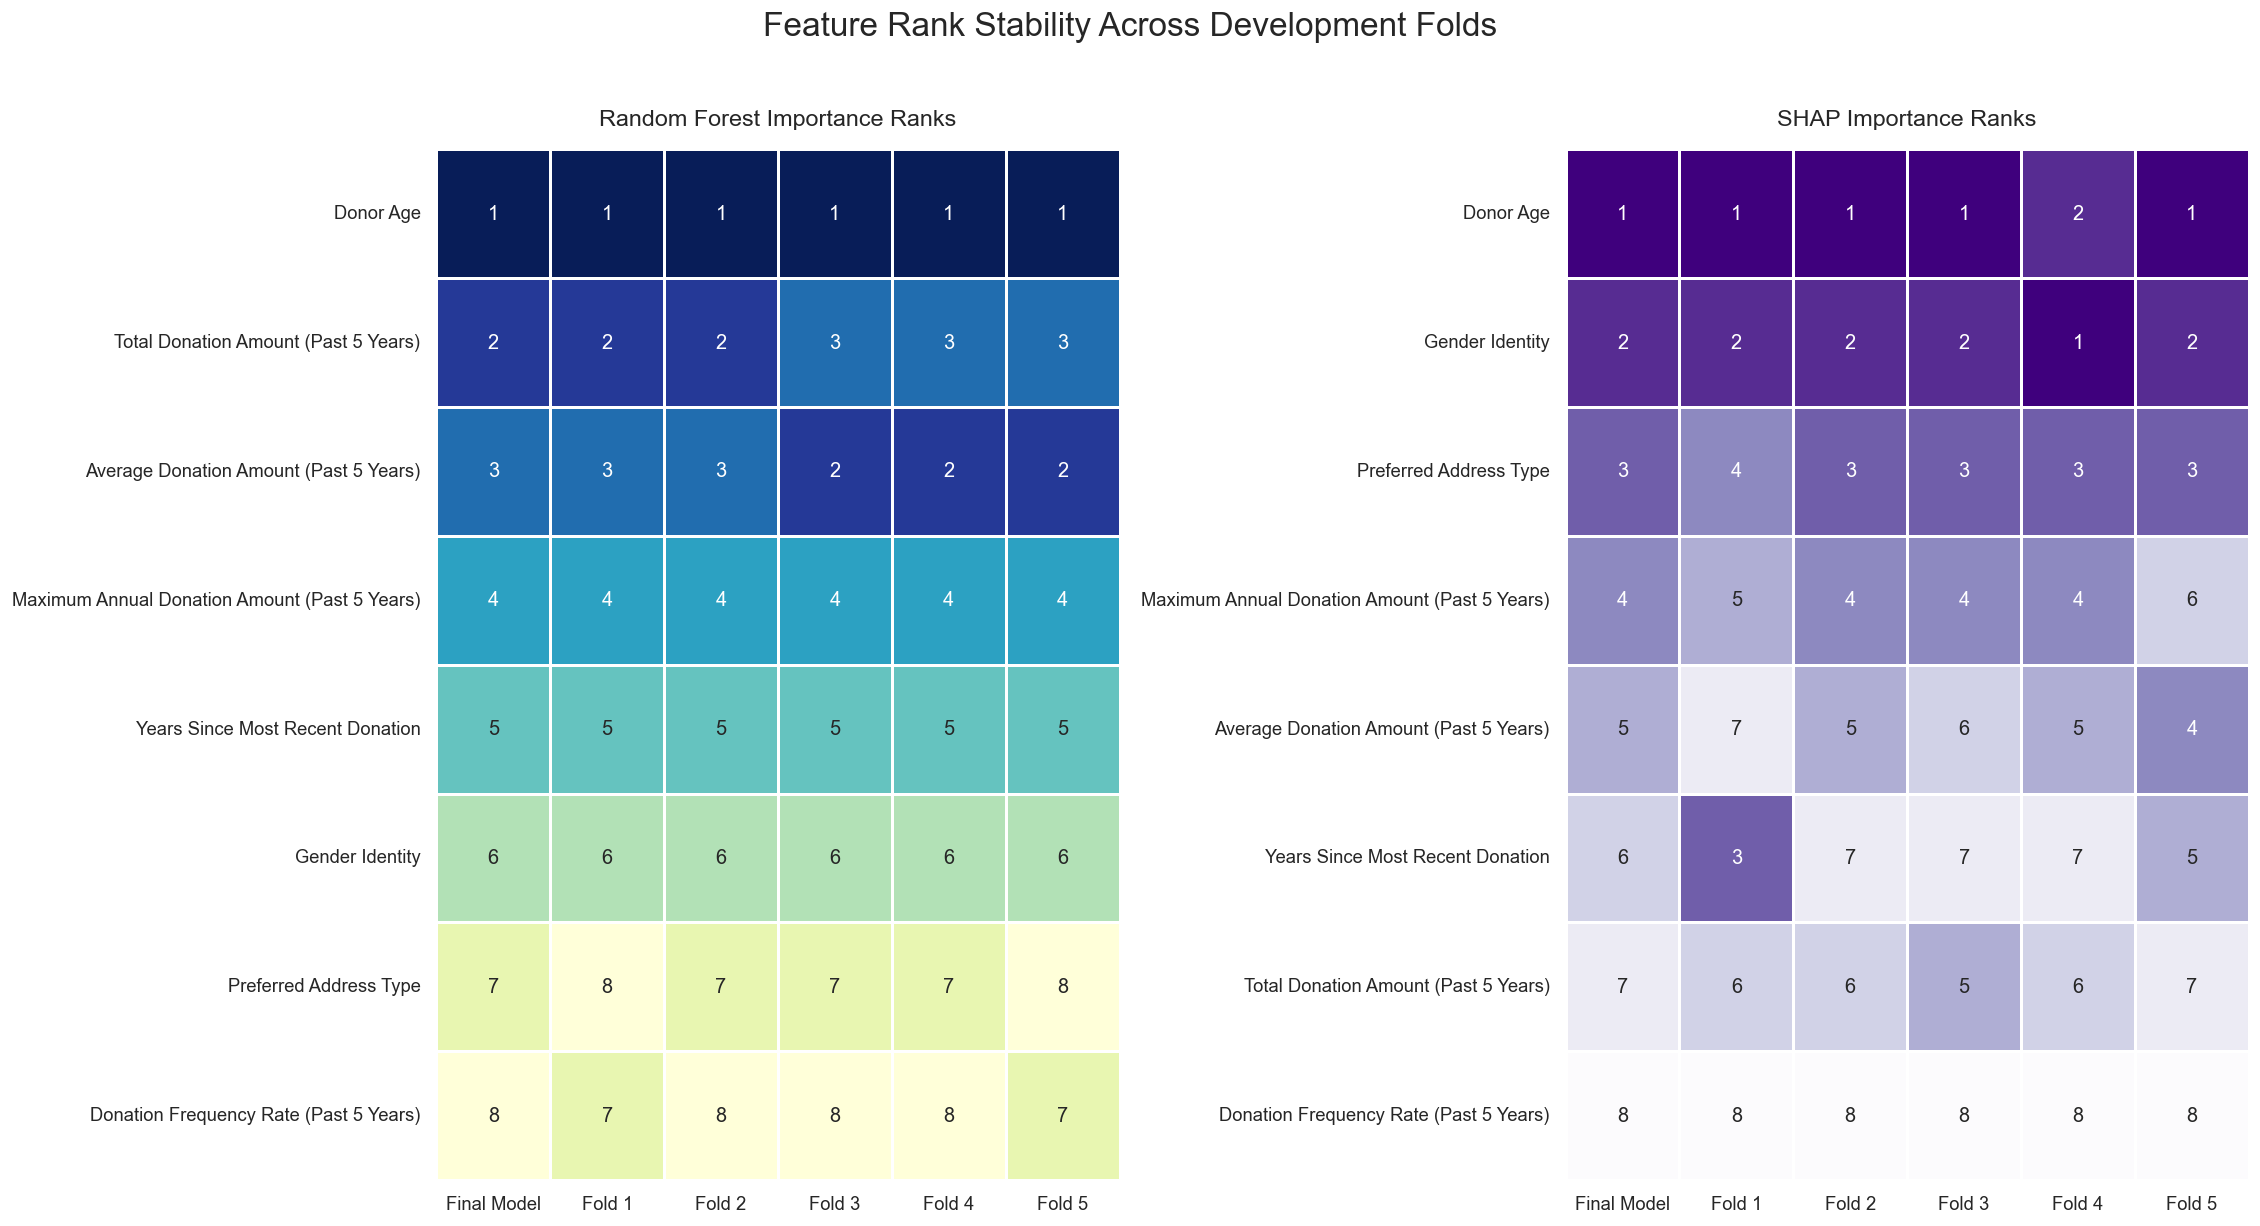

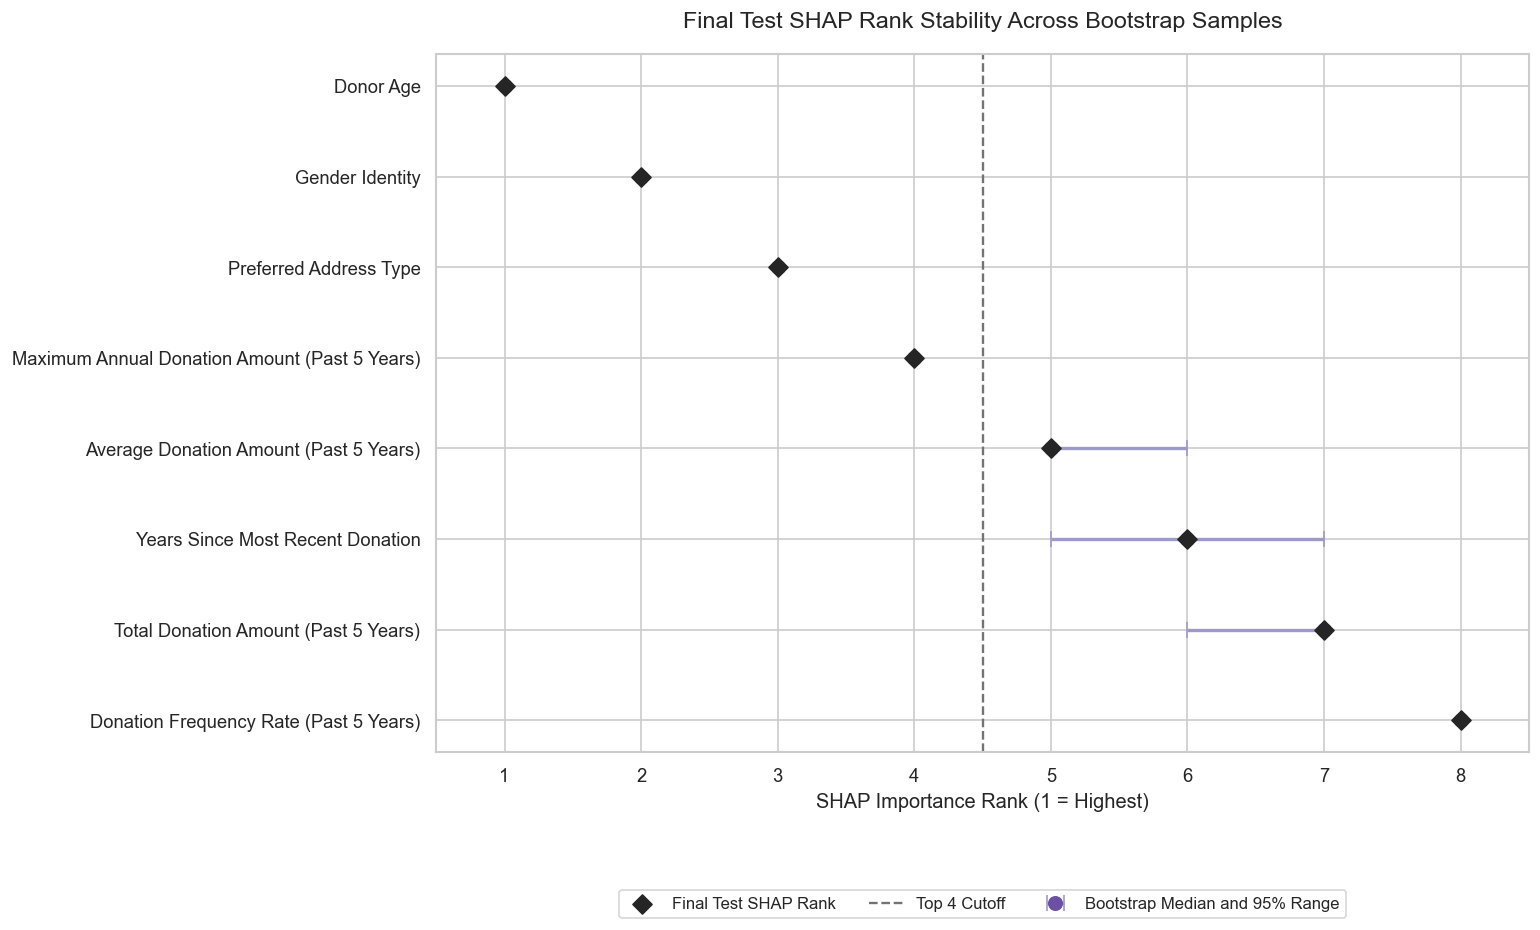

Development Folds,SHAP Records Per Fold,Final Test Bootstrap Iterations,Worker Processes,Top Feature Cutoff,Mean Built In Fold Correlation,Minimum Built In Fold Correlation,Mean SHAP Fold Correlation,Minimum SHAP Fold Correlation,Mean Bootstrap SHAP Correlation,Minimum Bootstrap SHAP Correlation,Mean Bootstrap Top Feature Overlap,Model Status
5,"2,000",500,2,4,0.9762,0.9524,0.9190,0.8095,0.9881,0.9286,99.70%,Frozen Final Model with Diagnostic Fold Copies


Fold,Validation Records,Validation Positive Targets,Validation PR AUC,Built In Rank Correlation,SHAP Rank Correlation,Fold Cross Method Rank Correlation,Built In Top Feature Overlap,Built In Top Feature Overlap Percentage,SHAP Top Feature Overlap,SHAP Top Feature Overlap Percentage,Maximum Additivity Error
1,"5,505",305,0.082871,0.9762,0.8095,0.1667,4,100.00%,3,75.00%,2.44e-15
2,"5,505",305,0.069000,1.0000,0.9762,0.3333,4,100.00%,4,100.00%,8.88e-16
3,"5,504",304,0.076692,0.9762,0.9286,0.3333,4,100.00%,4,100.00%,6.11e-16
4,"5,504",304,0.101468,0.9762,0.9524,0.2381,4,100.00%,4,100.00%,2.00e-15
5,"5,504",305,0.057807,0.9524,0.9286,0.2143,4,100.00%,3,75.00%,1.03e-15


Business-Friendly Label,Reference Built In Rank,Mean Fold Built In Rank,Fold Built In Rank Standard Deviation,Fold Built In Rank Range,Reference SHAP Rank,Mean Fold SHAP Rank,Fold SHAP Rank Standard Deviation,Fold SHAP Rank Range,Median Bootstrap SHAP Rank,Bootstrap Rank Lower Percentile (2.5%),Bootstrap Rank Upper Percentile (97.5%),Bootstrap Top Feature Percentage,Stability Classification,Final Test Bootstrap Support
Donor Age,1,1.00,0.00,0,1,1.20,0.45,1,1.00,1.00,1.00,100.00%,Highly Stable,Consistent Top Feature
Gender Identity,6,6.00,0.00,0,2,1.80,0.45,1,2.00,2.00,2.00,100.00%,Highly Stable,Consistent Top Feature
Preferred Address Type,7,7.40,0.55,1,3,3.20,0.45,1,3.00,3.00,3.00,100.00%,Highly Stable,Consistent Top Feature
Maximum Annual Donation Amount (Past 5 Years),4,4.00,0.00,0,4,4.60,0.89,2,4.00,4.00,4.00,98.80%,Highly Stable,Consistent Top Feature
Average Donation Amount (Past 5 Years),3,2.40,0.55,1,5,5.40,1.14,3,5.00,5.00,6.00,0.00%,Moderately Stable,Usually Outside Top Features
Years Since Most Recent Donation,5,5.00,0.00,0,6,5.80,1.79,4,6.00,5.00,7.00,1.20%,Moderately Stable,Usually Outside Top Features
Total Donation Amount (Past 5 Years),2,2.60,0.55,1,7,6.00,0.71,2,7.00,6.00,7.00,0.00%,Highly Stable,Usually Outside Top Features
Donation Frequency Rate (Past 5 Years),8,7.60,0.55,1,8,8.00,0.00,0,8.00,8.00,8.00,0.00%,Highly Stable,Usually Outside Top Features


Feature importance and SHAP stability analysis completed successfully: 33/33 checks passed.
Fold rankings saved to: outputs/interpretability/tables/primary_stability_fold_feature_rankings.csv
Fold agreement saved to: outputs/interpretability/tables/primary_stability_fold_agreement.csv
Bootstrap rankings saved to: outputs/interpretability/tables/primary_stability_shap_bootstrap_rankings.csv
Bootstrap summary saved to: outputs/interpretability/tables/primary_stability_shap_bootstrap_summary.csv
Feature stability summary saved to: outputs/interpretability/tables/primary_stability_feature_summary.csv
Fold rank figure saved to: outputs/interpretability/figures/primary_stability_fold_rank_heatmaps.png
Bootstrap rank figure saved to: outputs/interpretability/figures/primary_stability_shap_bootstrap_intervals.png


In [18]:
# Test feature importance and SHAP ranking stability
if not 1 <= STABILITY_WORKERS <= 4:
    raise ValueError(
        "STABILITY_WORKERS must be between 1 and 4."
    )

if not 1 <= STABILITY_TOP_FEATURE_COUNT <= len(
    features_primary_saved
):
    raise ValueError(
        "STABILITY_TOP_FEATURE_COUNT must be valid."
    )

PRIMARY_STABILITY_BUILTIN_REFERENCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_builtin_importance_source.csv"
)

PRIMARY_STABILITY_SHAP_REFERENCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_importance_source.csv"
)

PRIMARY_STABILITY_SOURCE_SHAP_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_values_source_final_test.csv"
)

builtin_reference_task15 = pd.read_csv(
    PRIMARY_STABILITY_BUILTIN_REFERENCE_PATH
)

shap_reference_task15 = pd.read_csv(
    PRIMARY_STABILITY_SHAP_REFERENCE_PATH
)

source_shap_saved_task15 = pd.read_csv(
    PRIMARY_STABILITY_SOURCE_SHAP_PATH
)


def normalize_saved_column_task15(column_name):
    return (
        str(column_name)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )


normalized_saved_columns_task15 = {
    normalize_saved_column_task15(column_name): (
        column_name
    )
    for column_name
    in source_shap_saved_task15.columns
}

source_shap_column_map_task15 = {}

for source_feature in features_primary_saved:
    normalized_source_feature = (
        normalize_saved_column_task15(
            source_feature
        )
    )

    normalized_business_label = (
        normalize_saved_column_task15(
            business_labels_primary_sources[
                source_feature
            ]
        )
    )

    possible_column_names = {
        normalized_source_feature,
        normalized_business_label,
        f"shap_{normalized_source_feature}",
        f"shap_value_{normalized_source_feature}",
        f"source_shap_{normalized_source_feature}",
        f"source_shap_value_{normalized_source_feature}",
        f"{normalized_source_feature}_shap",
        f"{normalized_source_feature}_shap_value",
        f"shap_{normalized_business_label}",
        f"shap_value_{normalized_business_label}",
        f"{normalized_business_label}_shap",
        f"{normalized_business_label}_shap_value",
    }

    matching_columns = [
        original_column
        for normalized_column, original_column
        in normalized_saved_columns_task15.items()
        if (
            normalized_column
            in possible_column_names
            or normalized_column.endswith(
                f"__{normalized_source_feature}"
            )
        )
    ]

    if len(matching_columns) == 1:
        source_shap_column_map_task15[
            source_feature
        ] = matching_columns[0]

if len(source_shap_column_map_task15) == len(
    features_primary_saved
):
    source_shap_final_test_task15 = (
        source_shap_saved_task15.loc[
            :,
            [
                source_shap_column_map_task15[
                    source_feature
                ]
                for source_feature
                in features_primary_saved
            ],
        ]
        .rename(
            columns={
                saved_column: source_feature
                for source_feature, saved_column
                in source_shap_column_map_task15.items()
            }
        )
        .astype(float)
        .reset_index(drop=True)
        .copy()
    )

    source_shap_storage_format_task15 = (
        "Wide Source SHAP Table"
    )

else:
    feature_column_candidates_task15 = [
        original_column
        for normalized_column, original_column
        in normalized_saved_columns_task15.items()
        if normalized_column
        in {
            "source_feature",
            "feature",
            "feature_name",
            "business_friendly_label",
            "business_label",
        }
    ]

    value_column_candidates_task15 = [
        original_column
        for normalized_column, original_column
        in normalized_saved_columns_task15.items()
        if normalized_column
        in {
            "shap",
            "shap_value",
            "shap_contribution",
            "source_shap",
            "source_shap_value",
            "source_shap_contribution",
        }
    ]

    row_column_candidates_task15 = [
        original_column
        for normalized_column, original_column
        in normalized_saved_columns_task15.items()
        if normalized_column
        in {
            "final_test_row",
            "final_test_row_order",
            "final_test_position",
            "row",
            "row_index",
            "row_order",
            "row_position",
            "record_index",
            "record_order",
            "record_position",
        }
    ]

    if (
        not feature_column_candidates_task15
        or not value_column_candidates_task15
    ):
        raise KeyError(
            "The saved source SHAP structure was not "
            "recognized. Available columns: "
            + ", ".join(
                map(
                    str,
                    source_shap_saved_task15.columns,
                )
            )
        )

    feature_column_task15 = (
        feature_column_candidates_task15[0]
    )

    value_column_task15 = (
        value_column_candidates_task15[0]
    )

    source_shap_long_task15 = (
        source_shap_saved_task15.copy()
    )

    business_label_to_source_task15 = {
        str(business_label).strip(): source_feature
        for source_feature, business_label
        in business_labels_primary_sources.items()
    }

    source_shap_long_task15[
        "_source_feature"
    ] = (
        source_shap_long_task15[
            feature_column_task15
        ]
        .astype(str)
        .str.strip()
        .replace(
            business_label_to_source_task15
        )
    )

    source_shap_long_task15 = (
        source_shap_long_task15.loc[
            source_shap_long_task15[
                "_source_feature"
            ].isin(features_primary_saved)
        ]
        .copy()
    )

    if row_column_candidates_task15:
        row_column_task15 = (
            row_column_candidates_task15[0]
        )

        saved_row_order_task15 = pd.Index(
            source_shap_long_task15[
                row_column_task15
            ].drop_duplicates()
        )

        source_shap_long_task15[
            "_row_order"
        ] = pd.Categorical(
            source_shap_long_task15[
                row_column_task15
            ],
            categories=saved_row_order_task15,
            ordered=True,
        ).codes

    else:
        source_shap_long_task15[
            "_row_order"
        ] = source_shap_long_task15.groupby(
            "_source_feature",
            sort=False,
        ).cumcount()

    duplicate_source_shap_rows_task15 = (
        source_shap_long_task15.duplicated(
            subset=[
                "_row_order",
                "_source_feature",
            ]
        ).any()
    )

    if duplicate_source_shap_rows_task15:
        raise ValueError(
            "The source SHAP table contains duplicate "
            "row and feature combinations."
        )

    source_shap_final_test_task15 = (
        source_shap_long_task15.pivot(
            index="_row_order",
            columns="_source_feature",
            values=value_column_task15,
        )
        .sort_index()
        .reindex(columns=features_primary_saved)
        .reset_index(drop=True)
        .astype(float)
        .copy()
    )

    source_shap_storage_format_task15 = (
        "Long Source SHAP Table"
    )

missing_source_shap_columns_task15 = set(
    features_primary_saved
).difference(
    source_shap_final_test_task15.columns
)

if missing_source_shap_columns_task15:
    raise KeyError(
        "Source SHAP features remain missing after "
        "reshaping: "
        + ", ".join(
            sorted(missing_source_shap_columns_task15)
        )
    )

if (
    source_shap_final_test_task15.shape[0]
    != data_primary_test_interpretation.shape[0]
):
    raise ValueError(
        "The reconstructed source SHAP row count does "
        "not match the final test dataset. "
        f"Observed {source_shap_final_test_task15.shape[0]:,}; "
        "expected "
        f"{data_primary_test_interpretation.shape[0]:,}."
    )

print(
    "Source SHAP storage format recovered: "
    f"{source_shap_storage_format_task15}"
)

reference_builtin_ranks_task15 = (
    builtin_reference_task15.set_index(
        "Source Feature"
    )["Importance Rank"]
    .reindex(features_primary_saved)
    .astype(int)
)

reference_shap_ranks_task15 = (
    shap_reference_task15.set_index(
        "Source Feature"
    )["SHAP Rank"]
    .reindex(features_primary_saved)
    .astype(int)
)

source_feature_indices_task15 = {}

transformed_source_lookup_task15 = (
    mapping_primary_transformed_features.set_index(
        "Transformed Feature"
    )["Source Feature"]
)

for source_feature in features_primary_saved:
    source_feature_indices_task15[source_feature] = [
        transformed_position
        for transformed_position, transformed_feature
        in enumerate(features_primary_transformed)
        if transformed_source_lookup_task15.loc[
            transformed_feature
        ]
        == source_feature
    ]


def assign_unique_descending_ranks_task15(values):
    values_array = np.asarray(values, dtype=float)

    descending_order = np.argsort(
        -values_array,
        kind="stable",
    )

    ranks = np.empty(
        values_array.shape[0],
        dtype=int,
    )

    ranks[descending_order] = np.arange(
        1,
        values_array.shape[0] + 1,
    )

    return ranks


def extract_positive_class_shap_task15(
    raw_shap_values,
    record_count,
    feature_count,
    positive_class_index,
    class_count,
):
    if isinstance(raw_shap_values, list):
        normalized_shap_values = np.asarray(
            raw_shap_values[positive_class_index]
        )
        raw_shape = str(
            [
                np.asarray(class_values).shape
                for class_values in raw_shap_values
            ]
        )
        raw_layout = "List by class"
    else:
        raw_array = np.asarray(raw_shap_values)
        raw_shape = str(raw_array.shape)

        if raw_array.ndim == 2:
            normalized_shap_values = raw_array
            raw_layout = "Records by features"
        elif (
            raw_array.ndim == 3
            and raw_array.shape
            == (
                record_count,
                feature_count,
                class_count,
            )
        ):
            normalized_shap_values = raw_array[
                :,
                :,
                positive_class_index,
            ]
            raw_layout = (
                "Records by features by classes"
            )
        elif (
            raw_array.ndim == 3
            and raw_array.shape
            == (
                class_count,
                record_count,
                feature_count,
            )
        ):
            normalized_shap_values = raw_array[
                positive_class_index
            ]
            raw_layout = (
                "Classes by records by features"
            )
        else:
            raise ValueError(
                "Unsupported SHAP value shape: "
                f"{raw_array.shape}"
            )

    if normalized_shap_values.shape != (
        record_count,
        feature_count,
    ):
        raise ValueError(
            "Normalized SHAP values have the wrong shape: "
            f"{normalized_shap_values.shape}"
        )

    return (
        normalized_shap_values,
        raw_shape,
        raw_layout,
    )


def extract_positive_expected_value_task15(
    expected_value,
    positive_class_index,
):
    expected_array = np.asarray(
        expected_value,
        dtype=float,
    )

    if expected_array.ndim == 0:
        return float(expected_array)

    return float(
        expected_array.reshape(-1)[
            positive_class_index
        ]
    )


def select_stratified_fold_sample_task15(
    target_values,
    requested_sample_size,
    random_generator,
):
    target_array = np.asarray(
        target_values,
        dtype=int,
    )

    record_count = target_array.shape[0]

    if requested_sample_size >= record_count:
        return np.arange(record_count)

    positive_positions = np.flatnonzero(
        target_array == 1
    )

    negative_positions = np.flatnonzero(
        target_array == 0
    )

    positive_sample_count = int(
        round(
            requested_sample_size
            * positive_positions.shape[0]
            / record_count
        )
    )

    positive_sample_count = min(
        max(positive_sample_count, 1),
        positive_positions.shape[0],
    )

    negative_sample_count = (
        requested_sample_size
        - positive_sample_count
    )

    negative_sample_count = min(
        max(negative_sample_count, 1),
        negative_positions.shape[0],
    )

    positive_sample_positions = (
        random_generator.choice(
            positive_positions,
            size=positive_sample_count,
            replace=False,
        )
    )

    negative_sample_positions = (
        random_generator.choice(
            negative_positions,
            size=negative_sample_count,
            replace=False,
        )
    )

    sample_positions = np.concatenate(
        [
            positive_sample_positions,
            negative_sample_positions,
        ]
    )

    random_generator.shuffle(sample_positions)

    return sample_positions


def calculate_development_fold_stability_task15(
    fold_number,
    training_positions,
    validation_positions,
):
    fold_pipeline = clone(
        model_primary_pipeline_final
    )

    fold_classifier_before_fit = (
        fold_pipeline.steps[-1][1]
    )

    if (
        "n_jobs"
        in fold_classifier_before_fit.get_params()
    ):
        fold_classifier_before_fit.set_params(
            n_jobs=1
        )

    fold_training_features = (
        features_primary_development_interpretation.iloc[
            training_positions
        ]
    )

    fold_training_target = (
        target_primary_development_interpretation.iloc[
            training_positions
        ]
    )

    fold_validation_features = (
        features_primary_development_interpretation.iloc[
            validation_positions
        ]
    )

    fold_validation_target = (
        target_primary_development_interpretation.iloc[
            validation_positions
        ]
    )

    with (
        threadpool_limits(limits=1),
        parallel_backend("threading", n_jobs=1),
    ):
        fold_pipeline.fit(
            fold_training_features,
            fold_training_target,
        )

        fold_validation_probabilities = (
            fold_pipeline.predict_proba(
                fold_validation_features
            )
        )

    fold_positive_class_index = int(
        np.flatnonzero(
            fold_pipeline.classes_ == 1
        )[0]
    )

    fold_validation_positive_probabilities = (
        fold_validation_probabilities[
            :,
            fold_positive_class_index,
        ]
    )

    fold_pr_auc = average_precision_score(
        fold_validation_target,
        fold_validation_positive_probabilities,
    )

    fold_preprocessor = fold_pipeline.steps[0][1]
    fold_classifier = fold_pipeline.steps[-1][1]

    fold_transformed_names = list(
        fold_preprocessor.get_feature_names_out()
    )

    if (
        fold_transformed_names
        != features_primary_transformed
    ):
        raise AssertionError(
            "Fold transformed features do not match "
            "the finalized feature mapping."
        )

    transformed_builtin_importance = np.asarray(
        fold_classifier.feature_importances_,
        dtype=float,
    )

    source_builtin_importance = np.asarray(
        [
            transformed_builtin_importance[
                source_feature_indices_task15[
                    source_feature
                ]
            ].sum()
            for source_feature in features_primary_saved
        ],
        dtype=float,
    )

    source_builtin_ranks = (
        assign_unique_descending_ranks_task15(
            source_builtin_importance
        )
    )

    fold_sample_random_generator = (
        np.random.default_rng(
            RANDOM_STATE + 1_500 + fold_number
        )
    )

    fold_shap_sample_positions = (
        select_stratified_fold_sample_task15(
            fold_validation_target,
            STABILITY_SHAP_RECORDS_PER_FOLD,
            fold_sample_random_generator,
        )
    )

    fold_shap_source_features = (
        fold_validation_features.iloc[
            fold_shap_sample_positions
        ]
    )

    fold_shap_target = (
        fold_validation_target.iloc[
            fold_shap_sample_positions
        ]
    )

    fold_shap_transformed_features = (
        fold_preprocessor.transform(
            fold_shap_source_features
        )
    )

    fold_explainer = shap.TreeExplainer(
        fold_classifier,
        feature_perturbation="tree_path_dependent",
        model_output="raw",
    )

    with threadpool_limits(limits=1):
        fold_raw_shap_values = (
            fold_explainer.shap_values(
                fold_shap_transformed_features
            )
        )

    (
        fold_positive_shap_values,
        fold_raw_shap_shape,
        fold_raw_shap_layout,
    ) = extract_positive_class_shap_task15(
        fold_raw_shap_values,
        fold_shap_transformed_features.shape[0],
        fold_shap_transformed_features.shape[1],
        fold_positive_class_index,
        fold_classifier.classes_.shape[0],
    )

    fold_source_shap_values = np.column_stack(
        [
            fold_positive_shap_values[
                :,
                source_feature_indices_task15[
                    source_feature
                ],
            ].sum(axis=1)
            for source_feature in features_primary_saved
        ]
    )

    fold_mean_absolute_source_shap = (
        np.abs(
            fold_source_shap_values
        ).mean(axis=0)
    )

    fold_source_shap_ranks = (
        assign_unique_descending_ranks_task15(
            fold_mean_absolute_source_shap
        )
    )

    fold_expected_value = (
        extract_positive_expected_value_task15(
            fold_explainer.expected_value,
            fold_positive_class_index,
        )
    )

    with (
        threadpool_limits(limits=1),
        parallel_backend("threading", n_jobs=1),
    ):
        fold_shap_model_probabilities = (
            fold_pipeline.predict_proba(
                fold_shap_source_features
            )[:, fold_positive_class_index]
        )

    fold_reconstructed_probabilities = (
        fold_expected_value
        + fold_positive_shap_values.sum(axis=1)
    )

    fold_maximum_additivity_error = float(
        np.max(
            np.abs(
                fold_shap_model_probabilities
                - fold_reconstructed_probabilities
            )
        )
    )

    fold_feature_records = []

    for feature_position, source_feature in enumerate(
        features_primary_saved
    ):
        fold_feature_records.append(
            {
                "Fold": fold_number,
                "Source Feature": source_feature,
                "Business-Friendly Label": (
                    business_labels_primary_sources[
                        source_feature
                    ]
                ),
                "Training Records": (
                    training_positions.shape[0]
                ),
                "Validation Records": (
                    validation_positions.shape[0]
                ),
                "SHAP Records": (
                    fold_shap_sample_positions.shape[0]
                ),
                "SHAP Positive Targets": int(
                    fold_shap_target.sum()
                ),
                "Built In Importance": (
                    source_builtin_importance[
                        feature_position
                    ]
                ),
                "Built In Rank": (
                    source_builtin_ranks[
                        feature_position
                    ]
                ),
                "Mean Absolute SHAP": (
                    fold_mean_absolute_source_shap[
                        feature_position
                    ]
                ),
                "SHAP Rank": (
                    fold_source_shap_ranks[
                        feature_position
                    ]
                ),
            }
        )

    fold_summary_record = {
        "Fold": fold_number,
        "Training Records": training_positions.shape[0],
        "Validation Records": (
            validation_positions.shape[0]
        ),
        "Validation Positive Targets": int(
            fold_validation_target.sum()
        ),
        "Validation Positive Rate": float(
            fold_validation_target.mean() * 100
        ),
        "Validation PR AUC": fold_pr_auc,
        "SHAP Records": (
            fold_shap_sample_positions.shape[0]
        ),
        "SHAP Positive Targets": int(
            fold_shap_target.sum()
        ),
        "Raw SHAP Shape": fold_raw_shap_shape,
        "Raw SHAP Layout": fold_raw_shap_layout,
        "Maximum Additivity Error": (
            fold_maximum_additivity_error
        ),
        "Built In Importance Sum": float(
            source_builtin_importance.sum()
        ),
    }

    return {
        "Feature Records": fold_feature_records,
        "Summary Record": fold_summary_record,
    }


stability_cross_validator_task15 = StratifiedKFold(
    n_splits=expected_primary_decisions["cv_folds"],
    shuffle=True,
    random_state=RANDOM_STATE,
)

development_fold_splits_task15 = list(
    stability_cross_validator_task15.split(
        features_primary_development_interpretation,
        target_primary_development_interpretation,
    )
)

development_validation_assignment_count_task15 = (
    np.zeros(
        features_primary_development_interpretation.shape[0],
        dtype=int,
    )
)

for _, validation_positions in (
    development_fold_splits_task15
):
    development_validation_assignment_count_task15[
        validation_positions
    ] += 1

development_fold_results_task15 = Parallel(
    n_jobs=STABILITY_WORKERS,
    backend="loky",
    verbose=5,
)(
    delayed(
        calculate_development_fold_stability_task15
    )(
        fold_number,
        training_positions,
        validation_positions,
    )
    for fold_number, (
        training_positions,
        validation_positions,
    ) in enumerate(
        development_fold_splits_task15,
        start=1,
    )
)

stability_fold_feature_rankings_task15 = pd.DataFrame(
    [
        feature_record
        for fold_result in development_fold_results_task15
        for feature_record in fold_result[
            "Feature Records"
        ]
    ]
)

stability_fold_configuration_task15 = pd.DataFrame(
    [
        fold_result["Summary Record"]
        for fold_result in development_fold_results_task15
    ]
).sort_values("Fold").reset_index(drop=True)

reference_builtin_rank_array_task15 = (
    reference_builtin_ranks_task15.to_numpy()
)

reference_shap_rank_array_task15 = (
    reference_shap_ranks_task15.to_numpy()
)

reference_builtin_top_features_task15 = set(
    reference_builtin_ranks_task15.loc[
        reference_builtin_ranks_task15
        <= STABILITY_TOP_FEATURE_COUNT
    ].index
)

reference_shap_top_features_task15 = set(
    reference_shap_ranks_task15.loc[
        reference_shap_ranks_task15
        <= STABILITY_TOP_FEATURE_COUNT
    ].index
)

fold_agreement_records_task15 = []

for fold_number in sorted(
    stability_fold_feature_rankings_task15[
        "Fold"
    ].unique()
):
    fold_feature_data = (
        stability_fold_feature_rankings_task15.loc[
            stability_fold_feature_rankings_task15[
                "Fold"
            ]
            == fold_number
        ]
        .set_index("Source Feature")
        .reindex(features_primary_saved)
    )

    fold_builtin_rank_array = (
        fold_feature_data[
            "Built In Rank"
        ].astype(int).to_numpy()
    )

    fold_shap_rank_array = (
        fold_feature_data[
            "SHAP Rank"
        ].astype(int).to_numpy()
    )

    fold_builtin_rank_correlation = float(
        pd.Series(
            fold_builtin_rank_array
        ).corr(
            pd.Series(
                reference_builtin_rank_array_task15
            ),
            method="spearman",
        )
    )

    fold_shap_rank_correlation = float(
        pd.Series(
            fold_shap_rank_array
        ).corr(
            pd.Series(
                reference_shap_rank_array_task15
            ),
            method="spearman",
        )
    )

    fold_cross_method_rank_correlation = float(
        pd.Series(
            fold_builtin_rank_array
        ).corr(
            pd.Series(
                fold_shap_rank_array
            ),
            method="spearman",
        )
    )

    fold_builtin_top_features = set(
        fold_feature_data.loc[
            fold_feature_data["Built In Rank"]
            <= STABILITY_TOP_FEATURE_COUNT
        ].index
    )

    fold_shap_top_features = set(
        fold_feature_data.loc[
            fold_feature_data["SHAP Rank"]
            <= STABILITY_TOP_FEATURE_COUNT
        ].index
    )

    fold_summary_row = (
        stability_fold_configuration_task15.loc[
            stability_fold_configuration_task15[
                "Fold"
            ]
            == fold_number
        ].iloc[0]
    )

    fold_agreement_records_task15.append(
        {
            "Fold": fold_number,
            "Validation Records": int(
                fold_summary_row[
                    "Validation Records"
                ]
            ),
            "Validation Positive Targets": int(
                fold_summary_row[
                    "Validation Positive Targets"
                ]
            ),
            "Validation PR AUC": float(
                fold_summary_row[
                    "Validation PR AUC"
                ]
            ),
            "Built In Rank Correlation": (
                fold_builtin_rank_correlation
            ),
            "SHAP Rank Correlation": (
                fold_shap_rank_correlation
            ),
            "Fold Cross Method Rank Correlation": (
                fold_cross_method_rank_correlation
            ),
            "Built In Top Feature Overlap": (
                len(
                    fold_builtin_top_features.intersection(
                        reference_builtin_top_features_task15
                    )
                )
            ),
            "Built In Top Feature Overlap Percentage": (
                len(
                    fold_builtin_top_features.intersection(
                        reference_builtin_top_features_task15
                    )
                )
                / STABILITY_TOP_FEATURE_COUNT
                * 100
            ),
            "SHAP Top Feature Overlap": (
                len(
                    fold_shap_top_features.intersection(
                        reference_shap_top_features_task15
                    )
                )
            ),
            "SHAP Top Feature Overlap Percentage": (
                len(
                    fold_shap_top_features.intersection(
                        reference_shap_top_features_task15
                    )
                )
                / STABILITY_TOP_FEATURE_COUNT
                * 100
            ),
            "Maximum Additivity Error": float(
                fold_summary_row[
                    "Maximum Additivity Error"
                ]
            ),
        }
    )

stability_fold_agreement_task15 = pd.DataFrame(
    fold_agreement_records_task15
)

final_test_target_array_task15 = (
    target_primary_test_interpretation
    .astype(int)
    .to_numpy()
)

positive_test_positions_task15 = np.flatnonzero(
    final_test_target_array_task15 == 1
)

negative_test_positions_task15 = np.flatnonzero(
    final_test_target_array_task15 == 0
)

bootstrap_random_generator_task15 = (
    np.random.default_rng(
        RANDOM_STATE + 15_000
    )
)

bootstrap_shap_rank_records_task15 = []
bootstrap_agreement_records_task15 = []

for bootstrap_iteration in range(
    1,
    STABILITY_BOOTSTRAP_ITERATIONS + 1,
):
    bootstrap_positive_positions = (
        bootstrap_random_generator_task15.choice(
            positive_test_positions_task15,
            size=positive_test_positions_task15.shape[0],
            replace=True,
        )
    )

    bootstrap_negative_positions = (
        bootstrap_random_generator_task15.choice(
            negative_test_positions_task15,
            size=negative_test_positions_task15.shape[0],
            replace=True,
        )
    )

    bootstrap_positions = np.concatenate(
        [
            bootstrap_positive_positions,
            bootstrap_negative_positions,
        ]
    )

    bootstrap_random_generator_task15.shuffle(
        bootstrap_positions
    )

    bootstrap_mean_absolute_shap = (
        np.abs(
            source_shap_final_test_task15.iloc[
                bootstrap_positions
            ].to_numpy()
        ).mean(axis=0)
    )

    bootstrap_shap_ranks = (
        assign_unique_descending_ranks_task15(
            bootstrap_mean_absolute_shap
        )
    )

    bootstrap_rank_correlation = float(
        pd.Series(
            bootstrap_shap_ranks
        ).corr(
            pd.Series(
                reference_shap_rank_array_task15
            ),
            method="spearman",
        )
    )

    bootstrap_top_features = {
        features_primary_saved[feature_position]
        for feature_position in np.flatnonzero(
            bootstrap_shap_ranks
            <= STABILITY_TOP_FEATURE_COUNT
        )
    }

    bootstrap_top_overlap = len(
        bootstrap_top_features.intersection(
            reference_shap_top_features_task15
        )
    )

    bootstrap_agreement_records_task15.append(
        {
            "Bootstrap Iteration": bootstrap_iteration,
            "Records": bootstrap_positions.shape[0],
            "Positive Targets": (
                bootstrap_positive_positions.shape[0]
            ),
            "SHAP Rank Correlation": (
                bootstrap_rank_correlation
            ),
            "Top Feature Overlap": (
                bootstrap_top_overlap
            ),
            "Top Feature Overlap Percentage": (
                bootstrap_top_overlap
                / STABILITY_TOP_FEATURE_COUNT
                * 100
            ),
        }
    )

    for feature_position, source_feature in enumerate(
        features_primary_saved
    ):
        bootstrap_shap_rank_records_task15.append(
            {
                "Bootstrap Iteration": (
                    bootstrap_iteration
                ),
                "Source Feature": source_feature,
                "Business-Friendly Label": (
                    business_labels_primary_sources[
                        source_feature
                    ]
                ),
                "Mean Absolute SHAP": (
                    bootstrap_mean_absolute_shap[
                        feature_position
                    ]
                ),
                "SHAP Rank": (
                    bootstrap_shap_ranks[
                        feature_position
                    ]
                ),
                "Top Feature": (
                    bootstrap_shap_ranks[
                        feature_position
                    ]
                    <= STABILITY_TOP_FEATURE_COUNT
                ),
            }
        )

stability_shap_bootstrap_rankings_task15 = (
    pd.DataFrame(
        bootstrap_shap_rank_records_task15
    )
)

stability_shap_bootstrap_agreement_task15 = (
    pd.DataFrame(
        bootstrap_agreement_records_task15
    )
)

bootstrap_feature_summary_records_task15 = []

for source_feature in features_primary_saved:
    feature_bootstrap_data = (
        stability_shap_bootstrap_rankings_task15.loc[
            stability_shap_bootstrap_rankings_task15[
                "Source Feature"
            ]
            == source_feature
        ]
    )

    bootstrap_feature_summary_records_task15.append(
        {
            "Source Feature": source_feature,
            "Business-Friendly Label": (
                business_labels_primary_sources[
                    source_feature
                ]
            ),
            "Reference SHAP Rank": int(
                reference_shap_ranks_task15.loc[
                    source_feature
                ]
            ),
            "Mean Bootstrap SHAP Rank": float(
                feature_bootstrap_data[
                    "SHAP Rank"
                ].mean()
            ),
            "Median Bootstrap SHAP Rank": float(
                feature_bootstrap_data[
                    "SHAP Rank"
                ].median()
            ),
            "Bootstrap Rank Standard Deviation": float(
                feature_bootstrap_data[
                    "SHAP Rank"
                ].std(ddof=1)
            ),
            "Bootstrap Rank Lower Percentile (2.5%)": (
                float(
                    np.percentile(
                        feature_bootstrap_data[
                            "SHAP Rank"
                        ],
                        2.5,
                    )
                )
            ),
            "Bootstrap Rank Upper Percentile (97.5%)": (
                float(
                    np.percentile(
                        feature_bootstrap_data[
                            "SHAP Rank"
                        ],
                        97.5,
                    )
                )
            ),
            "Bootstrap Top Feature Percentage": float(
                feature_bootstrap_data[
                    "Top Feature"
                ].mean()
                * 100
            ),
            "Mean Bootstrap Absolute SHAP": float(
                feature_bootstrap_data[
                    "Mean Absolute SHAP"
                ].mean()
            ),
            "Absolute SHAP Lower Percentile (2.5%)": (
                float(
                    np.percentile(
                        feature_bootstrap_data[
                            "Mean Absolute SHAP"
                        ],
                        2.5,
                    )
                )
            ),
            "Absolute SHAP Upper Percentile (97.5%)": (
                float(
                    np.percentile(
                        feature_bootstrap_data[
                            "Mean Absolute SHAP"
                        ],
                        97.5,
                    )
                )
            ),
        }
    )

stability_shap_bootstrap_summary_task15 = (
    pd.DataFrame(
        bootstrap_feature_summary_records_task15
    )
)

fold_feature_summary_records_task15 = []

for source_feature in features_primary_saved:
    feature_fold_data = (
        stability_fold_feature_rankings_task15.loc[
            stability_fold_feature_rankings_task15[
                "Source Feature"
            ]
            == source_feature
        ]
    )

    fold_feature_summary_records_task15.append(
        {
            "Source Feature": source_feature,
            "Business-Friendly Label": (
                business_labels_primary_sources[
                    source_feature
                ]
            ),
            "Reference Built In Rank": int(
                reference_builtin_ranks_task15.loc[
                    source_feature
                ]
            ),
            "Mean Fold Built In Rank": float(
                feature_fold_data[
                    "Built In Rank"
                ].mean()
            ),
            "Fold Built In Rank Standard Deviation": (
                float(
                    feature_fold_data[
                        "Built In Rank"
                    ].std(ddof=1)
                )
            ),
            "Fold Built In Rank Range": (
                int(
                    feature_fold_data[
                        "Built In Rank"
                    ].max()
                    - feature_fold_data[
                        "Built In Rank"
                    ].min()
                )
            ),
            "Fold Built In Top Feature Percentage": (
                float(
                    (
                        feature_fold_data[
                            "Built In Rank"
                        ]
                        <= STABILITY_TOP_FEATURE_COUNT
                    ).mean()
                    * 100
                )
            ),
            "Reference SHAP Rank": int(
                reference_shap_ranks_task15.loc[
                    source_feature
                ]
            ),
            "Mean Fold SHAP Rank": float(
                feature_fold_data[
                    "SHAP Rank"
                ].mean()
            ),
            "Fold SHAP Rank Standard Deviation": float(
                feature_fold_data[
                    "SHAP Rank"
                ].std(ddof=1)
            ),
            "Fold SHAP Rank Range": int(
                feature_fold_data[
                    "SHAP Rank"
                ].max()
                - feature_fold_data[
                    "SHAP Rank"
                ].min()
            ),
            "Fold SHAP Top Feature Percentage": float(
                (
                    feature_fold_data[
                        "SHAP Rank"
                    ]
                    <= STABILITY_TOP_FEATURE_COUNT
                ).mean()
                * 100
            ),
        }
    )

stability_fold_feature_summary_task15 = (
    pd.DataFrame(
        fold_feature_summary_records_task15
    )
)

stability_feature_summary_task15 = (
    stability_fold_feature_summary_task15.merge(
        stability_shap_bootstrap_summary_task15[
            [
                "Source Feature",
                "Median Bootstrap SHAP Rank",
                "Bootstrap Rank Standard Deviation",
                "Bootstrap Rank Lower Percentile (2.5%)",
                "Bootstrap Rank Upper Percentile (97.5%)",
                "Bootstrap Top Feature Percentage",
                "Mean Bootstrap Absolute SHAP",
                "Absolute SHAP Lower Percentile (2.5%)",
                "Absolute SHAP Upper Percentile (97.5%)",
            ]
        ],
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
)


def classify_feature_stability_task15(row):
    bootstrap_rank_range = (
        row[
            "Bootstrap Rank Upper Percentile (97.5%)"
        ]
        - row[
            "Bootstrap Rank Lower Percentile (2.5%)"
        ]
    )

    if (
        row[
            "Fold Built In Rank Standard Deviation"
        ]
        <= 1
        and row[
            "Fold SHAP Rank Standard Deviation"
        ]
        <= 1
        and row[
            "Bootstrap Rank Standard Deviation"
        ]
        <= 1
        and bootstrap_rank_range <= 2
    ):
        return "Highly Stable"

    if (
        row[
            "Fold Built In Rank Standard Deviation"
        ]
        <= 2
        and row[
            "Fold SHAP Rank Standard Deviation"
        ]
        <= 2
        and row[
            "Bootstrap Rank Standard Deviation"
        ]
        <= 2
        and bootstrap_rank_range <= 4
    ):
        return "Moderately Stable"

    return "Variable Ranking"


stability_feature_summary_task15[
    "Stability Classification"
] = stability_feature_summary_task15.apply(
    classify_feature_stability_task15,
    axis=1,
)

stability_feature_summary_task15[
    "Final Test Bootstrap Support"
] = np.select(
    [
        stability_feature_summary_task15[
            "Bootstrap Top Feature Percentage"
        ]
        >= 90,
        stability_feature_summary_task15[
            "Bootstrap Top Feature Percentage"
        ]
        >= 60,
    ],
    [
        "Consistent Top Feature",
        "Frequent Top Feature",
    ],
    default="Usually Outside Top Features",
)

stability_feature_summary_task15 = (
    stability_feature_summary_task15.sort_values(
        [
            "Reference SHAP Rank",
            "Reference Built In Rank",
        ]
    )
    .reset_index(drop=True)
)

stability_configuration_summary_task15 = pd.DataFrame(
    [
        {
            "Development Folds": (
                expected_primary_decisions["cv_folds"]
            ),
            "SHAP Records Per Fold": (
                STABILITY_SHAP_RECORDS_PER_FOLD
            ),
            "Final Test Bootstrap Iterations": (
                STABILITY_BOOTSTRAP_ITERATIONS
            ),
            "Worker Processes": STABILITY_WORKERS,
            "Top Feature Cutoff": (
                STABILITY_TOP_FEATURE_COUNT
            ),
            "Mean Built In Fold Correlation": float(
                stability_fold_agreement_task15[
                    "Built In Rank Correlation"
                ].mean()
            ),
            "Minimum Built In Fold Correlation": float(
                stability_fold_agreement_task15[
                    "Built In Rank Correlation"
                ].min()
            ),
            "Mean SHAP Fold Correlation": float(
                stability_fold_agreement_task15[
                    "SHAP Rank Correlation"
                ].mean()
            ),
            "Minimum SHAP Fold Correlation": float(
                stability_fold_agreement_task15[
                    "SHAP Rank Correlation"
                ].min()
            ),
            "Mean Bootstrap SHAP Correlation": float(
                stability_shap_bootstrap_agreement_task15[
                    "SHAP Rank Correlation"
                ].mean()
            ),
            "Minimum Bootstrap SHAP Correlation": float(
                stability_shap_bootstrap_agreement_task15[
                    "SHAP Rank Correlation"
                ].min()
            ),
            "Mean Bootstrap Top Feature Overlap": float(
                stability_shap_bootstrap_agreement_task15[
                    "Top Feature Overlap Percentage"
                ].mean()
            ),
            "Model Status": (
                "Frozen Final Model with Diagnostic Fold Copies"
            ),
        }
    ]
)

PRIMARY_STABILITY_FOLD_RANKINGS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_stability_fold_feature_rankings.csv"
)

PRIMARY_STABILITY_FOLD_AGREEMENT_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_stability_fold_agreement.csv"
)

PRIMARY_STABILITY_BOOTSTRAP_RANKINGS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_stability_shap_bootstrap_rankings.csv"
)

PRIMARY_STABILITY_BOOTSTRAP_AGREEMENT_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_stability_shap_bootstrap_agreement.csv"
)

PRIMARY_STABILITY_BOOTSTRAP_SUMMARY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_stability_shap_bootstrap_summary.csv"
)

PRIMARY_STABILITY_FEATURE_SUMMARY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_stability_feature_summary.csv"
)

PRIMARY_STABILITY_CONFIGURATION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_stability_configuration.csv"
)

PRIMARY_STABILITY_FOLD_HEATMAP_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_stability_fold_rank_heatmaps.png"
)

PRIMARY_STABILITY_BOOTSTRAP_FIGURE_PATH = (
    INTERPRETABILITY_FIGURES_DIR
    / "primary_stability_shap_bootstrap_intervals.png"
)

stability_fold_feature_rankings_task15.to_csv(
    PRIMARY_STABILITY_FOLD_RANKINGS_PATH,
    index=False,
)

stability_fold_agreement_task15.to_csv(
    PRIMARY_STABILITY_FOLD_AGREEMENT_PATH,
    index=False,
)

stability_shap_bootstrap_rankings_task15.to_csv(
    PRIMARY_STABILITY_BOOTSTRAP_RANKINGS_PATH,
    index=False,
)

stability_shap_bootstrap_agreement_task15.to_csv(
    PRIMARY_STABILITY_BOOTSTRAP_AGREEMENT_PATH,
    index=False,
)

stability_shap_bootstrap_summary_task15.to_csv(
    PRIMARY_STABILITY_BOOTSTRAP_SUMMARY_PATH,
    index=False,
)

stability_feature_summary_task15.to_csv(
    PRIMARY_STABILITY_FEATURE_SUMMARY_PATH,
    index=False,
)

stability_configuration_summary_task15.to_csv(
    PRIMARY_STABILITY_CONFIGURATION_PATH,
    index=False,
)

fold_heatmap_columns_task15 = [
    "Final Model",
    *[
        f"Fold {fold_number}"
        for fold_number in range(
            1,
            expected_primary_decisions["cv_folds"] + 1,
        )
    ],
]

builtin_rank_heatmap_task15 = pd.DataFrame(
    index=features_primary_saved,
    columns=fold_heatmap_columns_task15,
    dtype=float,
)

shap_rank_heatmap_task15 = pd.DataFrame(
    index=features_primary_saved,
    columns=fold_heatmap_columns_task15,
    dtype=float,
)

builtin_rank_heatmap_task15[
    "Final Model"
] = reference_builtin_ranks_task15

shap_rank_heatmap_task15[
    "Final Model"
] = reference_shap_ranks_task15

for fold_number in range(
    1,
    expected_primary_decisions["cv_folds"] + 1,
):
    fold_rank_data = (
        stability_fold_feature_rankings_task15.loc[
            stability_fold_feature_rankings_task15[
                "Fold"
            ]
            == fold_number
        ]
        .set_index("Source Feature")
        .reindex(features_primary_saved)
    )

    builtin_rank_heatmap_task15[
        f"Fold {fold_number}"
    ] = fold_rank_data["Built In Rank"]

    shap_rank_heatmap_task15[
        f"Fold {fold_number}"
    ] = fold_rank_data["SHAP Rank"]

builtin_rank_heatmap_task15 = (
    builtin_rank_heatmap_task15.loc[
        reference_builtin_ranks_task15.sort_values().index
    ]
)

shap_rank_heatmap_task15 = (
    shap_rank_heatmap_task15.loc[
        reference_shap_ranks_task15.sort_values().index
    ]
)

builtin_rank_heatmap_task15.index = [
    business_labels_primary_sources[feature_name]
    for feature_name in builtin_rank_heatmap_task15.index
]

shap_rank_heatmap_task15.index = [
    business_labels_primary_sources[feature_name]
    for feature_name in shap_rank_heatmap_task15.index
]

figure_fold_rank_stability_task15, axes_task15 = (
    plt.subplots(
        1,
        2,
        figsize=(19, 10),
    )
)

sns.heatmap(
    builtin_rank_heatmap_task15,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu_r",
    vmin=1,
    vmax=len(features_primary_saved),
    linewidths=0.8,
    linecolor="white",
    cbar=False,
    ax=axes_task15[0],
)

axes_task15[0].set_title(
    "Random Forest Importance Ranks",
    pad=14,
)
axes_task15[0].set_xlabel("")
axes_task15[0].set_ylabel("")

sns.heatmap(
    shap_rank_heatmap_task15,
    annot=True,
    fmt=".0f",
    cmap="Purples_r",
    vmin=1,
    vmax=len(features_primary_saved),
    linewidths=0.8,
    linecolor="white",
    cbar=False,
    ax=axes_task15[1],
)

axes_task15[1].set_title(
    "SHAP Importance Ranks",
    pad=14,
)
axes_task15[1].set_xlabel("")
axes_task15[1].set_ylabel("")

figure_fold_rank_stability_task15.suptitle(
    "Feature Rank Stability Across Development Folds",
    fontsize=20,
    y=1.02,
)

figure_fold_rank_stability_task15.tight_layout()
figure_fold_rank_stability_task15.savefig(
    PRIMARY_STABILITY_FOLD_HEATMAP_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

bootstrap_plot_data_task15 = (
    stability_shap_bootstrap_summary_task15.sort_values(
        "Reference SHAP Rank",
        ascending=False,
    )
    .reset_index(drop=True)
)

bootstrap_plot_positions_task15 = np.arange(
    bootstrap_plot_data_task15.shape[0]
)

bootstrap_rank_lower_error_task15 = (
    bootstrap_plot_data_task15[
        "Median Bootstrap SHAP Rank"
    ]
    - bootstrap_plot_data_task15[
        "Bootstrap Rank Lower Percentile (2.5%)"
    ]
)

bootstrap_rank_upper_error_task15 = (
    bootstrap_plot_data_task15[
        "Bootstrap Rank Upper Percentile (97.5%)"
    ]
    - bootstrap_plot_data_task15[
        "Median Bootstrap SHAP Rank"
    ]
)

figure_bootstrap_stability_task15, axis_task15 = (
    plt.subplots(figsize=(13, 8))
)

axis_task15.errorbar(
    bootstrap_plot_data_task15[
        "Median Bootstrap SHAP Rank"
    ],
    bootstrap_plot_positions_task15,
    xerr=np.vstack(
        [
            bootstrap_rank_lower_error_task15,
            bootstrap_rank_upper_error_task15,
        ]
    ),
    fmt="o",
    markersize=8,
    color="#6a51a3",
    ecolor="#9e9ac8",
    capsize=5,
    linewidth=2,
    label="Bootstrap Median and 95% Range",
)

axis_task15.scatter(
    bootstrap_plot_data_task15[
        "Reference SHAP Rank"
    ],
    bootstrap_plot_positions_task15,
    marker="D",
    s=65,
    color="#252525",
    label="Final Test SHAP Rank",
    zorder=3,
)

axis_task15.axvline(
    STABILITY_TOP_FEATURE_COUNT + 0.5,
    color="#737373",
    linestyle="--",
    linewidth=1.4,
    label=(
        f"Top {STABILITY_TOP_FEATURE_COUNT} Cutoff"
    ),
)

axis_task15.set_yticks(
    bootstrap_plot_positions_task15
)

axis_task15.set_yticklabels(
    bootstrap_plot_data_task15[
        "Business-Friendly Label"
    ]
)

axis_task15.set_xlim(
    0.5,
    len(features_primary_saved) + 0.5,
)

axis_task15.set_xticks(
    np.arange(
        1,
        len(features_primary_saved) + 1,
    )
)

axis_task15.set_title(
    "Final Test SHAP Rank Stability Across Bootstrap Samples",
    pad=16,
)

axis_task15.set_xlabel(
    "SHAP Importance Rank (1 = Highest)"
)

axis_task15.set_ylabel("")

axis_task15.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=3,
    frameon=True,
)

figure_bootstrap_stability_task15.tight_layout()
figure_bootstrap_stability_task15.savefig(
    PRIMARY_STABILITY_BOOTSTRAP_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

positive_class_index_task15_final = int(
    np.flatnonzero(
        model_primary_pipeline_final.classes_ == 1
    )[0]
)

with (
    threadpool_limits(limits=1),
    parallel_backend("threading", n_jobs=1),
):
    final_model_probabilities_after_stability_task15 = (
        model_primary_pipeline_final.predict_proba(
            features_primary_test_interpretation
        )[:, positive_class_index_task15_final]
    )

expected_fold_feature_rows_task15 = (
    expected_primary_decisions["cv_folds"]
    * len(features_primary_saved)
)

expected_bootstrap_feature_rows_task15 = (
    STABILITY_BOOTSTRAP_ITERATIONS
    * len(features_primary_saved)
)

fold_ranks_complete_task15 = (
    stability_fold_feature_rankings_task15.groupby(
        "Fold"
    )
    .apply(
        lambda fold_data: (
            sorted(
                fold_data[
                    "Built In Rank"
                ].astype(int)
            )
            == list(
                range(
                    1,
                    len(features_primary_saved) + 1,
                )
            )
            and sorted(
                fold_data[
                    "SHAP Rank"
                ].astype(int)
            )
            == list(
                range(
                    1,
                    len(features_primary_saved) + 1,
                )
            )
        ),
        include_groups=False,
    )
    .all()
)

bootstrap_ranks_complete_task15 = (
    stability_shap_bootstrap_rankings_task15.groupby(
        "Bootstrap Iteration"
    )
    .apply(
        lambda bootstrap_data: (
            sorted(
                bootstrap_data[
                    "SHAP Rank"
                ].astype(int)
            )
            == list(
                range(
                    1,
                    len(features_primary_saved) + 1,
                )
            )
        ),
        include_groups=False,
    )
    .all()
)

stability_checks_task15 = {
    "Development fold count is preserved": (
        len(development_fold_splits_task15)
        == expected_primary_decisions["cv_folds"]
    ),
    "Every development record appears in one validation fold": (
        np.all(
            development_validation_assignment_count_task15
            == 1
        )
    ),
    "Fold feature row count is correct": (
        stability_fold_feature_rankings_task15.shape[0]
        == expected_fold_feature_rows_task15
    ),
    "Every fold contains all source features": (
        stability_fold_feature_rankings_task15.groupby(
            "Fold"
        )["Source Feature"]
        .nunique()
        .eq(len(features_primary_saved))
        .all()
    ),
    "Fold ranks are complete and unique": (
        bool(fold_ranks_complete_task15)
    ),
    "Fold built in importance sums equal one": (
        np.allclose(
            stability_fold_configuration_task15[
                "Built In Importance Sum"
            ],
            1,
            rtol=0,
            atol=1e-12,
        )
    ),
    "Fold PR AUC values are finite": (
        np.isfinite(
            stability_fold_configuration_task15[
                "Validation PR AUC"
            ]
        ).all()
    ),
    "Every fold contains positive validation targets": (
        (
            stability_fold_configuration_task15[
                "Validation Positive Targets"
            ]
            > 0
        ).all()
    ),
    "Fold SHAP samples contain positive targets": (
        (
            stability_fold_configuration_task15[
                "SHAP Positive Targets"
            ]
            > 0
        ).all()
    ),
    "Fold SHAP sample sizes are valid": (
        (
            stability_fold_configuration_task15[
                "SHAP Records"
            ]
            <= STABILITY_SHAP_RECORDS_PER_FOLD
        ).all()
    ),
    "Fold SHAP additivity is preserved": (
        (
            stability_fold_configuration_task15[
                "Maximum Additivity Error"
            ]
            <= SHAP_ADDITIVITY_TOLERANCE
        ).all()
    ),
    "Fold rank correlations are finite": (
        np.isfinite(
            stability_fold_agreement_task15[
                [
                    "Built In Rank Correlation",
                    "SHAP Rank Correlation",
                    "Fold Cross Method Rank Correlation",
                ]
            ].to_numpy()
        ).all()
    ),
    "Fold rank correlations are valid": (
        stability_fold_agreement_task15[
            [
                "Built In Rank Correlation",
                "SHAP Rank Correlation",
                "Fold Cross Method Rank Correlation",
            ]
        ]
        .ge(-1)
        .all()
        .all()
        and stability_fold_agreement_task15[
            [
                "Built In Rank Correlation",
                "SHAP Rank Correlation",
                "Fold Cross Method Rank Correlation",
            ]
        ]
        .le(1)
        .all()
        .all()
    ),
    "Fold overlap percentages are valid": (
        stability_fold_agreement_task15[
            [
                "Built In Top Feature Overlap Percentage",
                "SHAP Top Feature Overlap Percentage",
            ]
        ]
        .ge(0)
        .all()
        .all()
        and stability_fold_agreement_task15[
            [
                "Built In Top Feature Overlap Percentage",
                "SHAP Top Feature Overlap Percentage",
            ]
        ]
        .le(100)
        .all()
        .all()
    ),
    "Reference built in ranks cover all features": (
        reference_builtin_ranks_task15.notna().all()
        and reference_builtin_ranks_task15.shape[0]
        == len(features_primary_saved)
    ),
    "Reference SHAP ranks cover all features": (
        reference_shap_ranks_task15.notna().all()
        and reference_shap_ranks_task15.shape[0]
        == len(features_primary_saved)
    ),
    "Source SHAP rows match the final test set": (
        source_shap_final_test_task15.shape[0]
        == data_primary_test_interpretation.shape[0]
    ),
    "Source SHAP columns match all source features": (
        source_shap_final_test_task15.shape[1]
        == len(features_primary_saved)
    ),
    "Source SHAP values are finite": (
        np.isfinite(
            source_shap_final_test_task15.to_numpy()
        ).all()
    ),
    "Bootstrap feature row count is correct": (
        stability_shap_bootstrap_rankings_task15.shape[0]
        == expected_bootstrap_feature_rows_task15
    ),
    "Bootstrap agreement row count is correct": (
        stability_shap_bootstrap_agreement_task15.shape[0]
        == STABILITY_BOOTSTRAP_ITERATIONS
    ),
    "Bootstrap ranks are complete and unique": (
        bool(bootstrap_ranks_complete_task15)
    ),
    "Bootstrap class counts are preserved": (
        stability_shap_bootstrap_agreement_task15[
            "Positive Targets"
        ]
        .eq(
            positive_test_positions_task15.shape[0]
        )
        .all()
    ),
    "Bootstrap rank correlations are finite": (
        np.isfinite(
            stability_shap_bootstrap_agreement_task15[
                "SHAP Rank Correlation"
            ]
        ).all()
    ),
    "Bootstrap rank correlations are valid": (
        stability_shap_bootstrap_agreement_task15[
            "SHAP Rank Correlation"
        ]
        .between(-1, 1)
        .all()
    ),
    "Bootstrap overlap percentages are valid": (
        stability_shap_bootstrap_agreement_task15[
            "Top Feature Overlap Percentage"
        ]
        .between(0, 100)
        .all()
    ),
    "Bootstrap summary covers all source features": (
        set(
            stability_shap_bootstrap_summary_task15[
                "Source Feature"
            ]
        )
        == set(features_primary_saved)
    ),
    "Stability summary covers all source features": (
        set(
            stability_feature_summary_task15[
                "Source Feature"
            ]
        )
        == set(features_primary_saved)
    ),
    "Stability classifications are complete": (
        stability_feature_summary_task15[
            "Stability Classification"
        ].notna().all()
    ),
    "Final model remains unchanged": (
        np.allclose(
            final_model_probabilities_after_stability_task15,
            data_primary_test_interpretation[
                "prob_primary_donor"
            ].astype(float),
            rtol=1e-10,
            atol=1e-12,
        )
    ),
    "Worker count is within the approved limit": (
        1 <= STABILITY_WORKERS <= 4
    ),
    "All stability tables were saved": (
        PRIMARY_STABILITY_FOLD_RANKINGS_PATH.exists()
        and PRIMARY_STABILITY_FOLD_AGREEMENT_PATH.exists()
        and PRIMARY_STABILITY_BOOTSTRAP_RANKINGS_PATH.exists()
        and PRIMARY_STABILITY_BOOTSTRAP_AGREEMENT_PATH.exists()
        and PRIMARY_STABILITY_BOOTSTRAP_SUMMARY_PATH.exists()
        and PRIMARY_STABILITY_FEATURE_SUMMARY_PATH.exists()
        and PRIMARY_STABILITY_CONFIGURATION_PATH.exists()
    ),
    "Both stability figures were saved": (
        PRIMARY_STABILITY_FOLD_HEATMAP_PATH.exists()
        and PRIMARY_STABILITY_BOOTSTRAP_FIGURE_PATH.exists()
    ),
}

failed_stability_checks_task15 = [
    check_name
    for check_name, check_passed
    in stability_checks_task15.items()
    if not bool(check_passed)
]

if failed_stability_checks_task15:
    raise AssertionError(
        "Feature stability analysis failed for: "
        + ", ".join(failed_stability_checks_task15)
    )

display(
    stability_configuration_summary_task15.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Development Folds": "{:,.0f}",
            "SHAP Records Per Fold": "{:,.0f}",
            "Final Test Bootstrap Iterations": "{:,.0f}",
            "Worker Processes": "{:,.0f}",
            "Top Feature Cutoff": "{:,.0f}",
            "Mean Built In Fold Correlation": "{:.4f}",
            "Minimum Built In Fold Correlation": "{:.4f}",
            "Mean SHAP Fold Correlation": "{:.4f}",
            "Minimum SHAP Fold Correlation": "{:.4f}",
            "Mean Bootstrap SHAP Correlation": "{:.4f}",
            "Minimum Bootstrap SHAP Correlation": "{:.4f}",
            "Mean Bootstrap Top Feature Overlap": "{:.2f}%",
            "Model Status": "{}",
        }
    )
)

display(
    stability_fold_agreement_task15.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Fold": "{:,.0f}",
            "Validation Records": "{:,.0f}",
            "Validation Positive Targets": "{:,.0f}",
            "Validation PR AUC": "{:.6f}",
            "Built In Rank Correlation": "{:.4f}",
            "SHAP Rank Correlation": "{:.4f}",
            "Fold Cross Method Rank Correlation": "{:.4f}",
            "Built In Top Feature Overlap": "{:,.0f}",
            "Built In Top Feature Overlap Percentage": "{:.2f}%",
            "SHAP Top Feature Overlap": "{:,.0f}",
            "SHAP Top Feature Overlap Percentage": "{:.2f}%",
            "Maximum Additivity Error": "{:.2e}",
        }
    )
)

display(
    stability_feature_summary_task15[
        [
            "Business-Friendly Label",
            "Reference Built In Rank",
            "Mean Fold Built In Rank",
            "Fold Built In Rank Standard Deviation",
            "Fold Built In Rank Range",
            "Reference SHAP Rank",
            "Mean Fold SHAP Rank",
            "Fold SHAP Rank Standard Deviation",
            "Fold SHAP Rank Range",
            "Median Bootstrap SHAP Rank",
            "Bootstrap Rank Lower Percentile (2.5%)",
            "Bootstrap Rank Upper Percentile (97.5%)",
            "Bootstrap Top Feature Percentage",
            "Stability Classification",
            "Final Test Bootstrap Support",
        ]
    ].style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Business-Friendly Label": "{}",
            "Reference Built In Rank": "{:,.0f}",
            "Mean Fold Built In Rank": "{:.2f}",
            "Fold Built In Rank Standard Deviation": "{:.2f}",
            "Fold Built In Rank Range": "{:,.0f}",
            "Reference SHAP Rank": "{:,.0f}",
            "Mean Fold SHAP Rank": "{:.2f}",
            "Fold SHAP Rank Standard Deviation": "{:.2f}",
            "Fold SHAP Rank Range": "{:,.0f}",
            "Median Bootstrap SHAP Rank": "{:.2f}",
            "Bootstrap Rank Lower Percentile (2.5%)": "{:.2f}",
            "Bootstrap Rank Upper Percentile (97.5%)": "{:.2f}",
            "Bootstrap Top Feature Percentage": "{:.2f}%",
            "Stability Classification": "{}",
            "Final Test Bootstrap Support": "{}",
        }
    )
)

print(
    "Feature importance and SHAP stability analysis "
    "completed successfully: "
    f"{sum(stability_checks_task15.values())}/"
    f"{len(stability_checks_task15)} checks passed."
)

print(
    "Fold rankings saved to: "
    f"{PRIMARY_STABILITY_FOLD_RANKINGS_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Fold agreement saved to: "
    f"{PRIMARY_STABILITY_FOLD_AGREEMENT_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Bootstrap rankings saved to: "
    f"{PRIMARY_STABILITY_BOOTSTRAP_RANKINGS_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Bootstrap summary saved to: "
    f"{PRIMARY_STABILITY_BOOTSTRAP_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Feature stability summary saved to: "
    f"{PRIMARY_STABILITY_FEATURE_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Fold rank figure saved to: "
    f"{PRIMARY_STABILITY_FOLD_HEATMAP_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Bootstrap rank figure saved to: "
    f"{PRIMARY_STABILITY_BOOTSTRAP_FIGURE_PATH.relative_to(PROJECT_ROOT)}"
)

## Feature Importance and SHAP Ranking Stability
Feature stability was evaluated using five diagnostic development folds and 500 stratified bootstrap samples from the final test set. Each fold used a separate copy of the finalized pipeline, while the frozen Phase 5 model remained unchanged. All 33 validation checks passed.

### Overall Stability
- Random Forest fold rankings had a mean correlation of 0.9762.
- SHAP fold rankings had a mean correlation of 0.9190.
- Bootstrap SHAP rankings had a mean correlation of 0.9881.
- The final test top four SHAP features were preserved in 99.70% of bootstrap samples.
- Random Forest top four overlap was 100% in every development fold.
- SHAP top four overlap was at least 75% in every development fold.

### Feature Findings
- Donor age, gender identity, and preferred address type remained top four SHAP features in every bootstrap sample.
- Maximum annual donation amount remained in the top four in 98.80% of samples.
- Average donation amount, years since donation, and total donation amount changed positions more frequently.
- Donation frequency remained eighth in every SHAP fold and bootstrap sample.

### Interpretation
- Correlation among the historical donation features allows importance to shift between related predictors.
- Random Forest and SHAP fold rankings had correlations between 0.1667 and 0.3333 because the methods measure different types of importance.
- Validation PR AUC ranged from 0.0578 to 0.1015 across the development folds.
- Feature rankings were more stable than predictive performance across development samples.


In [19]:
# Consolidate and classify interpretation evidence
PRIMARY_EVIDENCE_METHOD_COMPARISON_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_importance_method_comparison.csv"
)

PRIMARY_EVIDENCE_PERMUTATION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_permutation_importance_summary.csv"
)

PRIMARY_EVIDENCE_STABILITY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_stability_feature_summary.csv"
)

PRIMARY_EVIDENCE_NUMERIC_DIRECTION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_numeric_direction.csv"
)

PRIMARY_EVIDENCE_CATEGORICAL_DIRECTION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_categorical_direction.csv"
)

PRIMARY_EVIDENCE_CORRELATION_CONTEXT_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_historical_donation_importance_context.csv"
)

PRIMARY_EVIDENCE_INTERACTIONS_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_shap_interaction_candidates.csv"
)

PRIMARY_EVIDENCE_GROUPED_PERMUTATION_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_grouped_permutation_summary.csv"
)

required_evidence_paths_task16 = [
    PRIMARY_EVIDENCE_METHOD_COMPARISON_PATH,
    PRIMARY_EVIDENCE_PERMUTATION_PATH,
    PRIMARY_EVIDENCE_STABILITY_PATH,
    PRIMARY_EVIDENCE_NUMERIC_DIRECTION_PATH,
    PRIMARY_EVIDENCE_CATEGORICAL_DIRECTION_PATH,
    PRIMARY_EVIDENCE_CORRELATION_CONTEXT_PATH,
    PRIMARY_EVIDENCE_INTERACTIONS_PATH,
    PRIMARY_EVIDENCE_GROUPED_PERMUTATION_PATH,
]

missing_evidence_paths_task16 = [
    evidence_path
    for evidence_path in required_evidence_paths_task16
    if not evidence_path.exists()
]

if missing_evidence_paths_task16:
    raise FileNotFoundError(
        "Required evidence artifacts are missing: "
        + ", ".join(
            str(
                evidence_path.relative_to(
                    PROJECT_ROOT
                )
            )
            for evidence_path
            in missing_evidence_paths_task16
        )
    )

importance_comparison_task16 = pd.read_csv(
    PRIMARY_EVIDENCE_METHOD_COMPARISON_PATH
)

permutation_summary_task16 = pd.read_csv(
    PRIMARY_EVIDENCE_PERMUTATION_PATH
)

stability_summary_task16 = pd.read_csv(
    PRIMARY_EVIDENCE_STABILITY_PATH
)

numeric_direction_task16 = pd.read_csv(
    PRIMARY_EVIDENCE_NUMERIC_DIRECTION_PATH
)

categorical_direction_task16 = pd.read_csv(
    PRIMARY_EVIDENCE_CATEGORICAL_DIRECTION_PATH
)

correlation_context_task16 = pd.read_csv(
    PRIMARY_EVIDENCE_CORRELATION_CONTEXT_PATH
)

interaction_candidates_task16 = pd.read_csv(
    PRIMARY_EVIDENCE_INTERACTIONS_PATH
)

grouped_permutation_task16 = pd.read_csv(
    PRIMARY_EVIDENCE_GROUPED_PERMUTATION_PATH
)

numeric_direction_lookup_task16 = (
    numeric_direction_task16.set_index(
        "Source Feature"
    )["General Direction"]
    .to_dict()
)

categorical_direction_lookup_task16 = {}

for source_feature, feature_data in (
    categorical_direction_task16.groupby(
        "Source Feature",
        sort=False,
    )
):
    categorical_direction_lookup_task16[
        source_feature
    ] = "; ".join(
        (
            feature_data["Category Level"].astype(str)
            + ": "
            + feature_data[
                "General Direction"
            ].astype(str)
        ).tolist()
    )

direction_lookup_task16 = {
    **numeric_direction_lookup_task16,
    **categorical_direction_lookup_task16,
}

feature_evidence_numeric_task16 = (
    importance_comparison_task16[
        [
            "Consensus Rank",
            "Source Feature",
            "Business-Friendly Label",
            "Random Forest Rank",
            "Permutation Rank",
            "SHAP Rank",
            "Mean Rank",
            "Rank Range",
            "Top Four Method Count",
            "Support Classification",
        ]
    ]
    .merge(
        permutation_summary_task16[
            [
                "Source Feature",
                "Mean PR AUC Decrease",
                "Lower Percentile (2.5%)",
                "Upper Percentile (97.5%)",
                "Positive Repeat Percentage",
            ]
        ],
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
    .merge(
        stability_summary_task16[
            [
                "Source Feature",
                "Fold Built In Rank Standard Deviation",
                "Fold SHAP Rank Standard Deviation",
                "Bootstrap Rank Standard Deviation",
                "Bootstrap Rank Lower Percentile (2.5%)",
                "Bootstrap Rank Upper Percentile (97.5%)",
                "Bootstrap Top Feature Percentage",
                "Stability Classification",
                "Final Test Bootstrap Support",
            ]
        ],
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
    .merge(
        correlation_context_task16[
            [
                "Source Feature",
                "Most Correlated Business Label",
                "Maximum Absolute Correlation",
                "Importance Interpretation",
            ]
        ],
        on="Source Feature",
        how="left",
        validate="one_to_one",
    )
)

feature_evidence_numeric_task16[
    "Direction Summary"
] = feature_evidence_numeric_task16[
    "Source Feature"
].map(direction_lookup_task16).fillna(
    "Mixed or context dependent"
)


def classify_source_feature_evidence_task16(row):
    permutation_lower = float(
        row["Lower Percentile (2.5%)"]
    )

    stability_classification = str(
        row["Stability Classification"]
    )

    support_classification = str(
        row["Support Classification"]
    )

    bootstrap_top_percentage = float(
        row["Bootstrap Top Feature Percentage"]
    )

    top_method_count = int(
        row["Top Four Method Count"]
    )

    rank_range = int(row["Rank Range"])

    if (
        permutation_lower > 0
        and stability_classification
        == "Highly Stable"
        and bootstrap_top_percentage >= 90
    ):
        return "Stable"

    if permutation_lower > 0:
        return "Moderately Supported"

    if (
        support_classification
        == "Model Structure Support Only"
    ):
        return "Method Dependent"

    if (
        top_method_count >= 2
        and stability_classification
        != "Variable Ranking"
        and rank_range <= 4
    ):
        return "Moderately Supported"

    if (
        stability_classification
        == "Variable Ranking"
    ):
        return "Unstable"

    return "Method Dependent"


feature_evidence_numeric_task16[
    "Evidence Classification"
] = feature_evidence_numeric_task16.apply(
    classify_source_feature_evidence_task16,
    axis=1,
)


def build_feature_limitation_task16(row):
    limitations = []

    permutation_lower = float(
        row["Lower Percentile (2.5%)"]
    )

    permutation_upper = float(
        row["Upper Percentile (97.5%)"]
    )

    maximum_correlation = row[
        "Maximum Absolute Correlation"
    ]

    if (
        permutation_lower <= 0
        <= permutation_upper
    ):
        limitations.append(
            "Permutation range crosses zero"
        )

    if (
        pd.notna(maximum_correlation)
        and float(maximum_correlation)
        >= CORRELATION_STRONG_THRESHOLD
    ):
        limitations.append(
            "Strong correlation can redistribute importance"
        )

    source_feature = row["Source Feature"]

    if source_feature == "feature_gender_identity":
        limitations.append(
            "Demographic pattern requires fairness review"
        )
    elif source_feature == "donor_age":
        limitations.append(
            "Demographic pattern is descriptive only"
        )
    elif (
        source_feature
        == "feature_preferred_address_type"
    ):
        limitations.append(
            "Address type may reflect access or data completeness"
        )

    if not limitations:
        limitations.append(
            "No major stability limitation identified"
        )

    return "; ".join(limitations)


def recommended_feature_interpretation_task16(
    classification
):
    interpretation_lookup = {
        "Stable": (
            "Use as a consistently supported model signal"
        ),
        "Moderately Supported": (
            "Use with supporting context and avoid "
            "isolated conclusions"
        ),
        "Unstable": (
            "Keep exploratory and do not use as a "
            "primary conclusion"
        ),
        "Method Dependent": (
            "Interpret across methods and related "
            "features rather than alone"
        ),
    }

    return interpretation_lookup[classification]


consolidated_evidence_records_task16 = []

for _, feature_row in (
    feature_evidence_numeric_task16.sort_values(
        "Consensus Rank"
    ).iterrows()
):
    evidence_classification = feature_row[
        "Evidence Classification"
    ]

    consolidated_evidence_records_task16.append(
        {
            "Finding Type": "Source Feature",
            "Finding": feature_row[
                "Business-Friendly Label"
            ],
            "Primary Evidence": (
                f"Random Forest rank "
                f"{int(feature_row['Random Forest Rank'])}; "
                f"permutation rank "
                f"{int(feature_row['Permutation Rank'])}; "
                f"SHAP rank "
                f"{int(feature_row['SHAP Rank'])}"
            ),
            "Supporting Evidence": (
                f"Mean PR AUC decrease "
                f"{feature_row['Mean PR AUC Decrease']:.4f}; "
                f"positive in "
                f"{feature_row['Positive Repeat Percentage']:.2f}% "
                f"of repeats; bootstrap top four "
                f"{feature_row['Bootstrap Top Feature Percentage']:.2f}%"
            ),
            "Direction or Pattern": (
                feature_row["Direction Summary"]
            ),
            "Stability Evidence": (
                f"{feature_row['Stability Classification']}; "
                f"bootstrap rank range "
                f"{feature_row['Bootstrap Rank Lower Percentile (2.5%)']:.0f}"
                " to "
                f"{feature_row['Bootstrap Rank Upper Percentile (97.5%)']:.0f}"
            ),
            "Limitation": (
                build_feature_limitation_task16(
                    feature_row
                )
            ),
            "Evidence Classification": (
                evidence_classification
            ),
            "Recommended Interpretation": (
                recommended_feature_interpretation_task16(
                    evidence_classification
                )
            ),
        }
    )

for _, interaction_row in (
    interaction_candidates_task16.sort_values(
        "Interaction Rank"
    ).iterrows()
):
    original_interaction_classification = str(
        interaction_row[
            "Evidence Classification"
        ]
    )

    top_five_percentage = float(
        interaction_row[
            "Top Five Bootstrap Percentage"
        ]
    )

    if (
        original_interaction_classification
        == "Strongest Supported Candidate"
        and top_five_percentage >= 95
    ):
        evidence_classification = (
            "Moderately Supported"
        )
    else:
        evidence_classification = "Unstable"

    consolidated_evidence_records_task16.append(
        {
            "Finding Type": "Interaction",
            "Finding": interaction_row[
                "Interaction Pair"
            ],
            "Primary Evidence": (
                f"Interaction rank "
                f"{int(interaction_row['Interaction Rank'])}; "
                f"mean absolute SHAP interaction "
                f"{interaction_row['Mean Absolute SHAP Interaction']:.6f}"
            ),
            "Supporting Evidence": (
                f"Top five in "
                f"{top_five_percentage:.2f}% "
                f"of bootstrap samples; mean bootstrap rank "
                f"{interaction_row['Mean Bootstrap Rank']:.2f}"
            ),
            "Direction or Pattern": (
                interaction_row[
                    "Dominant Direction"
                ]
            ),
            "Stability Evidence": (
                original_interaction_classification
            ),
            "Limitation": (
                "Candidate analysis using 2,000 records; "
                "small heatmap cells were hidden"
            ),
            "Evidence Classification": (
                evidence_classification
            ),
            "Recommended Interpretation": (
                recommended_feature_interpretation_task16(
                    evidence_classification
                )
            ),
        }
    )

for _, group_row in (
    grouped_permutation_task16.iterrows()
):
    group_name = group_row["Group"]

    grouped_lower = float(
        group_row[
            "Grouped Lower Percentile (2.5%)"
        ]
    )

    positive_repeat_percentage = float(
        group_row[
            "Positive Repeat Percentage"
        ]
    )

    if (
        group_name
        == "All Historical Donation Measures"
        and grouped_lower > 0
        and positive_repeat_percentage >= 95
    ):
        evidence_classification = "Stable"
    elif (
        grouped_lower > 0
        and positive_repeat_percentage >= 90
    ):
        evidence_classification = (
            "Moderately Supported"
        )
    else:
        evidence_classification = "Unstable"

    consolidated_evidence_records_task16.append(
        {
            "Finding Type": "Feature Group",
            "Finding": group_name,
            "Primary Evidence": (
                f"Grouped PR AUC decrease "
                f"{group_row['Grouped Mean PR AUC Decrease']:.4f}; "
                f"positive in "
                f"{positive_repeat_percentage:.2f}% "
                f"of repeats"
            ),
            "Supporting Evidence": (
                f"Individual decrease sum "
                f"{group_row['Sum Individual Mean Decreases']:.4f}; "
                f"redistribution gap "
                f"{group_row['Redistribution Gap']:.4f}"
            ),
            "Direction or Pattern": (
                "Collective predictive contribution"
            ),
            "Stability Evidence": (
                group_row[
                    "Evidence Classification"
                ]
            ),
            "Limitation": (
                "Grouped permutation is descriptive and "
                "does not identify independent effects"
            ),
            "Evidence Classification": (
                evidence_classification
            ),
            "Recommended Interpretation": (
                recommended_feature_interpretation_task16(
                    evidence_classification
                )
            ),
        }
    )

consolidated_interpretation_evidence_task16 = (
    pd.DataFrame(
        consolidated_evidence_records_task16
    )
)

finding_type_order_task16 = {
    "Source Feature": 1,
    "Feature Group": 2,
    "Interaction": 3,
}

classification_order_task16 = [
    "Stable",
    "Moderately Supported",
    "Method Dependent",
    "Unstable",
]

consolidated_interpretation_evidence_task16[
    "_Finding Type Order"
] = consolidated_interpretation_evidence_task16[
    "Finding Type"
].map(finding_type_order_task16)

consolidated_interpretation_evidence_task16[
    "_Classification Order"
] = pd.Categorical(
    consolidated_interpretation_evidence_task16[
        "Evidence Classification"
    ],
    categories=classification_order_task16,
    ordered=True,
)

consolidated_interpretation_evidence_task16 = (
    consolidated_interpretation_evidence_task16.sort_values(
        [
            "_Finding Type Order",
            "_Classification Order",
            "Finding",
        ]
    )
    .drop(
        columns=[
            "_Finding Type Order",
            "_Classification Order",
        ]
    )
    .reset_index(drop=True)
)

consolidated_interpretation_evidence_task16.insert(
    0,
    "Evidence ID",
    [
        f"E{evidence_number:03d}"
        for evidence_number in range(
            1,
            consolidated_interpretation_evidence_task16.shape[0]
            + 1,
        )
    ],
)

evidence_classification_rules_task16 = pd.DataFrame(
    [
        {
            "Evidence Classification": "Stable",
            "Meaning": (
                "Consistent support across repeated samples "
                "and held out evaluation"
            ),
            "Required Interpretation": (
                "May be used as a primary model finding"
            ),
        },
        {
            "Evidence Classification": (
                "Moderately Supported"
            ),
            "Meaning": (
                "Meaningful support with some method, sample, "
                "or context limitations"
            ),
            "Required Interpretation": (
                "Use with supporting evidence and limitations"
            ),
        },
        {
            "Evidence Classification": (
                "Method Dependent"
            ),
            "Meaning": (
                "Importance changes materially across "
                "interpretation methods"
            ),
            "Required Interpretation": (
                "Compare methods and related predictors "
                "before drawing conclusions"
            ),
        },
        {
            "Evidence Classification": "Unstable",
            "Meaning": (
                "Weak, variable, or exploratory evidence"
            ),
            "Required Interpretation": (
                "Do not use as a primary conclusion"
            ),
        },
    ]
)

evidence_classification_counts_task16 = (
    consolidated_interpretation_evidence_task16[
        "Evidence Classification"
    ]
    .value_counts()
    .reindex(
        classification_order_task16,
        fill_value=0,
    )
    .rename_axis("Evidence Classification")
    .reset_index(name="Findings")
)

evidence_classification_counts_task16[
    "Finding Percentage"
] = (
    evidence_classification_counts_task16[
        "Findings"
    ]
    / consolidated_interpretation_evidence_task16.shape[0]
    * 100
)

evidence_type_classification_counts_task16 = (
    consolidated_interpretation_evidence_task16.groupby(
        [
            "Finding Type",
            "Evidence Classification",
        ],
        observed=False,
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reindex(
        columns=classification_order_task16,
        fill_value=0,
    )
    .reset_index()
)

PRIMARY_CONSOLIDATED_EVIDENCE_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_consolidated_interpretation_evidence.csv"
)

PRIMARY_EVIDENCE_CLASSIFICATION_SUMMARY_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_evidence_classification_summary.csv"
)

PRIMARY_EVIDENCE_CLASSIFICATION_RULES_PATH = (
    INTERPRETABILITY_TABLES_DIR
    / "primary_evidence_classification_rules.csv"
)

consolidated_interpretation_evidence_task16.to_csv(
    PRIMARY_CONSOLIDATED_EVIDENCE_PATH,
    index=False,
)

evidence_classification_counts_task16.to_csv(
    PRIMARY_EVIDENCE_CLASSIFICATION_SUMMARY_PATH,
    index=False,
)

evidence_classification_rules_task16.to_csv(
    PRIMARY_EVIDENCE_CLASSIFICATION_RULES_PATH,
    index=False,
)

allowed_evidence_classifications_task16 = set(
    classification_order_task16
)

expected_source_feature_findings_task16 = len(
    features_primary_saved
)

expected_interaction_findings_task16 = (
    interaction_candidates_task16.shape[0]
)

expected_group_findings_task16 = (
    grouped_permutation_task16.shape[0]
)

expected_total_findings_task16 = (
    expected_source_feature_findings_task16
    + expected_interaction_findings_task16
    + expected_group_findings_task16
)

evidence_checks_task16 = {
    "All required evidence artifacts are available": (
        not missing_evidence_paths_task16
    ),
    "All source features are represented": (
        set(
            consolidated_interpretation_evidence_task16.loc[
                consolidated_interpretation_evidence_task16[
                    "Finding Type"
                ]
                == "Source Feature",
                "Finding",
            ]
        )
        == set(
            business_labels_primary_sources.values()
        )
    ),
    "Source feature finding count is correct": (
        (
            consolidated_interpretation_evidence_task16[
                "Finding Type"
            ]
            == "Source Feature"
        ).sum()
        == expected_source_feature_findings_task16
    ),
    "Interaction finding count is correct": (
        (
            consolidated_interpretation_evidence_task16[
                "Finding Type"
            ]
            == "Interaction"
        ).sum()
        == expected_interaction_findings_task16
    ),
    "Feature group finding count is correct": (
        (
            consolidated_interpretation_evidence_task16[
                "Finding Type"
            ]
            == "Feature Group"
        ).sum()
        == expected_group_findings_task16
    ),
    "Total evidence row count is correct": (
        consolidated_interpretation_evidence_task16.shape[0]
        == expected_total_findings_task16
    ),
    "Evidence identifiers are unique": (
        consolidated_interpretation_evidence_task16[
            "Evidence ID"
        ].is_unique
    ),
    "Finding labels are unique within each type": (
        not consolidated_interpretation_evidence_task16.duplicated(
            subset=[
                "Finding Type",
                "Finding",
            ]
        ).any()
    ),
    "All evidence fields are complete": (
        consolidated_interpretation_evidence_task16[
            [
                "Primary Evidence",
                "Supporting Evidence",
                "Direction or Pattern",
                "Stability Evidence",
                "Limitation",
                "Evidence Classification",
                "Recommended Interpretation",
            ]
        ].notna().all().all()
    ),
    "Only approved classifications are used": (
        set(
            consolidated_interpretation_evidence_task16[
                "Evidence Classification"
            ]
        ).issubset(
            allowed_evidence_classifications_task16
        )
    ),
    "Classification rules cover all categories": (
        set(
            evidence_classification_rules_task16[
                "Evidence Classification"
            ]
        )
        == allowed_evidence_classifications_task16
    ),
    "Classification summary covers all categories": (
        set(
            evidence_classification_counts_task16[
                "Evidence Classification"
            ]
        )
        == allowed_evidence_classifications_task16
    ),
    "Classification counts equal total findings": (
        evidence_classification_counts_task16[
            "Findings"
        ].sum()
        == expected_total_findings_task16
    ),
    "Classification percentages equal 100 percent": (
        np.isclose(
            evidence_classification_counts_task16[
                "Finding Percentage"
            ].sum(),
            100,
        )
    ),
    "Interaction findings are not classified as stable": (
        not (
            consolidated_interpretation_evidence_task16.loc[
                consolidated_interpretation_evidence_task16[
                    "Finding Type"
                ]
                == "Interaction",
                "Evidence Classification",
            ]
            == "Stable"
        ).any()
    ),
    "Stable source features have positive permutation support": (
        (
            feature_evidence_numeric_task16.loc[
                feature_evidence_numeric_task16[
                    "Evidence Classification"
                ]
                == "Stable",
                "Lower Percentile (2.5%)",
            ]
            > 0
        ).all()
    ),
    "Demographic features include explicit limitations": (
        consolidated_interpretation_evidence_task16.loc[
            consolidated_interpretation_evidence_task16[
                "Finding"
            ].isin(
                [
                    "Donor Age",
                    "Gender Identity",
                ]
            ),
            "Limitation",
        ]
        .str.contains(
            "Demographic",
            case=False,
            na=False,
        )
        .all()
    ),
    "Consolidated evidence table was saved": (
        PRIMARY_CONSOLIDATED_EVIDENCE_PATH.exists()
    ),
    "Classification summary was saved": (
        PRIMARY_EVIDENCE_CLASSIFICATION_SUMMARY_PATH.exists()
    ),
    "Classification rules were saved": (
        PRIMARY_EVIDENCE_CLASSIFICATION_RULES_PATH.exists()
    ),
}

failed_evidence_checks_task16 = [
    check_name
    for check_name, check_passed
    in evidence_checks_task16.items()
    if not bool(check_passed)
]

if failed_evidence_checks_task16:
    raise AssertionError(
        "Consolidated evidence validation failed for: "
        + ", ".join(failed_evidence_checks_task16)
    )

display(
    evidence_classification_rules_task16.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Evidence Classification": "{}",
            "Meaning": "{}",
            "Required Interpretation": "{}",
        }
    )
)

display(
    consolidated_interpretation_evidence_task16.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Evidence ID": "{}",
            "Finding Type": "{}",
            "Finding": "{}",
            "Primary Evidence": "{}",
            "Supporting Evidence": "{}",
            "Direction or Pattern": "{}",
            "Stability Evidence": "{}",
            "Limitation": "{}",
            "Evidence Classification": "{}",
            "Recommended Interpretation": "{}",
        }
    )
)

display(
    evidence_classification_counts_task16.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Evidence Classification": "{}",
            "Findings": "{:,.0f}",
            "Finding Percentage": "{:.2f}%",
        }
    )
)

display(
    evidence_type_classification_counts_task16.style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Finding Type": "{}",
            "Stable": "{:,.0f}",
            "Moderately Supported": "{:,.0f}",
            "Method Dependent": "{:,.0f}",
            "Unstable": "{:,.0f}",
        }
    )
)

print(
    "Consolidated interpretation evidence completed "
    "successfully: "
    f"{sum(evidence_checks_task16.values())}/"
    f"{len(evidence_checks_task16)} checks passed."
)

print(
    "Consolidated evidence saved to: "
    f"{PRIMARY_CONSOLIDATED_EVIDENCE_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Classification summary saved to: "
    f"{PRIMARY_EVIDENCE_CLASSIFICATION_SUMMARY_PATH.relative_to(PROJECT_ROOT)}"
)

print(
    "Classification rules saved to: "
    f"{PRIMARY_EVIDENCE_CLASSIFICATION_RULES_PATH.relative_to(PROJECT_ROOT)}"
)

Evidence Classification,Meaning,Required Interpretation
Stable,Consistent support across repeated samples and held out evaluation,May be used as a primary model finding
Moderately Supported,"Meaningful support with some method, sample, or context limitations",Use with supporting evidence and limitations
Method Dependent,Importance changes materially across interpretation methods,Compare methods and related predictors before drawing conclusions
Unstable,"Weak, variable, or exploratory evidence",Do not use as a primary conclusion


Evidence ID,Finding Type,Finding,Primary Evidence,Supporting Evidence,Direction or Pattern,Stability Evidence,Limitation,Evidence Classification,Recommended Interpretation
E001,Source Feature,Gender Identity,Random Forest rank 6; permutation rank 1; SHAP rank 2,Mean PR AUC decrease 0.0034; positive in 96.67% of repeats; bootstrap top four 100.00%,Male: Generally Increases Score; Female: Generally Decreases Score; Unknown: Generally Decreases Score,Highly Stable; bootstrap rank range 2 to 2,Demographic pattern requires fairness review,Stable,Use as a consistently supported model signal
E002,Source Feature,Preferred Address Type,Random Forest rank 7; permutation rank 4; SHAP rank 3,Mean PR AUC decrease 0.0008; positive in 70.00% of repeats; bootstrap top four 100.00%,Other Address Type: Generally Increases Score; Business Address: Generally Increases Score; Home Address: Generally Increases Score; Missing: Generally Decreases Score; Campus Address: Generally Decreases Score,Highly Stable; bootstrap rank range 3 to 3,Permutation range crosses zero; Address type may reflect access or data completeness,Moderately Supported,Use with supporting context and avoid isolated conclusions
E003,Source Feature,Years Since Most Recent Donation,Random Forest rank 5; permutation rank 2; SHAP rank 6,Mean PR AUC decrease 0.0027; positive in 100.00% of repeats; bootstrap top four 1.20%,Weak or Near Neutral Pattern,Moderately Stable; bootstrap rank range 5 to 7,Strong correlation can redistribute importance,Moderately Supported,Use with supporting context and avoid isolated conclusions
E004,Source Feature,Average Donation Amount (Past 5 Years),Random Forest rank 3; permutation rank 6; SHAP rank 5,Mean PR AUC decrease 0.0002; positive in 56.67% of repeats; bootstrap top four 0.00%,Weak or Near Neutral Pattern,Moderately Stable; bootstrap rank range 5 to 6,Permutation range crosses zero; Strong correlation can redistribute importance,Method Dependent,Interpret across methods and related features rather than alone
E005,Source Feature,Donation Frequency Rate (Past 5 Years),Random Forest rank 8; permutation rank 3; SHAP rank 8,Mean PR AUC decrease 0.0015; positive in 90.00% of repeats; bootstrap top four 0.00%,Lower Values Generally Increase Score,Highly Stable; bootstrap rank range 8 to 8,Permutation range crosses zero; Strong correlation can redistribute importance,Method Dependent,Interpret across methods and related features rather than alone
E006,Source Feature,Donor Age,Random Forest rank 1; permutation rank 7; SHAP rank 1,Mean PR AUC decrease -0.0012; positive in 33.33% of repeats; bootstrap top four 100.00%,Higher Values Generally Increase Score,Highly Stable; bootstrap rank range 1 to 1,Permutation range crosses zero; Demographic pattern is descriptive only,Method Dependent,Interpret across methods and related features rather than alone
E007,Source Feature,Maximum Annual Donation Amount (Past 5 Years),Random Forest rank 4; permutation rank 8; SHAP rank 4,Mean PR AUC decrease -0.0012; positive in 30.00% of repeats; bootstrap top four 98.80%,Lower Values Generally Increase Score,Highly Stable; bootstrap rank range 4 to 4,Permutation range crosses zero; Strong correlation can redistribute importance,Method Dependent,Interpret across methods and related features rather than alone
E008,Source Feature,Total Donation Amount (Past 5 Years),Random Forest rank 2; permutation rank 5; SHAP rank 7,Mean PR AUC decrease 0.0004; positive in 60.00% of repeats; bootstrap top four 0.00%,Mixed or Nonlinear Pattern,Highly Stable; bootstrap rank range 6 to 7,Permutation range crosses zero; Strong correlation can redistribute importance,Method Dependent,Interpret across methods and related features rather than alone
E009,Feature Group,All Historical Donation Measures,Grouped PR AUC decrease 0.0148; positive in 100.00% of repeats,Individual decrease sum 0.0035; redistribution gap 0.0113,Collective predictive contribution,Possible Shared Information Across Features,Gro

Evidence Classification,Findings,Finding Percentage
Stable,2,12.50%
Moderately Supported,7,43.75%
Method Dependent,5,31.25%
Unstable,2,12.50%


Finding Type,Stable,Moderately Supported,Method Dependent,Unstable
Feature Group,1,2,0,0
Interaction,0,3,0,2
Source Feature,1,2,5,0


Consolidated interpretation evidence completed successfully: 20/20 checks passed.
Consolidated evidence saved to: outputs/interpretability/tables/primary_consolidated_interpretation_evidence.csv
Classification summary saved to: outputs/interpretability/tables/primary_evidence_classification_summary.csv
Classification rules saved to: outputs/interpretability/tables/primary_evidence_classification_rules.csv


## Consolidated Interpretation Evidence
The interpretation findings were consolidated across Random Forest importance, permutation importance, SHAP, stability testing, grouped permutation analysis, and interaction analysis. The resulting evidence table contains 16 findings:
- 2 stable findings
- 7 moderately supported findings
- 5 method dependent findings
- 2 unstable findings

### Stable Findings
Gender identity had the strongest consistent held out support. It ranked first in permutation importance and second in SHAP importance, produced a positive PR AUC decrease in 96.67% of permutation repetitions, and remained second across all SHAP bootstrap samples. Historical donation features were strongly supported as a group. Jointly permuting all five measures reduced PR AUC by 0.0148, compared with 0.0035 from the sum of their individual decreases.

### Moderately Supported Findings
Years since the most recent donation ranked second in permutation importance and reduced PR AUC in every repetition. Its SHAP direction was weak, however, and its bootstrap rank ranged from fifth to seventh.Preferred address type ranked third in SHAP importance and remained third across bootstrap samples, but its permutation interval crossed zero. Donation amount measures and donation timing and frequency both showed meaningful grouped permutation effects. The three leading interaction candidates involved donor age with gender identity, donor age with preferred address type, and total donation amount with maximum donation amount. These patterns remained candidate findings because they were evaluated on a 2,000 record sample.

### Method Dependent Findings
- Donor age ranked first in both Random Forest and SHAP importance but had a negative mean permutation effect.
- Total, average, and maximum donation amounts changed substantially in rank across methods.
- Donation frequency ranked third in permutation importance but eighth in both Random Forest and SHAP importance.
- The strong correlations among historical donation features indicate that their importance is divided or redistributed across related predictors.

### Unstable Findings
The fourth and fifth interaction candidates were retained as exploratory patterns and should not be used as primary conclusions.

All 20 validation checks passed. These classifications describe model behavior rather than causal relationships. Demographic findings require fairness review before operational use, and correlated historical donation features should be interpreted collectively rather than as independent effects.

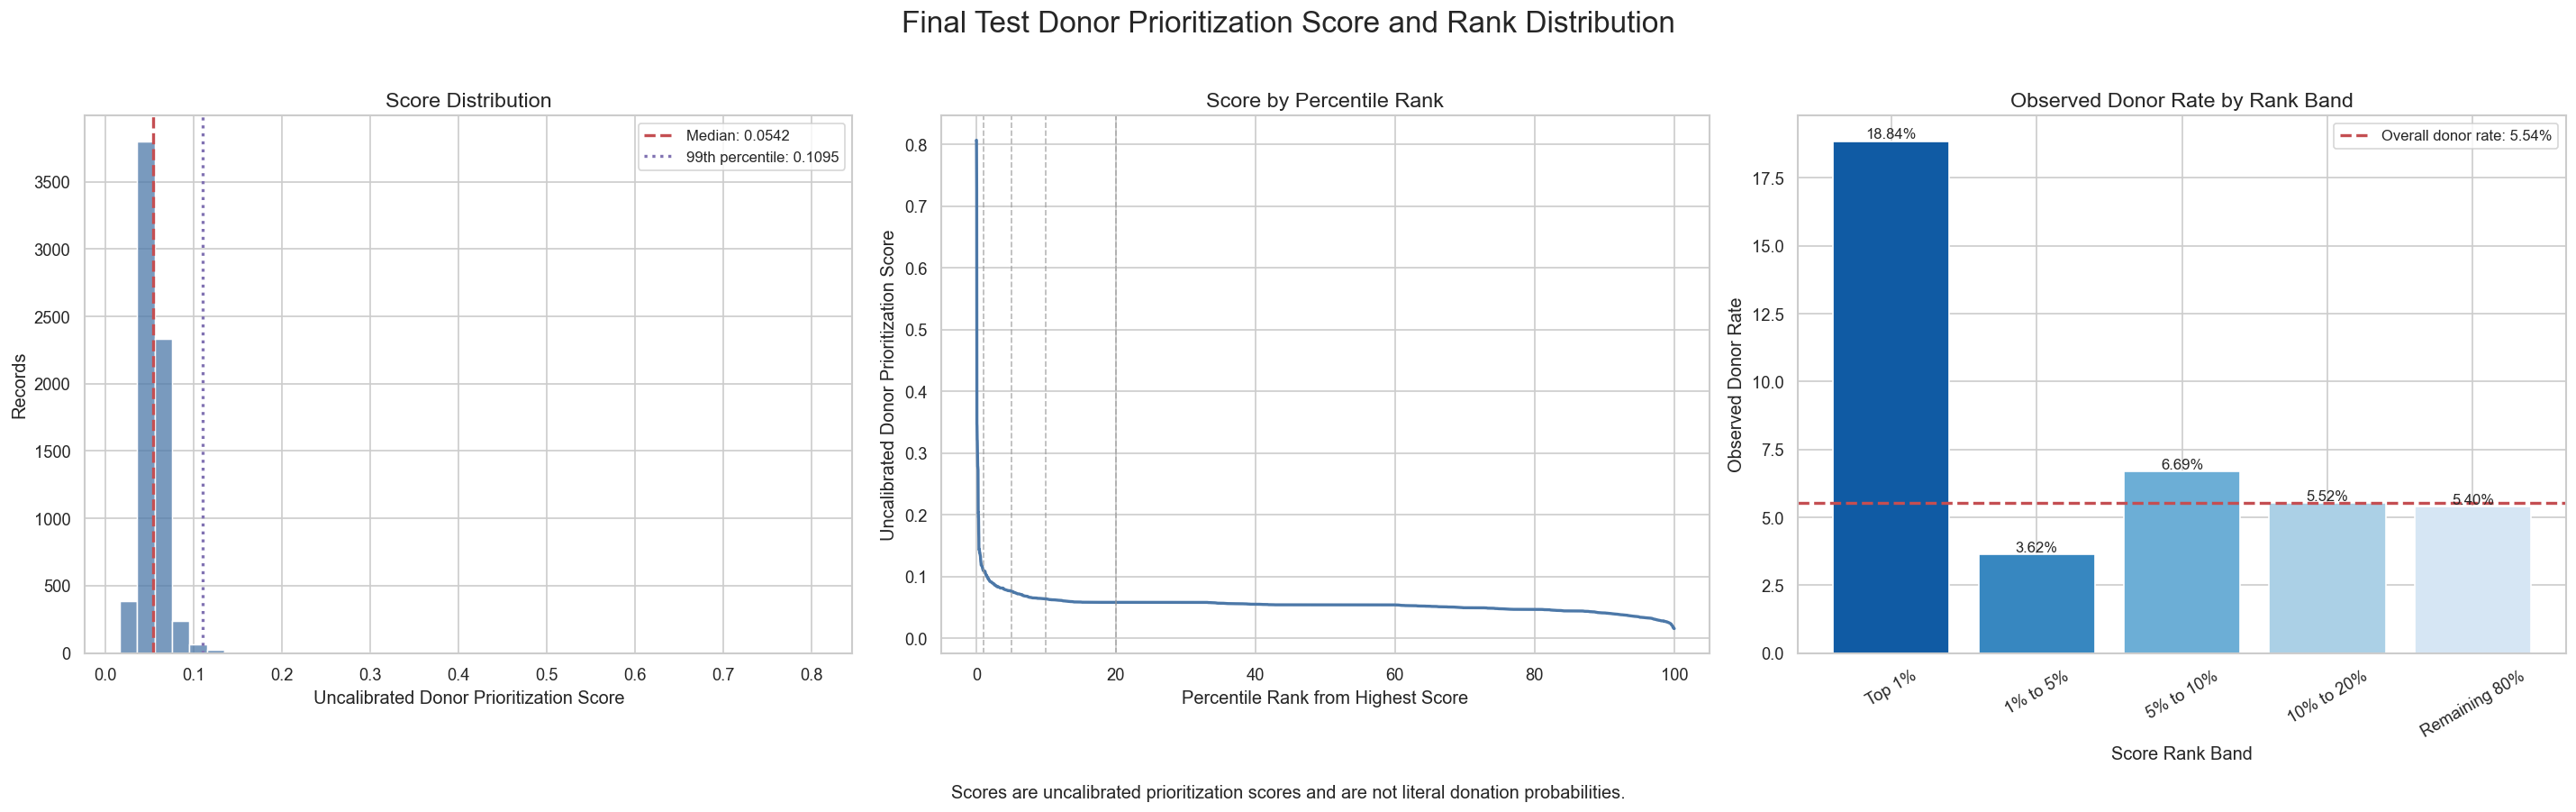

Interpretation Area,Required Interpretation
Model Output Status,Uncalibrated model output
Primary Score Meaning,Relative donor prioritization score
Correct Use,Rank donors from higher to lower model scores for outreach planning
Incorrect Use,Do not interpret a score such as 0.1000 as a literal 10% probability of donating
Rank Definition,Rank 1 is the highest score; tied scores are ordered by final test row position
Evaluation Scope,Descriptive held out final test analysis only
Operational Safeguard,"Use score ordering, observed capture, and lift rather than probability claims"


Score Group,Records,Record Percentage,Mean Score,Standard Deviation,Minimum Score,25th Percentile,Median Score,75th Percentile,90th Percentile,95th Percentile,99th Percentile,Maximum Score,Mean Rank,Median Rank
All Final Test Records,"6,881",100.00%,0.055145,0.024568,0.015832,0.047977,0.054233,0.058358,0.063956,0.076388,0.109527,0.806496,"3,441.00","3,441.00"
Actual Donors,381,5.54%,0.061780,0.060211,0.017667,0.048831,0.054233,0.058358,0.065403,0.077196,0.325766,0.806496,"3,296.18","3,179.00"
Actual Non Donors,"6,500",94.46%,0.054756,0.020597,0.015832,0.047928,0.054233,0.058358,0.063696,0.076263,0.108661,0.806496,"3,449.49","3,452.50"


Rank Band,Starting Rank,Ending Rank,Records,Record Percentage,Maximum Score,Minimum Score,Mean Score,Median Score,Positive Targets,Observed Donor Rate Percentage,Donor Capture Percentage,Lift Over Overall Rate
Top 1%,1,69,69,1.00%,0.806496,0.109810,0.205302,0.138593,13,18.84%,3.41%,3.40
1% to 5%,70,345,276,4.01%,0.109456,0.076388,0.087116,0.083863,10,3.62%,2.62%,0.65
5% to 10%,346,689,344,5.00%,0.076305,0.063956,0.068214,0.066815,23,6.69%,6.04%,1.21
10% to 20%,690,"1,377",688,10.00%,0.063878,0.058358,0.059607,0.058791,38,5.52%,9.97%,1.00
Remaining 80%,"1,378","6,881","5,504",79.99%,0.058358,0.015832,0.050285,0.054133,297,5.40%,77.95%,0.97


Outreach Capacity Percentage,Rank Cutoff,Records Selected,Positive Targets,Observed Donor Rate Percentage,Donor Capture Percentage,Lift Over Overall Rate,Minimum Selected Score,Maximum Selected Score
1.00%,69,69,13,18.84%,3.41%,3.40,0.109810,0.806496
5.00%,345,345,23,6.67%,6.04%,1.20,0.076388,0.806496
10.00%,689,689,46,6.68%,12.07%,1.21,0.063956,0.806496
20.00%,"1,377","1,377",84,6.10%,22.05%,1.10,0.058358,0.806496


Score distribution summary saved to: outputs/interpretability/tables/primary_score_distribution_summary.csv
Rank band summary saved to: outputs/interpretability/tables/primary_score_rank_bands.csv
Outreach score summary saved to: outputs/interpretability/tables/primary_score_outreach_summary.csv
Score interpretation guardrails saved to: outputs/interpretability/tables/primary_score_interpretation_guardrails.csv
Score and rank figure saved to: outputs/interpretability/figures/primary_score_rank_distribution.png


In [22]:
# Analyze final test score and rank distributions
positive_class_index_task17 = int(
    np.flatnonzero(
        classifier_primary_saved.classes_ == 1
    )[0]
)

model_scores_task17 = np.asarray(
    classifier_primary_saved.predict_proba(
        features_primary_test_transformed
    )[:, positive_class_index_task17],
    dtype=float,
)

target_values_task17 = np.asarray(
    target_primary_test_interpretation,
    dtype=int,
).reshape(-1)

record_count_task17 = model_scores_task17.shape[0]
positive_count_task17 = int(target_values_task17.sum())

overall_donor_rate_task17 = float(
    target_values_task17.mean()
)

score_order_task17 = np.argsort(
    -model_scores_task17,
    kind="mergesort",
)

score_ranks_task17 = np.empty(
    record_count_task17,
    dtype=int,
)

score_ranks_task17[
    score_order_task17
] = np.arange(
    1,
    record_count_task17 + 1,
)

score_percentile_ranks_task17 = (
    score_ranks_task17
    / record_count_task17
    * 100
)

score_analysis_task17 = pd.DataFrame(
    {
        "Final Test Row Position": np.arange(
            record_count_task17
        ),
        "Target Actual": target_values_task17,
        "Prioritization Score": model_scores_task17,
        "Score Rank": score_ranks_task17,
        "Score Percentile Rank": (
            score_percentile_ranks_task17
        ),
    }
)

score_group_specs_task17 = [
    (
        "All Final Test Records",
        np.ones(
            record_count_task17,
            dtype=bool,
        ),
    ),
    (
        "Actual Donors",
        target_values_task17 == 1,
    ),
    (
        "Actual Non Donors",
        target_values_task17 == 0,
    ),
]

score_distribution_records_task17 = []

for (
    score_group_label_task17,
    score_group_mask_task17,
) in score_group_specs_task17:
    group_scores_task17 = model_scores_task17[
        score_group_mask_task17
    ]

    group_ranks_task17 = score_ranks_task17[
        score_group_mask_task17
    ]

    score_distribution_records_task17.append(
        {
            "Score Group": score_group_label_task17,
            "Records": int(
                score_group_mask_task17.sum()
            ),
            "Record Percentage": float(
                score_group_mask_task17.mean()
                * 100
            ),
            "Mean Score": float(
                np.mean(group_scores_task17)
            ),
            "Standard Deviation": float(
                np.std(
                    group_scores_task17,
                    ddof=1,
                )
            ),
            "Minimum Score": float(
                np.min(group_scores_task17)
            ),
            "25th Percentile": float(
                np.quantile(
                    group_scores_task17,
                    0.25,
                )
            ),
            "Median Score": float(
                np.median(group_scores_task17)
            ),
            "75th Percentile": float(
                np.quantile(
                    group_scores_task17,
                    0.75,
                )
            ),
            "90th Percentile": float(
                np.quantile(
                    group_scores_task17,
                    0.90,
                )
            ),
            "95th Percentile": float(
                np.quantile(
                    group_scores_task17,
                    0.95,
                )
            ),
            "99th Percentile": float(
                np.quantile(
                    group_scores_task17,
                    0.99,
                )
            ),
            "Maximum Score": float(
                np.max(group_scores_task17)
            ),
            "Mean Rank": float(
                np.mean(group_ranks_task17)
            ),
            "Median Rank": float(
                np.median(group_ranks_task17)
            ),
        }
    )

summary_primary_score_distribution = pd.DataFrame(
    score_distribution_records_task17
)

capacity_record_counts_task17 = {
    capacity_task17: min(
        record_count_task17,
        int(
            np.ceil(
                record_count_task17
                * capacity_task17
            )
        ),
    )
    for capacity_task17
    in SCORE_RANK_CAPACITIES
}

rank_band_specs_task17 = [
    (
        "Top 1%",
        0,
        capacity_record_counts_task17[0.01],
    ),
    (
        "1% to 5%",
        capacity_record_counts_task17[0.01],
        capacity_record_counts_task17[0.05],
    ),
    (
        "5% to 10%",
        capacity_record_counts_task17[0.05],
        capacity_record_counts_task17[0.10],
    ),
    (
        "10% to 20%",
        capacity_record_counts_task17[0.10],
        capacity_record_counts_task17[0.20],
    ),
    (
        "Remaining 80%",
        capacity_record_counts_task17[0.20],
        record_count_task17,
    ),
]

rank_band_records_task17 = []

for (
    rank_band_label_task17,
    previous_rank_cutoff_task17,
    current_rank_cutoff_task17,
) in rank_band_specs_task17:
    rank_band_mask_task17 = (
        (score_ranks_task17
         > previous_rank_cutoff_task17)
        & (score_ranks_task17
           <= current_rank_cutoff_task17)
    )

    rank_band_scores_task17 = (
        model_scores_task17[
            rank_band_mask_task17
        ]
    )

    rank_band_targets_task17 = (
        target_values_task17[
            rank_band_mask_task17
        ]
    )

    rank_band_record_count_task17 = int(
        rank_band_mask_task17.sum()
    )

    rank_band_positive_count_task17 = int(
        rank_band_targets_task17.sum()
    )

    rank_band_donor_rate_task17 = float(
        rank_band_targets_task17.mean()
    )

    rank_band_records_task17.append(
        {
            "Rank Band": rank_band_label_task17,
            "Starting Rank": int(
                previous_rank_cutoff_task17 + 1
            ),
            "Ending Rank": int(
                current_rank_cutoff_task17
            ),
            "Records": (
                rank_band_record_count_task17
            ),
            "Record Percentage": float(
                rank_band_record_count_task17
                / record_count_task17
                * 100
            ),
            "Maximum Score": float(
                np.max(rank_band_scores_task17)
            ),
            "Minimum Score": float(
                np.min(rank_band_scores_task17)
            ),
            "Mean Score": float(
                np.mean(rank_band_scores_task17)
            ),
            "Median Score": float(
                np.median(rank_band_scores_task17)
            ),
            "Positive Targets": (
                rank_band_positive_count_task17
            ),
            "Observed Donor Rate Percentage": float(
                rank_band_donor_rate_task17
                * 100
            ),
            "Donor Capture Percentage": float(
                rank_band_positive_count_task17
                / positive_count_task17
                * 100
            ),
            "Lift Over Overall Rate": float(
                rank_band_donor_rate_task17
                / overall_donor_rate_task17
            ),
        }
    )

summary_primary_score_rank_bands = pd.DataFrame(
    rank_band_records_task17
)

outreach_summary_records_task17 = []

for capacity_task17 in SCORE_RANK_CAPACITIES:
    selected_record_count_task17 = (
        capacity_record_counts_task17[
            capacity_task17
        ]
    )

    selected_mask_task17 = (
        score_ranks_task17
        <= selected_record_count_task17
    )

    selected_scores_task17 = (
        model_scores_task17[
            selected_mask_task17
        ]
    )

    selected_targets_task17 = (
        target_values_task17[
            selected_mask_task17
        ]
    )

    selected_positive_count_task17 = int(
        selected_targets_task17.sum()
    )

    selected_donor_rate_task17 = float(
        selected_targets_task17.mean()
    )

    outreach_summary_records_task17.append(
        {
            "Outreach Capacity Percentage": float(
                capacity_task17 * 100
            ),
            "Rank Cutoff": int(
                selected_record_count_task17
            ),
            "Records Selected": int(
                selected_mask_task17.sum()
            ),
            "Positive Targets": (
                selected_positive_count_task17
            ),
            "Observed Donor Rate Percentage": float(
                selected_donor_rate_task17
                * 100
            ),
            "Donor Capture Percentage": float(
                selected_positive_count_task17
                / positive_count_task17
                * 100
            ),
            "Lift Over Overall Rate": float(
                selected_donor_rate_task17
                / overall_donor_rate_task17
            ),
            "Minimum Selected Score": float(
                np.min(selected_scores_task17)
            ),
            "Maximum Selected Score": float(
                np.max(selected_scores_task17)
            ),
        }
    )

summary_primary_score_outreach = pd.DataFrame(
    outreach_summary_records_task17
)

primary_score_interpretation_guardrails = pd.DataFrame(
    [
        {
            "Interpretation Area": (
                "Model Output Status"
            ),
            "Required Interpretation": (
                "Uncalibrated model output"
            ),
        },
        {
            "Interpretation Area": (
                "Primary Score Meaning"
            ),
            "Required Interpretation": (
                "Relative donor prioritization score"
            ),
        },
        {
            "Interpretation Area": (
                "Correct Use"
            ),
            "Required Interpretation": (
                "Rank donors from higher to lower "
                "model scores for outreach planning"
            ),
        },
        {
            "Interpretation Area": (
                "Incorrect Use"
            ),
            "Required Interpretation": (
                "Do not interpret a score such as "
                "0.1000 as a literal 10% probability "
                "of donating"
            ),
        },
        {
            "Interpretation Area": (
                "Rank Definition"
            ),
            "Required Interpretation": (
                "Rank 1 is the highest score; tied "
                "scores are ordered by final test "
                "row position"
            ),
        },
        {
            "Interpretation Area": (
                "Evaluation Scope"
            ),
            "Required Interpretation": (
                "Descriptive held out final test "
                "analysis only"
            ),
        },
        {
            "Interpretation Area": (
                "Operational Safeguard"
            ),
            "Required Interpretation": (
                "Use score ordering, observed capture, "
                "and lift rather than probability claims"
            ),
        },
    ]
)

for output_path_task17 in [
    PRIMARY_SCORE_DISTRIBUTION_SUMMARY_PATH,
    PRIMARY_SCORE_RANK_BANDS_PATH,
    PRIMARY_SCORE_OUTREACH_SUMMARY_PATH,
    PRIMARY_SCORE_INTERPRETATION_PATH,
    PRIMARY_SCORE_RANK_FIGURE_PATH,
]:
    output_path_task17.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

summary_primary_score_distribution.to_csv(
    PRIMARY_SCORE_DISTRIBUTION_SUMMARY_PATH,
    index=False,
)

summary_primary_score_rank_bands.to_csv(
    PRIMARY_SCORE_RANK_BANDS_PATH,
    index=False,
)

summary_primary_score_outreach.to_csv(
    PRIMARY_SCORE_OUTREACH_SUMMARY_PATH,
    index=False,
)

primary_score_interpretation_guardrails.to_csv(
    PRIMARY_SCORE_INTERPRETATION_PATH,
    index=False,
)

sorted_scores_task17 = model_scores_task17[
    score_order_task17
]

sorted_percentile_positions_task17 = (
    np.arange(
        1,
        record_count_task17 + 1,
    )
    / record_count_task17
    * 100
)

score_median_task17 = float(
    np.median(model_scores_task17)
)

score_99th_percentile_task17 = float(
    np.quantile(
        model_scores_task17,
        0.99,
    )
)

figure_task17, axes_task17 = plt.subplots(
    1,
    3,
    figsize=(24, 7),
)

sns.histplot(
    model_scores_task17,
    bins=SCORE_DISTRIBUTION_BINS,
    color="#4C78A8",
    edgecolor="white",
    ax=axes_task17[0],
)

axes_task17[0].axvline(
    score_median_task17,
    color="#C44E52",
    linestyle="--",
    linewidth=2,
    label=(
        f"Median: {score_median_task17:.4f}"
    ),
)

axes_task17[0].axvline(
    score_99th_percentile_task17,
    color="#8172B2",
    linestyle=":",
    linewidth=2,
    label=(
        "99th percentile: "
        f"{score_99th_percentile_task17:.4f}"
    ),
)

axes_task17[0].set_title(
    "Score Distribution"
)

axes_task17[0].set_xlabel(
    "Uncalibrated Donor Prioritization Score"
)

axes_task17[0].set_ylabel(
    "Records"
)

axes_task17[0].legend()

axes_task17[1].plot(
    sorted_percentile_positions_task17,
    sorted_scores_task17,
    color="#4C78A8",
    linewidth=2,
)

for capacity_task17 in SCORE_RANK_CAPACITIES:
    axes_task17[1].axvline(
        capacity_task17 * 100,
        color="#999999",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
    )

axes_task17[1].set_title(
    "Score by Percentile Rank"
)

axes_task17[1].set_xlabel(
    "Percentile Rank from Highest Score"
)

axes_task17[1].set_ylabel(
    "Uncalibrated Donor Prioritization Score"
)

rank_band_colors_task17 = sns.color_palette(
    "Blues_r",
    n_colors=summary_primary_score_rank_bands.shape[0],
)

axes_task17[2].bar(
    summary_primary_score_rank_bands[
        "Rank Band"
    ],
    summary_primary_score_rank_bands[
        "Observed Donor Rate Percentage"
    ],
    color=rank_band_colors_task17,
)

axes_task17[2].axhline(
    overall_donor_rate_task17 * 100,
    color="#C44E52",
    linestyle="--",
    linewidth=2,
    label=(
        "Overall donor rate: "
        f"{overall_donor_rate_task17 * 100:.2f}%"
    ),
)

for rank_band_position_task17, donor_rate_task17 in enumerate(
    summary_primary_score_rank_bands[
        "Observed Donor Rate Percentage"
    ]
):
    axes_task17[2].text(
        rank_band_position_task17,
        donor_rate_task17,
        f"{donor_rate_task17:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

axes_task17[2].set_title(
    "Observed Donor Rate by Rank Band"
)

axes_task17[2].set_xlabel(
    "Score Rank Band"
)

axes_task17[2].set_ylabel(
    "Observed Donor Rate"
)

axes_task17[2].tick_params(
    axis="x",
    rotation=30,
)

axes_task17[2].legend()

figure_task17.suptitle(
    "Final Test Donor Prioritization Score and Rank Distribution",
    fontsize=20,
    y=1.02,
)

figure_task17.text(
    0.5,
    -0.02,
    (
        "Scores are uncalibrated prioritization "
        "scores and are not literal donation probabilities."
    ),
    ha="center",
    fontsize=12,
)

figure_task17.tight_layout()

figure_task17.savefig(
    PRIMARY_SCORE_RANK_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

expected_rank_band_labels_task17 = [
    rank_band_label_task17
    for (
        rank_band_label_task17,
        _,
        _,
    ) in rank_band_specs_task17
]

rank_band_score_order_valid_task17 = all(
    summary_primary_score_rank_bands.loc[
        rank_band_position_task17,
        "Minimum Score",
    ]
    >= summary_primary_score_rank_bands.loc[
        rank_band_position_task17 + 1,
        "Maximum Score",
    ]
    for rank_band_position_task17
    in range(
        summary_primary_score_rank_bands.shape[0] - 1
    )
)

expected_capacity_counts_task17 = np.array(
    [
        capacity_record_counts_task17[
            capacity_task17
        ]
        for capacity_task17
        in SCORE_RANK_CAPACITIES
    ],
    dtype=int,
)

observed_capacity_counts_task17 = (
    summary_primary_score_outreach[
        "Records Selected"
    ]
    .to_numpy(dtype=int)
)

capture_percentages_task17 = (
    summary_primary_score_outreach[
        "Donor Capture Percentage"
    ]
    .to_numpy(dtype=float)
)

guardrail_text_task17 = " ".join(
    primary_score_interpretation_guardrails[
        "Required Interpretation"
    ]
    .astype(str)
    .str.lower()
    .tolist()
)

score_rank_checks_task17 = {
    "Expected final test record count": (
        record_count_task17 == 6_881
    ),
    "Expected final test positive count": (
        positive_count_task17 == 381
    ),
    "Target contains both binary classes": (
        set(np.unique(target_values_task17))
        == {0, 1}
    ),
    "Score count matches target count": (
        model_scores_task17.shape[0]
        == target_values_task17.shape[0]
    ),
    "Scores are finite": (
        np.isfinite(model_scores_task17).all()
    ),
    "Scores remain within model output bounds": (
        (
            (model_scores_task17 >= 0)
            & (model_scores_task17 <= 1)
        ).all()
    ),
    "Ranks are unique": (
        np.unique(score_ranks_task17).shape[0]
        == record_count_task17
    ),
    "Ranks cover every final test position": (
        np.array_equal(
            np.sort(score_ranks_task17),
            np.arange(
                1,
                record_count_task17 + 1,
            ),
        )
    ),
    "Scores decrease with rank": (
        (
            np.diff(sorted_scores_task17)
            <= 1e-15
        ).all()
    ),
    "Percentile ranks use valid bounds": (
        (
            score_percentile_ranks_task17.min()
            > 0
        )
        and (
            np.isclose(
                score_percentile_ranks_task17.max(),
                100.0,
            )
        )
    ),
    "Class score summaries cover all records": (
        summary_primary_score_distribution.loc[
            summary_primary_score_distribution[
                "Score Group"
            ]
            != "All Final Test Records",
            "Records",
        ].sum()
        == record_count_task17
    ),
    "Rank bands have expected labels": (
        summary_primary_score_rank_bands[
            "Rank Band"
        ].tolist()
        == expected_rank_band_labels_task17
    ),
    "Rank bands cover all records": (
        summary_primary_score_rank_bands[
            "Records"
        ].sum()
        == record_count_task17
    ),
    "Rank bands cover all positive targets": (
        summary_primary_score_rank_bands[
            "Positive Targets"
        ].sum()
        == positive_count_task17
    ),
    "Rank band score boundaries are ordered": (
        rank_band_score_order_valid_task17
    ),
    "Outreach capacities match frozen settings": (
        np.allclose(
            summary_primary_score_outreach[
                "Outreach Capacity Percentage"
            ].to_numpy(dtype=float),
            np.array(
                SCORE_RANK_CAPACITIES,
                dtype=float,
            )
            * 100,
        )
    ),
    "Outreach selected counts are correct": (
        np.array_equal(
            observed_capacity_counts_task17,
            expected_capacity_counts_task17,
        )
    ),
    "Cumulative donor capture is nondecreasing": (
        (
            np.diff(capture_percentages_task17)
            >= -1e-12
        ).all()
    ),
    "Interpretation guardrails are explicit": (
        "uncalibrated" in guardrail_text_task17
        and "prioritization" in guardrail_text_task17
        and "literal" in guardrail_text_task17
        and "probability" in guardrail_text_task17
    ),
    "All Task 17 artifacts were created": (
        PRIMARY_SCORE_DISTRIBUTION_SUMMARY_PATH.exists()
        and PRIMARY_SCORE_RANK_BANDS_PATH.exists()
        and PRIMARY_SCORE_OUTREACH_SUMMARY_PATH.exists()
        and PRIMARY_SCORE_INTERPRETATION_PATH.exists()
        and PRIMARY_SCORE_RANK_FIGURE_PATH.exists()
    ),
}

failed_score_rank_checks_task17 = [
    check_name_task17
    for (
        check_name_task17,
        check_passed_task17,
    ) in score_rank_checks_task17.items()
    if not bool(check_passed_task17)
]

if failed_score_rank_checks_task17:
    raise AssertionError(
        "Score and rank distribution validation "
        "failed for: "
        + ", ".join(
            failed_score_rank_checks_task17
        )
    )

display(
    primary_score_interpretation_guardrails
    .style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
)

display(
    summary_primary_score_distribution
    .style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Records": "{:,.0f}",
            "Record Percentage": "{:,.2f}%",
            "Mean Score": "{:.6f}",
            "Standard Deviation": "{:.6f}",
            "Minimum Score": "{:.6f}",
            "25th Percentile": "{:.6f}",
            "Median Score": "{:.6f}",
            "75th Percentile": "{:.6f}",
            "90th Percentile": "{:.6f}",
            "95th Percentile": "{:.6f}",
            "99th Percentile": "{:.6f}",
            "Maximum Score": "{:.6f}",
            "Mean Rank": "{:,.2f}",
            "Median Rank": "{:,.2f}",
        }
    )
)

display(
    summary_primary_score_rank_bands
    .style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Starting Rank": "{:,.0f}",
            "Ending Rank": "{:,.0f}",
            "Records": "{:,.0f}",
            "Record Percentage": "{:,.2f}%",
            "Maximum Score": "{:.6f}",
            "Minimum Score": "{:.6f}",
            "Mean Score": "{:.6f}",
            "Median Score": "{:.6f}",
            "Positive Targets": "{:,.0f}",
            "Observed Donor Rate Percentage": (
                "{:,.2f}%"
            ),
            "Donor Capture Percentage": "{:,.2f}%",
            "Lift Over Overall Rate": "{:,.2f}",
        }
    )
)

display(
    summary_primary_score_outreach
    .style
    .hide(axis="index")
    .set_properties(
        **{
            "text-align": "center",
            "padding": "8px",
        }
    )
    .set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("text-align", "center"),
                    ("padding", "8px"),
                ],
            }
        ]
    )
    .format(
        {
            "Outreach Capacity Percentage": (
                "{:,.2f}%"
            ),
            "Rank Cutoff": "{:,.0f}",
            "Records Selected": "{:,.0f}",
            "Positive Targets": "{:,.0f}",
            "Observed Donor Rate Percentage": (
                "{:,.2f}%"
            ),
            "Donor Capture Percentage": "{:,.2f}%",
            "Lift Over Overall Rate": "{:,.2f}",
            "Minimum Selected Score": "{:.6f}",
            "Maximum Selected Score": "{:.6f}",
        }
    )
)

score_distribution_display_path_task17 = (
    PRIMARY_SCORE_DISTRIBUTION_SUMMARY_PATH
    .resolve()
    .relative_to(PROJECT_ROOT.resolve())
)

rank_bands_display_path_task17 = (
    PRIMARY_SCORE_RANK_BANDS_PATH
    .resolve()
    .relative_to(PROJECT_ROOT.resolve())
)

outreach_summary_display_path_task17 = (
    PRIMARY_SCORE_OUTREACH_SUMMARY_PATH
    .resolve()
    .relative_to(PROJECT_ROOT.resolve())
)

score_interpretation_display_path_task17 = (
    PRIMARY_SCORE_INTERPRETATION_PATH
    .resolve()
    .relative_to(PROJECT_ROOT.resolve())
)

score_rank_figure_display_path_task17 = (
    PRIMARY_SCORE_RANK_FIGURE_PATH
    .resolve()
    .relative_to(PROJECT_ROOT.resolve())
)

print(
    "Score distribution summary saved to: "
    f"{score_distribution_display_path_task17}"
)

print(
    "Rank band summary saved to: "
    f"{rank_bands_display_path_task17}"
)

print(
    "Outreach score summary saved to: "
    f"{outreach_summary_display_path_task17}"
)

print(
    "Score interpretation guardrails saved to: "
    f"{score_interpretation_display_path_task17}"
)

print(
    "Score and rank figure saved to: "
    f"{score_rank_figure_display_path_task17}"
)

## Donor Prioritization Score and Rank Distribution
The finalized Random Forest produces uncalibrated donor prioritization scores. These scores are intended to order donors from higher to lower outreach priority and must not be interpreted as literal probabilities of donating. Rank 1 represents the highest model score, with tied scores ordered by their original final test row position.

Scores on the 6,881 record final test set were strongly right skewed. The mean score was 0.0551, the median was 0.0542, and the 99th percentile was 0.1095. Most records were concentrated within a narrow score range, while a small group received substantially higher scores. Actual donors had a mean score of 0.0618, compared with 0.0548 for non donors, but the distributions overlapped considerably. This indicates that the model provides relative prioritization rather than certainty about individual outcomes.

The top 1% contained 69 records and 13 actual donors. Its observed donor rate was 18.84%, compared with 5.54% across the full final test set, producing a lift of 3.40. This group captured 3.41% of all final test donors. Results were less consistent across the broader nonoverlapping rank bands: the 1% to 5% band had a donor rate of 3.62%, the 5% to 10% band had a rate of 6.69%, the 10% to 20% band had a rate of 5.52%, and the remaining 80% had a rate of 5.40%. The variation shows that observed donor rates do not decrease smoothly with rank, although the highest ranked group had the clearest concentration of donors.

The following safeguards apply when using these scores:
- Use scores to rank donors and define outreach capacity.
- Do not interpret a score such as 0.1000 as a 10% probability of donating.
- Evaluate outreach groups using observed donor rate, donor capture, and lift.

All 20 score and rank distribution checks passed. The summaries and figure were saved as reusable interpretation artifacts.
